# **Программная реализация алгоритмов к магистерской диссертации**

# На тему (рус.) «Подходы к инженерии требований при гибкой разработке ПО с использованием аппарата нечетких множеств»

# На тему (англ.) «Fuzzy Set-Based Approaches to Requirements Engineering in Agile Software Development»

# 1 Приоритизация требований по методу MoSCoW при принятии решений одним экспертом

# 1.1. Fuzzy_MoSCoW при принятии решений одним экспертом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Нечеткий алгоритм MoSCoW с оценками одного эксперта. Загрузка и выгрузка в ноутбуке**

In [49]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [50]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [51]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [52]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [53]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [54]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [55]:
# Нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задание нечетких весов (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

type IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразование NFR-термов в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразование FR_NFR термов в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FR_NFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results


In [56]:
# Пример запуска_1 эксперт

NFR = ["Mo", "Mo", "Mo"]  # NFR1=Mo, NFR2=Co, NFR3=S

# 10 FR (произвольное число)
FRs = [
    ["Mo", "Mo",  "Mo"],   # FR1: (FR1_NFR1, FR1_NFR2, FR1_NFR3)
    ["W", "S",  "Mo"],   # FR2
    ["S",  "W", "W" ],    # FR3
    ["Mo",  "S", "Mo" ],   # FR4
    ["S",  "Co", "S" ],   # FR5
    ["Co",  "Co", "Co" ],  # FR6
    ["S",  "S", "W" ],  # FR7
    ["S",  "S", "S" ],  # FR8
    ["W",  "W", "W" ],   # FR9
    ["Co",  "Co", "Mo" ],   # FR10
]

results = pfr_moscow_it2(NFR, FRs)

for r in results:
    print(f"{r['fr']}: PFR_IT2 = {r['pfr']}")

FR1: PFR_IT2 = ((12.83, 22.5, 25.5, 25.5), (15.0, 22.5, 25.5, 25.5))
FR2: PFR_IT2 = ((6.76, 11.62, 15.04, 17.94), (7.98, 11.62, 15.04, 17.08))
FR3: PFR_IT2 = ((2.48, 4.12, 6.54, 11.31), (2.98, 4.12, 6.54, 9.86))
FR4: PFR_IT2 = ((11.04, 19.12, 23.54, 24.57), (12.97, 19.12, 23.54, 24.31))
FR5: PFR_IT2 = ((4.96, 9.89, 16.82, 19.82), (6.19, 9.89, 16.82, 19.04))
FR6: PFR_IT2 = ((0.0, 4.95, 11.22, 14.04), (0.69, 4.95, 11.22, 13.26))
FR7: PFR_IT2 = ((4.96, 8.25, 13.09, 17.01), (5.96, 8.25, 13.09, 15.89))
FR8: PFR_IT2 = ((7.44, 12.38, 19.63, 22.71), (8.94, 12.38, 19.63, 21.93))
FR9: PFR_IT2 = ((0.0, 0.0, 0.0, 5.61), (0.0, 0.0, 0.0, 3.81))
FR10: PFR_IT2 = ((4.28, 10.8, 15.98, 17.86), (5.46, 10.8, 15.98, 17.34))


In [57]:
# Применние оператора согласованной линейной редукции типов ко всему списку нечетких приоритетов
a = 0.6

results_reduction = []
for r in results:  # results = вывод pfr_moscow_it2(...)
    reduced = cltr_type_reduction(r["pfr"], a)
    results_reduction.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr"],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
        "ratings": r["ratings"],
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (14.13, 22.5, 25.5, 25.5)
FR2: a=0.6, (7.49, 11.62, 15.04, 17.42)
FR3: a=0.6, (2.78, 4.12, 6.54, 10.44)
FR4: a=0.6, (12.2, 19.12, 23.54, 24.41)
FR5: a=0.6, (5.7, 9.89, 16.82, 19.35)
FR6: a=0.6, (0.41, 4.95, 11.22, 13.57)
FR7: a=0.6, (5.56, 8.25, 13.09, 16.34)
FR8: a=0.6, (8.34, 12.38, 19.63, 22.24)
FR9: a=0.6, (0.0, 0.0, 0.0, 4.53)
FR10: a=0.6, (4.99, 10.8, 15.98, 17.55)


In [58]:
# Применение альфа-среза ко всему списку редуцированных нечетких приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
        "ratings": r["ratings"],
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (20.83; 25.5)
FR2: альфа=0.8, (10.79; 15.52)
FR3: альфа=0.8, (3.85; 7.32)
FR4: альфа=0.8, (17.74; 23.71)
FR5: альфа=0.8, (9.05; 17.33)
FR6: альфа=0.8, (4.04; 11.69)
FR7: альфа=0.8, (7.71; 13.74)
FR8: альфа=0.8, (11.57; 20.15)
FR9: альфа=0.8, (0.0; 0.91)
FR10: альфа=0.8, (9.64; 16.29)


In [59]:
# Вычисление центроида для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=23.16
2. FR4: centroid=20.73
3. FR8: centroid=15.86
4. FR5: centroid=13.19
5. FR2: centroid=13.15
6. FR10: centroid=12.96
7. FR7: centroid=10.72
8. FR6: centroid=7.87
9. FR3: centroid=5.58
10. FR9: centroid=0.46


Алгоритм учета взаимосвязанности функциональных требований

In [60]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    # Проверка размера матрицы
    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    # Проверка главной диагонали и симметричности
    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        # "FR1" -> 0, "FR10" -> 9
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    # Проверка, что ranked_list содержит полный набор FR1..FRn
    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    # Копия списка + сохраняем исходный ранг
    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    # Сопоставление: индекс в матрице -> элемент ranked_list
    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    # Поиск связанных групп требований по матрице в исходной нумерации FR
    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    # В каждой связанной группе всем присваиваем максимум centroid
    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    # Пересортировка по скорректированной оценке
    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [61]:
# Матрица взаимосвязей 10x10
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=23.16, скорректированный centroid=23.16
2. FR4: исходный centroid=20.73, скорректированный centroid=23.16
3. FR8: исходный centroid=15.86, скорректированный centroid=15.86
4. FR10: исходный centroid=12.96, скорректированный centroid=15.86
5. FR9: исходный centroid=0.46, скорректированный centroid=15.86
6. FR5: исходный centroid=13.19, скорректированный centroid=13.19
7. FR2: исходный centroid=13.15, скорректированный centroid=13.15
8. FR7: исходный centroid=10.72, скорректированный centroid=10.72
9. FR6: исходный centroid=7.87, скорректированный centroid=10.72
10. FR3: исходный centroid=5.58, скорректированный centroid=5.58


Визуализации исходного и итогового приоритизированного списков функциональных требований

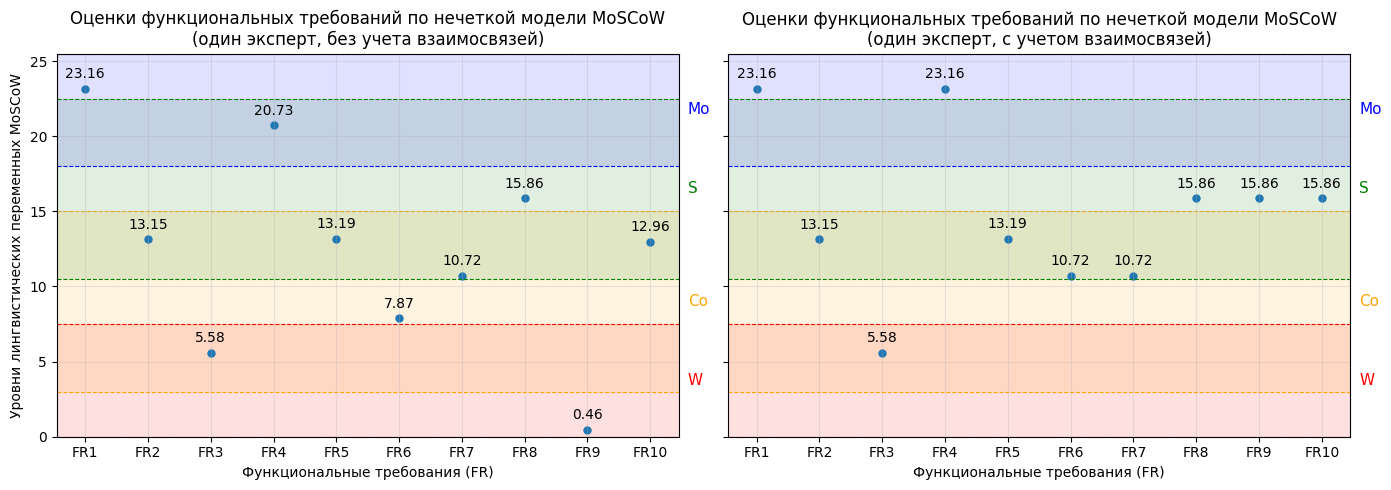

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = [r["fr"] for r in results_alpha]

# Исходные и скорректированные оценки требований
scores = [r["centroid"] for r in results_alpha]
adjusted_scores_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 7.5),
    "Co": (3.0, 15.0),
    "S":  (10.5, 22.5),
    "Mo": (18.0, 25.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Оценки функциональных требований по нечеткой модели MoSCoW\n(один эксперт, без учета взаимосвязей)",
    "Оценки функциональных требований по нечеткой модели MoSCoW\n(один эксперт, с учетом взаимосвязей)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 25.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Нечеткий алгоритм MoSCoW с оценками одного эксперта. Загрузка и выгрузка из файла/ в файл Excel**

In [63]:
# Реализация нечеткого MoSCoW c произвольным количеством функциональных и нефункциональных требований.
# Решение принимается одним экспертом. Загрузка данных и выгрузка результатов - из файла / в файл Excel.

import re
from typing import Dict, Any, Optional, Sequence, List, Tuple
import pandas as pd
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter


# 1. Обновленные нечеткие веса MoSCoW
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0.0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0.0, 0.0, 0.0, 0.22), (0.0, 0.0, 0.0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]

_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)


# 2. Нормализация обозначений приоритетов MoSCoW
def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")

    s = str(x).strip()
    s_upper = s.upper()

    if s_upper in {"MO", "M0"}:
        return "Mo"
    if s_upper == "CO":
        return "Co"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(
        f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W"
    )


# 3. Загрузка данных одного эксперта из Excel
def load_single_expert_sheet(ws) -> Dict[str, Any]:
    # 3.1. Поиск строки заголовков NFR
    nfr_header_row = None
    nfr_cols = []
    nfr_names = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [
            c for c, v in enumerate(row_vals, start=1)
            if isinstance(v, str) and _nfr_pat.match(v.strip())
        ]
        if len(cols) >= 1:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 3.2. Поиск строки приоритетов NFR
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(
                f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}."
            )
        nfr_priorities.append(normalize_moscow_label(v))

    # 3.3. Поиск строки заголовков таблицы FR
    fr_header_row = None
    fr_cols = []
    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR на листе '{ws.title}'.")

    # 3.4. Чтение строк FR
    fr_names = []
    fr_matrix = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break

        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else normalize_moscow_label(v))

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {
        "nfr_names": nfr_names,
        "nfr_priorities": nfr_priorities,
        "fr_names": fr_names,
        "fr_vs_nfr": fr_matrix,
    }


# 4. Расчет нечетких PFR по модели MoSCoW
def pfr_moscow_it2(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str] | None = None,
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]

    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(
            f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W"
        )

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(
                f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}."
            )

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(
                f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W"
            )

        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr_it2": pfr_it2,
            "ratings": list(fr_row),
        })

    return results


# 5. Дефаззификация по схеме CLTR -> alpha-cut -> centroid
def defuzzify_fuzzy_results(
    fuzzy_results: List[Dict[str, Any]],
    a: float = 0.6,
    alpha: float = 0.8
) -> List[Dict[str, Any]]:

    processed = []

    for item in fuzzy_results:
        pfr_t1 = cltr_type_reduction(item["pfr_it2"], a)
        alpha_interval = alpha_cut(pfr_t1, alpha)
        centroid_value = centroid(alpha_interval)

        processed.append({
            "fr": item["fr"],
            "pfr_it2": item["pfr_it2"],
            "pfr_t1": pfr_t1,
            "alpha_cut": alpha_interval,
            "centroid": centroid_value,
            "ratings": item["ratings"],
            "a": a,
            "alpha": alpha,
        })

    processed_sorted = sorted(processed, key=lambda x: x["centroid"], reverse=True)
    return processed_sorted


# 6. Учет взаимосвязанности функциональных требований
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(
                f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1."
            )
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}"
            )
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted


# 7. Подготовка данных для вывода
def fuzzy_ranked_to_dataframe(
    ranked_list: List[Dict[str, Any]]
) -> pd.DataFrame:
    rows = []

    for item in ranked_list:
        (u1, u2, u3, u4), (l1, l2, l3, l4) = item["pfr_it2"]
        t1_1, t1_2, t1_3, t1_4 = item["pfr_t1"]
        cut_start, cut_end = item["alpha_cut"]

        rows.append({
            "FR": item["fr"],
            "UMF_x1": float(u1),
            "UMF_x2": float(u2),
            "UMF_x3": float(u3),
            "UMF_x4": float(u4),
            "LMF_x1": float(l1),
            "LMF_x2": float(l2),
            "LMF_x3": float(l3),
            "LMF_x4": float(l4),
            "T1_x1": float(t1_1),
            "T1_x2": float(t1_2),
            "T1_x3": float(t1_3),
            "T1_x4": float(t1_4),
            "alpha_start": float(cut_start),
            "alpha_end": float(cut_end),
            "centroid": float(item["centroid"]),
        })

    return pd.DataFrame(rows)


def adjusted_fuzzy_ranked_to_dataframe(
    adjusted_ranked_list: List[Dict[str, Any]]
) -> pd.DataFrame:
    rows = []
    for idx, item in enumerate(adjusted_ranked_list, start=1):
        rows.append({
            "Место": idx,
            "FR": item["fr"],
            "Исходный центроид": float(item["centroid"]),
            "Скорректированный центроид": float(item["adjusted_centroid"]),
        })
    return pd.DataFrame(rows)


# 8. Настройка оформления Excel
def autosize_columns(ws, min_width: int = 12, max_width: int = 80, extra_padding: int = 3):
    merged_all = set()

    for merged_range in ws.merged_cells.ranges:
        for row in range(merged_range.min_row, merged_range.max_row + 1):
            for col in range(merged_range.min_col, merged_range.max_col + 1):
                merged_all.add((row, col))

    for col_cells in ws.columns:
        max_len = 0
        col_idx = col_cells[0].column

        for c in col_cells:
            coord = (c.row, c.column)

            if coord in merged_all:
                continue

            value = "" if c.value is None else str(c.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_len = max(max_len, longest)

        adjusted_width = max_len + extra_padding
        ws.column_dimensions[get_column_letter(col_idx)].width = max(
            min_width, min(adjusted_width, max_width)
        )

def autosize_rows(ws, base_height: float = 18.0, extra_padding: float = 3.0):
    for row_cells in ws.iter_rows():
        row_num = row_cells[0].row
        if ws.row_dimensions[row_num].height is not None:
            continue

        max_lines = 1
        max_text_len = 0

        for c in row_cells:
            value = "" if c.value is None else str(c.value)
            line_count = value.count("\n") + 1
            max_lines = max(max_lines, line_count)
            max_text_len = max(max_text_len, len(value))

        height = base_height * max_lines

        if max_text_len > 35:
            height += extra_padding

        if max_text_len > 60:
            height += extra_padding

        ws.row_dimensions[row_num].height = height


def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):
                cell.number_format = "0.00"


def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

# 9. Запись листа с матрицей взаимосвязей
def write_relation_matrix_sheet(
    wb: openpyxl.Workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1), horizontal="left")
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(3, j, fr_name).font = header_font
        ws.cell(3, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for i, fr_name in enumerate(fr_names, start=4):
        ws.cell(i, 1, fr_name).font = header_font
        ws.cell(i, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, value)
            ws.cell(i, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            ws.cell(i, j).number_format = "0"

    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)

    ws.column_dimensions["A"].width = 14
    for col_idx in range(2, len(fr_names) + 2):
        ws.column_dimensions[get_column_letter(col_idx)].width = 10

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 10. Запись итогового листа
def write_fuzzy_summary_sheet(
    wb: openpyxl.Workbook,
    loaded: Dict[str, Any],
    df_ranked: pd.DataFrame,
    df_adjusted: pd.DataFrame,
    a: float,
    alpha: float,
    sheet_name: str = "Нечеткий MoSCoW_итог"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)
    center_wrap = Alignment(horizontal="center", vertical="center", wrap_text=True)

    r = 1

    ws.cell(r, 1, "Нечеткий MoSCoW - итоговая приоритизация (один эксперт)").font = title_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 2

    # 10.1. Параметры дефаззификации
    ws.cell(r, 1, "1) Параметры модели").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    ws.cell(r, 1, "Параметр")
    ws.cell(r, 2, "Значение")
    ws.cell(r, 1).font = header_font
    ws.cell(r, 2).font = header_font
    ws.cell(r, 1).alignment = center_wrap
    ws.cell(r, 2).alignment = center_wrap
    r += 1

    ws.cell(r, 1, "a (редукция типа CLTR)")
    ws.cell(r, 2, float(a))
    ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.cell(r, 2).alignment = center_wrap
    ws.cell(r, 2).number_format = "0.00"
    r += 1

    ws.cell(r, 1, "alpha (уровень альфа-среза)")
    ws.cell(r, 2, float(alpha))
    ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.cell(r, 2).alignment = center_wrap
    ws.cell(r, 2).number_format = "0.00"
    r += 2

    # 10.2. Итоговые нечеткие приоритеты и результаты дефаззификации
    ws.cell(r, 1, "2) Итоговые нечеткие приоритеты и результаты дефаззификации").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    header_row_1 = r
    header_row_2 = r + 1

    ws.merge_cells(start_row=header_row_1, start_column=1, end_row=header_row_2, end_column=1)
    ws.merge_cells(start_row=header_row_1, start_column=2, end_row=header_row_2, end_column=2)
    ws.merge_cells(start_row=header_row_1, start_column=3, end_row=header_row_1, end_column=10)
    ws.merge_cells(start_row=header_row_1, start_column=11, end_row=header_row_1, end_column=14)
    ws.merge_cells(start_row=header_row_1, start_column=15, end_row=header_row_1, end_column=16)
    ws.merge_cells(start_row=header_row_1, start_column=17, end_row=header_row_2, end_column=17)

    ws.cell(header_row_1, 1, "Место")
    ws.cell(header_row_1, 2, "FR")
    ws.cell(header_row_1, 3, "Итоговый приоритет функционального требования в виде ИНМТ2")
    ws.cell(header_row_1, 11, "Редуцированный приоритет FR в виде ИНМТ1")
    ws.cell(header_row_1, 15, "Дефаззификация (альфа-срез)")
    ws.cell(header_row_1, 17, "Центроид")

    for col in [1, 2, 3, 11, 15, 17]:
        ws.cell(header_row_1, col).font = header_font
        ws.cell(header_row_1, col).alignment = center_wrap

    second_level_headers = [
        "UMF_x1", "UMF_x2", "UMF_x3", "UMF_x4",
        "LMF_x1", "LMF_x2", "LMF_x3", "LMF_x4",
        "T1_x1", "T1_x2", "T1_x3", "T1_x4",
        "alpha_start", "alpha_end"
    ]

    for idx, header in enumerate(second_level_headers, start=3):
        ws.cell(header_row_2, idx, header)
        ws.cell(header_row_2, idx).font = header_font
        ws.cell(header_row_2, idx).alignment = center_wrap

    ws.row_dimensions[header_row_1].height = 36
    ws.row_dimensions[header_row_2].height = 28

    r += 2

    data_columns = [
        "UMF_x1", "UMF_x2", "UMF_x3", "UMF_x4",
        "LMF_x1", "LMF_x2", "LMF_x3", "LMF_x4",
        "T1_x1", "T1_x2", "T1_x3", "T1_x4",
        "alpha_start", "alpha_end",
        "centroid"
    ]

    ranked_start_row = r
    for idx, (_, row_df) in enumerate(df_ranked.iterrows(), start=1):
        ws.cell(r, 1, idx)
        ws.cell(r, 2, row_df["FR"])

        for offset, header in enumerate(data_columns, start=3):
            ws.cell(r, offset, row_df[header])

        ws.cell(r, 1).alignment = center_wrap
        ws.cell(r, 2).alignment = center_wrap
        ws.cell(r, 1).number_format = "0"

        for col_idx in range(3, 18):
            ws.cell(r, col_idx).alignment = center_wrap
            ws.cell(r, col_idx).number_format = "0.00"

        r += 1

    ranked_end_row = r - 1
    r += 1

    # 10.3. Скорректированный рейтинг FR с учетом взаимосвязанности
    ws.cell(r, 1, "3) Скорректированный рейтинг FR с учетом взаимосвязанности").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    adjusted_headers = [
        "Место",
        "FR",
        "Исходный центроид",
        "Скорректированный центроид"
    ]

    for col_idx, header in enumerate(adjusted_headers, start=1):
        ws.cell(r, col_idx, header).font = header_font
        ws.cell(r, col_idx).alignment = center_wrap

    ws.row_dimensions[r].height = 32
    r += 1

    adjusted_start_row = r
    for _, row_df in df_adjusted.iterrows():
        ws.cell(r, 1, int(row_df["Место"]))
        ws.cell(r, 2, row_df["FR"])
        ws.cell(r, 3, row_df["Исходный центроид"])
        ws.cell(r, 4, row_df["Скорректированный центроид"])

        ws.cell(r, 1).alignment = center_wrap
        ws.cell(r, 2).alignment = center_wrap
        ws.cell(r, 3).alignment = center_wrap
        ws.cell(r, 4).alignment = center_wrap

        ws.cell(r, 1).number_format = "0"
        ws.cell(r, 3).number_format = "0.00"
        ws.cell(r, 4).number_format = "0.00"
        r += 1

    adjusted_end_row = r - 1

    autosize_columns(ws, min_width=12, max_width=24, extra_padding=4)

    # Фиксированные ширины для листа итогов
    ws.column_dimensions["A"].width = 28
    ws.column_dimensions["B"].width = 12

    # Первая таблица
    for col_letter in ["C", "D", "E", "F", "G", "H", "I", "J"]:
        ws.column_dimensions[col_letter].width = 10
    for col_letter in ["K", "L", "M", "N"]:
        ws.column_dimensions[col_letter].width = 10

    # Альфа-срез
    ws.column_dimensions["O"].width = 14
    ws.column_dimensions["P"].width = 14

    # Центроид
    ws.column_dimensions["Q"].width = 12

    # Вторая таблица
    ws.column_dimensions["A"].width = 28
    ws.column_dimensions["B"].width = 12
    ws.column_dimensions["C"].width = 14
    ws.column_dimensions["D"].width = 20

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 11. Основная функция запуска
def fuzzy_moscow_from_excel(
    in_path: str,
    out_path: Optional[str] = None,
    a: float = 0.6,
    alpha: float = 0.8,
    relation_matrix: Optional[Sequence[Sequence[int]]] = None,
    source_sheet_name: Optional[str] = None,
    result_sheet_name: str = "Нечеткий MoSCoW_итог",
) -> str:

    wb = openpyxl.load_workbook(in_path)

    if source_sheet_name is None:
        source_sheet_name = wb.sheetnames[0]

    ws_in = wb[source_sheet_name]
    data = load_single_expert_sheet(ws_in)

    fuzzy_results = pfr_moscow_it2(
        data["nfr_priorities"],
        data["fr_vs_nfr"],
        fr_names=data["fr_names"],
    )

    ranked_results = defuzzify_fuzzy_results(
        fuzzy_results=fuzzy_results,
        a=a,
        alpha=alpha
    )

    n_fr = len(data["fr_names"])

    if relation_matrix is None:
        relation_matrix = [[1 if i == j else 0 for j in range(n_fr)] for i in range(n_fr)]

    if len(relation_matrix) != n_fr or any(len(row) != n_fr for row in relation_matrix):
        raise ValueError(
            f"Матрица взаимосвязей должна быть размера {n_fr}x{n_fr}."
        )

    adjusted_ranked = adjust_fuzzy_ranked_by_interdependencies(
        ranked_results,
        relation_matrix
    )

    df_ranked = fuzzy_ranked_to_dataframe(ranked_results)
    df_adjusted = adjusted_fuzzy_ranked_to_dataframe(adjusted_ranked)

    original_sheet_name = wb.sheetnames[0]

    write_relation_matrix_sheet(
        wb=wb,
        fr_names=data["fr_names"],
        relation_matrix=relation_matrix,
        sheet_name="Матрица_взаимосвязей_FR"
    )

    write_fuzzy_summary_sheet(
        wb=wb,
        loaded=data,
        df_ranked=df_ranked,
        df_adjusted=df_adjusted,
        a=a,
        alpha=alpha,
        sheet_name=result_sheet_name
    )

    desired_order = [
        original_sheet_name,
        "Матрица_взаимосвязей_FR",
        result_sheet_name
    ]
    wb._sheets = [wb[sheet_name] for sheet_name in desired_order if sheet_name in wb.sheetnames]

    if out_path is None:
        out_path = in_path

    wb.save(out_path)
    return out_path

In [64]:
# Запуск
relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR1 связано с FR4
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # FR2
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # FR3
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR4 связано с FR1
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # FR5
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR6 связано с FR7
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR7 связано с FR6
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR8 связано с FR9 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR9 связано с FR8 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR10 связано с FR8 и FR9
]

in_file = "Загрузочные данные_MoSCoW_один эксперт.xlsx"
out_file = "Итоги_Fuzzy MoSCoW_один эксперт.xlsx"

saved_path = fuzzy_moscow_from_excel(
    in_path=in_file,
    out_path=out_file,
    a=0.6,
    alpha=0.8,
    relation_matrix=relation_matrix,
    source_sheet_name=None,
    result_sheet_name="Нечеткий MoSCoW_итог",
)

print("Файл сохранен:", saved_path)

Файл сохранен: Итоги_Fuzzy MoSCoW_один эксперт.xlsx


# 1.2. Четкий MoSCoW при принятии решений одним экспертом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Четкий алгоритм MoSCoW с оценками одного эксперта. Загрузка и выгрузка в ноутбуке**

In [65]:
# Реализация четкого MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Загрузка в виде списка параметров в строке кода
from typing import List, Sequence, Dict, Any

MOSCOW_NFR_WEIGHTS = {"Mo": 8.0, "S": 5.5, "Co": 3.0, "W": 0.5}
MOSCOW_FR_REL_WEIGHTS = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}

def pfr_moscow_ranked(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn)
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # список FR, каждый FR имеет длину = n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым")

    # Имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR")

    # Веса NFR
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_triplet in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_triplet) != n:
            raise ValueError(
                f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_triplet)}."
            )

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_triplet]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение {e}. Допустимо: Mo, S, Co, W")

        pfr = sum(w_nfr * w_fr for w_nfr, w_fr in zip(nfr_w, fr_w))

        results.append({
            "fr": name,
            "pfr": pfr,
            "ratings": list(fr_triplet),
        })

    # сортировка по убыванию PFR (при равенстве - сохраняем исходный порядок)
    results_sorted = sorted(results, key=lambda x: x["pfr"], reverse=True)
    return results_sorted


In [66]:
# пример: n = 3 NFR
NFR = ["Mo", "Mo", "Mo"]  # NFR1=Mo, NFR2=Co, NFR3=S

# 10 FR (произвольное число)
FRs = [
    ["Mo", "Mo",  "Mo"],   # FR1: (FR1_NFR1, FR1_NFR2, FR1_NFR3)
    ["W", "S",  "Mo"],   # FR2
    ["S",  "W", "W" ],    # FR3
    ["Mo",  "S", "Mo" ],   # FR4
    ["S",  "Co", "S" ],   # FR5
    ["Co",  "Co", "Co" ],  # FR6
    ["S",  "S", "W" ],  # FR7
    ["S",  "S", "S" ],  # FR8
    ["W",  "W", "W" ],   # FR9
    ["Co",  "Co", "Mo" ],   # FR10
]

ranked = pfr_moscow_ranked(NFR, FRs)

for item in ranked:
    print(f"{item['fr']}: PFR = {round(item['pfr'], 2)}")

FR1: PFR = 24.0
FR4: PFR = 21.28
FR8: PFR = 15.84
FR2: PFR = 13.28
FR10: PFR = 13.28
FR5: PFR = 13.2
FR7: PFR = 10.56
FR6: PFR = 7.92
FR3: PFR = 5.28
FR9: PFR = 0.0


Алгоритм учета взаимосвязанности функциональных требований

In [67]:
def adjust_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        # "FR1" -> 0, "FR10" -> 9
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    # Проверим, что все FR корректно покрывают матрицу
    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    # Копия списка + исходный ранг
    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_pfr"] = item["pfr"]
        adjusted.append(new_item)

    # Быстрый доступ: индекс FR в матрице -> элемент ranked_list
    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    # Поиск связанных компонент по матрице в исходной нумерации FR
    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    # В каждой связанной группе выравниваем по максимуму pfr
    for comp in components:
        max_pfr = max(matrix_idx_to_item[i]["pfr"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_pfr"] = max_pfr

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_pfr"], x["original_rank"])
    )

    return adjusted_sorted


Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [68]:
# Матрица взаимосвязей 10x10
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_ranked = adjust_ranked_by_interdependencies(ranked, relation_matrix)

print("\nСкорректированный ранжированный список:")
for item in adjusted_ranked:
    print(
        f"{item['fr']}: "
        f"исходный PFR = {round(item['pfr'], 2)}, "
        f"скорректированный PFR = {round(item['adjusted_pfr'], 2)}"
    )


Скорректированный ранжированный список:
FR1: исходный PFR = 24.0, скорректированный PFR = 24.0
FR4: исходный PFR = 21.28, скорректированный PFR = 24.0
FR8: исходный PFR = 15.84, скорректированный PFR = 15.84
FR10: исходный PFR = 13.28, скорректированный PFR = 15.84
FR9: исходный PFR = 0.0, скорректированный PFR = 15.84
FR2: исходный PFR = 13.28, скорректированный PFR = 13.28
FR5: исходный PFR = 13.2, скорректированный PFR = 13.2
FR7: исходный PFR = 10.56, скорректированный PFR = 10.56
FR6: исходный PFR = 7.92, скорректированный PFR = 10.56
FR3: исходный PFR = 5.28, скорректированный PFR = 5.28


Визуализации исходного и итогового приоритизированного списков функциональных требований

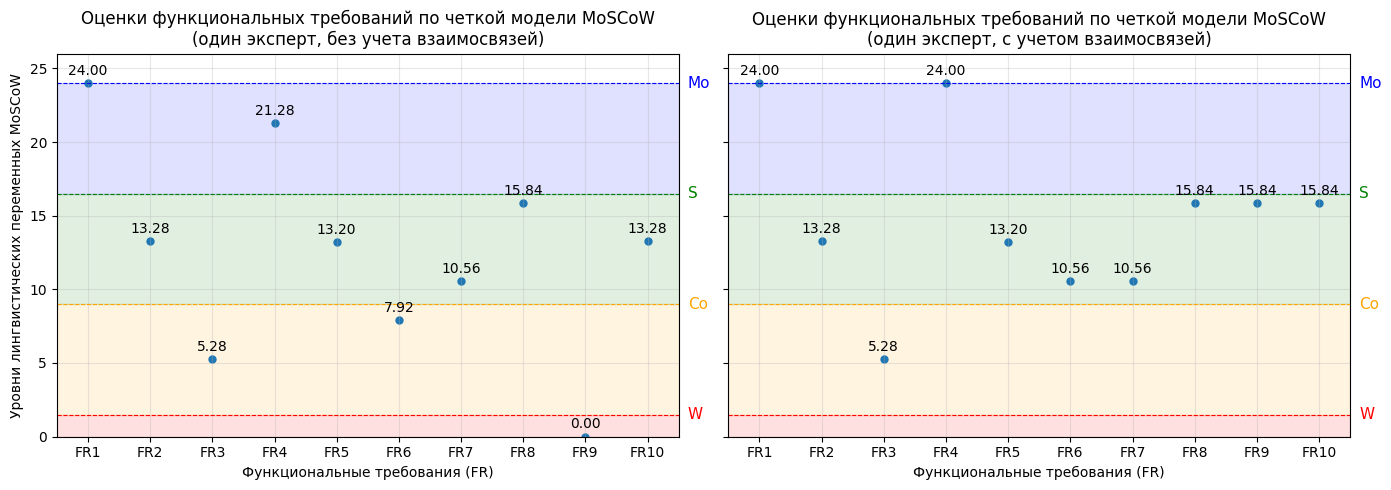

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Формирование списока FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    [item["fr"] for item in ranked],
    key=lambda x: int(x.replace("FR", ""))
)

# Преобразование результатов в словари: {FR: pfr} и {FR: adjusted_pfr}
pfr_by_fr = {item["fr"]: item["pfr"] for item in ranked}
adjusted_pfr_by_fr = {item["fr"]: item["adjusted_pfr"] for item in adjusted_ranked}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [pfr_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_pfr_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (16.5, 24.0),
    "S": (9.0, 16.5),
    "Co": (1.5, 9.0),
    "W": (0, 1.5)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 24.0,
    "S": 16.5,
    "Co": 9.0,
    "W": 1.5
}

boundary_lines = [1.5, 9.0, 16.5, 24.0]
boundary_colors = {
    1.5: "red",
    9.0: "orange",
    16.5: "green",
    24.0: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Оценки функциональных требований по четкой модели MoSCoW\n(один эксперт, без учета взаимосвязей)",
    "Оценки функциональных требований по четкой модели MoSCoW\n(один эксперт, с учетом взаимосвязей)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.35
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    # Настройки осей
    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 26)
    ax.set_xlim(-0.5, len(fr_labels) - 0.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Четкий алгоритм MoSCoW с оценками одного эксперта. Загрузка и выгрузка из файла/ в файл Excel**

In [70]:
# Реализация четкого MoSCoW c произвольным количеством функциональных и нефункциональных требований.
# Загрузка и выгрузка - в файл Excel.

import re
from typing import Sequence, List, Dict, Any, Optional
import pandas as pd
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# 1. Обновленные веса MoSCoW
MOSCOW_NFR_WEIGHTS = {
    "MO": 8.0,
    "S": 5.5,
    "CO": 3.0,
    "W": 0.5
}

MOSCOW_FR_REL_WEIGHTS = {
    "MO": 1.0,
    "S": 0.66,
    "CO": 0.33,
    "W": 0.0
}

# 2. Нормализация обозначений приоритетов MoSCoW
def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")

    s = str(x).strip()
    s_upper = s.upper()

    if s_upper in {"MO", "M0"}:
        return "MO"
    if s_upper == "CO":
        return "CO"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(
        f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W"
    )

def pretty_label(z: str) -> str:
    mapping = {
        "MO": "Mo",
        "CO": "Co",
        "S": "S",
        "W": "W"
    }
    return mapping[z]

# 3. Загрузка исходных данных из Excel
def load_moscow_from_excel(
    xlsx_path: str,
    sheet_name: Optional[str] = None
) -> Dict[str, Any]:

    wb = openpyxl.load_workbook(xlsx_path, data_only=True)

    if sheet_name is None:
        sheet_name = wb.sheetnames[0]

    if sheet_name not in wb.sheetnames:
        raise ValueError(
            f"Лист '{sheet_name}' не найден.\n"
            f"Доступные листы: {wb.sheetnames}"
        )

    ws = wb[sheet_name]
    rows = [list(r) for r in ws.iter_rows(values_only=True)]

    nfr_pat = re.compile(r"^NFR\d+$", re.IGNORECASE)

    # 3.1. Поиск строки заголовков NFR
    nfr_header_idx = None
    nfr_names = []
    nfr_cols = []

    for i, row in enumerate(rows):
        cols = [
            j for j, v in enumerate(row)
            if isinstance(v, str) and nfr_pat.match(v.strip())
        ]
        if len(cols) >= 2:
            start = min(cols)
            tmp_names = []
            tmp_cols = []

            for j in range(start, len(row)):
                v = row[j]
                if isinstance(v, str) and nfr_pat.match(v.strip()):
                    tmp_names.append(v.strip())
                    tmp_cols.append(j)
                else:
                    if tmp_names:
                        break

            nfr_names = tmp_names
            nfr_cols = tmp_cols
            nfr_header_idx = i
            break

    if nfr_header_idx is None:
        raise ValueError(
            "Не удалось найти строку заголовков NFR (ожидались NFR1, NFR2, ...)."
        )

    # 3.2. Поиск строки с приоритетами NFR
    nfr_priority_idx = None
    for k in range(nfr_header_idx + 1, min(nfr_header_idx + 8, len(rows))):
        left_cell = rows[k][0] if len(rows[k]) > 0 else None
        if isinstance(left_cell, str) and "приоритет" in left_cell.lower():
            nfr_priority_idx = k
            break

    if nfr_priority_idx is None:
        nfr_priority_idx = nfr_header_idx + 1

    nfr_priorities = []
    for j in nfr_cols:
        val = rows[nfr_priority_idx][j] if j < len(rows[nfr_priority_idx]) else None
        if val is None or str(val).strip() == "":
            raise ValueError(
                f"Пустой приоритет NFR в строке {nfr_priority_idx + 1}, колонке {j + 1}."
            )
        nfr_priorities.append(normalize_moscow_label(val))

    # 3.3. Поиск первой строки FR
    fr_first_idx = None
    for i, row in enumerate(rows):
        v = row[0] if len(row) > 0 else None
        if isinstance(v, str) and re.match(r"^FR\d+(\b|$)", v.strip(), re.IGNORECASE):
            fr_first_idx = i
            break

    if fr_first_idx is None:
        raise ValueError(
            "Не удалось найти строки FR (ожидались FR1, FR2, ... в первом столбце)."
        )

    # 3.4. Определение строки заголовков NFR над таблицей FR
    fr_header_idx = None
    for i in range(fr_first_idx - 1, -1, -1):
        row = rows[i]
        found = [
            v.strip() for v in row
            if isinstance(v, str) and v.strip() in nfr_names
        ]
        if len(found) >= max(1, len(nfr_names) - 1):
            fr_header_idx = i
            break

    if fr_header_idx is not None:
        col_map = {}
        for j, v in enumerate(rows[fr_header_idx]):
            if isinstance(v, str) and v.strip() in nfr_names:
                col_map[v.strip()] = j

        try:
            fr_cols = [col_map[name] for name in nfr_names]
        except KeyError:
            fr_cols = nfr_cols
    else:
        fr_cols = nfr_cols

    # 3.5. Чтение строк FR
    fr_names = []
    fr_matrix = []

    for i in range(fr_first_idx, len(rows)):
        if len(rows[i]) == 0:
            continue

        name_cell = rows[i][0]
        if name_cell is None:
            continue

        name = str(name_cell).strip()
        if not name:
            continue

        if not re.match(r"^FR\d+(\b|$)", name, re.IGNORECASE):
            continue

        vals = []
        for j in fr_cols:
            v = rows[i][j] if j < len(rows[i]) else None
            vals.append("" if v is None else str(v).strip())

        if all(v == "" for v in vals):
            continue

        fr_names.append(name)
        fr_matrix.append([normalize_moscow_label(v) for v in vals])

    if not fr_names:
        raise ValueError("Не удалось прочитать строки FR с оценками.")

    return {
        "sheet": sheet_name,
        "nfr_names": nfr_names,
        "nfr_priorities": nfr_priorities,
        "fr_names": fr_names,
        "fr_vs_nfr": fr_matrix,
    }

# 4. Расчет PFR по четкой модели MoSCoW
def pfr_moscow_ranked(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[normalize_moscow_label(x)] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(
            f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W"
        )

    results: List[Dict[str, Any]] = []

    for name, fr_triplet in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_triplet) != n:
            raise ValueError(
                f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_triplet)}."
            )

        try:
            fr_norm = [normalize_moscow_label(x) for x in fr_triplet]
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_norm]
        except KeyError as e:
            raise ValueError(
                f"{name}: недопустимое значение {e}. Допустимо: Mo, S, Co, W"
            )

        pfr = sum(w_nfr * w_fr for w_nfr, w_fr in zip(nfr_w, fr_w))

        results.append({
            "fr": name,
            "pfr": float(pfr),
            "ratings": list(fr_norm),
        })

    results_sorted = sorted(results, key=lambda x: x["pfr"], reverse=True)
    return results_sorted

# 5. Учет взаимосвязанности функциональных требований
def adjust_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")

    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(
                f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1."
            )
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}"
            )
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_pfr"] = float(item["pfr"])
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_pfr = max(matrix_idx_to_item[i]["pfr"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_pfr"] = float(max_pfr)

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_pfr"], x["original_rank"])
    )

    return adjusted_sorted

# 6. Подготовка данных для вывода
def ranked_list_to_dataframe(
    ranked_list: List[Dict[str, Any]],
    nfr_names: Sequence[str]
) -> pd.DataFrame:
    rows = []

    for item in ranked_list:
        row = {
            "FR": item["fr"],
            "PFR": float(item["pfr"])
        }
        for i, val in enumerate(item["ratings"]):
            row[nfr_names[i]] = pretty_label(val)
        rows.append(row)

    return pd.DataFrame(rows)

def adjusted_ranked_to_dataframe(
    adjusted_ranked_list: List[Dict[str, Any]]
) -> pd.DataFrame:
    rows = []
    for idx, item in enumerate(adjusted_ranked_list, start=1):
        rows.append({
            "Место": idx,
            "FR": item["fr"],
            "Исходный PFR": float(item["pfr"]),
            "Скорректированный PFR": float(item["adjusted_pfr"])
        })
    return pd.DataFrame(rows)

# 7. Настройка оформления Excel
def autosize_columns(ws, min_width: int = 12, max_width: int = 80, extra_padding: int = 3):
    for col_cells in ws.columns:
        max_len = 0
        col_idx = col_cells[0].column

        for c in col_cells:
            value = "" if c.value is None else str(c.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_len = max(max_len, longest)

        adjusted_width = max_len + extra_padding
        ws.column_dimensions[get_column_letter(col_idx)].width = max(
            min_width, min(adjusted_width, max_width)
        )

def autosize_rows(ws, base_height: float = 18.0, extra_padding: float = 3.0):
    for row_cells in ws.iter_rows():
        row_num = row_cells[0].row
        if ws.row_dimensions[row_num].height is not None:
            continue

        max_lines = 1
        max_text_len = 0

        for c in row_cells:
            value = "" if c.value is None else str(c.value)
            line_count = value.count("\n") + 1
            max_lines = max(max_lines, line_count)
            max_text_len = max(max_text_len, len(value))

        height = base_height * max_lines

        if max_text_len > 35:
            height += extra_padding

        if max_text_len > 60:
            height += extra_padding

        ws.row_dimensions[row_num].height = height

def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):

                if ws.title == "Матрица_взаимосвязей_FR":
                    cell.number_format = "0"

                elif ws.title == "Четкий MoSCoW_итог" and cell.column == 1:
                    cell.number_format = "0"

                else:
                    cell.number_format = "0.00"

def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

# 8. Запись листа с матрицей взаимосвязей
def write_relation_matrix_sheet(
    wb: openpyxl.Workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1), horizontal="left")
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(3, j, fr_name).font = header_font
        ws.cell(3, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for i, fr_name in enumerate(fr_names, start=4):
        ws.cell(i, 1, fr_name).font = header_font
        ws.cell(i, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, value)
            ws.cell(i, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)

    ws.column_dimensions["A"].width = 14

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 9. Запись итогового листа
def write_summary_sheet(
    wb: openpyxl.Workbook,
    loaded: Dict[str, Any],
    df_original_order: pd.DataFrame,
    df_ranked: pd.DataFrame,
    df_adjusted: pd.DataFrame,
    sheet_name: str = "Четкий MoSCoW_итог"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    r = 1

    ws.cell(r, 1, "Четкий MoSCoW - итоговая приоритизация (один эксперт)").font = title_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 2

    # 9.1. NFR и их веса
    ws.cell(r, 1, "1) Нефункциональные требования (NFR) и их веса").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    ws.cell(r, 1, "NFR").font = header_font
    ws.cell(r, 2, "Приоритет NFR").font = header_font
    ws.cell(r, 3, "Вес NFR").font = header_font
    for c in range(1, 4):
        ws.cell(r, c).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    r += 1

    for name, pr in zip(loaded["nfr_names"], loaded["nfr_priorities"]):
        ws.cell(r, 1, name)
        ws.cell(r, 2, pretty_label(pr))
        ws.cell(r, 3, float(MOSCOW_NFR_WEIGHTS[pr]))
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

    r += 1

    # 9.2. Расчет PFR по функциональным требованиям
    ws.cell(r, 1, "2) Расчет PFR по функциональным требованиям (FR)").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    headers = ["FR"] + loaded["nfr_names"] + ["PFR"]
    for col_idx, header in enumerate(headers, start=1):
        ws.cell(r, col_idx, header).font = header_font
        ws.cell(r, col_idx).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    r += 1

    for _, row_df in df_original_order.iterrows():
        for col_idx, header in enumerate(headers, start=1):
            ws.cell(r, col_idx, row_df[header])
            ws.cell(r, col_idx).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

    r += 1

    # 9.3. Итоговая сортировка FR по убыванию PFR
    ws.cell(r, 1, "3) Итоговая сортировка FR по убыванию PFR").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    rank_headers = ["Место", "FR", "PFR"]
    for col_idx, header in enumerate(rank_headers, start=1):
        ws.cell(r, col_idx, header).font = header_font
        ws.cell(r, col_idx).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    r += 1

    for idx, (_, row_df) in enumerate(df_ranked.iterrows(), start=1):
        ws.cell(r, 1, idx)
        ws.cell(r, 2, row_df["FR"])
        ws.cell(r, 3, float(row_df["PFR"]))
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

    r += 1

    # 9.4. Скорректированный рейтинг FR с учетом взаимосвязанности
    ws.cell(r, 1, "4) Скорректированный рейтинг FR с учетом взаимосвязанности").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    adjusted_headers = [
        "Место",
        "FR",
        "Исходный PFR",
        "Скорректированный PFR"
    ]
    for col_idx, header in enumerate(adjusted_headers, start=1):
        ws.cell(r, col_idx, header).font = header_font
        ws.cell(r, col_idx).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    r += 1

    for _, row_df in df_adjusted.iterrows():
        for col_idx, header in enumerate(adjusted_headers, start=1):
            ws.cell(r, col_idx, row_df[header])
            ws.cell(r, col_idx).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=42, extra_padding=4)

    ws.column_dimensions["A"].width = 12
    ws.column_dimensions["B"].width = 16

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 10. Основная функция запуска
def run_moscow_one_expert_excel(
    input_xlsx_path: str,
    relation_matrix: Sequence[Sequence[int]],
    output_xlsx_path: str = "Итоги_четкий MoSCoW_один эксперт.xlsx",
    input_sheet_name: Optional[str] = None
) -> Dict[str, pd.DataFrame]:

    loaded = load_moscow_from_excel(input_xlsx_path, sheet_name=input_sheet_name)

    ranked = pfr_moscow_ranked(
        nfr_priorities=loaded["nfr_priorities"],
        fr_vs_nfr_priorities=loaded["fr_vs_nfr"],
        fr_names=loaded["fr_names"],
    )

    n_fr = len(loaded["fr_names"])
    if len(relation_matrix) != n_fr or any(len(row) != n_fr for row in relation_matrix):
        raise ValueError(
            f"Матрица взаимосвязей должна быть размера {n_fr}x{n_fr}."
        )

    adjusted_ranked = adjust_ranked_by_interdependencies(ranked, relation_matrix)

    pfr_map = {item["fr"]: float(item["pfr"]) for item in ranked}
    rows_original_order = []
    for fr_name, ratings in zip(loaded["fr_names"], loaded["fr_vs_nfr"]):
        row = {"FR": fr_name}
        for i, nfr_name in enumerate(loaded["nfr_names"]):
            row[nfr_name] = pretty_label(ratings[i])
        row["PFR"] = pfr_map[fr_name]
        rows_original_order.append(row)

    df_original_order = pd.DataFrame(rows_original_order)
    df_ranked = ranked_list_to_dataframe(ranked, loaded["nfr_names"])
    df_adjusted = adjusted_ranked_to_dataframe(adjusted_ranked)

    wb = openpyxl.load_workbook(input_xlsx_path)

    original_sheet_name = wb.sheetnames[0]

    write_relation_matrix_sheet(
        wb=wb,
        fr_names=loaded["fr_names"],
        relation_matrix=relation_matrix,
        sheet_name="Матрица_взаимосвязей_FR"
    )

    write_summary_sheet(
        wb=wb,
        loaded=loaded,
        df_original_order=df_original_order,
        df_ranked=df_ranked,
        df_adjusted=df_adjusted,
        sheet_name="Четкий MoSCoW_итог"
    )

    desired_order = [
        original_sheet_name,
        "Матрица_взаимосвязей_FR",
        "Четкий MoSCoW_итог"
    ]
    wb._sheets = [wb[sheet_name] for sheet_name in desired_order if sheet_name in wb.sheetnames]

    wb.save(output_xlsx_path)

    return {
        "df_original_order": df_original_order,
        "df_ranked": df_ranked,
        "df_adjusted": df_adjusted
    }


In [71]:
# Запуск

relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR1 связано с FR4
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # FR2
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # FR3
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR4 связано с FR1
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # FR5
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR6 связано с FR7
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR7 связано с FR6
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR8 связано с FR9 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR9 связано с FR8 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR10 связано с FR8 и FR9
]

xlsx_path = "Загрузочные данные_MoSCoW_один эксперт.xlsx"

results = run_moscow_one_expert_excel(
    input_xlsx_path=xlsx_path,
    relation_matrix=relation_matrix,
    output_xlsx_path="Итоги_четкий MoSCoW_один эксперт.xlsx",
    input_sheet_name=None
)

print("Исходный рейтинг FR по PFR:")
print(results["df_ranked"][["FR", "PFR"]])

print("\nСкорректированный рейтинг FR с учетом взаимосвязанности:")
print(results["df_adjusted"][["Место", "FR", "Исходный PFR", "Скорректированный PFR"]])

print("\nФайл сохранен: Итоги_четкий MoSCoW_один эксперт.xlsx")

Исходный рейтинг FR по PFR:
     FR    PFR
0   FR1  24.00
1   FR4  21.28
2   FR8  15.84
3   FR2  13.28
4  FR10  13.28
5   FR5  13.20
6   FR7  10.56
7   FR6   7.92
8   FR3   5.28
9   FR9   0.00

Скорректированный рейтинг FR с учетом взаимосвязанности:
   Место    FR  Исходный PFR  Скорректированный PFR
0      1   FR1         24.00                  24.00
1      2   FR4         21.28                  24.00
2      3   FR8         15.84                  15.84
3      4  FR10         13.28                  15.84
4      5   FR9          0.00                  15.84
5      6   FR2         13.28                  13.28
6      7   FR5         13.20                  13.20
7      8   FR7         10.56                  10.56
8      9   FR6          7.92                  10.56
9     10   FR3          5.28                   5.28

Файл сохранен: Итоги_четкий MoSCoW_один эксперт.xlsx


# 2 Приоритизация требований по методу MoSCoW при коллективном принятии решений

# 2.1. Коллективное принятие решений методом взвешенной средней

# 2.1.1. Fuzzy_MoSCoW + групповая оценка методом взвешенной средней

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [72]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [73]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [74]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [75]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [76]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [77]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [78]:
# Нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задание нечетких весов (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразование NFR-термов в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразование FR_NFR термов в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FRvsNFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results


In [79]:
# Нечеткий метод приоритизации MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Решение принимается группой из произвольного числа экспертов, итоговая оценка вычисляется методом взвешенной средней.
# Веса экспертов четкие, изначально ненормализованные, в процессе реализации алгоритма выполняется их нормализация

from typing import List, Sequence, Dict, Any, Tuple

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]

def group_pfr_moscow_it2_k_experts(
    experts: Sequence[Dict[str, Any]],
    expert_weights: Sequence[float],           # четкие ненормализованные веса W_Si
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,            # добавили флаг
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights):
        raise ValueError("Длины experts и expert_weights должны совпадать.")

    # проверка размерности
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов
    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]

    # веса: raw - norm
    w_raw = [float(x) for x in expert_weights]
    if normalize_weights:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов экспертов = 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_raw_by_expert = {expert_names[i]: w_raw[i] for i in range(len(experts))}
    w_norm_by_expert = {expert_names[i]: w_norm[i] for i in range(len(experts))}

    # 1) вычисление нечетких PFR каждого эксперта
    per_expert_results: Dict[str, Dict[str, IT2]] = {}
    for e, name in zip(experts, expert_names):
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)
        per_expert_results[name] = {item["fr"]: item["pfr"] for item in res}

    # 2) агрегация: sum( w_i_norm * PFR_i )
    out: List[Dict[str, Any]] = []

    for fr in fr_names:
        pfr_group: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        pfr_by_expert: Dict[str, IT2] = {}

        for name, wi_norm in zip(expert_names, w_norm):
            pfr_e = per_expert_results[name][fr]
            pfr_by_expert[name] = pfr_e

            # умножение IT2 на константу (вес эксперта)
            weighted = multiply_fuzzy_number_by_constant(pfr_e, wi_norm)
            pfr_group = add_intuitionistic_trapezoidal_fuzzy_numbers(pfr_group, weighted)

        out.append({
            "fr": fr,
            "pfr_group": pfr_group,
            "pfr_by_expert": pfr_by_expert,
            "w_raw_by_expert": w_raw_by_expert,
            "w_norm_by_expert": w_norm_by_expert,
        })

    return out

In [80]:
# Пример для группы из трех экспертов
# Ненормализованные веса экспертов
W_S1 = 0.75
W_S2 = 0.75
W_S3 = 1

S1 = {
    "name": "S1",
    "nfr": ["Mo", "Mo", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "S", "Mo"],
        ["S",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["S",  "Co", "S"],
        ["Co", "Co",  "Co"],
        ["S", "S",  "W"],
        ["S",  "S", "S"],
        ["W",  "W", "W"],
        ["Co", "Co", "Mo"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "S", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "Mo", "Mo"],
        ["S",  "Co",  "W"],
        ["Mo", "Mo",  "Mo"],
        ["S",  "S", "S"],
        ["Co", "S",  "Co"],
        ["S", "Mo",  "W"],
        ["S",  "Mo", "S"],
        ["W",  "Co", "W"],
        ["Co", "S", "Mo"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["S", "Mo", "Mo"],
    "frs": [
       ["Mo", "Mo",  "Mo"],
        ["Co", "S", "Mo"],
        ["Mo",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["Mo",  "Co", "S"],
        ["S", "Co",  "Co"],
        ["Mo", "S",  "W"],
        ["Mo",  "S", "S"],
        ["Co",  "W", "W"],
        ["S", "Co", "Mo"],
    ]
}
experts = [S1, S2, S3]
weights = [W_S1, W_S2, W_S3]  # ненормализованные

group_results = group_pfr_moscow_it2_k_experts(
    experts=experts,
    expert_weights=weights,
    normalize_weights=True
)

# пример печати весов
print("Weights raw:", group_results[0]["w_raw_by_expert"])
print("Weights norm:", group_results[0]["w_norm_by_expert"])

# пример печати нечеткого группового результата
for r in group_results:
    print(r["fr"], r["pfr_group"])


Weights raw: {'S1': 0.75, 'S2': 0.75, 'S3': 1.0}
Weights norm: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}
FR1 ((11.48, 20.75, 23.75, 24.8), (13.6, 20.75, 23.75, 24.45))
FR2 ((6.72, 12.33, 15.94, 18.75), (8.01, 12.33, 15.94, 17.9))
FR3 ((2.42, 4.81, 7.11, 11.91), (3.01, 4.81, 7.11, 10.42))
FR4 ((10.22, 18.39, 22.38, 24.15), (12.18, 18.39, 22.38, 23.61))
FR5 ((5.32, 10.58, 16.88, 20.34), (6.67, 10.58, 16.88, 19.37))
FR6 ((0.96, 5.72, 11.84, 15.31), (1.79, 5.72, 11.84, 14.32))
FR7 ((4.87, 8.87, 12.71, 16.96), (5.97, 8.87, 12.71, 15.69))
FR8 ((7.34, 12.98, 19.26, 22.66), (8.95, 12.98, 19.26, 21.72))
FR9 ((0.0, 0.77, 1.85, 7.07), (0.05, 0.77, 1.85, 5.41))
FR10 ((5.24, 11.57, 16.59, 19.13), (6.56, 11.57, 16.59, 18.4))


In [81]:
# Применение оператора согласованной линейной редукции типов ко всему списку нечетких групповых приоритетов
a = 0.6

results_reduction = []
for r in group_results:
    reduced = cltr_type_reduction(r["pfr_group"], a)
    results_reduction.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_group"],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (12.75, 20.75, 23.75, 24.59)
FR2: a=0.6, (7.49, 12.33, 15.94, 18.24)
FR3: a=0.6, (2.77, 4.81, 7.11, 11.02)
FR4: a=0.6, (11.4, 18.39, 22.38, 23.83)
FR5: a=0.6, (6.13, 10.58, 16.88, 19.76)
FR6: a=0.6, (1.46, 5.72, 11.84, 14.72)
FR7: a=0.6, (5.53, 8.87, 12.71, 16.2)
FR8: a=0.6, (8.31, 12.98, 19.26, 22.1)
FR9: a=0.6, (0.03, 0.77, 1.85, 6.07)
FR10: a=0.6, (6.03, 11.57, 16.59, 18.69)


In [82]:
# Применение альфа-среза ко всему списку редуцированных нечетких групповых приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
    })

# Печать
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (19.15; 23.92)
FR2: альфа=0.8, (11.36; 16.4)
FR3: альфа=0.8, (4.4; 7.89)
FR4: альфа=0.8, (16.99; 22.67)
FR5: альфа=0.8, (9.69; 17.46)
FR6: альфа=0.8, (4.87; 12.42)
FR7: альфа=0.8, (8.2; 13.41)
FR8: альфа=0.8, (12.05; 19.83)
FR9: альфа=0.8, (0.62; 2.69)
FR10: альфа=0.8, (10.46; 17.01)


In [83]:
# Вычисление центроида для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=21.54
2. FR4: centroid=19.83
3. FR8: centroid=15.94
4. FR2: centroid=13.88
5. FR10: centroid=13.74
6. FR5: centroid=13.57
7. FR7: centroid=10.8
8. FR6: centroid=8.64
9. FR3: centroid=6.14
10. FR9: centroid=1.66


Алгоритм учета взаимосвязанности функциональных требований

In [84]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [85]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0],
    [1,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,1,1,0,0,0],
    [0,0,0,0,0,1,1,0,0,0],
    [0,0,0,0,0,0,0,1,1,1],
    [0,0,0,0,0,0,0,1,1,1],
    [0,0,0,0,0,0,0,1,1,1],
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=21.54, скорректированный centroid=21.54
2. FR4: исходный centroid=19.83, скорректированный centroid=21.54
3. FR8: исходный centroid=15.94, скорректированный centroid=15.94
4. FR10: исходный centroid=13.74, скорректированный centroid=15.94
5. FR9: исходный centroid=1.66, скорректированный centroid=15.94
6. FR2: исходный centroid=13.88, скорректированный centroid=13.88
7. FR5: исходный centroid=13.57, скорректированный centroid=13.57
8. FR7: исходный centroid=10.80, скорректированный centroid=10.80
9. FR6: исходный centroid=8.64, скорректированный centroid=10.80
10. FR3: исходный centroid=6.14, скорректированный centroid=6.14


Визуализации исходного и итогового приоритизированного списков функциональных требований

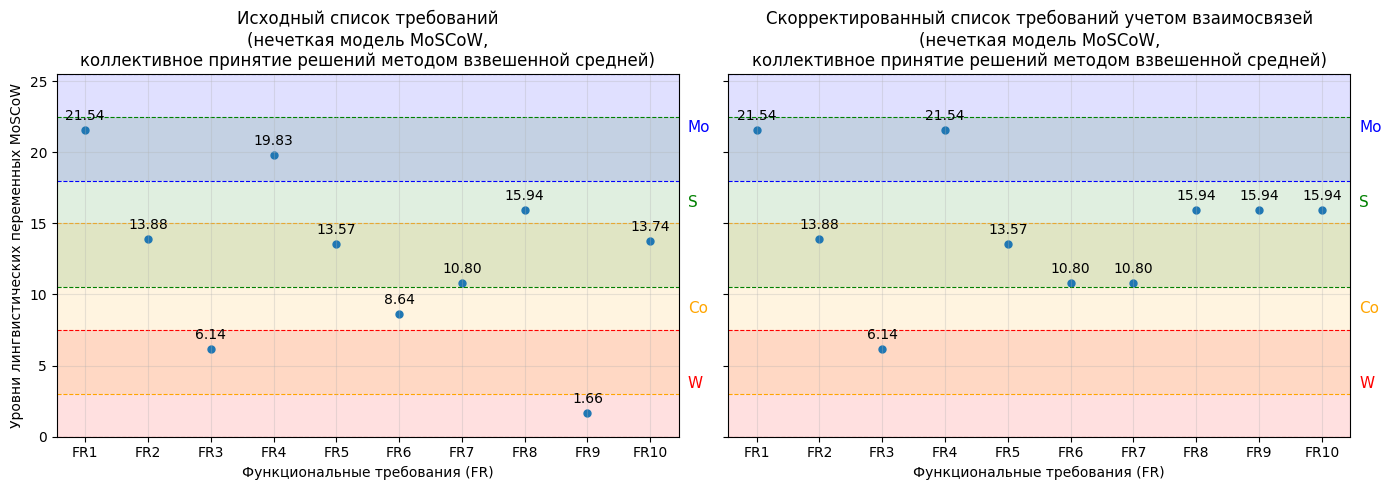

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразование результатов в словари: {FR: centroid} и {FR: adjusted_centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}
adjusted_centroid_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}

# Формирование списков FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    [r["fr"] for r in results_alpha],
    key=lambda x: int(x.replace("FR", ""))
)

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 7.5),
    "Co": (3.0, 15.0),
    "S":  (10.5, 22.5),
    "Mo": (18.0, 25.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель MoSCoW,\nколлективное принятие решений методом взвешенной средней)",
    "Скорректированный список требований учетом взаимосвязей\n(нечеткая модель MoSCoW,\nколлективное принятие решений методом взвешенной средней)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 25.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка из файла/ в файл Excel**

In [87]:
# Нечеткий метод приоритизации MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Решение принимается группой из произвольного числа экспертов, итоговая оценка вычисляется методом взвешенной средней.
# Веса экспертов четкие, изначально ненормализованные, в процессе реализации алгоритма выполняется их нормализация.
# Загрузка данных и выгрузка результатов - из файла / в файл Excel.

import re
from typing import Dict, Any, Sequence, Optional, List, Tuple
import pandas as pd
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# 1) Задание нечетких весов (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]

_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)

# 2. Нормализация обозначений приоритетов MoSCoW
def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")

    s = str(x).strip()
    s_upper = s.upper()

    if s_upper in {"MO", "M0"}:
        return "Mo"
    if s_upper == "CO":
        return "Co"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(
        f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W"
    )

# 3. Загрузка листа эксперта
def load_expert_sheet(ws) -> Dict[str, Any]:
    # 3.1. Поиск строки заголовков NFR
    nfr_header_row = None
    nfr_cols: List[int] = []
    nfr_names: List[str] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [
            c for c, v in enumerate(row_vals, start=1)
            if isinstance(v, str) and _nfr_pat.match(v.strip())
        ]
        if len(cols) >= 2:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 3.2. Поиск строки приоритетов NFR
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []

    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(
                f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}."
            )
        nfr_priorities.append(normalize_moscow_label(v))

    # 3.3. Поиск строки заголовков таблицы FR
    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(
            f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'."
        )

    # 3.4. Чтение строк FR
    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break

        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else normalize_moscow_label(v))

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {
        "sheet_name": ws.title,
        "nfr_names": nfr_names,
        "nfr": nfr_priorities,
        "fr_names": fr_names,
        "frs": fr_matrix
    }

# 4. Расчет нечетких PFR одного эксперта
def pfr_moscow_it2(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str] | None = None,
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]

    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(
            f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W"
        )

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(
                f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}."
            )

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(
                f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W"
            )

        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr_it2": pfr_it2,
            "ratings": list(fr_row),
        })

    return results

# 5. Групповая нечеткая оценка
def group_pfr_moscow_it2_k_experts(
    experts: Sequence[Dict[str, Any]],
    expert_weights: Sequence[float],
    fr_names: Sequence[str],
    normalize_weights: bool = True,
) -> Dict[str, Any]:

    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights):
        raise ValueError("Длины experts и expert_weights должны совпадать.")

    expert_names = [e["name"] for e in experts]
    w_raw = [float(x) for x in expert_weights]

    if normalize_weights:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов = 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    per_expert_pfr: Dict[str, Dict[str, IT2]] = {}
    for e in experts:
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)
        per_expert_pfr[e["name"]] = {item["fr"]: item["pfr_it2"] for item in res}

    group_pfr: Dict[str, IT2] = {}
    for fr in fr_names:
        acc: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for name, wi in zip(expert_names, w_norm):
            weighted = multiply_fuzzy_number_by_constant(per_expert_pfr[name][fr], wi)
            acc = add_intuitionistic_trapezoidal_fuzzy_numbers(acc, weighted)
        group_pfr[fr] = acc

    return {
        "expert_names": expert_names,
        "weights_raw": w_raw,
        "weights_norm": w_norm,
        "per_expert_pfr": per_expert_pfr,
        "group_pfr": group_pfr,
    }

# 6. Дефаззификация по схеме CLTR -> альфа-срез -> центроид
def defuzzify_group_pfr_rows(
    pfr_by_fr: Dict[str, IT2],
    a: float,
    alpha: float
) -> List[Dict[str, Any]]:

    rows = []

    for fr, it2 in pfr_by_fr.items():
        pfr_t1 = cltr_type_reduction(it2, a)
        cut = alpha_cut(pfr_t1, alpha)
        centroid_value = centroid(cut)

        (umf1, umf2, umf3, umf4), (lmf1, lmf2, lmf3, lmf4) = it2
        t1_1, t1_2, t1_3, t1_4 = pfr_t1
        cut_start, cut_end = cut

        rows.append({
            "fr": fr,
            "pfr_it2": it2,
            "pfr_t1": pfr_t1,
            "alpha_cut": cut,
            "centroid": centroid_value,
            "UMF_x1": float(umf1),
            "UMF_x2": float(umf2),
            "UMF_x3": float(umf3),
            "UMF_x4": float(umf4),
            "LMF_x1": float(lmf1),
            "LMF_x2": float(lmf2),
            "LMF_x3": float(lmf3),
            "LMF_x4": float(lmf4),
            "T1_x1": float(t1_1),
            "T1_x2": float(t1_2),
            "T1_x3": float(t1_3),
            "T1_x4": float(t1_4),
            "alpha_start": float(cut_start),
            "alpha_end": float(cut_end),
        })

    return sorted(rows, key=lambda x: x["centroid"], reverse=True)

# 7. Учет взаимосвязанности функциональных требований
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(
                f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1."
            )
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}"
            )
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

# 8. Подготовка таблиц для экспертов
def build_expert_detailed_rows(
    pfr_by_fr: Dict[str, IT2],
    a: float,
    alpha: float,
    relation_matrix: Sequence[Sequence[int]]
) -> List[Dict[str, Any]]:

    ranked_rows = defuzzify_group_pfr_rows(
        pfr_by_fr=pfr_by_fr,
        a=a,
        alpha=alpha
    )

    adjusted_rows = adjust_fuzzy_ranked_by_interdependencies(
        ranked_list=ranked_rows,
        relation_matrix=relation_matrix
    )

    adjusted_map = {item["fr"]: item["adjusted_centroid"] for item in adjusted_rows}

    combined_rows = []
    for item in ranked_rows:
        new_item = dict(item)
        new_item["adjusted_centroid"] = float(adjusted_map[item["fr"]])
        combined_rows.append(new_item)

    combined_rows_sorted = sorted(
        combined_rows,
        key=lambda x: (-x["adjusted_centroid"], -x["centroid"], x["fr"])
    )

    return combined_rows_sorted

def group_final_to_dataframe(
    ranked_rows: List[Dict[str, Any]]
) -> pd.DataFrame:
    rows = []
    for idx, item in enumerate(ranked_rows, start=1):
        rows.append({
            "Место": idx,
            "FR": item["fr"],
            "UMF_x1": float(item["UMF_x1"]),
            "UMF_x2": float(item["UMF_x2"]),
            "UMF_x3": float(item["UMF_x3"]),
            "UMF_x4": float(item["UMF_x4"]),
            "LMF_x1": float(item["LMF_x1"]),
            "LMF_x2": float(item["LMF_x2"]),
            "LMF_x3": float(item["LMF_x3"]),
            "LMF_x4": float(item["LMF_x4"]),
            "T1_x1": float(item["T1_x1"]),
            "T1_x2": float(item["T1_x2"]),
            "T1_x3": float(item["T1_x3"]),
            "T1_x4": float(item["T1_x4"]),
            "alpha_start": float(item["alpha_start"]),
            "alpha_end": float(item["alpha_end"]),
            "centroid": float(item["centroid"]),
        })
    return pd.DataFrame(rows)

def adjusted_group_to_dataframe(
    adjusted_rows: List[Dict[str, Any]]
) -> pd.DataFrame:
    rows = []
    for idx, item in enumerate(adjusted_rows, start=1):
        rows.append({
            "Место": idx,
            "FR": item["fr"],
            "Исходный центроид": float(item["centroid"]),
            "Скорректированный центроид": float(item["adjusted_centroid"]),
        })
    return pd.DataFrame(rows)

# 9. Настройка оформления Excel
def autosize_columns(ws, min_width: int = 12, max_width: int = 80, extra_padding: int = 3):
    merged_starts = set()
    merged_all = set()

    for merged_range in ws.merged_cells.ranges:
        min_col = merged_range.min_col
        min_row = merged_range.min_row
        merged_starts.add((min_row, min_col))

        for row in range(merged_range.min_row, merged_range.max_row + 1):
            for col in range(merged_range.min_col, merged_range.max_col + 1):
                merged_all.add((row, col))

    for col_cells in ws.columns:
        max_len = 0
        col_idx = col_cells[0].column

        for c in col_cells:
            coord = (c.row, c.column)

            if coord in merged_all:
                continue

            value = "" if c.value is None else str(c.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_len = max(max_len, longest)

        adjusted_width = max_len + extra_padding
        ws.column_dimensions[get_column_letter(col_idx)].width = max(
            min_width, min(adjusted_width, max_width)
        )

def autosize_rows(ws, base_height: float = 18.0, extra_padding: float = 3.0):
    for row_cells in ws.iter_rows():
        row_num = row_cells[0].row
        if ws.row_dimensions[row_num].height is not None:
            continue

        max_lines = 1
        max_text_len = 0

        for c in row_cells:
            value = "" if c.value is None else str(c.value)
            line_count = value.count("\n") + 1
            max_lines = max(max_lines, line_count)
            max_text_len = max(max_text_len, len(value))

        height = base_height * max_lines

        if max_text_len > 35:
            height += extra_padding

        if max_text_len > 60:
            height += extra_padding

        ws.row_dimensions[row_num].height = height

def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):

                if ws.title == "Матрица_взаимосвязей_FR":
                    cell.number_format = "0"

                elif ws.title in {"Нечеткий MoSCoW_расчеты", "Нечеткий MoSCoW_итоги"} and cell.column == 1:
                    cell.number_format = "0"

                else:
                    cell.number_format = "0.00"

def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

# 10. Лист с матрицей взаимосвязей
def write_relation_matrix_sheet(
    wb: openpyxl.Workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1), horizontal="left")
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(3, j, fr_name).font = header_font
        ws.cell(3, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for i, fr_name in enumerate(fr_names, start=4):
        ws.cell(i, 1, fr_name).font = header_font
        ws.cell(i, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, value)
            ws.cell(i, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)

    ws.column_dimensions["A"].width = 14

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 11. Универсальная таблица расчета по эксперту
def write_expert_calculation_table(
    ws,
    start_row: int,
    title: str,
    rows_sorted: List[Dict[str, Any]]
) -> int:
    header_font = Font(bold=True)
    center_wrap = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1, title).font = header_font
    apply_single_line_heading(ws.cell(start_row, 1), horizontal="left")
    ws.row_dimensions[start_row].height = 20

    header_row_1 = start_row + 1
    header_row_2 = start_row + 2

    ws.merge_cells(start_row=header_row_1, start_column=1, end_row=header_row_2, end_column=1)
    ws.merge_cells(start_row=header_row_1, start_column=2, end_row=header_row_2, end_column=2)
    ws.merge_cells(start_row=header_row_1, start_column=3, end_row=header_row_1, end_column=10)
    ws.merge_cells(start_row=header_row_1, start_column=11, end_row=header_row_1, end_column=14)
    ws.merge_cells(start_row=header_row_1, start_column=15, end_row=header_row_1, end_column=16)
    ws.merge_cells(start_row=header_row_1, start_column=17, end_row=header_row_2, end_column=17)
    ws.merge_cells(start_row=header_row_1, start_column=18, end_row=header_row_2, end_column=18)

    ws.cell(header_row_1, 1, "Место")
    ws.cell(header_row_1, 2, "FR")
    ws.cell(header_row_1, 3, "Итоговый приоритет функционального требования в виде ИНМТ2")
    ws.cell(header_row_1, 11, "Редуцированный приоритет FR в виде ИНМТ1")
    ws.cell(header_row_1, 15, "Дефаззификация (альфа-срез)")
    ws.cell(header_row_1, 17, "Центроид")
    ws.cell(header_row_1, 18, "Скорректированный центроид")

    for col in [1, 2, 3, 11, 15, 17, 18]:
        ws.cell(header_row_1, col).font = header_font
        ws.cell(header_row_1, col).alignment = center_wrap

    second_level_headers = [
        "UMF_x1", "UMF_x2", "UMF_x3", "UMF_x4",
        "LMF_x1", "LMF_x2", "LMF_x3", "LMF_x4",
        "T1_x1", "T1_x2", "T1_x3", "T1_x4",
        "alpha_start", "alpha_end"
    ]

    for idx, header in enumerate(second_level_headers, start=3):
        ws.cell(header_row_2, idx, header)
        ws.cell(header_row_2, idx).font = header_font
        ws.cell(header_row_2, idx).alignment = center_wrap

    ws.row_dimensions[header_row_1].height = 28
    ws.row_dimensions[header_row_2].height = 22

    r = start_row + 3
    for idx, item in enumerate(rows_sorted, start=1):
        ws.cell(r, 1, idx)
        ws.cell(r, 2, item["fr"])
        ws.cell(r, 3, float(item["UMF_x1"]))
        ws.cell(r, 4, float(item["UMF_x2"]))
        ws.cell(r, 5, float(item["UMF_x3"]))
        ws.cell(r, 6, float(item["UMF_x4"]))
        ws.cell(r, 7, float(item["LMF_x1"]))
        ws.cell(r, 8, float(item["LMF_x2"]))
        ws.cell(r, 9, float(item["LMF_x3"]))
        ws.cell(r, 10, float(item["LMF_x4"]))
        ws.cell(r, 11, float(item["T1_x1"]))
        ws.cell(r, 12, float(item["T1_x2"]))
        ws.cell(r, 13, float(item["T1_x3"]))
        ws.cell(r, 14, float(item["T1_x4"]))
        ws.cell(r, 15, float(item["alpha_start"]))
        ws.cell(r, 16, float(item["alpha_end"]))
        ws.cell(r, 17, float(item["centroid"]))
        ws.cell(r, 18, float(item["adjusted_centroid"]))

        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for c in range(3, 19):
            ws.cell(r, c).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        r += 1

    return r + 1

# 12. Лист расчетов
def write_fuzzy_group_calculations_sheet(
    wb: openpyxl.Workbook,
    expert_names: Sequence[str],
    weights_raw: Sequence[float],
    weights_norm: Sequence[float],
    expert_tables: Dict[str, List[Dict[str, Any]]],
    a: float,
    alpha: float,
    sheet_name: str = "Нечеткий MoSCoW_расчеты"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)
    center_wrap = Alignment(horizontal="center", vertical="center", wrap_text=True)

    r = 1

    ws.cell(r, 1, "Нечеткий MoSCoW - расчеты (коллективное решение, метод взвешенной средней)").font = title_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 2

    # 12.1. Веса экспертов
    ws.cell(r, 1, "1) Веса экспертов").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    headers = ["Эксперт", "Вес_raw", "Вес_norm"]
    for col_idx, header in enumerate(headers, start=1):
        ws.cell(r, col_idx, header).font = header_font
        ws.cell(r, col_idx).alignment = center_wrap
    r += 1

    for name, wr, wn in zip(expert_names, weights_raw, weights_norm):
        ws.cell(r, 1, name)
        ws.cell(r, 2, float(wr))
        ws.cell(r, 3, float(wn))
        ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = center_wrap
        ws.cell(r, 3).alignment = center_wrap
        r += 1

    ws.cell(r, 1, "SUM").font = header_font
    ws.cell(r, 2, float(sum(weights_raw))).font = header_font
    ws.cell(r, 3, float(sum(weights_norm))).font = header_font
    ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.cell(r, 2).alignment = center_wrap
    ws.cell(r, 3).alignment = center_wrap
    r += 2

    # 12.2. Параметры дефаззификации
    ws.cell(r, 1, "2) Параметры модели").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    ws.cell(r, 1, "Параметр").font = header_font
    ws.cell(r, 2, "Значение").font = header_font
    ws.cell(r, 1).alignment = center_wrap
    ws.cell(r, 2).alignment = center_wrap
    r += 1

    ws.cell(r, 1, "a (редукция типа CLTR)")
    ws.cell(r, 2, float(a))
    ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.cell(r, 2).alignment = center_wrap
    r += 1

    ws.cell(r, 1, "alpha (уровень альфа-среза)")
    ws.cell(r, 2, float(alpha))
    ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.cell(r, 2).alignment = center_wrap
    r += 2

    # 12.3. Таблицы экспертов
    ws.cell(r, 1, "3) Расчеты приоритизации по экспертам").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 2

    for expert_name in expert_names:
        r = write_expert_calculation_table(
            ws=ws,
            start_row=r,
            title=f"Эксперт: {expert_name}",
            rows_sorted=expert_tables[expert_name]
        )

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=24, extra_padding=4)

    ws.column_dimensions["A"].width = 30

    ws.column_dimensions["O"].width = 14
    ws.column_dimensions["P"].width = 14

    ws.column_dimensions["R"].width = 20

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 13. Лист итогов
def write_fuzzy_group_totals_sheet(
    wb: openpyxl.Workbook,
    df_group_final: pd.DataFrame,
    df_adjusted: pd.DataFrame,
    sheet_name: str = "Нечеткий MoSCoW_итоги"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)
    center_wrap = Alignment(horizontal="center", vertical="center", wrap_text=True)

    r = 1

    ws.cell(r, 1, "Нечеткий MoSCoW - итоги (коллективное решение, метод взвешенной средней)").font = title_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 2

    # 13.1. Итоговая таблица
    ws.cell(r, 1, "1) Итоговые нечеткие приоритеты и результаты дефаззификации").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    header_row_1 = r
    header_row_2 = r + 1

    ws.merge_cells(start_row=header_row_1, start_column=1, end_row=header_row_2, end_column=1)
    ws.merge_cells(start_row=header_row_1, start_column=2, end_row=header_row_2, end_column=2)
    ws.merge_cells(start_row=header_row_1, start_column=3, end_row=header_row_1, end_column=10)
    ws.merge_cells(start_row=header_row_1, start_column=11, end_row=header_row_1, end_column=14)
    ws.merge_cells(start_row=header_row_1, start_column=15, end_row=header_row_1, end_column=16)
    ws.merge_cells(start_row=header_row_1, start_column=17, end_row=header_row_2, end_column=17)

    ws.cell(header_row_1, 1, "Место")
    ws.cell(header_row_1, 2, "FR")
    ws.cell(header_row_1, 3, "Итоговый приоритет функционального требования в виде ИНМТ2")
    ws.cell(header_row_1, 11, "Редуцированный приоритет FR в виде ИНМТ1")
    ws.cell(header_row_1, 15, "Дефаззификация (альфа-срез)")
    ws.cell(header_row_1, 17, "Центроид")

    for col in [1, 2, 3, 11, 15, 17]:
        ws.cell(header_row_1, col).font = header_font
        ws.cell(header_row_1, col).alignment = center_wrap

    second_level_headers = [
        "UMF_x1", "UMF_x2", "UMF_x3", "UMF_x4",
        "LMF_x1", "LMF_x2", "LMF_x3", "LMF_x4",
        "T1_x1", "T1_x2", "T1_x3", "T1_x4",
        "alpha_start", "alpha_end"
    ]

    for idx, header in enumerate(second_level_headers, start=3):
        ws.cell(header_row_2, idx, header)
        ws.cell(header_row_2, idx).font = header_font
        ws.cell(header_row_2, idx).alignment = center_wrap

    ws.row_dimensions[header_row_1].height = 28
    ws.row_dimensions[header_row_2].height = 22

    r = header_row_2 + 1
    for _, row in df_group_final.iterrows():
        ws.cell(r, 1, int(row["Место"]))
        ws.cell(r, 2, row["FR"])
        ws.cell(r, 3, float(row["UMF_x1"]))
        ws.cell(r, 4, float(row["UMF_x2"]))
        ws.cell(r, 5, float(row["UMF_x3"]))
        ws.cell(r, 6, float(row["UMF_x4"]))
        ws.cell(r, 7, float(row["LMF_x1"]))
        ws.cell(r, 8, float(row["LMF_x2"]))
        ws.cell(r, 9, float(row["LMF_x3"]))
        ws.cell(r, 10, float(row["LMF_x4"]))
        ws.cell(r, 11, float(row["T1_x1"]))
        ws.cell(r, 12, float(row["T1_x2"]))
        ws.cell(r, 13, float(row["T1_x3"]))
        ws.cell(r, 14, float(row["T1_x4"]))
        ws.cell(r, 15, float(row["alpha_start"]))
        ws.cell(r, 16, float(row["alpha_end"]))
        ws.cell(r, 17, float(row["centroid"]))

        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for c in range(3, 18):
            ws.cell(r, c).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        r += 1

    r += 1

    # 13.2. Итоговая приоритизация после учета взаимосвязанности
    ws.cell(r, 1, "2) Итоговая приоритизация после учета взаимосвязанности").font = header_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    adjusted_headers = [
        "Место",
        "FR",
        "Исходный центроид",
        "Скорректированный\nцентроид"
    ]
    for col_idx, header in enumerate(adjusted_headers, start=1):
        ws.cell(r, col_idx, header).font = header_font
        ws.cell(r, col_idx).alignment = center_wrap

    ws.row_dimensions[r].height = 34
    r += 1

    for _, row in df_adjusted.iterrows():
        ws.cell(r, 1, int(row["Место"]))
        ws.cell(r, 2, row["FR"])
        ws.cell(r, 3, float(row["Исходный центроид"]))
        ws.cell(r, 4, float(row["Скорректированный центроид"]))

        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = center_wrap
        ws.cell(r, 4).alignment = center_wrap

        r += 1

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)

    ws.column_dimensions["A"].width = 12

    ws.column_dimensions["O"].width = 14
    ws.column_dimensions["P"].width = 14

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 14. Основная функция запуска
def fuzzy_group_moscow_from_excel(
    in_path: str,
    out_path: Optional[str] = None,
    weights: Optional[Sequence[float]] = None,
    a: float = 0.6,
    alpha: float = 0.8,
    relation_matrix: Optional[Sequence[Sequence[int]]] = None,
    calculations_sheet_name: str = "Нечеткий MoSCoW_расчеты",
    totals_sheet_name: str = "Нечеткий MoSCoW_итоги",
    normalize_weights: bool = True,
    skip_result_sheets: bool = True,
    skip_sheets_without_nfr: bool = True,
) -> str:

    wb = openpyxl.load_workbook(in_path)

    experts_loaded: List[Dict[str, Any]] = []
    skipped: List[str] = []

    service_sheet_names = {
        calculations_sheet_name,
        totals_sheet_name,
        "Матрица_взаимосвязей_FR"
    }

    original_sheet_order = wb.sheetnames[:]

    for sname in original_sheet_order:
        if skip_result_sheets and sname in service_sheet_names:
            continue

        ws = wb[sname]
        try:
            data = load_expert_sheet(ws)
        except ValueError as e:
            if skip_sheets_without_nfr and "Не найдена строка заголовков NFR" in str(e):
                skipped.append(sname)
                continue
            raise

        experts_loaded.append({
            "name": data["sheet_name"],
            "nfr_names": data["nfr_names"],
            "nfr": data["nfr"],
            "fr_names": data["fr_names"],
            "frs": data["frs"],
        })

    if not experts_loaded:
        raise ValueError(f"Не найдено листов-экспертов с NFR-шапкой. Пропущено: {skipped}")

    base_fr_names = experts_loaded[0]["fr_names"]
    for e in experts_loaded[1:]:
        if e["fr_names"] != base_fr_names:
            raise ValueError("У экспертов разные списки FR (имена и порядок должны совпадать).")

    k = len(experts_loaded)

    if weights is None:
        weights_raw = [1.0] * k
    else:
        if len(weights) != k:
            raise ValueError(f"weights должен быть длины {k} (по числу экспертов/листов).")
        weights_raw = list(weights)

    group_pack = group_pfr_moscow_it2_k_experts(
        experts=experts_loaded,
        expert_weights=weights_raw,
        fr_names=base_fr_names,
        normalize_weights=normalize_weights,
    )

    expert_names = group_pack["expert_names"]
    w_raw = group_pack["weights_raw"]
    w_norm = group_pack["weights_norm"]

    n_fr = len(base_fr_names)
    if relation_matrix is None:
        relation_matrix = [[1 if i == j else 0 for j in range(n_fr)] for i in range(n_fr)]

    if len(relation_matrix) != n_fr or any(len(row) != n_fr for row in relation_matrix):
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n_fr}x{n_fr}.")

    ranked_group_rows = defuzzify_group_pfr_rows(
        pfr_by_fr=group_pack["group_pfr"],
        a=a,
        alpha=alpha
    )

    adjusted_rows = adjust_fuzzy_ranked_by_interdependencies(
        ranked_list=ranked_group_rows,
        relation_matrix=relation_matrix
    )

    expert_tables: Dict[str, List[Dict[str, Any]]] = {}
    for expert_name in expert_names:
        expert_tables[expert_name] = build_expert_detailed_rows(
            pfr_by_fr=group_pack["per_expert_pfr"][expert_name],
            a=a,
            alpha=alpha,
            relation_matrix=relation_matrix
        )

    df_group_final = group_final_to_dataframe(ranked_group_rows)
    df_adjusted = adjusted_group_to_dataframe(adjusted_rows)

    write_relation_matrix_sheet(
        wb=wb,
        fr_names=base_fr_names,
        relation_matrix=relation_matrix,
        sheet_name="Матрица_взаимосвязей_FR"
    )

    write_fuzzy_group_calculations_sheet(
        wb=wb,
        expert_names=expert_names,
        weights_raw=w_raw,
        weights_norm=w_norm,
        expert_tables=expert_tables,
        a=a,
        alpha=alpha,
        sheet_name=calculations_sheet_name
    )

    write_fuzzy_group_totals_sheet(
        wb=wb,
        df_group_final=df_group_final,
        df_adjusted=df_adjusted,
        sheet_name=totals_sheet_name
    )

    expert_sheet_names = [e["name"] for e in experts_loaded]
    desired_order = expert_sheet_names + [
        "Матрица_взаимосвязей_FR",
        calculations_sheet_name,
        totals_sheet_name
    ]
    wb._sheets = [wb[name] for name in desired_order if name in wb.sheetnames]

    if out_path is None:
        out_path = in_path

    wb.save(out_path)
    return out_path

In [88]:
# Запуск
relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR1 связано с FR4
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # FR2
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # FR3
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR4 связано с FR1
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # FR5
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR6 связано с FR7
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR7 связано с FR6
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR8 связано с FR9 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR9 связано с FR8 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR10 связано с FR8 и FR9
]

in_file = "Загрузочные данные_MoSCoW_коллектив.xlsx"
out_file = "Итоги_Fuzzy MoSCoW_взвешенные средние.xlsx"

saved_path = fuzzy_group_moscow_from_excel(
    in_path=in_file,
    out_path=out_file,
    weights=[0.75, 0.75, 1.0],
    a=0.6,
    alpha=0.8,
    relation_matrix=relation_matrix,
    calculations_sheet_name="Нечеткий MoSCoW_расчеты",
    totals_sheet_name="Нечеткий MoSCoW_итоги",
    normalize_weights=True,
)

print("Файл сохранен:", saved_path)

Файл сохранен: Итоги_Fuzzy MoSCoW_взвешенные средние.xlsx


# 2.1.2. Четкий MoSCoW + взвешенные средние (КПР) для сравнения с нечетким алгоритмом

**Реализация четкого MoSCoW, когда решение принимается группой экспертов. Загрузка и выгрузка в ноутбуке**

In [89]:
# Алгоритм, когда решение принимается произвольным числом экспертов
# с произвольным числом функциональных (FR) и нефункциональных (NFR) требований

from typing import List, Sequence, Dict, Any, Tuple

MOSCOW_NFR_WEIGHTS = {"Mo": 8.0, "S": 5.5, "Co": 3.0, "W": 0.5}
MOSCOW_FR_REL_WEIGHTS = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}

def pfr_moscow_scores(
    nfr_priorities: Sequence[str],                 # ["Mo","Co","S"]
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # [["Mo","S","Mo"], ...]
    fr_names: Sequence[str] | None = None,
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # веса NFR
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    scores: Dict[str, float] = {}
    for name, ratings in zip(fr_names, fr_vs_nfr_priorities):
        if len(ratings) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(ratings)}.")

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in ratings]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение {e}. Допустимо: Mo, S, Co, W")

        scores[name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores

def weighted_group_moscow_k_experts(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> Tuple[List[Dict[str, Any]], Dict[str, float]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    # проверим, что у всех экспертов одинаковое количество FR
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов (фиксируем один раз, чтобы не было рассинхронизации)
    expert_names = [experts[i].get("name", f"S{i+1}") for i in range(len(experts))]

    # нормировка весов (по умолчанию включена)
    w_raw = list(weights)
    if normalize_weights:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]  # исходные данные

    weights_norm_by_name: Dict[str, float] = {expert_names[i]: w_norm[i] for i in range(len(experts))}

    # считаем оценки каждого эксперта: от FR к PFR
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = pfr_moscow_scores(e["nfr"], e["frs"], fr_names=fr_names)

    # итоговая взвешенная средняя по каждому FR
    results: List[Dict[str, Any]] = []
    for fr in fr_names:
        group_pfr = 0.0
        by_expert: Dict[str, float] = {}

        for name, wi in zip(expert_names, w_norm):
            score = expert_scores[name][fr]
            by_expert[name] = score
            group_pfr += wi * score

        results.append({
            "fr": fr,
            "group_pfr": group_pfr,
            "by_expert": by_expert,
            # в каждой строке
            "weights_norm": weights_norm_by_name,
            "weights_raw": {expert_names[i]: w_raw[i] for i in range(len(experts))},
        })

    return sorted(results, key=lambda x: x["group_pfr"], reverse=True), weights_norm_by_name


In [90]:
# пример: 3 эксперта
S1 = {
    "name": "S1",
    "nfr": ["Mo", "Mo", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "S", "Mo"],
        ["S",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["S",  "Co", "S"],
        ["Co", "Co",  "Co"],
        ["S", "S",  "W"],
        ["S",  "S", "S"],
        ["W",  "W", "W"],
        ["Co", "Co", "Mo"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "S", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "Mo", "Mo"],
        ["S",  "Co",  "W"],
        ["Mo", "Mo",  "Mo"],
        ["S",  "S", "S"],
        ["Co", "S",  "Co"],
        ["S", "Mo",  "W"],
        ["S",  "Mo", "S"],
        ["W",  "Co", "W"],
        ["Co", "S", "Mo"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["S", "Mo", "Mo"],
    "frs": [
       ["Mo", "Mo",  "Mo"],
        ["Co", "S", "Mo"],
        ["Mo",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["Mo",  "Co", "S"],
        ["S", "Co",  "Co"],
        ["Mo", "S",  "W"],
        ["Mo",  "S", "S"],
        ["Co",  "W", "W"],
        ["S", "Co", "Mo"],
    ]
}

experts = [S1, S2, S3]
weights = [0.75, 0.75, 1]  # ненормализованные веса

# Возвращаются results_sorted, weights_norm_by_name
group_ranked, weights_norm = weighted_group_moscow_k_experts(experts, weights)

# вывод нормализованных весов
weights_norm_rounded = {k: round(v, 2) for k, v in weights_norm.items()}
print(f"Normalized weights: {weights_norm_rounded}\n")

# вывод результатов
for item in group_ranked:
    by_expert_rounded = {k: round(v, 2) for k, v in item["by_expert"].items()}
    print(f"{item['fr']}: group={item['group_pfr']:.2f} | by_expert={by_expert_rounded}")


Normalized weights: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

FR1: group=22.25 | by_expert={'S1': 24.0, 'S2': 21.5, 'S3': 21.5}
FR4: group=20.35 | by_expert={'S1': 21.28, 'S2': 21.5, 'S3': 18.78}
FR8: group=15.99 | by_expert={'S1': 15.84, 'S2': 16.06, 'S3': 16.06}
FR2: group=14.07 | by_expert={'S1': 13.28, 'S2': 13.5, 'S3': 15.1}
FR10: group=13.97 | by_expert={'S1': 13.28, 'S2': 14.27, 'S3': 14.27}
FR5: group=13.59 | by_expert={'S1': 13.2, 'S2': 14.19, 'S3': 13.42}
FR7: group=10.71 | by_expert={'S1': 10.56, 'S2': 10.78, 'S3': 10.78}
FR6: group=8.61 | by_expert={'S1': 7.92, 'S2': 8.91, 'S3': 8.91}
FR3: group=5.91 | by_expert={'S1': 5.28, 'S2': 7.1, 'S3': 5.5}
FR9: group=1.27 | by_expert={'S1': 0.0, 'S2': 1.82, 'S3': 1.82}


Алгоритм учета взаимосвязанности функциональных требований

In [91]:
def adjust_group_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_group_pfr"] = item["group_pfr"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_group_pfr = max(matrix_idx_to_item[i]["group_pfr"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_group_pfr"] = max_group_pfr

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_group_pfr"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [92]:
# Матрица взаимосвязей 10x10
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_group_ranked = adjust_group_ranked_by_interdependencies(group_ranked, relation_matrix)

print("\nСкорректированный ранжированный список:")
for item in adjusted_group_ranked:
    print(
        f"{item['fr']}: "
        f"исходный group_pfr = {round(item['group_pfr'], 2)}, "
        f"скорректированный group_pfr = {round(item['adjusted_group_pfr'], 2)}"
    )


Скорректированный ранжированный список:
FR1: исходный group_pfr = 22.25, скорректированный group_pfr = 22.25
FR4: исходный group_pfr = 20.35, скорректированный group_pfr = 22.25
FR8: исходный group_pfr = 15.99, скорректированный group_pfr = 15.99
FR10: исходный group_pfr = 13.97, скорректированный group_pfr = 15.99
FR9: исходный group_pfr = 1.27, скорректированный group_pfr = 15.99
FR2: исходный group_pfr = 14.07, скорректированный group_pfr = 14.07
FR5: исходный group_pfr = 13.59, скорректированный group_pfr = 13.59
FR7: исходный group_pfr = 10.71, скорректированный group_pfr = 10.71
FR6: исходный group_pfr = 8.61, скорректированный group_pfr = 10.71
FR3: исходный group_pfr = 5.91, скорректированный group_pfr = 5.91


Визуализации исходного и итогового приоритизированного списков функциональных требований

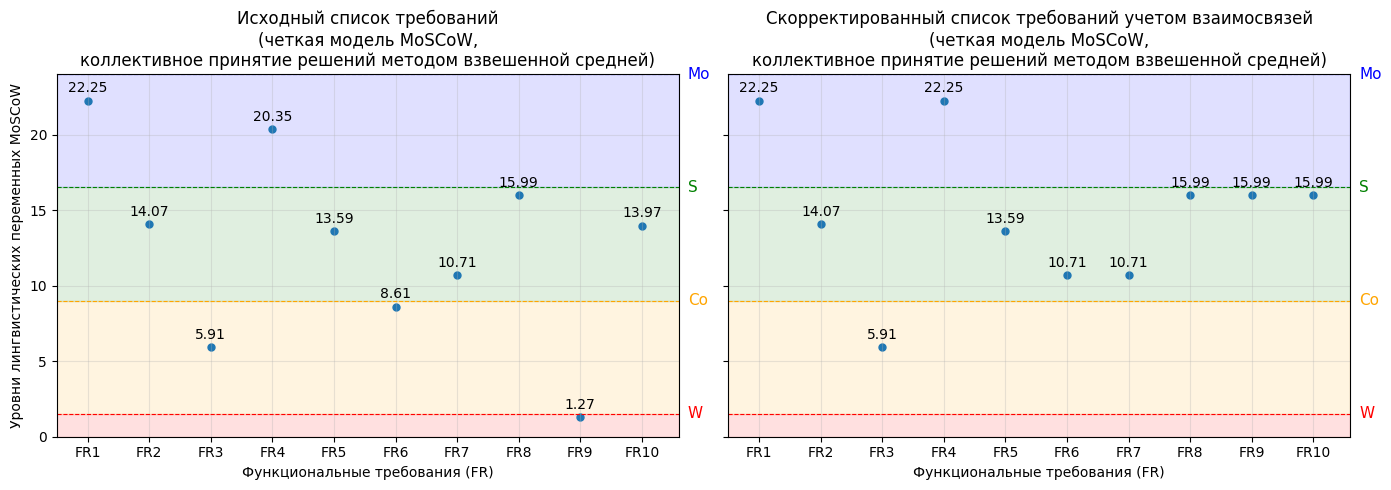

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразование результатов в словари: {FR: group_pfr} и {FR: adjusted_group_pfr}
pfr_by_fr = {item["fr"]: item["group_pfr"] for item in group_ranked}
adjusted_pfr_by_fr = {item["fr"]: item["adjusted_group_pfr"] for item in adjusted_group_ranked}

# Формирование списка FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    [item["fr"] for item in group_ranked],
    key=lambda x: int(x.replace("FR", ""))
)

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [pfr_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_pfr_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (16.5, 24.0),
    "S": (9.0, 16.5),
    "Co": (1.5, 9.0),
    "W": (0, 1.5)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 24.0,
    "S": 16.5,
    "Co": 9.0,
    "W": 1.5
}

boundary_lines = [1.5, 9.0, 16.5, 24.0]
boundary_colors = {
    1.5: "red",
    9.0: "orange",
    16.5: "green",
    24.0: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель MoSCoW,\nколлективное принятие решений методом взвешенной средней)",
    "Скорректированный список требований учетом взаимосвязей\n(четкая модель MoSCoW,\nколлективное принятие решений методом взвешенной средней)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.25
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 24)
    ax.set_xlim(-0.5, len(fr_labels) - 0.4)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка из файла/ в файл Excel**

In [94]:
# Алгоритм, когда решение принимается произвольным числом экспертов.
# Загрузка и выгрузка данных - из файла / в файл Excel.

import re
from typing import List, Sequence, Dict, Any, Optional
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter


# 1. Четкие веса MoSCoW
MOSCOW_NFR_WEIGHTS = {"Mo": 8.0, "S": 5.5, "Co": 3.0, "W": 0.5}
MOSCOW_FR_REL_WEIGHTS = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}


# 2. Нормализация обозначений приоритетов MoSCoW
def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")

    s = str(x).strip()
    s_upper = s.upper()

    if s_upper in {"MO", "M0"}:
        return "Mo"
    if s_upper == "CO":
        return "Co"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(
        f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W"
    )


# 3. Алгоритм расчета для одного эксперта
def pfr_moscow_ranked(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str] | None = None,
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]

    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[normalize_moscow_label(x)] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(
            f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W"
        )

    results: List[Dict[str, Any]] = []
    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(
                f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}."
            )

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[normalize_moscow_label(x)] for x in fr_row]
        except KeyError as e:
            raise ValueError(
                f"{name}: недопустимое значение {e}. Допустимо: Mo, S, Co, W"
            )

        pfr = sum(w_nfr * w_fr for w_nfr, w_fr in zip(nfr_w, fr_w))
        results.append({"fr": name, "pfr": float(pfr), "ratings": list(fr_row)})

    return sorted(results, key=lambda x: x["pfr"], reverse=True)


def pfr_moscow_scores(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    ranked = pfr_moscow_ranked(nfr_priorities, fr_vs_nfr_priorities, fr_names=fr_names)
    return {x["fr"]: x["pfr"] for x in ranked}


# 4. Считывание листа эксперта из шаблона
_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)


def load_expert_sheet(ws) -> Dict[str, Any]:
    # 4.1. Поиск строки заголовков NFR
    nfr_header_row = None
    nfr_cols = []
    nfr_names = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [
            c for c, v in enumerate(row_vals, start=1)
            if isinstance(v, str) and _nfr_pat.match(v.strip())
        ]
        if len(cols) >= 2:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 4.2. Поиск строки приоритетов NFR
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(
                f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}."
            )
        nfr_priorities.append(normalize_moscow_label(v))

    # 4.3. Поиск шапки таблицы FR
    fr_header_row = None
    fr_cols = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(
            f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'."
        )

    # 4.4. Считывание FR-строк
    fr_names = []
    fr_matrix = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break

        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else normalize_moscow_label(v))

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {
        "sheet_name": ws.title,
        "nfr_names": nfr_names,
        "nfr_priorities": nfr_priorities,
        "fr_names": fr_names,
        "fr_vs_nfr": fr_matrix,
    }


# 5. Учет взаимосвязанности функциональных требований
def adjust_group_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(
                f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1."
            )
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}"
            )
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_group_pfr"] = item["group_pfr"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_group_pfr = max(matrix_idx_to_item[i]["group_pfr"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_group_pfr"] = max_group_pfr

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_group_pfr"], x["original_rank"])
    )

    return adjusted_sorted


# 6. Настройка оформления Excel
def autosize_columns(ws, min_width: int = 12, max_width: int = 80, extra_padding: int = 3):
    for col_cells in ws.columns:
        max_len = 0
        col_idx = col_cells[0].column

        for c in col_cells:
            value = "" if c.value is None else str(c.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_len = max(max_len, longest)

        adjusted_width = max_len + extra_padding
        ws.column_dimensions[get_column_letter(col_idx)].width = max(
            min_width, min(adjusted_width, max_width)
        )


def autosize_rows(ws, base_height: float = 18.0, extra_padding: float = 3.0):
    for row_cells in ws.iter_rows():
        row_num = row_cells[0].row
        if ws.row_dimensions[row_num].height is not None:
            continue

        max_lines = 1
        max_text_len = 0

        for c in row_cells:
            value = "" if c.value is None else str(c.value)
            line_count = value.count("\n") + 1
            max_lines = max(max_lines, line_count)
            max_text_len = max(max_text_len, len(value))

        height = base_height * max_lines

        if max_text_len > 35:
            height += extra_padding

        if max_text_len > 60:
            height += extra_padding

        ws.row_dimensions[row_num].height = height


def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):

                if ws.title == "Матрица_взаимосвязей_FR":
                    cell.number_format = "0"

                elif ws.title == "Четкий MoSCoW_коллектив" and cell.column == 1:
                    cell.number_format = "0"

                else:
                    cell.number_format = "0.00"


def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)


# 7. Лист с матрицей взаимосвязей
def write_relation_matrix_sheet(
    wb: openpyxl.Workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1), horizontal="left")
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(3, j, fr_name).font = header_font
        ws.cell(3, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for i, fr_name in enumerate(fr_names, start=4):
        ws.cell(i, 1, fr_name).font = header_font
        ws.cell(i, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, value)
            ws.cell(i, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)

    ws.column_dimensions["A"].width = 14

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)


# 8. Лист итогов
def write_group_result_sheet(
    wb: openpyxl.Workbook,
    expert_names: Sequence[str],
    weights_raw: Sequence[float],
    weights_norm: Sequence[float],
    rows_sorted: List[Dict[str, Any]],
    adjusted_rows_sorted: List[Dict[str, Any]],
    sheet_name: str = "Четкий MoSCoW_коллектив"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    bold = Font(bold=True)
    title_font = Font(bold=True, size=12)
    center_wrap = Alignment(horizontal="center", vertical="center", wrap_text=True)

    r = 1

    ws.cell(r, 1, "Четкий MoSCoW - итоговая приоритизация (коллективное решение, метод взвешенной средней)").font = title_font
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 2

    ws.cell(r, 1, "1) Веса экспертов").font = bold
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    headers = ["Эксперт", "Вес_raw", "Вес_norm"]
    for col_idx, header in enumerate(headers, start=1):
        ws.cell(r, col_idx, header).font = bold
        ws.cell(r, col_idx).alignment = center_wrap
    r += 1

    for name, w_raw, w_norm in zip(expert_names, weights_raw, weights_norm):
        ws.cell(r, 1, name)
        ws.cell(r, 2, float(w_raw))
        ws.cell(r, 3, float(w_norm))
        ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = center_wrap
        ws.cell(r, 3).alignment = center_wrap
        r += 1

    ws.cell(r, 1, "SUM").font = bold
    ws.cell(r, 2, float(sum(weights_raw))).font = bold
    ws.cell(r, 3, float(sum(weights_norm))).font = bold
    ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.cell(r, 2).alignment = center_wrap
    ws.cell(r, 3).alignment = center_wrap
    r += 2

    ws.cell(r, 1, "2) Групповая приоритизация FR методом взвешенной средней").font = bold
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    main_headers = ["Место", "FR"] + [f"PFR_{name}" for name in expert_names] + ["PFR_group"]
    for col_idx, header in enumerate(main_headers, start=1):
        ws.cell(r, col_idx, header).font = bold
        ws.cell(r, col_idx).alignment = center_wrap
    r += 1

    for idx, item in enumerate(rows_sorted, start=1):
        ws.cell(r, 1, idx)
        ws.cell(r, 2, item["FR"])
        ws.cell(r, 1).alignment = center_wrap
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for j, name in enumerate(expert_names, start=3):
            ws.cell(r, j, float(item["by_expert"][name]))
            ws.cell(r, j).alignment = center_wrap

        last_col = 3 + len(expert_names)
        ws.cell(r, last_col, float(item["PFR_group"]))
        ws.cell(r, last_col).alignment = center_wrap
        r += 1

    r += 1

    ws.cell(r, 1, "3) Групповая приоритизация FR с учетом взаимосвязанности").font = bold
    apply_single_line_heading(ws.cell(r, 1), horizontal="left")
    ws.row_dimensions[r].height = 20
    r += 1

    adjusted_headers = ["Место", "FR", "Исходный PFR_group", "Скорректированный PFR_group"]
    for col_idx, header in enumerate(adjusted_headers, start=1):
        ws.cell(r, col_idx, header).font = bold
        ws.cell(r, col_idx).alignment = center_wrap
    r += 1

    for idx, item in enumerate(adjusted_rows_sorted, start=1):
        ws.cell(r, 1, idx)
        ws.cell(r, 2, item["fr"])
        ws.cell(r, 3, float(item["group_pfr"]))
        ws.cell(r, 4, float(item["adjusted_group_pfr"]))

        ws.cell(r, 1).alignment = center_wrap
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = center_wrap
        ws.cell(r, 4).alignment = center_wrap
        r += 1

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)

    ws.column_dimensions["A"].width = 22
    ws.column_dimensions["B"].width = 12

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 9. Групповая оценка + запись в Excel
def group_moscow_from_excel(
    in_path: str,
    out_path: Optional[str] = None,
    weights: Optional[Sequence[float]] = None,
    relation_matrix: Optional[Sequence[Sequence[int]]] = None,
    result_sheet_name: str = "Четкий MoSCoW_коллектив",
    normalize_weights: bool = True,
) -> str:
    wb = openpyxl.load_workbook(in_path)

    experts = []
    skipped_sheets = []

    for sname in wb.sheetnames:
        if sname in {result_sheet_name, "Матрица_взаимосвязей_FR"}:
            continue

        ws = wb[sname]

        try:
            data = load_expert_sheet(ws)
        except ValueError as e:
            msg = str(e)
            if "Не найдена строка заголовков NFR" in msg:
                skipped_sheets.append(sname)
                continue
            raise

        experts.append(data)

    k = len(experts)
    if k == 0:
        raise ValueError(
            "Не найдено ни одного листа-эксперта с NFR-шапкой. "
            f"Пропущено листов: {skipped_sheets}"
        )

    expert_names = [e["sheet_name"] for e in experts]

    if weights is None:
        weights_raw = [1.0] * k
    else:
        if len(weights) != k:
            raise ValueError(f"weights должен быть длины {k} (по числу листов-экспертов).")
        weights_raw = list(weights)

    if normalize_weights:
        s = sum(weights_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 - невозможно нормировать.")
        weights_norm = [x / s for x in weights_raw]
    else:
        weights_norm = weights_raw[:]

    base_fr = experts[0]["fr_names"]
    base_nfr_count = len(experts[0]["nfr_names"])

    for e in experts[1:]:
        if e["fr_names"] != base_fr:
            raise ValueError("У экспертов разные списки FR (имена/порядок должны совпадать).")
        if len(e["nfr_names"]) != base_nfr_count:
            raise ValueError("У экспертов разное число NFR (количество столбцов NFR должно совпадать).")

    expert_scores: Dict[str, Dict[str, float]] = {}
    for e in experts:
        name = e["sheet_name"]
        expert_scores[name] = pfr_moscow_scores(
            e["nfr_priorities"],
            e["fr_vs_nfr"],
            fr_names=base_fr
        )

    rows = []
    for fr in base_fr:
        group_pfr = 0.0
        by_expert = {}
        for name, wi_norm in zip(expert_names, weights_norm):
            sc = expert_scores[name][fr]
            by_expert[name] = float(sc)
            group_pfr += wi_norm * sc

        rows.append({
            "FR": fr,
            "PFR_group": float(group_pfr),
            "by_expert": by_expert,
        })

    rows_sorted = sorted(rows, key=lambda x: x["PFR_group"], reverse=True)

    ranked_for_adjustment = []
    for item in rows_sorted:
        ranked_for_adjustment.append({
            "fr": item["FR"],
            "group_pfr": item["PFR_group"],
            "by_expert": item["by_expert"],
        })

    n_fr = len(base_fr)
    if relation_matrix is None:
        relation_matrix = [[1 if i == j else 0 for j in range(n_fr)] for i in range(n_fr)]

    adjusted_rows_sorted = adjust_group_ranked_by_interdependencies(
        ranked_list=ranked_for_adjustment,
        relation_matrix=relation_matrix
    )

    write_relation_matrix_sheet(
        wb=wb,
        fr_names=base_fr,
        relation_matrix=relation_matrix,
        sheet_name="Матрица_взаимосвязей_FR"
    )

    write_group_result_sheet(
        wb=wb,
        expert_names=expert_names,
        weights_raw=weights_raw,
        weights_norm=weights_norm,
        rows_sorted=rows_sorted,
        adjusted_rows_sorted=adjusted_rows_sorted,
        sheet_name=result_sheet_name
    )

    desired_order = expert_names + ["Матрица_взаимосвязей_FR", result_sheet_name]
    wb._sheets = [wb[name] for name in desired_order if name in wb.sheetnames]

    if out_path is None:
        out_path = in_path

    wb.save(out_path)
    return out_path

In [95]:
# Запуск
relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR1 связано с FR4
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # FR2
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # FR3
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR4 связано с FR1
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # FR5
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR6 связано с FR7
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR7 связано с FR6
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR8 связано с FR9 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR9 связано с FR8 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR10 связано с FR8 и FR9
]

in_file = "Загрузочные данные_MoSCoW_коллектив.xlsx"
out_file = "Итоги_четкий MoSCoW_взвешенные средние.xlsx"

saved_path = group_moscow_from_excel(
    in_path=in_file,
    out_path=out_file,
    weights=[0.75, 0.75, 1],
    relation_matrix=relation_matrix,
    result_sheet_name="Четкий MoSCoW_коллектив",
    normalize_weights=True
)

print("Saved to:", saved_path)

Saved to: Итоги_четкий MoSCoW_взвешенные средние.xlsx


# 2.2. Коллективное принятие решений при наличии консенсуса

# 2.2.1. Fuzzy_MoSCoW + Алгоритм Hsu 1996 для коллективного принятия решений

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://www.sciencedirect.com/science/article/pii/0165011495001859

Hsu H.-M., Chen C.-T. Aggregation of fuzzy opinions under group decision making // Fuzzy sets and systems. 1996 May 13;79(3). PP. 279-285

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [96]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [97]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [98]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [99]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [100]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [101]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [102]:
# Нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задание нечетких весов (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразование NFR-термов в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразование FR_NFR термов в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FR_NFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results


In [103]:
# Расширение нечеткого MoSCoW для группы экспертов
EPS = 1e-12

def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]


def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],       # r_i (ненормализованные)
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    # проверка размерности
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов
    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    # веса: от raw к norm
    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    # Для каждого эксперта считаем IT2 PFR по всем FR
    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        # pfr_moscow_it2 в коде выше, возвращает список:
        # [{"fr": "FR1", "pfr": IT2}, ...]
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)

        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared

In [104]:
# Пример для группы из трех экспертов
# Четкие ненормализованные веса экспертов
W_S1 = 0.75
W_S2 = 0.75
W_S3 = 1

S1 = {
    "name": "S1",
    "nfr": ["Mo", "Mo", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "S", "Mo"],
        ["S",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["S",  "Co", "S"],
        ["Co", "Co",  "Co"],
        ["S", "S",  "W"],
        ["S",  "S", "S"],
        ["W",  "W", "W"],
        ["Co", "Co", "Mo"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "S", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "Mo", "Mo"],
        ["S",  "Co",  "W"],
        ["Mo", "Mo",  "Mo"],
        ["S",  "S", "S"],
        ["Co", "S",  "Co"],
        ["S", "Mo",  "W"],
        ["S",  "Mo", "S"],
        ["W",  "Co", "W"],
        ["Co", "S", "Mo"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["S", "Mo", "Mo"],
    "frs": [
       ["Mo", "Mo",  "Mo"],
        ["Co", "S", "Mo"],
        ["Mo",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["Mo",  "Co", "S"],
        ["S", "Co",  "Co"],
        ["Mo", "S",  "W"],
        ["Mo",  "S", "S"],
        ["Co",  "W", "W"],
        ["S", "Co", "Mo"],
    ]
}
experts = [S1, S2, S3]
weights = [W_S1, W_S2, W_S3]  # ненормализованные

# имена FR (если не задать - будут FR1..FRm)
fr_names = [f"FR{i}" for i in range(1, len(S1["frs"]) + 1)]

prepared_experts = prepare_moscow_it2_inputs(
    experts=experts,
    expert_weights_raw=weights,
    fr_names=fr_names,
    normalize_weights=True,
)

print("Веса экспертов")
print("r (raw):", {e["name"]: round(e["r"], 2) for e in prepared_experts})
print("w (norm):", {e["name"]: round(e["w"], 2) for e in prepared_experts})

print("\nIT2-оценки PFR каждого эксперта по всем FR")
for e in prepared_experts:
    print(f"\nЭксперт {e['name']}:")
    for fr in fr_names:
        print(f"  {fr}: {e['ratings'][fr]}")



Веса экспертов
r (raw): {'S1': 0.75, 'S2': 0.75, 'S3': 1.0}
w (norm): {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

IT2-оценки PFR каждого эксперта по всем FR

Эксперт S1:
  FR1: ((12.83, 22.5, 25.5, 25.5), (15.0, 22.5, 25.5, 25.5))
  FR2: ((6.76, 11.62, 15.04, 17.94), (7.98, 11.62, 15.04, 17.08))
  FR3: ((2.48, 4.12, 6.54, 11.31), (2.98, 4.12, 6.54, 9.86))
  FR4: ((11.04, 19.12, 23.54, 24.57), (12.97, 19.12, 23.54, 24.31))
  FR5: ((4.96, 9.89, 16.82, 19.82), (6.19, 9.89, 16.82, 19.04))
  FR6: ((0.0, 4.95, 11.22, 14.04), (0.69, 4.95, 11.22, 13.26))
  FR7: ((4.96, 8.25, 13.09, 17.01), (5.96, 8.25, 13.09, 15.89))
  FR8: ((7.44, 12.38, 19.63, 22.71), (8.94, 12.38, 19.63, 21.93))
  FR9: ((0.0, 0.0, 0.0, 5.61), (0.0, 0.0, 0.0, 3.81))
  FR10: ((4.28, 10.8, 15.98, 17.86), (5.46, 10.8, 15.98, 17.34))

Эксперт S2:
  FR1: ((10.91, 20.0, 23.0, 24.5), (13.0, 20.0, 23.0, 24.0))
  FR2: ((6.62, 12.5, 14.5, 17.87), (8.0, 12.5, 14.5, 16.77))
  FR3: ((2.48, 5.22, 9.18, 13.4), (3.06, 5.22, 9.18, 12.14))
  FR4: ((10

In [105]:
# Построение матрицы согласия для любого числа нечетких оценок

type Trap = tuple[float, float, float, float]
type IT2Trap = tuple[Trap, Trap]  # (U, L)

def trap_mu(x: float, R: tuple[float, float, float, float]) -> float:
    a, b, c, d = R
    if x <= a or x >= d:
        return 0.0

    # левое плечо (b == a)
    if b <= a + EPS:
        if x <= c:
            return 1.0
        if d <= c + EPS:
            return 0.0
        return max(0.0, min(1.0, (d - x) / (d - c)))

    # правое плечо (c == d)
    if d <= c + EPS:
        if x >= b:
            return 1.0
        return max(0.0, min(1.0, (x - a) / (b - a)))

    # обычная трапеция
    if x < b:
        return max(0.0, min(1.0, (x - a) / (b - a)))
    if x <= c:
        return 1.0
    return max(0.0, min(1.0, (d - x) / (d - c)))


def area_R(R: tuple[float, float, float, float]) -> float:
    a, b, c, d = R
    if not (a <= b <= c <= d):
        raise ValueError("Нужно a <= b <= c <= d")
    return 0.5 * (b - a) + (c - b) + 0.5 * (d - c)


def _trap_int(yL: float, yR: float, dx: float) -> float:
    return 0.5 * (yL + yR) * dx


def intersection_area(Ri: tuple[float, float, float, float],
                      Rj: tuple[float, float, float, float]) -> float:
    ai, bi, ci, di = Ri
    aj, bj, cj, dj = Rj
    if not (ai <= bi <= ci <= di and aj <= bj <= cj <= dj):
        raise ValueError("Обе трапеции должны удовлетворять a <= b <= c <= d")

    xs = sorted({ai, bi, ci, di, aj, bj, cj, dj})
    total = 0.0

    for xL, xR in zip(xs, xs[1:]):
        dx = xR - xL
        if dx <= EPS:
            continue

        yiL, yiR = trap_mu(xL, Ri), trap_mu(xR, Ri)
        yjL, yjR = trap_mu(xL, Rj), trap_mu(xR, Rj)

        dL = yiL - yjL
        dR = yiR - yjR

        # min не меняется на отрезке
        if dL <= EPS and dR <= EPS:
            total += _trap_int(yiL, yiR, dx)
            continue
        if dL >= -EPS and dR >= -EPS:
            total += _trap_int(yjL, yjR, dx)
            continue

        # точка переключения (степень принадлежности i = степень принадлежности j)
        t = dL / (dL - dR)
        t = max(0.0, min(1.0, t))
        x0 = xL + t * dx

        yi0 = yiL + (yiR - yiL) * t
        yj0 = yjL + (yjR - yjL) * t

        if dL < 0:
            total += _trap_int(yiL, yi0, x0 - xL)
            total += _trap_int(yj0, yjR, xR - x0)
        else:
            total += _trap_int(yjL, yj0, x0 - xL)
            total += _trap_int(yi0, yiR, xR - x0)

    return total


def union_area(Ri: tuple[float, float, float, float],
               Rj: tuple[float, float, float, float]) -> float:
    a_int = intersection_area(Ri, Rj)
    return area_R(Ri) + area_R(Rj) - a_int


def similarity(Ri: tuple[float, float, float, float],
               Rj: tuple[float, float, float, float]) -> float:
    a_int = intersection_area(Ri, Rj)
    a_uni = area_R(Ri) + area_R(Rj) - a_int
    if a_uni <= EPS:
        return 0.0
    return a_int / a_uni


def similarity_matrix(Rs: list[tuple[float, float, float, float]]) -> list[list[float]]:
    n = len(Rs)
    # расчет площадей Ri
    areas = [area_R(Rs[i]) for i in range(n)]

    S = [[0.0] * n for _ in range(n)]
    for i in range(n):
        S[i][i] = 1.0  # идентичность: пересечение = объединение
        for j in range(i + 1, n):
            a_int = intersection_area(Rs[i], Rs[j])
            a_uni = areas[i] + areas[j] - a_int
            s = 0.0 if a_uni <= EPS else a_int / a_uni
            S[i][j] = s
            S[j][i] = s
    return S

def split_it2(Rs: list[IT2Trap]) -> tuple[list[Trap], list[Trap]]:
    Rs_U = [R[0] for R in Rs]
    Rs_L = [R[1] for R in Rs]
    return Rs_U, Rs_L

def agreement_matrices_it2_by_fr(experts: list[dict], fr_list: list[str] | None = None):
    if not experts:
        raise ValueError("experts пуст")

    # если fr_list не передан - знаечние берется у первого эксперта
    if fr_list is None:
        fr_list = list(experts[0]["ratings"].keys())

    # простая проверка: у всех экспертов должны быть все FR
    for e in experts:
        miss = [fr for fr in fr_list if fr not in e["ratings"]]
        if miss:
            raise ValueError(f"У эксперта {e.get('name','?')} нет оценок для: {miss}")

    AM_U: dict[str, list[list[float]]] = {}
    AM_L: dict[str, list[list[float]]] = {}

    for fr in fr_list:
        Rs_it2 = [e["ratings"][fr] for e in experts]  # IT2 оценки всех экспертов для FR
        Rs_U, Rs_L = split_it2(Rs_it2)

        AM_U[fr] = similarity_matrix(Rs_U)
        AM_L[fr] = similarity_matrix(Rs_L)

    return AM_U, AM_L, fr_list


In [106]:
# Функция вывода на печать матриц согласия
def print_agreement_matrices_by_fr(AM: dict[str, list[list[float]]],
                                  expert_names: list[str],
                                  fr_list: list[str],
                                  title: str):
    print(title)
    header = [""] + expert_names
    print("   ".join(f"{h:>6}" for h in header))

    for fr in fr_list:
        S = AM[fr]
        print(f"\n{fr}:")
        for i, row in enumerate(S):
            line = [expert_names[i]] + [f"{x:.2f}" for x in row]
            print("   ".join(f"{c:>6}" for c in line))
    print()


In [107]:
# Вывод на печать матриц согласия
expert_names = [e["name"] for e in prepared_experts]

AM_U, AM_L, fr_list = agreement_matrices_it2_by_fr(prepared_experts, fr_list=None)

print("Матрицы согласия по верхним функциям принадлежности (UMF):")
for fr in fr_list:
    print(f"\n{fr}:")
    for row in AM_U[fr]:
        print([round(x, 2) for x in row])

print("\nМатрицы согласия по нижним функциям принадлежности (LMF):")
for fr in fr_list:
    print(f"\n{fr}:")
    for row in AM_L[fr]:
        print([round(x, 2) for x in row])

Матрицы согласия по верхним функциям принадлежности (UMF):

FR1:
[1.0, 0.61, 0.61]
[0.61, 1.0, 1.0]
[0.61, 1.0, 1.0]

FR2:
[1.0, 0.91, 0.7]
[0.91, 1.0, 0.69]
[0.7, 0.69, 1.0]

FR3:
[1.0, 0.64, 0.88]
[0.64, 1.0, 0.63]
[0.88, 0.63, 1.0]

FR4:
[1.0, 0.92, 0.65]
[0.92, 1.0, 0.63]
[0.65, 0.63, 1.0]

FR5:
[1.0, 0.79, 0.94]
[0.79, 1.0, 0.79]
[0.94, 0.79, 1.0]

FR6:
[1.0, 0.77, 0.77]
[0.77, 1.0, 1.0]
[0.77, 1.0, 1.0]

FR7:
[1.0, 0.92, 0.92]
[0.92, 1.0, 1.0]
[0.92, 1.0, 1.0]

FR8:
[1.0, 0.94, 0.94]
[0.94, 1.0, 1.0]
[0.94, 1.0, 1.0]

FR9:
[1.0, 0.44, 0.44]
[0.44, 1.0, 1.0]
[0.44, 1.0, 1.0]

FR10:
[1.0, 0.76, 0.76]
[0.76, 1.0, 1.0]
[0.76, 1.0, 1.0]

Матрицы согласия по нижним функциям принадлежности (LMF):

FR1:
[1.0, 0.53, 0.53]
[0.53, 1.0, 1.0]
[0.53, 1.0, 1.0]

FR2:
[1.0, 0.86, 0.65]
[0.86, 1.0, 0.63]
[0.65, 0.63, 1.0]

FR3:
[1.0, 0.57, 0.81]
[0.57, 1.0, 0.55]
[0.81, 0.55, 1.0]

FR4:
[1.0, 0.89, 0.58]
[0.89, 1.0, 0.56]
[0.58, 0.56, 1.0]

FR5:
[1.0, 0.77, 0.91]
[0.77, 1.0, 0.76]
[0.91, 0.76, 1.

In [108]:
# Вычисление средней степени согласия эксперта

def agreement_scores(S: list[list[float]]) -> list[float]:
    k = len(S)
    if k < 2:
        return [0.0] * k

    A = []
    for i in range(k):
        row_sum = sum(S[i]) - S[i][i]  # исключаем диагональ (=1)
        A.append(row_sum / (k - 1))
    return A

def split_it2(Rs: list[IT2Trap]) -> tuple[list[Trap], list[Trap]]:
    Rs_U = [R[0] for R in Rs]
    Rs_L = [R[1] for R in Rs]
    return Rs_U, Rs_L

def agreements_from_traps_it2(Rs: list[IT2Trap]):
    Rs_U, Rs_L = split_it2(Rs)

    S_U = similarity_matrix(Rs_U)
    A_U = agreement_scores(S_U)

    S_L = similarity_matrix(Rs_L)
    A_L = agreement_scores(S_L)

    return S_U, A_U, S_L, A_L

def agreement_scores_it2_by_fr(prepared_experts: list[dict], fr_list: list[str] | None = None):
    if not prepared_experts:
        raise ValueError("prepared_experts пуст")

    if "ratings" not in prepared_experts[0]:
        raise ValueError("Ожидаю формат prepared_experts с ключом 'ratings'. "
                         "Передайте результат prepare_moscow_it2_inputs(...).")

    if fr_list is None:
        fr_list = list(prepared_experts[0]["ratings"].keys())

    A_U_by_fr: dict[str, list[float]] = {}
    A_L_by_fr: dict[str, list[float]] = {}
    S_U_by_fr: dict[str, list[list[float]]] = {}
    S_L_by_fr: dict[str, list[list[float]]] = {}

    for fr in fr_list:
        Rs_it2 = [e["ratings"][fr] for e in prepared_experts]  # длина = k
        S_U, A_U, S_L, A_L = agreements_from_traps_it2(Rs_it2)

        S_U_by_fr[fr] = S_U
        S_L_by_fr[fr] = S_L
        A_U_by_fr[fr] = A_U
        A_L_by_fr[fr] = A_L

    return A_U_by_fr, A_L_by_fr, S_U_by_fr, S_L_by_fr, fr_list


In [109]:
A_U_by_fr, A_L_by_fr, S_U_by_fr, S_L_by_fr, fr_list = agreement_scores_it2_by_fr(
    prepared_experts,
    fr_list=None       # список требований берется автоматически из данных первого эксперта
)

for fr in fr_list:
    print(f"\n{fr}:")
    print("A_U(Ei):", [round(x, 2) for x in A_U_by_fr[fr]])
    print("A_L(Ei):", [round(x, 2) for x in A_L_by_fr[fr]])




FR1:
A_U(Ei): [0.61, 0.8, 0.8]
A_L(Ei): [0.53, 0.76, 0.76]

FR2:
A_U(Ei): [0.8, 0.8, 0.7]
A_L(Ei): [0.75, 0.75, 0.64]

FR3:
A_U(Ei): [0.76, 0.63, 0.75]
A_L(Ei): [0.69, 0.56, 0.68]

FR4:
A_U(Ei): [0.78, 0.78, 0.64]
A_L(Ei): [0.73, 0.72, 0.57]

FR5:
A_U(Ei): [0.86, 0.79, 0.86]
A_L(Ei): [0.84, 0.77, 0.84]

FR6:
A_U(Ei): [0.77, 0.89, 0.89]
A_L(Ei): [0.76, 0.88, 0.88]

FR7:
A_U(Ei): [0.92, 0.96, 0.96]
A_L(Ei): [0.88, 0.94, 0.94]

FR8:
A_U(Ei): [0.94, 0.97, 0.97]
A_L(Ei): [0.91, 0.96, 0.96]

FR9:
A_U(Ei): [0.44, 0.72, 0.72]
A_L(Ei): [0.34, 0.67, 0.67]

FR10:
A_U(Ei): [0.76, 0.88, 0.88]
A_L(Ei): [0.74, 0.87, 0.87]


In [110]:
# Расчет обобщенной средней степени согласия эксперта A(Ei)
def compute_A_general_for_all_fr(
    A_U_by_fr: dict[str, list[float]],
    A_L_by_fr: dict[str, list[float]],
    fr_names: list[str] | None = None
) -> dict[str, list[float]]:
    if fr_names is None:
        fr_names = list(A_U_by_fr.keys())

    A_by_fr: dict[str, list[float]] = {}

    for fr in fr_names:
        if fr not in A_U_by_fr:
            raise ValueError(f"{fr}: нет ключа в A_U_by_fr")
        if fr not in A_L_by_fr:
            raise ValueError(f"{fr}: нет ключа в A_L_by_fr")

        AU = A_U_by_fr[fr]
        AL = A_L_by_fr[fr]

        if len(AU) != len(AL):
            raise ValueError(f"{fr}: длины A_U и A_L не совпадают")

        A_by_fr[fr] = [(au + al) / 2.0 for au, al in zip(AU, AL)]

    return A_by_fr


def print_A_general_by_fr(
    A_by_fr: dict[str, list[float]],
    fr_list: list[str] | None = None,
    round_to: int = 3
):
    if fr_list is None:
        fr_list = list(A_by_fr.keys())

    for fr in fr_list:
        if fr not in A_by_fr:
            raise ValueError(f"{fr}: нет ключа в A_by_fr")
        print(f"{fr}:", [round(x, round_to) for x in A_by_fr[fr]])

In [111]:
# Запуск
A_by_fr = compute_A_general_for_all_fr(
    A_U_by_fr=A_U_by_fr,
    A_L_by_fr=A_L_by_fr,
    fr_names=fr_names
)

print("Обобщенная средняя степень согласия экспертов A(Ei)")
print_A_general_by_fr(A_by_fr, fr_list=fr_names, round_to=2)

Обобщенная средняя степень согласия экспертов A(Ei)
FR1: [0.57, 0.78, 0.78]
FR2: [0.78, 0.77, 0.67]
FR3: [0.72, 0.59, 0.72]
FR4: [0.76, 0.75, 0.6]
FR5: [0.85, 0.78, 0.85]
FR6: [0.77, 0.88, 0.88]
FR7: [0.9, 0.95, 0.95]
FR8: [0.93, 0.96, 0.96]
FR9: [0.39, 0.69, 0.69]
FR10: [0.75, 0.87, 0.87]


In [112]:
# Вычисление относительных степеней согласия экспертов RAD(Ei) по каждому функциональному требованию
def relative_agreement(A: list[float]) -> list[float]:
    s = sum(A)
    if s <= EPS:
        n = len(A)
        return [1.0 / n] * n if n else []
    return [ai / s for ai in A]

def compute_RAD_for_all_fr(
    A_by_fr: dict[str, list[float]],
    fr_names: list[str] | None = None
) -> dict[str, list[float]]:
    if fr_names is None:
        fr_names = list(A_by_fr.keys())

    RAD_by_fr: dict[str, list[float]] = {}

    for fr in fr_names:
        if fr not in A_by_fr:
            raise ValueError(f"{fr}: нет ключа в A_by_fr")

        A = A_by_fr[fr]
        RAD_by_fr[fr] = relative_agreement(A)

    return RAD_by_fr

def print_RAD_by_fr(
    RAD_by_fr: dict[str, list[float]],
    fr_list: list[str] | None = None,
    round_to: int = 3
):
    if fr_list is None:
        fr_list = list(RAD_by_fr.keys())

    for fr in fr_list:
        if fr not in RAD_by_fr:
            raise ValueError(f"{fr}: нет ключа в RAD_by_fr")
        print(f"{fr}:", [round(x, round_to) for x in RAD_by_fr[fr]])


In [113]:
# Запуск
RAD_by_fr = compute_RAD_for_all_fr(
    A_by_fr=A_by_fr,
    fr_names=fr_names
)

print("Относительная степень согласия экспертов RAD(Ei)")
print_RAD_by_fr(RAD_by_fr, fr_list=fr_names, round_to=2)

Относительная степень согласия экспертов RAD(Ei)
FR1: [0.27, 0.37, 0.37]
FR2: [0.35, 0.35, 0.3]
FR3: [0.36, 0.29, 0.35]
FR4: [0.36, 0.35, 0.29]
FR5: [0.34, 0.31, 0.34]
FR6: [0.3, 0.35, 0.35]
FR7: [0.32, 0.34, 0.34]
FR8: [0.32, 0.34, 0.34]
FR9: [0.22, 0.39, 0.39]
FR10: [0.3, 0.35, 0.35]


In [114]:
# Коэффициент степени консенсуса экспертов СDC(Ei)
def get_weights_from_prepared(prepared_experts: list[dict]) -> list[float]:
    if not prepared_experts:
        raise ValueError("prepared_experts пуст")
    if "w" not in prepared_experts[0]:
        raise ValueError("В prepared_experts нет ключа 'w'. Сначала вызовите prepare_moscow_it2_inputs(...).")
    return [float(e["w"]) for e in prepared_experts]


def consensus_degree(w: list[float], RAD: list[float], beta: float) -> list[float]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1]")
    if len(w) != len(RAD):
        raise ValueError("w и RAD должны быть одной длины")
    return [beta * wi + (1.0 - beta) * radi for wi, radi in zip(w, RAD)]


def compute_CDC_for_all_fr(
    prepared_experts: list[dict],
    RAD_by_fr: dict[str, list[float]],
    beta: float,
    fr_names: list[str] | None = None
) -> dict[str, list[float]]:
    w = get_weights_from_prepared(prepared_experts)

    if fr_names is None:
        fr_names = list(RAD_by_fr.keys())

    CDC_by_fr: dict[str, list[float]] = {}

    for fr in fr_names:
        if fr not in RAD_by_fr:
            raise ValueError(f"{fr}: нет ключа в RAD_by_fr")

        RAD = RAD_by_fr[fr]
        CDC_by_fr[fr] = consensus_degree(w, RAD, beta)

    return CDC_by_fr

def print_CDC_by_fr(
    CDC_by_fr: dict[str, list[float]],
    fr_list: list[str] | None = None,
    round_to: int = 3
):
    if fr_list is None:
        fr_list = list(CDC_by_fr.keys())

    for fr in fr_list:
        if fr not in CDC_by_fr:
            raise ValueError(f"{fr}: нет ключа в CDC_by_fr")
        print(f"{fr}:", [round(x, round_to) for x in CDC_by_fr[fr]])

In [115]:
# Запуск
beta = 0.4
CDC_by_fr = compute_CDC_for_all_fr(
    prepared_experts=prepared_experts,
    RAD_by_fr=RAD_by_fr,
    beta=beta,
    fr_names=fr_names
)

print("Коэффициент степени консенсуса экспертов CDC(Ei)")
print_CDC_by_fr(CDC_by_fr, fr_list=fr_names, round_to=2)

Коэффициент степени консенсуса экспертов CDC(Ei)
FR1: [0.28, 0.34, 0.38]
FR2: [0.33, 0.33, 0.34]
FR3: [0.33, 0.3, 0.37]
FR4: [0.34, 0.33, 0.33]
FR5: [0.33, 0.31, 0.37]
FR6: [0.3, 0.33, 0.37]
FR7: [0.31, 0.32, 0.36]
FR8: [0.31, 0.32, 0.36]
FR9: [0.25, 0.35, 0.39]
FR10: [0.3, 0.33, 0.37]


In [116]:
# Вычисление взвешенной коллективной оценки в виде нечеткого трапециевидного числа 2-го типа
def aggregate_it2_trapezoids(Rs: list[IT2Trap], CDC: list[float]) -> IT2Trap:
    if len(Rs) != len(CDC):
        raise ValueError("Длины Rs и CDC должны совпадать")
    if not Rs:
        raise ValueError("Список Rs пуст")

    R_sum: IT2Trap = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))

    for R_i, cdc_i in zip(Rs, CDC):
        R_weighted = multiply_fuzzy_number_by_constant(R_i, cdc_i)
        R_sum = add_intuitionistic_trapezoidal_fuzzy_numbers(R_sum, R_weighted)

    return R_sum

def aggregate_group_it2_by_fr(
    prepared_experts: list[dict],
    CDC_by_fr: dict[str, list[float]],
    fr_list: list[str] | None = None
):
    if not prepared_experts:
        raise ValueError("prepared_experts пуст")
    if "ratings" not in prepared_experts[0]:
        raise ValueError("Ожидаю prepared_experts с ключом 'ratings'.")

    if fr_list is None:
        fr_list = list(prepared_experts[0]["ratings"].keys())

    R_group_by_fr = {}

    for fr in fr_list:
        Rs_it2 = [e["ratings"][fr] for e in prepared_experts]  # длина=k

        if fr not in CDC_by_fr:
            raise ValueError(f"{fr}: нет ключа в CDC_by_fr")

        CDC = CDC_by_fr[fr]
        if len(Rs_it2) != len(CDC):
            raise ValueError(f"{fr}: длины Rs_it2 и CDC не совпадают")

        R_sum = aggregate_it2_trapezoids(Rs_it2, CDC)

        UMF_agg, LMF_agg = R_sum
        R_group_by_fr[fr] = (
            tuple(round(x, 3) for x in UMF_agg),
            tuple(round(x, 3) for x in LMF_agg),
        )

    return R_group_by_fr, fr_list

In [117]:
# Запуск
R_group_by_fr, fr_list = aggregate_group_it2_by_fr(
    prepared_experts=prepared_experts,
    CDC_by_fr=CDC_by_fr,
    fr_list=None
)

for fr in fr_list:
    print(f"{fr}: {R_group_by_fr[fr]}")

FR1: ((11.43, 20.71, 23.71, 24.79), (13.55, 20.71, 23.71, 24.43))
FR2: ((6.71, 12.28, 15.77, 18.63), (8.02, 12.28, 15.77, 17.76))
FR3: ((2.43, 4.77, 7.12, 11.9), (3.0, 4.77, 7.12, 10.42))
FR4: ((10.36, 18.59, 22.53, 24.22), (12.32, 18.59, 22.53, 23.71))
FR5: ((5.34, 10.55, 16.9, 20.35), (6.68, 10.55, 16.9, 19.39))
FR6: ((0.96, 5.71, 11.84, 15.31), (1.78, 5.71, 11.84, 14.31))
FR7: ((4.87, 8.85, 12.72, 16.96), (5.96, 8.85, 12.72, 15.68))
FR8: ((7.34, 12.97, 19.26, 22.66), (8.95, 12.97, 19.26, 21.72))
FR9: ((0.0, 0.82, 1.98, 7.18), (0.06, 0.82, 1.98, 5.54))
FR10: ((5.24, 11.57, 16.59, 19.14), (6.56, 11.57, 16.59, 18.4))


In [118]:
# Примениение оператора согласованной линейной редукции типов ко всем групповым нечетким приоритетам
a = 0.6

results_reduction = []
for fr in fr_list:
    reduced = cltr_type_reduction(R_group_by_fr[fr], a)
    results_reduction.append({
        "fr": fr,
        "pfr_it2": R_group_by_fr[fr],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (12.7, 20.71, 23.71, 24.57)
FR2: a=0.6, (7.5, 12.28, 15.77, 18.11)
FR3: a=0.6, (2.77, 4.77, 7.12, 11.01)
FR4: a=0.6, (11.54, 18.59, 22.53, 23.91)
FR5: a=0.6, (6.14, 10.55, 16.9, 19.77)
FR6: a=0.6, (1.45, 5.71, 11.84, 14.71)
FR7: a=0.6, (5.52, 8.85, 12.72, 16.19)
FR8: a=0.6, (8.31, 12.97, 19.26, 22.1)
FR9: a=0.6, (0.04, 0.82, 1.98, 6.2)
FR10: a=0.6, (6.03, 11.57, 16.59, 18.7)


In [119]:
# Применение альфа-среза ко всему списку редуцированных нечетких групповых приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (19.11; 23.88)
FR2: альфа=0.8, (11.32; 16.24)
FR3: альфа=0.8, (4.37; 7.9)
FR4: альфа=0.8, (17.18; 22.81)
FR5: альфа=0.8, (9.67; 17.47)
FR6: альфа=0.8, (4.86; 12.41)
FR7: альфа=0.8, (8.18; 13.41)
FR8: альфа=0.8, (12.04; 19.83)
FR9: альфа=0.8, (0.66; 2.82)
FR10: альфа=0.8, (10.46; 17.01)


In [120]:
# Вычисление центроида для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=21.49
2. FR4: centroid=19.99
3. FR8: centroid=15.93
4. FR2: centroid=13.78
5. FR10: centroid=13.74
6. FR5: centroid=13.57
7. FR7: centroid=10.79
8. FR6: centroid=8.63
9. FR3: centroid=6.13
10. FR9: centroid=1.74


Алгоритм учета взаимосвязанности функциональных требований

In [121]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [122]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=21.49, скорректированный centroid=21.49
2. FR4: исходный centroid=19.99, скорректированный centroid=21.49
3. FR8: исходный centroid=15.93, скорректированный centroid=15.93
4. FR10: исходный centroid=13.74, скорректированный centroid=15.93
5. FR9: исходный centroid=1.74, скорректированный centroid=15.93
6. FR2: исходный centroid=13.78, скорректированный centroid=13.78
7. FR5: исходный centroid=13.57, скорректированный centroid=13.57
8. FR7: исходный centroid=10.79, скорректированный centroid=10.79
9. FR6: исходный centroid=8.63, скорректированный centroid=10.79
10. FR3: исходный centroid=6.13, скорректированный centroid=6.13


Визуализации исходного и итогового приоритизированного списков функциональных требований

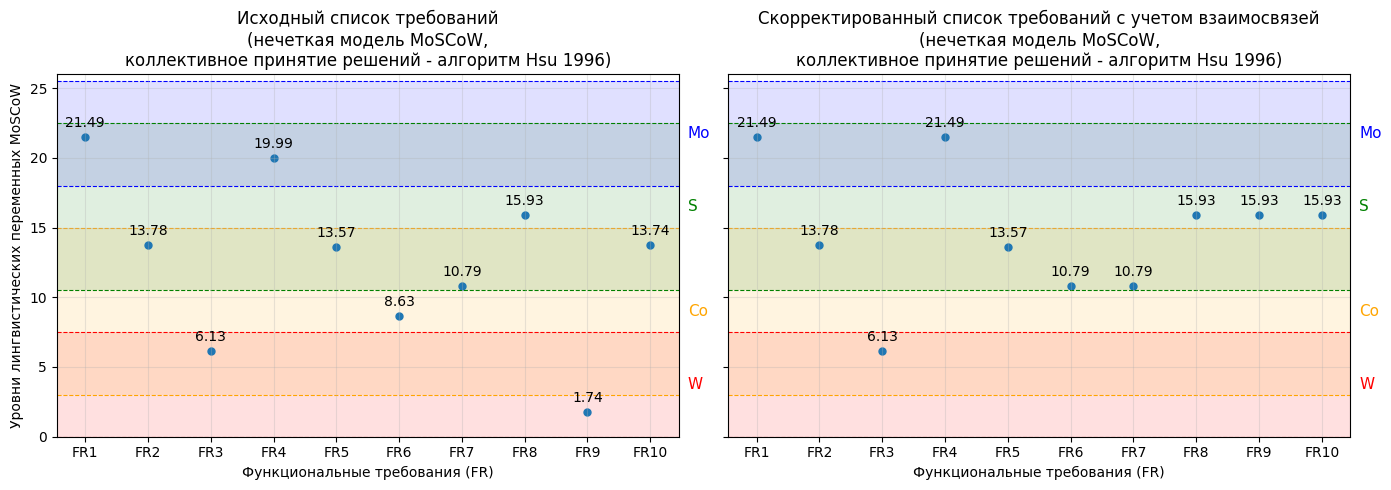

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразование результатов в словари: {FR: centroid} и {FR: adjusted_centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}
adjusted_centroid_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}

# Формирование FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    [r["fr"] for r in results_alpha],
    key=lambda x: int(x.replace("FR", ""))
)

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 7.5),
    "Co": (3.0, 15.0),
    "S":  (10.5, 22.5),
    "Mo": (18.0, 25.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Hsu 1996)",
    "Скорректированный список требований с учетом взаимосвязей\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Hsu 1996)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 26)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Версия с загрузкой данных из файла и выгрузкой итогов в файл Excel**

In [124]:
# Нечеткий метод приоритизации MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Решение принимается группой из произвольного числа экспертов по модели Hsu 1996.
# Веса экспертов четкие, изначально ненормализованные, в процессе реализации алгоритма выполняется их нормализация.
# Загрузка данных и выгрузка результатов - из файла / в файл Excel.

import re
from typing import Dict, Any, Sequence, Optional, List, Tuple
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# 1. Типы данных и константы
Trap = Tuple[float, float, float, float]
IT2 = Tuple[Trap, Trap]
EPS = 1e-12

MOSCOW_NFR_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0.0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0.0, 0.0, 0.0, 0.22), (0.0, 0.0, 0.0, 0.15))
}

_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)

# 2. Нормализация обозначений приоритетов MoSCoW
def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")

    s = str(x).strip()
    s_upper = s.upper()

    if s_upper in {"MO", "M0"}:
        return "Mo"
    if s_upper == "CO":
        return "Co"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W")

# 3. Загрузка листа эксперта
def load_expert_sheet(ws) -> Dict[str, Any]:
    # 3.1. Поиск строки заголовков NFR
    nfr_header_row = None
    nfr_names: List[str] = []
    nfr_cols: List[int] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 1:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            if nfr_names:
                nfr_header_row = r
                break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 3.2. Поиск строки приоритетов NFR
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []

    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(normalize_moscow_label(v))

    # 3.3. Поиск строки заголовков таблицы FR
    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    # 3.4. Чтение строк FR
    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break

        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else normalize_moscow_label(v))

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    if not fr_names:
        raise ValueError(f"Не найдено ни одной строки FR на листе '{ws.title}'.")

    return {
        "name": ws.title,
        "nfr": nfr_priorities,
        "fr_names": fr_names,
        "frs": fr_matrix,
    }

# 4. Расчет нечетких оценок по одному эксперту
def pfr_moscow_it2(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Optional[Sequence[str]] = None,
) -> List[Dict[str, Any]]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[str(x).strip()] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[str(x).strip()] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({"fr": name, "pfr": pfr_it2, "ratings": list(fr_row)})

    return results

# 5. Вспомогательные функции согласия
def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]

def split_it2(Rs: List[IT2]) -> Tuple[List[Trap], List[Trap]]:
    Rs_U = [R[0] for R in Rs]
    Rs_L = [R[1] for R in Rs]
    return Rs_U, Rs_L

def trap_mu(x: float, R: Trap) -> float:
    a, b, c, d = R
    if x <= a or x >= d:
        return 0.0

    if b <= a + EPS:
        if x <= c:
            return 1.0
        if d <= c + EPS:
            return 0.0
        return max(0.0, min(1.0, (d - x) / (d - c)))

    if d <= c + EPS:
        if x >= b:
            return 1.0
        return max(0.0, min(1.0, (x - a) / (b - a)))

    if x < b:
        return max(0.0, min(1.0, (x - a) / (b - a)))
    if x <= c:
        return 1.0
    return max(0.0, min(1.0, (d - x) / (d - c)))

def area_R(R: Trap) -> float:
    a, b, c, d = R
    if not (a <= b <= c <= d):
        raise ValueError("Нужно a <= b <= c <= d")
    return 0.5 * (b - a) + (c - b) + 0.5 * (d - c)

def _trap_int(yL: float, yR: float, dx: float) -> float:
    return 0.5 * (yL + yR) * dx

def intersection_area(Ri: Trap, Rj: Trap) -> float:
    ai, bi, ci, di = Ri
    aj, bj, cj, dj = Rj
    if not (ai <= bi <= ci <= di and aj <= bj <= cj <= dj):
        raise ValueError("Обе трапеции должны удовлетворять a <= b <= c <= d")

    xs = sorted({ai, bi, ci, di, aj, bj, cj, dj})
    total = 0.0

    for xL, xR in zip(xs, xs[1:]):
        dx = xR - xL
        if dx <= EPS:
            continue

        yiL, yiR = trap_mu(xL, Ri), trap_mu(xR, Ri)
        yjL, yjR = trap_mu(xL, Rj), trap_mu(xR, Rj)

        dL = yiL - yjL
        dR = yiR - yjR

        if dL <= EPS and dR <= EPS:
            total += _trap_int(yiL, yiR, dx)
            continue
        if dL >= -EPS and dR >= -EPS:
            total += _trap_int(yjL, yjR, dx)
            continue

        t = dL / (dL - dR)
        t = max(0.0, min(1.0, t))
        x0 = xL + t * dx

        yi0 = yiL + (yiR - yiL) * t
        yj0 = yjL + (yjR - yjL) * t

        if dL < 0:
            total += _trap_int(yiL, yi0, x0 - xL)
            total += _trap_int(yj0, yjR, xR - x0)
        else:
            total += _trap_int(yjL, yj0, x0 - xL)
            total += _trap_int(yi0, yiR, xR - x0)

    return total

def similarity_matrix(Rs: List[Trap]) -> List[List[float]]:
    n = len(Rs)
    areas = [area_R(Rs[i]) for i in range(n)]
    S = [[0.0] * n for _ in range(n)]

    for i in range(n):
        S[i][i] = 1.0
        for j in range(i + 1, n):
            a_int = intersection_area(Rs[i], Rs[j])
            a_uni = areas[i] + areas[j] - a_int
            s = 0.0 if a_uni <= EPS else a_int / a_uni
            S[i][j] = s
            S[j][i] = s

    return S

def agreement_scores(S: List[List[float]]) -> List[float]:
    k = len(S)
    if k < 2:
        return [0.0] * k

    A = []
    for i in range(k):
        row_sum = sum(S[i]) - S[i][i]
        A.append(row_sum / (k - 1))
    return A

def compute_A_general(A_U: List[float], A_L: List[float]) -> List[float]:
    if len(A_U) != len(A_L):
        raise ValueError("A_U и A_L должны быть одинаковой длины")
    return [(au + al) / 2.0 for au, al in zip(A_U, A_L)]

def relative_agreement(A: List[float]) -> List[float]:
    s = sum(A)
    if s <= EPS:
        n = len(A)
        return [1.0 / n] * n if n else []
    return [ai / s for ai in A]

def consensus_degree_single(
    w: Sequence[float],
    RAD: Sequence[float],
    beta: float,
    renorm: bool = True
) -> List[float]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1]")
    if len(w) != len(RAD):
        raise ValueError("w и RAD должны быть одной длины")

    cdc = [beta * float(wi) + (1.0 - beta) * float(radi) for wi, radi in zip(w, RAD)]

    if renorm:
        s = sum(cdc)
        if s <= EPS:
            n = len(cdc)
            return [1.0 / n] * n if n else []
        return [x / s for x in cdc]

    return cdc

def aggregate_it2_trapezoids(Rs: List[IT2], CDC: List[float]) -> IT2:
    if len(Rs) != len(CDC):
        raise ValueError("Длины Rs и CDC должны совпадать")
    if not Rs:
        raise ValueError("Список Rs пуст")

    R_sum: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))

    for R_i, cdc_i in zip(Rs, CDC):
        R_weighted = multiply_fuzzy_number_by_constant(R_i, cdc_i)
        R_sum = add_intuitionistic_trapezoidal_fuzzy_numbers(R_sum, R_weighted)

    return R_sum

def aggregate_group_it2_by_fr_single_cdc(
    prepared_experts: List[Dict[str, Any]],
    fr_list: List[str],
    CDC_by_fr: Dict[str, List[float]]
) -> Dict[str, IT2]:
    if not prepared_experts:
        raise ValueError("prepared_experts пуст")

    R_group_by_fr: Dict[str, IT2] = {}

    for fr in fr_list:
        Rs_it2 = [e["ratings"][fr] for e in prepared_experts]

        if fr not in CDC_by_fr:
            raise ValueError(f"{fr}: нет ключа в CDC_by_fr")

        CDC = CDC_by_fr[fr]
        if len(Rs_it2) != len(CDC):
            raise ValueError(f"{fr}: длины Rs_it2 и CDC не совпадают")

        R_sum = aggregate_it2_trapezoids(Rs_it2, CDC)

        UMF_agg, LMF_agg = R_sum
        R_group_by_fr[fr] = (
            tuple(round(x, 3) for x in UMF_agg),
            tuple(round(x, 3) for x in LMF_agg),
        )

    return R_group_by_fr

# 6. Подготовка экспертов
def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)
        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared

# 7. Дефаззификация по новой схеме
def build_defuzz_rows(
    pfr_by_fr: Dict[str, IT2],
    a: float,
    alpha: float
) -> List[Dict[str, Any]]:
    rows = []
    for fr, it2 in pfr_by_fr.items():
        pfr_t1 = cltr_type_reduction(it2, a)
        cut = alpha_cut(pfr_t1, alpha)
        centroid_value = centroid(cut)

        (a1, b1, c1, d1), (e1, f1, g1, h1) = it2
        t1_1, t1_2, t1_3, t1_4 = pfr_t1
        cut_start, cut_end = cut

        rows.append({
            "fr": fr,
            "umf": (a1, b1, c1, d1),
            "lmf": (e1, f1, g1, h1),
            "t1": (t1_1, t1_2, t1_3, t1_4),
            "alpha_cut": (cut_start, cut_end),
            "centroid": centroid_value,
        })

    return sorted(rows, key=lambda x: x["centroid"], reverse=True)

# 8. Учет взаимосвязанности функциональных требований
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {fr_to_index(item["fr"]): item for item in adjusted}
    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

# 9. Настройка оформления Excel
def autosize_columns(ws, min_width: int = 12, max_width: int = 80, extra_padding: int = 3):
    for col_cells in ws.columns:
        max_len = 0
        col_idx = col_cells[0].column
        for c in col_cells:
            value = "" if c.value is None else str(c.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_len = max(max_len, longest)

        adjusted_width = max_len + extra_padding
        ws.column_dimensions[get_column_letter(col_idx)].width = max(
            min_width,
            min(adjusted_width, max_width)
        )

def autosize_rows(ws, base_height: float = 18.0, extra_padding: float = 3.0):
    for row_cells in ws.iter_rows():
        row_num = row_cells[0].row
        if ws.row_dimensions[row_num].height is not None:
            continue

        max_lines = 1
        max_text_len = 0
        for c in row_cells:
            value = "" if c.value is None else str(c.value)
            line_count = value.count("\n") + 1
            max_lines = max(max_lines, line_count)
            max_text_len = max(max_text_len, len(value))

        height = base_height * max_lines
        if max_text_len > 35:
            height += extra_padding
        if max_text_len > 60:
            height += extra_padding

        ws.row_dimensions[row_num].height = height

def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):
                if ws.title == "Матрица_взаимосвязей_FR":
                    cell.number_format = "0"
                elif ws.title in {"Нечеткий MoSCoW_расчеты", "Нечеткий MoSCoW_итоги"} and cell.column == 1:
                    cell.number_format = "0"
                else:
                    cell.number_format = "0.00"

def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

def _set_col_width(ws, col_idx: int, width: float):
    ws.column_dimensions[get_column_letter(col_idx)].width = width

# 10. Блоки Excel
def write_weights_block(ws, start_row: int, expert_names: List[str], weights_raw: List[float], weights_norm: List[float]) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1).value = "1) Веса экспертов"
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 1

    ws.cell(start_row, 1).value = "Эксперт"
    ws.cell(start_row, 2).value = "Вес_raw"
    ws.cell(start_row, 3).value = "Вес_norm"
    for c in range(1, 4):
        ws.cell(start_row, c).font = bold
        ws.cell(start_row, c).alignment = center
    start_row += 1

    for name, wr, wn in zip(expert_names, weights_raw, weights_norm):
        ws.cell(start_row, 1).value = name
        ws.cell(start_row, 2).value = float(wr)
        ws.cell(start_row, 3).value = float(wn)
        ws.cell(start_row, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(start_row, 2).alignment = center
        ws.cell(start_row, 3).alignment = center
        start_row += 1

    ws.cell(start_row, 1).value = "SUM"
    ws.cell(start_row, 2).value = float(sum(weights_raw))
    ws.cell(start_row, 3).value = float(sum(weights_norm))
    for c in range(1, 4):
        ws.cell(start_row, c).font = bold
        ws.cell(start_row, c).alignment = center if c > 1 else Alignment(horizontal="left", vertical="center", wrap_text=True)

    return start_row + 2

def write_alpha_beta(ws, start_row: int, alpha: float, beta: float, a: float) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1).value = "2) Параметры модели"
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 1

    ws.cell(start_row, 1).value = "Параметр"
    ws.cell(start_row, 2).value = "Значение"
    ws.cell(start_row, 1).font = bold
    ws.cell(start_row, 2).font = bold
    ws.cell(start_row, 1).alignment = center
    ws.cell(start_row, 2).alignment = center
    start_row += 1

    params = [
        ("alpha (уровень альфа-среза)", alpha),
        ("beta (параметр консенсуса)", beta),
        ("a (редукция типа CLTR)", a),
    ]
    for name, value in params:
        ws.cell(start_row, 1).value = name
        ws.cell(start_row, 2).value = float(value)
        ws.cell(start_row, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(start_row, 2).alignment = center
        start_row += 1

    return start_row + 1

def write_result_table(ws, start_row: int, title: str, rows_sorted: List[Dict[str, Any]], include_adjusted: bool = False) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    title_col_end = 18 if include_adjusted else 17
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=title_col_end)
    c = ws.cell(start_row, 1)
    c.value = title
    c.font = bold
    apply_single_line_heading(c)
    ws.row_dimensions[start_row].height = 20

    r1 = start_row + 1
    r2 = start_row + 2

    ws.merge_cells(start_row=r1, start_column=1, end_row=r2, end_column=1)
    ws.merge_cells(start_row=r1, start_column=2, end_row=r2, end_column=2)
    ws.merge_cells(start_row=r1, start_column=3, end_row=r1, end_column=10)
    ws.merge_cells(start_row=r1, start_column=11, end_row=r1, end_column=14)
    ws.merge_cells(start_row=r1, start_column=15, end_row=r1, end_column=16)
    ws.merge_cells(start_row=r1, start_column=17, end_row=r2, end_column=17)

    if include_adjusted:
        ws.merge_cells(start_row=r1, start_column=18, end_row=r2, end_column=18)

    ws.cell(r1, 1).value = "Место"
    ws.cell(r1, 2).value = "FR"
    ws.cell(r1, 3).value = "Итоговый приоритет функционального требования в виде ИНМТ2"
    ws.cell(r1, 11).value = "Редуцированный приоритет FR в виде ИНМТ1"
    ws.cell(r1, 15).value = "Дефаззификация (альфа-срез)"
    ws.cell(r1, 17).value = "Центроид"

    cols_top = [1, 2, 3, 11, 15, 17]
    if include_adjusted:
        ws.cell(r1, 18).value = "Скорректированный центроид"
        cols_top.append(18)

    for col in cols_top:
        ws.cell(r1, col).font = bold
        ws.cell(r1, col).alignment = center

    second_headers = [
        "UMF_x1", "UMF_x2", "UMF_x3", "UMF_x4",
        "LMF_x1", "LMF_x2", "LMF_x3", "LMF_x4",
        "T1_x1", "T1_x2", "T1_x3", "T1_x4",
        "alpha_start", "alpha_end"
    ]

    for idx, header in enumerate(second_headers, start=3):
        ws.cell(r2, idx).value = header
        ws.cell(r2, idx).font = bold
        ws.cell(r2, idx).alignment = center

    ws.row_dimensions[r1].height = 28
    ws.row_dimensions[r2].height = 22

    data_start = start_row + 3
    for i, item in enumerate(rows_sorted, start=1):
        rr = data_start + (i - 1)
        ws.cell(rr, 1).value = i
        ws.cell(rr, 2).value = item["fr"]

        (a1, b1, c1, d1) = item["umf"]
        (e1, f1, g1, h1) = item["lmf"]
        (t1_1, t1_2, t1_3, t1_4) = item["t1"]
        cut_start, cut_end = item["alpha_cut"]

        values = [a1, b1, c1, d1, e1, f1, g1, h1, t1_1, t1_2, t1_3, t1_4, cut_start, cut_end]
        for j, val in enumerate(values, start=3):
            ws.cell(rr, j).value = float(val)

        ws.cell(rr, 17).value = float(item["centroid"])
        if include_adjusted:
            ws.cell(rr, 18).value = float(item["adjusted_centroid"])

        ws.cell(rr, 1).alignment = center
        ws.cell(rr, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for j in range(3, 18 + int(include_adjusted)):
            ws.cell(rr, j).alignment = center

    _set_col_width(ws, 11, 9)
    _set_col_width(ws, 15, 14)
    _set_col_width(ws, 16, 14)
    _set_col_width(ws, 17, 9)
    if include_adjusted:
        _set_col_width(ws, 18, 14)

    return data_start + len(rows_sorted) + 2

def write_dual_matrices_block(
    ws,
    start_row: int,
    title: str,
    subtitle_left: str,
    subtitle_right: str,
    fr_list: List[str],
    mats_left: Dict[str, List[List[float]]],
    mats_right: Dict[str, List[List[float]]],
    expert_names: List[str],
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    k = len(expert_names)
    left_start = 1
    left_width = 1 + k
    gap = 2
    right_start = left_start + left_width + gap
    right_width = 1 + k
    end_col = right_start + right_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    ws.merge_cells(start_row=start_row + 1, start_column=left_start, end_row=start_row + 1, end_column=left_start + left_width - 1)
    ws.merge_cells(start_row=start_row + 1, start_column=right_start, end_row=start_row + 1, end_column=right_start + right_width - 1)

    ws.cell(start_row + 1, left_start).value = subtitle_left
    ws.cell(start_row + 1, right_start).value = subtitle_right
    ws.cell(start_row + 1, left_start).font = bold
    ws.cell(start_row + 1, right_start).font = bold
    apply_single_line_heading(ws.cell(start_row + 1, left_start))
    apply_single_line_heading(ws.cell(start_row + 1, right_start))

    r = start_row + 3

    for fr in fr_list:
        M1 = mats_left[fr]
        M2 = mats_right[fr]

        ws.cell(r, left_start).value = fr
        ws.cell(r, right_start).value = fr
        ws.cell(r, left_start).font = bold
        ws.cell(r, right_start).font = bold
        ws.cell(r, left_start).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(r, right_start).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        r += 1

        for idx, name in enumerate([""] + expert_names):
            ws.cell(r, left_start + idx).value = name
            ws.cell(r, right_start + idx).value = name
            ws.cell(r, left_start + idx).font = bold
            ws.cell(r, right_start + idx).font = bold
            ws.cell(r, left_start + idx).alignment = center
            ws.cell(r, right_start + idx).alignment = center
        r += 1

        for i in range(k):
            ws.cell(r, left_start).value = expert_names[i]
            ws.cell(r, right_start).value = expert_names[i]
            ws.cell(r, left_start).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
            ws.cell(r, right_start).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)

            for j in range(k):
                ws.cell(r, left_start + 1 + j).value = float(M1[i][j])
                ws.cell(r, right_start + 1 + j).value = float(M2[i][j])
                ws.cell(r, left_start + 1 + j).alignment = center
                ws.cell(r, right_start + 1 + j).alignment = center
            r += 1

        r += 1

    return r

def write_dual_vectors_block(
    ws,
    start_row: int,
    title: str,
    subtitle_left: str,
    subtitle_right: str,
    fr_list: List[str],
    vec_left: Dict[str, List[float]],
    vec_right: Dict[str, List[float]],
    expert_names: List[str],
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    k = len(expert_names)
    left_start = 1
    left_width = 1 + k
    gap = 2
    right_start = left_start + left_width + gap
    right_width = 1 + k
    end_col = right_start + right_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    ws.merge_cells(start_row=start_row + 1, start_column=left_start, end_row=start_row + 1, end_column=left_start + left_width - 1)
    ws.merge_cells(start_row=start_row + 1, start_column=right_start, end_row=start_row + 1, end_column=right_start + right_width - 1)

    ws.cell(start_row + 1, left_start).value = subtitle_left
    ws.cell(start_row + 1, right_start).value = subtitle_right
    ws.cell(start_row + 1, left_start).font = bold
    ws.cell(start_row + 1, right_start).font = bold
    apply_single_line_heading(ws.cell(start_row + 1, left_start))
    apply_single_line_heading(ws.cell(start_row + 1, right_start))

    r = start_row + 3

    left_headers = ["FR"] + expert_names
    right_headers = ["FR"] + expert_names

    for idx, header in enumerate(left_headers):
        ws.cell(r, left_start + idx).value = header
        ws.cell(r, left_start + idx).font = bold
        ws.cell(r, left_start + idx).alignment = center

    for idx, header in enumerate(right_headers):
        ws.cell(r, right_start + idx).value = header
        ws.cell(r, right_start + idx).font = bold
        ws.cell(r, right_start + idx).alignment = center

    r += 1

    for fr in fr_list:
        ws.cell(r, left_start).value = fr
        ws.cell(r, right_start).value = fr
        ws.cell(r, left_start).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, right_start).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for i, val in enumerate(vec_left[fr], start=1):
            ws.cell(r, left_start + i).value = float(val)
            ws.cell(r, left_start + i).alignment = center

        for i, val in enumerate(vec_right[fr], start=1):
            ws.cell(r, right_start + i).value = float(val)
            ws.cell(r, right_start + i).alignment = center

        r += 1

    return r + 1

def write_single_vectors_block(
    ws,
    start_row: int,
    title: str,
    fr_list: List[str],
    vec: Dict[str, List[float]],
    expert_names: List[str],
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    end_col = 1 + len(expert_names)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    r = start_row + 2

    headers = ["FR"] + expert_names
    for idx, header in enumerate(headers, start=1):
        ws.cell(r, idx).value = header
        ws.cell(r, idx).font = bold
        ws.cell(r, idx).alignment = center
    r += 1

    for fr in fr_list:
        ws.cell(r, 1).value = fr
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for i, val in enumerate(vec[fr], start=2):
            ws.cell(r, i).value = float(val)
            ws.cell(r, i).alignment = center
        r += 1

    return r + 1

# 11. Лист с матрицей взаимосвязей
def write_relation_matrix_sheet(
    wb: openpyxl.Workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1), horizontal="left")
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(3, j, fr_name).font = header_font
        ws.cell(3, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for i, fr_name in enumerate(fr_names, start=4):
        ws.cell(i, 1, fr_name).font = header_font
        ws.cell(i, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, value)
            ws.cell(i, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)

    ws.column_dimensions["A"].width = 14

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)


# 12. Лист расчетов
def write_calculations_sheet(
    wb: openpyxl.Workbook,
    calculations_sheet_name: str,
    expert_names: List[str],
    weights_raw: List[float],
    weights_norm: List[float],
    alpha: float,
    beta: float,
    a: float,
    experts_tables: Dict[str, List[Dict[str, Any]]],
    fr_list: List[str],
    AM_U_by_fr: Dict[str, List[List[float]]],
    AM_L_by_fr: Dict[str, List[List[float]]],
    A_U_by_fr: Dict[str, List[float]],
    A_L_by_fr: Dict[str, List[float]],
    A_by_fr: Dict[str, List[float]],
    RAD_by_fr: Dict[str, List[float]],
    CDC_by_fr: Dict[str, List[float]]
):
    if calculations_sheet_name in wb.sheetnames:
        del wb[calculations_sheet_name]
    ws = wb.create_sheet(calculations_sheet_name)

    title_font = Font(bold=True, size=12)
    ws.cell(1, 1).value = "Нечеткий MoSCoW - расчеты (коллективное решение, Hsu 1996)"
    ws.cell(1, 1).font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    r = 3
    r = write_weights_block(ws, r, expert_names, weights_raw, weights_norm)
    r = write_alpha_beta(ws, r, alpha, beta, a)

    for expert_name in expert_names:
        r = write_result_table(
            ws,
            r,
            title=f"3) Индивидуальные результаты эксперта {expert_name}",
            rows_sorted=experts_tables[expert_name],
            include_adjusted=True
        )

    r = write_dual_matrices_block(
        ws,
        r,
        title="4) Матрицы сходства S(Ei, Ej)",
        subtitle_left="UMF",
        subtitle_right="LMF",
        fr_list=fr_list,
        mats_left=AM_U_by_fr,
        mats_right=AM_L_by_fr,
        expert_names=expert_names
    )

    r = write_dual_vectors_block(
        ws,
        r,
        title="5) Средняя степень согласия эксперта A_U(Ei) и A_L(Ei)",
        subtitle_left="A_U(Ei)",
        subtitle_right="A_L(Ei)",
        fr_list=fr_list,
        vec_left=A_U_by_fr,
        vec_right=A_L_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="6) Обобщенная средняя степень согласия эксперта A(Ei)",
        fr_list=fr_list,
        vec=A_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="7) Относительная степень согласия эксперта RAD(Ei)",
        fr_list=fr_list,
        vec=RAD_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="8) Коэффициент степени консенсуса эксперта CDC(Ei)",
        fr_list=fr_list,
        vec=CDC_by_fr,
        expert_names=expert_names
    )

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=26, extra_padding=4)

    ws.column_dimensions["A"].width = 28
    ws.column_dimensions["K"].width = 12
    ws.column_dimensions["O"].width = 14
    ws.column_dimensions["P"].width = 14
    ws.column_dimensions["R"].width = 22

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 13. Лист итогов
def write_totals_sheet(
    wb: openpyxl.Workbook,
    totals_sheet_name: str,
    rows_sorted_group: List[Dict[str, Any]],
    adjusted_group_rows: List[Dict[str, Any]]
):
    if totals_sheet_name in wb.sheetnames:
        del wb[totals_sheet_name]
    ws = wb.create_sheet(totals_sheet_name)

    title_font = Font(bold=True, size=12)
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(1, 1).value = "Нечеткий MoSCoW - итоги (коллективное решение, Hsu 1996)"
    ws.cell(1, 1).font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    r = 3
    r = write_result_table(
        ws,
        r,
        title="1) Итоговые нечеткие приоритеты и результаты дефаззификации",
        rows_sorted=rows_sorted_group,
        include_adjusted=False
    )

    ws.cell(r, 1).value = "2) Итоговая приоритизация после учета взаимосвязанности"
    ws.cell(r, 1).font = bold
    apply_single_line_heading(ws.cell(r, 1))
    ws.row_dimensions[r].height = 20
    r += 1

    headers = ["Место", "FR", "Исходный центроид", "Скорректированный центроид"]
    for idx, header in enumerate(headers, start=1):
        ws.cell(r, idx).value = header
        ws.cell(r, idx).font = bold
        ws.cell(r, idx).alignment = center

    ws.row_dimensions[r].height = 34
    r += 1

    for idx, item in enumerate(adjusted_group_rows, start=1):
        ws.cell(r, 1).value = idx
        ws.cell(r, 2).value = item["fr"]
        ws.cell(r, 3).value = float(item["centroid"])
        ws.cell(r, 4).value = float(item["adjusted_centroid"])

        ws.cell(r, 1).alignment = center
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = center
        ws.cell(r, 4).alignment = center
        r += 1

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=26, extra_padding=4)

    ws.column_dimensions["A"].width = 12
    ws.column_dimensions["K"].width = 12
    ws.column_dimensions["O"].width = 14
    ws.column_dimensions["P"].width = 14

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)


# 14. Основная функция
def fuzzy_group_moscow_hsu_from_excel(
    input_xlsx: str,
    output_xlsx: Optional[str] = None,
    weights_raw: Optional[Sequence[float]] = None,
    alpha: float = 0.8,
    beta: float = 0.4,
    a: float = 0.6,
    relation_matrix: Optional[Sequence[Sequence[int]]] = None,
    calculations_sheet_name: str = "Нечеткий MoSCoW_расчеты",
    totals_sheet_name: str = "Нечеткий MoSCoW_итоги",
    skip_service_sheets: bool = True,
    skip_sheets_without_nfr: bool = True,
) -> str:
    wb = openpyxl.load_workbook(input_xlsx)

    service_sheet_names = {
        calculations_sheet_name,
        totals_sheet_name,
        "Матрица_взаимосвязей_FR"
    }

    experts_loaded: List[Dict[str, Any]] = []
    skipped: List[str] = []

    for sname in wb.sheetnames:
        if skip_service_sheets and sname in service_sheet_names:
            continue

        ws = wb[sname]
        try:
            data = load_expert_sheet(ws)
        except ValueError as e:
            if skip_sheets_without_nfr and "Не найдена строка заголовков NFR" in str(e):
                skipped.append(sname)
                continue
            raise

        experts_loaded.append(data)

    if not experts_loaded:
        raise ValueError(f"Не найдено листов-экспертов с NFR-шапкой. Пропущено: {skipped}")

    fr_list = experts_loaded[0]["fr_names"]
    for e in experts_loaded[1:]:
        if e["fr_names"] != fr_list:
            raise ValueError("У экспертов разные списки FR (имена/порядок должны совпадать).")

    k = len(experts_loaded)

    if weights_raw is None:
        weights_raw = [1.0] * k
    else:
        if len(weights_raw) != k:
            raise ValueError(f"weights_raw должен быть длины {k} (по числу экспертов/листов).")
        weights_raw = list(weights_raw)

    experts_prepared = prepare_moscow_it2_inputs(
        experts=experts_loaded,
        expert_weights_raw=weights_raw,
        fr_names=fr_list,
        normalize_weights=True,
    )

    expert_names = [e["name"] for e in experts_prepared]
    w_norm = [float(e["w"]) for e in experts_prepared]

    AM_U_by_fr: Dict[str, List[List[float]]] = {}
    AM_L_by_fr: Dict[str, List[List[float]]] = {}
    A_U_by_fr: Dict[str, List[float]] = {}
    A_L_by_fr: Dict[str, List[float]] = {}
    A_by_fr: Dict[str, List[float]] = {}
    RAD_by_fr: Dict[str, List[float]] = {}
    CDC_by_fr: Dict[str, List[float]] = {}

    for fr in fr_list:
        Rs_it2 = [ex["ratings"][fr] for ex in experts_prepared]
        Rs_U, Rs_L = split_it2(Rs_it2)

        AM_U = similarity_matrix(Rs_U)
        AM_L = similarity_matrix(Rs_L)
        AM_U_by_fr[fr] = AM_U
        AM_L_by_fr[fr] = AM_L

        A_U = agreement_scores(AM_U)
        A_L = agreement_scores(AM_L)
        A_U_by_fr[fr] = A_U
        A_L_by_fr[fr] = A_L

        A_gen = compute_A_general(A_U, A_L)
        A_by_fr[fr] = A_gen

        RAD = relative_agreement(A_gen)
        RAD_by_fr[fr] = RAD

        CDC = consensus_degree_single(w_norm, RAD, beta, renorm=True)
        CDC_by_fr[fr] = CDC

    R_group_by_fr = aggregate_group_it2_by_fr_single_cdc(
        prepared_experts=experts_prepared,
        fr_list=fr_list,
        CDC_by_fr=CDC_by_fr
    )

    if relation_matrix is None:
        n = len(fr_list)
        relation_matrix = [[1 if i == j else 0 for j in range(n)] for i in range(n)]

    experts_tables: Dict[str, List[Dict[str, Any]]] = {}
    for ex in experts_prepared:
        rows_sorted = build_defuzz_rows(ex["ratings"], a=a, alpha=alpha)
        adjusted_rows = adjust_fuzzy_ranked_by_interdependencies(rows_sorted, relation_matrix)
        adjusted_map = {item["fr"]: item["adjusted_centroid"] for item in adjusted_rows}

        combined = []
        for item in rows_sorted:
            new_item = dict(item)
            new_item["adjusted_centroid"] = float(adjusted_map[item["fr"]])
            combined.append(new_item)

        combined = sorted(
            combined,
            key=lambda x: (-x["adjusted_centroid"], -x["centroid"], x["fr"])
        )
        experts_tables[ex["name"]] = combined

    rows_sorted_group = build_defuzz_rows(R_group_by_fr, a=a, alpha=alpha)
    adjusted_group_rows = adjust_fuzzy_ranked_by_interdependencies(rows_sorted_group, relation_matrix)

    write_relation_matrix_sheet(
        wb=wb,
        fr_names=fr_list,
        relation_matrix=relation_matrix,
        sheet_name="Матрица_взаимосвязей_FR"
    )

    write_calculations_sheet(
        wb=wb,
        calculations_sheet_name=calculations_sheet_name,
        expert_names=expert_names,
        weights_raw=list(weights_raw),
        weights_norm=w_norm,
        alpha=alpha,
        beta=beta,
        a=a,
        experts_tables=experts_tables,
        fr_list=fr_list,
        AM_U_by_fr=AM_U_by_fr,
        AM_L_by_fr=AM_L_by_fr,
        A_U_by_fr=A_U_by_fr,
        A_L_by_fr=A_L_by_fr,
        A_by_fr=A_by_fr,
        RAD_by_fr=RAD_by_fr,
        CDC_by_fr=CDC_by_fr,
    )

    write_totals_sheet(
        wb=wb,
        totals_sheet_name=totals_sheet_name,
        rows_sorted_group=rows_sorted_group,
        adjusted_group_rows=adjusted_group_rows
    )

    desired_order = expert_names + [
        "Матрица_взаимосвязей_FR",
        calculations_sheet_name,
        totals_sheet_name
    ]
    wb._sheets = [wb[name] for name in desired_order if name in wb.sheetnames]

    if output_xlsx is None:
        output_xlsx = input_xlsx

    wb.save(output_xlsx)
    return output_xlsx


In [125]:
# Запуск
relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
]

in_file = "Загрузочные данные_MoSCoW_коллектив.xlsx"
out_file = "Итоги_Fuzzy MoSCoW_Hsu 1996.xlsx"

saved_path = fuzzy_group_moscow_hsu_from_excel(
    input_xlsx=in_file,
    output_xlsx=out_file,
    weights_raw=[0.75, 0.75, 1.0],
    alpha=0.8,
    beta=0.4,
    a=0.6,
    relation_matrix=relation_matrix,
    calculations_sheet_name="Нечеткий MoSCoW_расчеты",
    totals_sheet_name="Нечеткий MoSCoW_итоги",
)

print("Файл сохранен:", saved_path)

Файл сохранен: Итоги_Fuzzy MoSCoW_Hsu 1996.xlsx


# 2.2.2. Четкий MoSCoW + Аналог алгоритма Hsu 1996 (КПР) для сравнения с нечетким алгоритмом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://www.sciencedirect.com/science/article/pii/0165011495001859

Hsu H.-M., Chen C.-T. Aggregation of fuzzy opinions under group decision making // Fuzzy sets and systems. 1996 May 13;79(3). PP. 279-285

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [126]:
from typing import Sequence, Any, Optional, Dict, Tuple, List

# Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, float] = {"Mo": 8.0, "S": 5.5, "Co": 3.0, "W": 0.5}
MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS)  # {"Mo","S","Co","W"}


def normalize_expert_weights(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    normalize: bool = True,
) -> Tuple[List[str], List[float], Dict[str, float], Dict[str, float]]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_norm_by_name = dict(zip(expert_names, w_norm))
    w_raw_by_name = dict(zip(expert_names, w_raw))
    return expert_names, w_norm, w_norm_by_name, w_raw_by_name


def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # NFR - веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    # FR_NFR - PFR
    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")

        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores

def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    # базовые проверки по структуре FR
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR (поле 'frs').")
    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    # FR names
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    else:
        fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # веса экспертов
    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    # оценки каждого эксперта: {expert - оценки {fr - pfr}}
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,   # список в том же порядке, что expert_names
        "expert_scores": expert_scores,     # ключевой результат шага
    }

In [127]:
# Пример использования (3 эксперта)
S1 = {
    "name": "S1",
    "nfr": ["Mo", "Mo", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "S", "Mo"],
        ["S",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["S",  "Co", "S"],
        ["Co", "Co",  "Co"],
        ["S", "S",  "W"],
        ["S",  "S", "S"],
        ["W",  "W", "W"],
        ["Co", "Co", "Mo"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "S", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "Mo", "Mo"],
        ["S",  "Co",  "W"],
        ["Mo", "Mo",  "Mo"],
        ["S",  "S", "S"],
        ["Co", "S",  "Co"],
        ["S", "Mo",  "W"],
        ["S",  "Mo", "S"],
        ["W",  "Co", "W"],
        ["Co", "S", "Mo"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["S", "Mo", "Mo"],
    "frs": [
       ["Mo", "Mo",  "Mo"],
        ["Co", "S", "Mo"],
        ["Mo",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["Mo",  "Co", "S"],
        ["S", "Co",  "Co"],
        ["Mo", "S",  "W"],
        ["Mo",  "S", "S"],
        ["Co",  "W", "W"],
        ["S", "Co", "Mo"],
    ]
}

experts = [S1, S2, S3]
weights = [0.75, 0.75, 1]  # ненормализованные

prepared = prepare_crisp_moscow_inputs(experts, weights)

print("Normalized weights:", {k: round(v, 2) for k, v in prepared["weights_norm"].items()})
print()

# Печать
fr_names = prepared["fr_names"]
expert_names = prepared["expert_names"]
expert_scores = prepared["expert_scores"]

for fr in fr_names:
    row = {expert: round(expert_scores[expert][fr], 2) for expert in expert_names}
    print(f"{fr}: {row}")


Normalized weights: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

FR1: {'S1': 24.0, 'S2': 21.5, 'S3': 21.5}
FR2: {'S1': 13.28, 'S2': 13.5, 'S3': 15.1}
FR3: {'S1': 5.28, 'S2': 7.1, 'S3': 5.5}
FR4: {'S1': 21.28, 'S2': 21.5, 'S3': 18.78}
FR5: {'S1': 13.2, 'S2': 14.19, 'S3': 13.42}
FR6: {'S1': 7.92, 'S2': 8.91, 'S3': 8.91}
FR7: {'S1': 10.56, 'S2': 10.78, 'S3': 10.78}
FR8: {'S1': 15.84, 'S2': 16.06, 'S3': 16.06}
FR9: {'S1': 0.0, 'S2': 1.82, 'S3': 1.82}
FR10: {'S1': 13.28, 'S2': 14.27, 'S3': 14.27}


In [128]:
# Расчет матриц согласия (отношение меньшей оценки одного эксперта, на бОльшую оценку другого эксперта)
def build_am_matrices_by_fr(prepared: dict[str, Any]) -> dict[str, list[list[float]]]:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]  # {expert: {fr: pfr}}

    am_by_fr: dict[str, list[list[float]]] = {}

    for fr in fr_names:
        # вектор оценок экспертов по данному FR
        vals = [float(scores[ex][fr]) for ex in expert_names]
        k = len(vals)

        am = [[0.0] * k for _ in range(k)]
        for i in range(k):
            for j in range(k):
                a, b = vals[i], vals[j]
                mx = max(a, b)
                if mx == 0.0:
                    am[i][j] = 1.0   # 0/0 - считаем полным согласием
                else:
                    am[i][j] = min(a, b) / mx

        am_by_fr[fr] = am

    return am_by_fr

In [129]:
# Вывод на печать матриц согласия
expert_names = prepared["expert_names"]  # порядок экспертов как в prepared

AM_by_fr = build_am_matrices_by_fr(prepared)
fr_list = prepared["fr_names"]

print("Матрицы согласия (AM) по каждому функциональному требованию (crisp):")
for fr in fr_list:
    print(f"\n{fr}:")
    for row in AM_by_fr[fr]:
        print([round(x, 2) for x in row])

Матрицы согласия (AM) по каждому функциональному требованию (crisp):

FR1:
[1.0, 0.9, 0.9]
[0.9, 1.0, 1.0]
[0.9, 1.0, 1.0]

FR2:
[1.0, 0.98, 0.88]
[0.98, 1.0, 0.89]
[0.88, 0.89, 1.0]

FR3:
[1.0, 0.74, 0.96]
[0.74, 1.0, 0.78]
[0.96, 0.78, 1.0]

FR4:
[1.0, 0.99, 0.88]
[0.99, 1.0, 0.87]
[0.88, 0.87, 1.0]

FR5:
[1.0, 0.93, 0.98]
[0.93, 1.0, 0.95]
[0.98, 0.95, 1.0]

FR6:
[1.0, 0.89, 0.89]
[0.89, 1.0, 1.0]
[0.89, 1.0, 1.0]

FR7:
[1.0, 0.98, 0.98]
[0.98, 1.0, 1.0]
[0.98, 1.0, 1.0]

FR8:
[1.0, 0.99, 0.99]
[0.99, 1.0, 1.0]
[0.99, 1.0, 1.0]

FR9:
[1.0, 0.0, 0.0]
[0.0, 1.0, 1.0]
[0.0, 1.0, 1.0]

FR10:
[1.0, 0.93, 0.93]
[0.93, 1.0, 1.0]
[0.93, 1.0, 1.0]


In [130]:
# Вычисление средней степени согласия экспертов
def average_agreement_by_fr(
    AM_by_fr: dict[str, list[list[float]]],
    expert_names: list[str],
) -> dict[str, dict[str, float]]:
    k = len(expert_names)
    if k < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")

    A_by_fr: dict[str, dict[str, float]] = {}

    for fr, AM in AM_by_fr.items():
        if len(AM) != k or any(len(row) != k for row in AM):
            raise ValueError(f"{fr}: матрица AM должна быть размера {k}x{k}.")

        A_fr: dict[str, float] = {}
        for i, name in enumerate(expert_names):
            s = sum(AM[i][j] for j in range(k) if j != i)
            A_fr[name] = s / (k - 1)
        A_by_fr[fr] = A_fr

    return A_by_fr

In [131]:
AM_by_fr = build_am_matrices_by_fr(prepared)
fr_list = prepared["fr_names"]
expert_names = prepared["expert_names"]

A_by_fr = average_agreement_by_fr(AM_by_fr, expert_names)

print("Средняя степень согласия экспертов (Ai) по каждому FR:")
for fr in fr_list:
    row = {e: round(A_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}:{row}")

Средняя степень согласия экспертов (Ai) по каждому FR:
FR1:{'S1': 0.9, 'S2': 0.95, 'S3': 0.95}
FR2:{'S1': 0.93, 'S2': 0.94, 'S3': 0.89}
FR3:{'S1': 0.85, 'S2': 0.76, 'S3': 0.87}
FR4:{'S1': 0.94, 'S2': 0.93, 'S3': 0.88}
FR5:{'S1': 0.96, 'S2': 0.94, 'S3': 0.96}
FR6:{'S1': 0.89, 'S2': 0.94, 'S3': 0.94}
FR7:{'S1': 0.98, 'S2': 0.99, 'S3': 0.99}
FR8:{'S1': 0.99, 'S2': 0.99, 'S3': 0.99}
FR9:{'S1': 0.0, 'S2': 0.5, 'S3': 0.5}
FR10:{'S1': 0.93, 'S2': 0.97, 'S3': 0.97}


In [132]:
# Расчет относительных степеней согласия экспертов по каждому функциональному требованию
def rad_by_fr(
    A_by_fr: dict[str, dict[str, float]],
    expert_names: list[str],
) -> dict[str, dict[str, float]]:
    RAD_by_fr: dict[str, dict[str, float]] = {}

    for fr, A_fr in A_by_fr.items():
        s = sum(A_fr[e] for e in expert_names)
        if s == 0:
            # равные доли
            RAD_by_fr[fr] = {e: 1.0 / len(expert_names) for e in expert_names}
        else:
            RAD_by_fr[fr] = {e: A_fr[e] / s for e in expert_names}

    return RAD_by_fr

In [133]:
RAD_by_fr = rad_by_fr(A_by_fr, expert_names)

print("RADi (нормализованные Ai) по каждому FR:")
for fr in fr_list:
    row = {e: round(RAD_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}:{row}")


RADi (нормализованные Ai) по каждому FR:
FR1:{'S1': 0.32, 'S2': 0.34, 'S3': 0.34}
FR2:{'S1': 0.34, 'S2': 0.34, 'S3': 0.32}
FR3:{'S1': 0.34, 'S2': 0.31, 'S3': 0.35}
FR4:{'S1': 0.34, 'S2': 0.34, 'S3': 0.32}
FR5:{'S1': 0.33, 'S2': 0.33, 'S3': 0.34}
FR6:{'S1': 0.32, 'S2': 0.34, 'S3': 0.34}
FR7:{'S1': 0.33, 'S2': 0.33, 'S3': 0.33}
FR8:{'S1': 0.33, 'S2': 0.33, 'S3': 0.33}
FR9:{'S1': 0.0, 'S2': 0.5, 'S3': 0.5}
FR10:{'S1': 0.33, 'S2': 0.34, 'S3': 0.34}


In [134]:
# Расчет коэффициента степени консенсуса экспертов по каждому функциональному требованию
def cdc_by_fr(
    RAD_by_fr: dict[str, dict[str, float]],
    weights_norm_by_name: dict[str, float],
    expert_names: list[str],
    beta: float = 0.4,
) -> dict[str, dict[str, float]]:
    if not (0 <= beta <= 1):
        raise ValueError("beta должен быть в диапазоне [0,1].")

    CDC_by_fr: dict[str, dict[str, float]] = {}
    for fr, RAD_fr in RAD_by_fr.items():
        CDC_by_fr[fr] = {
            e: beta * float(weights_norm_by_name[e]) + (1 - beta) * float(RAD_fr[e])
            for e in expert_names
        }
    return CDC_by_fr

In [135]:
beta = 0.4
CDC_by_fr = cdc_by_fr(
    RAD_by_fr=RAD_by_fr,
    weights_norm_by_name=prepared["weights_norm"],
    expert_names=prepared["expert_names"],
    beta=beta
)

print(f"CDCi по каждому FR (beta={beta}):")
for fr in fr_list:
    row = {e: round(CDC_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}:{row}")

CDCi по каждому FR (beta=0.4):
FR1:{'S1': 0.31, 'S2': 0.32, 'S3': 0.36}
FR2:{'S1': 0.32, 'S2': 0.32, 'S3': 0.35}
FR3:{'S1': 0.33, 'S2': 0.3, 'S3': 0.37}
FR4:{'S1': 0.32, 'S2': 0.32, 'S3': 0.35}
FR5:{'S1': 0.32, 'S2': 0.32, 'S3': 0.36}
FR6:{'S1': 0.31, 'S2': 0.32, 'S3': 0.36}
FR7:{'S1': 0.32, 'S2': 0.32, 'S3': 0.36}
FR8:{'S1': 0.32, 'S2': 0.32, 'S3': 0.36}
FR9:{'S1': 0.12, 'S2': 0.42, 'S3': 0.46}
FR10:{'S1': 0.32, 'S2': 0.32, 'S3': 0.36}


In [136]:
# Вычисление групповой оценки приоритета кадого функционального требования
def aggregate_group_pfr_by_cdc(
    expert_scores: dict[str, dict[str, float]],   # {expert: {fr: pfr}}
    CDC_by_fr: dict[str, dict[str, float]],       # {fr: {expert: cdc}}
    fr_names: list[str],
    expert_names: list[str],
) -> dict[str, float]:
    group_scores: dict[str, float] = {}

    for fr in fr_names:
        s = 0.0
        for e in expert_names:
            s += float(expert_scores[e][fr]) * float(CDC_by_fr[fr][e])
        group_scores[fr] = s

    return group_scores

In [137]:
group_scores = aggregate_group_pfr_by_cdc(
    expert_scores=prepared["expert_scores"],
    CDC_by_fr=CDC_by_fr,
    fr_names=prepared["fr_names"],
    expert_names=prepared["expert_names"],
)

print("Групповые приоритеты FR (взвешивание по CDC):")
for fr in prepared["fr_names"]:
    print(f"{fr}:{group_scores[fr]:.2f}")

# Ранжирование:
ranked = sorted(group_scores.items(), key=lambda x: x[1], reverse=True)
print("\nРанжирование:")
for fr, val in ranked:
    print(f"{fr}:{val:.2f}")


Групповые приоритеты FR (взвешивание по CDC):
FR1:22.28
FR2:13.99
FR3:5.91
FR4:20.47
FR5:13.59
FR6:8.60
FR7:10.71
FR8:15.99
FR9:1.60
FR10:13.96

Ранжирование:
FR1:22.28
FR4:20.47
FR8:15.99
FR2:13.99
FR10:13.96
FR5:13.59
FR7:10.71
FR6:8.60
FR3:5.91
FR9:1.60


Алгоритм учета взаимосвязанности функциональных требований

In [138]:
def adjust_crisp_scores_by_interdependencies(
    group_scores: Dict[str, float],
    relation_matrix: Sequence[Sequence[int]],
) -> List[tuple[str, float, float]]:

    fr_names = list(group_scores.keys())
    n = len(fr_names)

    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(fr) for fr in fr_names]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в group_scores должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    original_scores = {fr: group_scores[fr] for fr in group_scores}
    adjusted_scores = {fr: group_scores[fr] for fr in group_scores}

    matrix_idx_to_fr = {fr_to_index(fr): fr for fr in group_scores}

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(original_scores[matrix_idx_to_fr[i]] for i in comp)
        for i in comp:
            adjusted_scores[matrix_idx_to_fr[i]] = max_score

    adjusted_ranked = sorted(
        [(fr, original_scores[fr], adjusted_scores[fr]) for fr in group_scores],
        key=lambda x: (-x[2], -x[1], x[0])
    )

    return adjusted_ranked

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [139]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_ranked = adjust_crisp_scores_by_interdependencies(group_scores, relation_matrix)

print("Скорректированное ранжирование:")
for fr, original_val, adjusted_val in adjusted_ranked:
    print(
        f"{fr}: "
        f"исходная оценка = {original_val:.2f}, "
        f"скорректированная оценка = {adjusted_val:.2f}"
    )

Скорректированное ранжирование:
FR1: исходная оценка = 22.28, скорректированная оценка = 22.28
FR4: исходная оценка = 20.47, скорректированная оценка = 22.28
FR8: исходная оценка = 15.99, скорректированная оценка = 15.99
FR10: исходная оценка = 13.96, скорректированная оценка = 15.99
FR9: исходная оценка = 1.60, скорректированная оценка = 15.99
FR2: исходная оценка = 13.99, скорректированная оценка = 13.99
FR5: исходная оценка = 13.59, скорректированная оценка = 13.59
FR7: исходная оценка = 10.71, скорректированная оценка = 10.71
FR6: исходная оценка = 8.60, скорректированная оценка = 10.71
FR3: исходная оценка = 5.91, скорректированная оценка = 5.91


Визуализации исходного и итогового приоритизированного списков функциональных требований

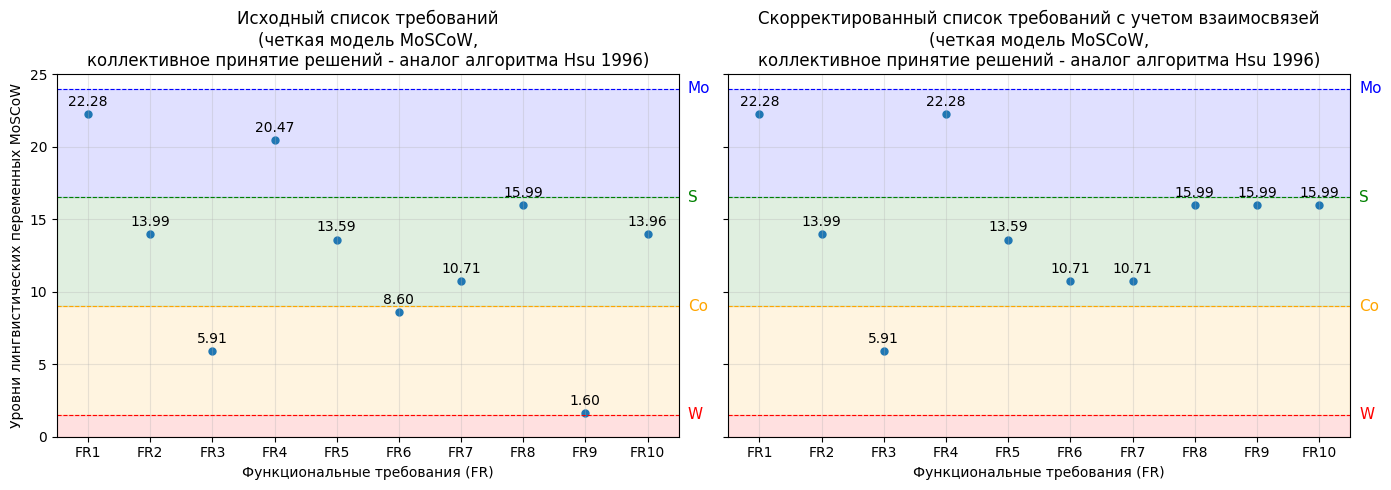

In [140]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразование скорректированного результата в словарь: {FR: adjusted_score}
adjusted_scores_by_fr = {fr: adjusted_val for fr, original_val, adjusted_val in adjusted_ranked}

# Формирование списка FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    group_scores.keys(),
    key=lambda x: int(x.replace("FR", ""))
)

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [group_scores[fr] for fr in fr_labels]
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (16.5, 24.0),
    "S": (9.0, 16.5),
    "Co": (1.5, 9.0),
    "W": (0, 1.5)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 24.0,
    "S": 16.5,
    "Co": 9.0,
    "W": 1.5
}

boundary_lines = [1.5, 9.0, 16.5, 24.0]
boundary_colors = {
    1.5: "red",
    9.0: "orange",
    16.5: "green",
    24.0: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Hsu 1996)",
    "Скорректированный список требований с учетом взаимосвязей\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Hsu 1996)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.35
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 25)
    ax.set_xlim(-0.5, len(fr_labels) - 0.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка из файла/ в файл Excel**

In [141]:
# Четкий алгоритм MoSCoW с коллективными агрегированными оценками.
# Произвольное число экспертов, функциональных требований и критериев их оценки.
# Загрузка и выгрузка из файла / в файл Excel.

import re
from typing import List, Sequence, Dict, Any, Tuple, Optional
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter


# 1. Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, float] = {"Mo": 8.0, "S": 5.5, "Co": 3.0, "W": 0.5}
MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS)


# 2. Нормализация обозначений приоритетов MoSCoW
def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")

    s = str(x).strip()
    s_upper = s.upper()

    if s_upper in {"MO", "M0"}:
        return "Mo"
    if s_upper == "CO":
        return "Co"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W")


# 3. Загрузка листа эксперта
_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)

def load_expert_sheet(ws) -> Dict[str, Any]:
    # 3.1. Поиск строки заголовков NFR
    nfr_header_row = None
    nfr_cols: List[int] = []
    nfr_names: List[str] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [
            c for c, v in enumerate(row_vals, start=1)
            if isinstance(v, str) and _nfr_pat.match(v.strip())
        ]
        if len(cols) >= 2:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 3.2. Поиск строки приоритетов NFR
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []

    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(
                f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}."
            )
        nfr_priorities.append(normalize_moscow_label(v))

    # 3.3. Поиск строки заголовков таблицы FR
    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    # 3.4. Чтение строк FR
    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break

        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else normalize_moscow_label(v))

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    if not fr_names:
        raise ValueError(f"Не найдено ни одной строки FR на листе '{ws.title}'.")

    return {
        "name": ws.title,
        "nfr": nfr_priorities,
        "frs": fr_matrix,
        "fr_names": fr_names,
        "nfr_names": nfr_names,
    }


# 4. Нормализация весов экспертов
def normalize_expert_weights(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    normalize: bool = True,
) -> Tuple[List[str], List[float], Dict[str, float], Dict[str, float]]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_norm_by_name = dict(zip(expert_names, w_norm))
    w_raw_by_name = dict(zip(expert_names, w_raw))
    return expert_names, w_norm, w_norm_by_name, w_raw_by_name


# 5. Расчет индивидуальных PFR
def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")

        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores


# 6. Подготовка исходных данных для коллективного расчета
def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR (поле 'frs').")
    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    else:
        fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,
        "expert_scores": expert_scores,
    }


# 7. Матрицы согласия
def build_am_matrices_by_fr(prepared: Dict[str, Any]) -> Dict[str, List[List[float]]]:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]

    am_by_fr: Dict[str, List[List[float]]] = {}

    for fr in fr_names:
        vals = [float(scores[ex][fr]) for ex in expert_names]
        k = len(vals)

        am = [[0.0] * k for _ in range(k)]
        for i in range(k):
            for j in range(k):
                a, b = vals[i], vals[j]
                mx = max(a, b)
                if mx == 0.0:
                    am[i][j] = 1.0
                else:
                    am[i][j] = min(a, b) / mx

        am_by_fr[fr] = am

    return am_by_fr


# 8. Средняя степень согласия
def average_agreement_by_fr(
    AM_by_fr: Dict[str, List[List[float]]],
    expert_names: List[str],
) -> Dict[str, Dict[str, float]]:
    k = len(expert_names)
    if k < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")

    A_by_fr: Dict[str, Dict[str, float]] = {}

    for fr, AM in AM_by_fr.items():
        A_fr: Dict[str, float] = {}
        for i, e in enumerate(expert_names):
            s = sum(AM[i][j] for j in range(k) if j != i)
            A_fr[e] = s / (k - 1)
        A_by_fr[fr] = A_fr

    return A_by_fr


# 9. Относительная степень согласия
def rad_by_fr(
    A_by_fr: Dict[str, Dict[str, float]],
    expert_names: List[str],
) -> Dict[str, Dict[str, float]]:
    RAD_by_fr: Dict[str, Dict[str, float]] = {}

    for fr, A_fr in A_by_fr.items():
        s = sum(A_fr[e] for e in expert_names)
        if s == 0:
            RAD_by_fr[fr] = {e: 1.0 / len(expert_names) for e in expert_names}
        else:
            RAD_by_fr[fr] = {e: A_fr[e] / s for e in expert_names}

    return RAD_by_fr


# 10. Коэффициент степени консенсуса
def cdc_by_fr(
    RAD_by_fr: Dict[str, Dict[str, float]],
    weights_norm_by_name: Dict[str, float],
    expert_names: List[str],
    beta: float = 0.4,
) -> Dict[str, Dict[str, float]]:
    if not (0 <= beta <= 1):
        raise ValueError("beta должен быть в диапазоне [0,1].")

    CDC_by_fr: Dict[str, Dict[str, float]] = {}
    for fr, RAD_fr in RAD_by_fr.items():
        CDC_by_fr[fr] = {
            e: beta * float(weights_norm_by_name[e]) + (1 - beta) * float(RAD_fr[e])
            for e in expert_names
        }
    return CDC_by_fr


# 11. Вклад экспертов и групповая оценка
def contributions_and_group(
    prepared: Dict[str, Any],
    CDC_by_fr: Dict[str, Dict[str, float]]
) -> Tuple[Dict[str, Dict[str, float]], Dict[str, float]]:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]

    contrib_by_fr: Dict[str, Dict[str, float]] = {}
    group_scores: Dict[str, float] = {}

    for fr in fr_names:
        contrib = {e: scores[e][fr] * CDC_by_fr[fr][e] for e in expert_names}
        contrib_by_fr[fr] = contrib
        group_scores[fr] = sum(contrib.values())

    return contrib_by_fr, group_scores


# 12. Учет взаимосвязанности функциональных требований
def adjust_crisp_scores_by_interdependencies(
    group_scores: Dict[str, float],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Tuple[str, float, float]]:
    fr_names = list(group_scores.keys())
    n = len(fr_names)

    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(fr) for fr in fr_names]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в group_scores должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    original_scores = {fr: group_scores[fr] for fr in group_scores}
    adjusted_scores = {fr: group_scores[fr] for fr in group_scores}

    matrix_idx_to_fr = {fr_to_index(fr): fr for fr in group_scores}
    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(original_scores[matrix_idx_to_fr[i]] for i in comp)
        for i in comp:
            adjusted_scores[matrix_idx_to_fr[i]] = max_score

    adjusted_ranked = sorted(
        [(fr, original_scores[fr], adjusted_scores[fr]) for fr in group_scores],
        key=lambda x: (-x[2], -x[1], x[0])
    )

    return adjusted_ranked

# 13. Настройка оформления Excel
def autosize_columns(ws, min_width: int = 12, max_width: int = 50, extra_padding: int = 3):
    for col_cells in ws.columns:
        max_len = 0
        col_idx = col_cells[0].column

        for c in col_cells:
            value = "" if c.value is None else str(c.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_len = max(max_len, longest)

        adjusted_width = max_len + extra_padding
        ws.column_dimensions[get_column_letter(col_idx)].width = max(
            min_width, min(adjusted_width, max_width)
        )

def autosize_rows(ws, base_height: float = 18.0, extra_padding: float = 3.0):
    for row_cells in ws.iter_rows():
        row_num = row_cells[0].row
        if ws.row_dimensions[row_num].height is not None:
            continue

        max_lines = 1
        max_text_len = 0
        for c in row_cells:
            value = "" if c.value is None else str(c.value)
            line_count = value.count("\n") + 1
            max_lines = max(max_lines, line_count)
            max_text_len = max(max_text_len, len(value))

        height = base_height * max_lines
        if max_text_len > 35:
            height += extra_padding
        if max_text_len > 60:
            height += extra_padding

        ws.row_dimensions[row_num].height = height

def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):
                if ws.title == "Матрица_взаимосвязей_FR":
                    cell.number_format = "0"
                elif ws.title == "Четкий MoSCoW_итоги" and cell.column == 1:
                    cell.number_format = "0"
                else:
                    cell.number_format = "0.00"

def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

def _write_table_title(ws, row, title, merge_to_col):
    ws.cell(row, 1, value=title).font = Font(bold=True)
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=merge_to_col)
    apply_single_line_heading(ws.cell(row, 1))
    ws.row_dimensions[row].height = 20
    return row + 1


def _write_headers(ws, row, headers):
    for c, h in enumerate(headers, start=1):
        cell = ws.cell(row, c, value=h)
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    return row + 1


# 14. Лист матрицы взаимосвязей
def write_relation_matrix_sheet(
    wb: openpyxl.Workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(3, j, fr_name).font = header_font
        ws.cell(3, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for i, fr_name in enumerate(fr_names, start=4):
        ws.cell(i, 1, fr_name).font = header_font
        ws.cell(i, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, value)
            ws.cell(i, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=24, extra_padding=4)
    ws.column_dimensions["A"].width = 14
    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 15. Лист расчетов
def write_calculations_sheet(
    wb: openpyxl.Workbook,
    sheet_name: str,
    prepared: Dict[str, Any],
    AM: Dict[str, List[List[float]]],
    A: Dict[str, Dict[str, float]],
    RAD: Dict[str, Dict[str, float]],
    CDC: Dict[str, Dict[str, float]],
    contrib: Dict[str, Dict[str, float]],
    beta: float,
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(sheet_name)

    expert_names = prepared["expert_names"]
    fr_list = prepared["fr_names"]
    k = len(expert_names)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, value="Четкий MoSCoW - расчеты (коллективное решение, аналог Hsu 1996)").font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    r = 3
    merge_to_col = max(6, 1 + k)

    # Таблица 1
    r = _write_table_title(ws, r, "1) Веса экспертов", merge_to_col)
    r = _write_headers(ws, r, ["Эксперт", "Вес_raw", "Вес_norm"])
    for name in expert_names:
        ws.cell(r, 1, value=name)
        ws.cell(r, 2, value=float(prepared["weights_raw"][name]))
        ws.cell(r, 3, value=float(prepared["weights_norm"][name]))
        ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

    ws.cell(r, 1, value="SUM").font = Font(bold=True)
    ws.cell(r, 2, value=sum(float(prepared["weights_raw"][n]) for n in expert_names)).font = Font(bold=True)
    ws.cell(r, 3, value=sum(float(prepared["weights_norm"][n]) for n in expert_names)).font = Font(bold=True)
    ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    ws.cell(r, 3).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    r += 2

    # beta
    r = _write_table_title(ws, r, "2) Параметры модели", merge_to_col)
    r = _write_headers(ws, r, ["Параметр", "Значение"])
    ws.cell(r, 1, value="beta (параметр консенсуса)")
    ws.cell(r, 2, value=float(beta))
    ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    r += 2

    # Таблица 2
    r = _write_table_title(ws, r, "3) Индивидуальные экспертные рейтинги функциональных задач по MoSCoW", max(2, 1 + k))
    r = _write_headers(ws, r, ["Функциональная задача"] + [f"Оценка {name}" for name in expert_names])
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(prepared["expert_scores"][name][fr]))
            ws.cell(r, ci).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1
    r += 2

    # Матрицы AM
    ws.cell(r, 1, value="4) Матрицы согласия (AM)").font = Font(bold=True)
    apply_single_line_heading(ws.cell(r, 1))
    ws.row_dimensions[r].height = 20
    r += 1

    for fr in fr_list:
        ws.cell(r, 1, value=fr).font = Font(bold=True)
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

        r = _write_headers(ws, r, [""] + expert_names)
        mat = AM[fr]
        for i in range(k):
            ws.cell(r, 1, value=expert_names[i])
            ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
            for j in range(k):
                ws.cell(r, 2 + j, value=float(mat[i][j]))
                ws.cell(r, 2 + j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            r += 1
        r += 1

    # Таблица 3
    r = _write_table_title(ws, r, "5) Средняя степень согласия эксперта A(Ei)", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(A[fr][name]))
            ws.cell(r, ci).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1
    r += 2

    # Таблица 4
    r = _write_table_title(ws, r, "6) Относительная степень согласия эксперта RAD(Ei)", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(RAD[fr][name]))
            ws.cell(r, ci).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1
    r += 2

    # Таблица 5
    r = _write_table_title(ws, r, "7) Коэффициент степени консенсуса эксперта CDC(Ei)", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(CDC[fr][name]))
            ws.cell(r, ci).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1
    r += 2

    # Таблица 6
    r = _write_table_title(ws, r, "8) Вклад каждого эксперта в коллективную оценку функциональных задач", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + [f"Оценка {name}*CDC(Ei)" for name in expert_names])
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(contrib[fr][name]))
            ws.cell(r, ci).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=55, extra_padding=4)
    ws.column_dimensions["A"].width = 30
    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 16. Лист итогов
def write_totals_sheet(
    wb: openpyxl.Workbook,
    sheet_name: str,
    group_scores: Dict[str, float],
    adjusted_ranked: List[Tuple[str, float, float]],
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(sheet_name)

    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, value="Четкий MoSCoW - итоги (коллективное решение, аналог Hsu 1996)").font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    r = 3

    # Итоговый рейтинг
    r = _write_table_title(ws, r, "1) Сортировка коллективного рейтинга функциональных задач по убыванию", 3)
    header_row_1 = r
    r = _write_headers(ws, r, ["Место", "Функциональная задача", "Итоговый коллективный рейтинг"])
    ws.row_dimensions[header_row_1].height = 34

    for idx, (fr, val) in enumerate(sorted(group_scores.items(), key=lambda x: x[1], reverse=True), start=1):
        ws.cell(r, 1, value=idx)
        ws.cell(r, 2, value=fr)
        ws.cell(r, 3, value=float(val))

        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1
    r += 2

    # Скорректированный рейтинг
    r = _write_table_title(ws, r, "2) Итоговая приоритизация после учета взаимосвязанности", 4)
    header_row_2 = r
    r = _write_headers(ws, r, ["Место", "Функциональная задача", "Исходный рейтинг", "Скорректированный рейтинг"])
    ws.row_dimensions[header_row_2].height = 34

    for idx, (fr, original_val, adjusted_val) in enumerate(adjusted_ranked, start=1):
        ws.cell(r, 1, value=idx)
        ws.cell(r, 2, value=fr)
        ws.cell(r, 3, value=float(original_val))
        ws.cell(r, 4, value=float(adjusted_val))

        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 4).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)
    ws.column_dimensions["A"].width = 12
    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 17. Основная функция
def export_crisp_consensus_to_excel(
    input_xlsx: str,
    output_xlsx: str,
    weights: Sequence[float],
    beta: float = 0.4,
    relation_matrix: Optional[Sequence[Sequence[int]]] = None,
    calculations_sheet_name: str = "Четкий MoSCoW_расчеты",
    totals_sheet_name: str = "Четкий MoSCoW_итоги",
):
    wb = openpyxl.load_workbook(input_xlsx)

    service_sheet_names = {
        calculations_sheet_name,
        totals_sheet_name,
        "Матрица_взаимосвязей_FR"
    }

    experts = []
    fr_names = None

    for sname in wb.sheetnames:
        if sname in service_sheet_names:
            continue

        ed = load_expert_sheet(wb[sname])
        if fr_names is None:
            fr_names = ed["fr_names"]

        experts.append({
            "name": ed["name"],
            "nfr": ed["nfr"],
            "frs": ed["frs"],
            "fr_names": ed["fr_names"]
        })

    if not experts:
        raise ValueError("Не найдено ни одного листа эксперта.")

    prepared = prepare_crisp_moscow_inputs(experts, weights, fr_names=fr_names, normalize_weights=True)
    AM = build_am_matrices_by_fr(prepared)
    A = average_agreement_by_fr(AM, prepared["expert_names"])
    RAD = rad_by_fr(A, prepared["expert_names"])
    CDC = cdc_by_fr(RAD, prepared["weights_norm"], prepared["expert_names"], beta=beta)
    contrib, group = contributions_and_group(prepared, CDC)

    if relation_matrix is None:
        n = len(prepared["fr_names"])
        relation_matrix = [[1 if i == j else 0 for j in range(n)] for i in range(n)]

    adjusted_ranked = adjust_crisp_scores_by_interdependencies(group, relation_matrix)

    write_relation_matrix_sheet(
        wb=wb,
        fr_names=prepared["fr_names"],
        relation_matrix=relation_matrix,
        sheet_name="Матрица_взаимосвязей_FR"
    )

    write_calculations_sheet(
        wb=wb,
        sheet_name=calculations_sheet_name,
        prepared=prepared,
        AM=AM,
        A=A,
        RAD=RAD,
        CDC=CDC,
        contrib=contrib,
        beta=beta,
    )

    write_totals_sheet(
        wb=wb,
        sheet_name=totals_sheet_name,
        group_scores=group,
        adjusted_ranked=adjusted_ranked,
    )

    desired_order = prepared["expert_names"] + [
        "Матрица_взаимосвязей_FR",
        calculations_sheet_name,
        totals_sheet_name
    ]
    wb._sheets = [wb[name] for name in desired_order if name in wb.sheetnames]

    wb.save(output_xlsx)
    return output_xlsx

In [142]:
# Запуск
relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR1 связано с FR4
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # FR2
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # FR3
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR4 связано с FR1
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # FR5
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR6 связано с FR7
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR7 связано с FR6
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR8 связано с FR9 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR9 связано с FR8 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR10 связано с FR8 и FR9
]

input_path = "Загрузочные данные_MoSCoW_коллектив.xlsx"
output_path = "Итоги_четкий MoSCoW_Hsu 1996.xlsx"

saved_path = export_crisp_consensus_to_excel(
    input_xlsx=input_path,
    output_xlsx=output_path,
    weights=[0.75, 0.75, 1.0],
    beta=0.4,
    relation_matrix=relation_matrix,
    calculations_sheet_name="Четкий MoSCoW_расчеты",
    totals_sheet_name="Четкий MoSCoW_итоги",
)

print("Файл сохранен:", saved_path)

Файл сохранен: Итоги_четкий MoSCoW_Hsu 1996.xlsx


# 2.3 Коллективное принятие решений (КПР) на основе меры сходства со стандартизированными оценками

# 2.3.1. Fuzzy_MoSCoW + Алгоритм Chen 1998 для коллективного принятия решений

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://www.tandfonline.com/doi/abs/10.1080/019697298125641

Chen, S. M. Aggregating fuzzy opinions in the group decision-making environment // Cybernetics & Systems. 1998, 29(4). PP. 363-376

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [143]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [144]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [145]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [146]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [147]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [148]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [149]:
# Нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задание нечетких весов (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразование NFR-термов в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразование FR_NFR термов в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FRvsNFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results

In [150]:
# Расширение нечеткого MoSCoW для группы экспертов
EPS = 1e-12

def normalize_weights_w(r: Sequence[float]) -> List[float]:
    """w_i = r_i / sum(r). Если sum(r)=0 -> равные веса"""
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]


def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],       # r_i (ненормализованные)
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    # проверка размерности
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов
    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    # веса: от raw к norm
    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    # Для каждого эксперта считаем IT2 PFR по всем FR
    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        # pfr_moscow_it2 в коде выше, возвращает список:
        # [{"fr": "FR1", "pfr": IT2}, ...]
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)

        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared

In [151]:
# Пример для группы из трех экспертов
# Ненормализованные веса экспертов
W_S1 = 0.75
W_S2 = 0.75
W_S3 = 1

S1 = {
    "name": "S1",
    "nfr": ["Mo", "Mo", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "S", "Mo"],
        ["S",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["S",  "Co", "S"],
        ["Co", "Co",  "Co"],
        ["S", "S",  "W"],
        ["S",  "S", "S"],
        ["W",  "W", "W"],
        ["Co", "Co", "Mo"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "S", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "Mo", "Mo"],
        ["S",  "Co",  "W"],
        ["Mo", "Mo",  "Mo"],
        ["S",  "S", "S"],
        ["Co", "S",  "Co"],
        ["S", "Mo",  "W"],
        ["S",  "Mo", "S"],
        ["W",  "Co", "W"],
        ["Co", "S", "Mo"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["S", "Mo", "Mo"],
    "frs": [
       ["Mo", "Mo",  "Mo"],
        ["Co", "S", "Mo"],
        ["Mo",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["Mo",  "Co", "S"],
        ["S", "Co",  "Co"],
        ["Mo", "S",  "W"],
        ["Mo",  "S", "S"],
        ["Co",  "W", "W"],
        ["S", "Co", "Mo"],
    ]
}
experts = [S1, S2, S3]
weights = [W_S1, W_S2, W_S3]  # ненормализованные

# имена FR (если не задать - будут FR1..FRm)
fr_names = [f"FR{i}" for i in range(1, len(S1["frs"]) + 1)]

prepared_experts = prepare_moscow_it2_inputs(
    experts=experts,
    expert_weights_raw=weights,
    fr_names=fr_names,
    normalize_weights=True,
)

print("Веса экспертов")
print("r (raw):", {e["name"]: round(e["r"], 2) for e in prepared_experts})
print("w (norm):", {e["name"]: round(e["w"], 2) for e in prepared_experts})

print("\nIT2-оценки PFR каждого эксперта по всем FR")
for e in prepared_experts:
    print(f"\nЭксперт {e['name']}:")
    for fr in fr_names:
        print(f"  {fr}: {e['ratings'][fr]}")


Веса экспертов
r (raw): {'S1': 0.75, 'S2': 0.75, 'S3': 1.0}
w (norm): {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

IT2-оценки PFR каждого эксперта по всем FR

Эксперт S1:
  FR1: ((12.83, 22.5, 25.5, 25.5), (15.0, 22.5, 25.5, 25.5))
  FR2: ((6.76, 11.62, 15.04, 17.94), (7.98, 11.62, 15.04, 17.08))
  FR3: ((2.48, 4.12, 6.54, 11.31), (2.98, 4.12, 6.54, 9.86))
  FR4: ((11.04, 19.12, 23.54, 24.57), (12.97, 19.12, 23.54, 24.31))
  FR5: ((4.96, 9.89, 16.82, 19.82), (6.19, 9.89, 16.82, 19.04))
  FR6: ((0.0, 4.95, 11.22, 14.04), (0.69, 4.95, 11.22, 13.26))
  FR7: ((4.96, 8.25, 13.09, 17.01), (5.96, 8.25, 13.09, 15.89))
  FR8: ((7.44, 12.38, 19.63, 22.71), (8.94, 12.38, 19.63, 21.93))
  FR9: ((0.0, 0.0, 0.0, 5.61), (0.0, 0.0, 0.0, 3.81))
  FR10: ((4.28, 10.8, 15.98, 17.86), (5.46, 10.8, 15.98, 17.34))

Эксперт S2:
  FR1: ((10.91, 20.0, 23.0, 24.5), (13.0, 20.0, 23.0, 24.0))
  FR2: ((6.62, 12.5, 14.5, 17.87), (8.0, 12.5, 14.5, 16.77))
  FR3: ((2.48, 5.22, 9.18, 13.4), (3.06, 5.22, 9.18, 12.14))
  FR4: ((10

In [152]:
# Нормализация нечетких оценок и параметров модели

# IT2 трапеция: ((x1,x2,x3,x4),(x5,x6,x7,x8))
IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]

def normalize_y(y1: float, y2: float) -> tuple[float, float, float]:
    s = y1 + y2
    if s == 0:
        raise ValueError("y1 + y2 не должно быть равно 0.")
    return y1 / s, y2 / s, s

def find_global_m_it2(prepared_experts: Sequence[Dict[str, Any]], fr_names: Sequence[str]) -> float:
    m = 0.0
    for e in prepared_experts:
        for fr in fr_names:
            it2: IT2 = e["ratings"][fr]
            (x1, x2, x3, x4), (x5, x6, x7, x8) = it2
            m = max(m, x4, x8)
    if m <= 0:
        raise ValueError("m должно быть > 0 (ожидаются положительные оценки).")
    return m

def normalize_it2_number(it2: IT2, m: float) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = it2
    return ((x1 / m, x2 / m, x3 / m, x4 / m),
            (x5 / m, x6 / m, x7 / m, x8 / m))

def normalize_it2_ratings_for_prepared_experts(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str]
) -> tuple[List[Dict[str, Any]], float]:
    if not prepared_experts:
        raise ValueError("prepared_experts не должен быть пустым.")
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    m = find_global_m_it2(prepared_experts, fr_names)

    new_list: List[Dict[str, Any]] = []
    for e in prepared_experts:
        new_ratings = {fr: normalize_it2_number(e["ratings"][fr], m) for fr in fr_names}
        new_list.append({
            "name": e["name"],
            "r": e.get("r"),
            "w": e["w"],               # уже нормализовано - оставляем как есть
            "ratings": new_ratings     # нормализованные IT2 оценки
        })

    return new_list, m

In [153]:
# Ненормализованные значения гиперпараметов:
# y1 - вес степеней важности экспертов, y2 - вес относительной степени согласия экспертов
y1, y2 = 0.9, 0.6

# 1) нормализуем y1, y2
y1_norm, y2_norm, sum_y = normalize_y(y1, y2)

# 2) нормализуем все IT2-оценки по глобальному m
prepared_experts_norm, m = normalize_it2_ratings_for_prepared_experts(prepared_experts, fr_names)

# вывод
print("1) Нормализация IT2-оценок всех экспертов по всем FR")
print(f"m (макс. правое значение среди всех оценок) = {round(m, 2)}")

for e in prepared_experts_norm:
    print(f"\nЭксперт {e['name']} (w_norm={round(e['w'], 2)}):")
    for fr in fr_names:
        it2 = e["ratings"][fr]
        # округлим для читаемости
        upper, lower = it2
        upper_r = tuple(round(x, 2) for x in upper)
        lower_r = tuple(round(x, 2) for x in lower)
        print(f"  {fr}: ({upper_r}, {lower_r})")

print("\n2) Нормализация y1 и y2")
print(f"y1(вес степеней важности экспертов):              {round(y1_norm, 2)}")
print(f"y2(вес относительной степени согласия экспертов): {round(y2_norm, 2)}")


1) Нормализация IT2-оценок всех экспертов по всем FR
m (макс. правое значение среди всех оценок) = 25.5

Эксперт S1 (w_norm=0.3):
  FR1: ((0.5, 0.88, 1.0, 1.0), (0.59, 0.88, 1.0, 1.0))
  FR2: ((0.27, 0.46, 0.59, 0.7), (0.31, 0.46, 0.59, 0.67))
  FR3: ((0.1, 0.16, 0.26, 0.44), (0.12, 0.16, 0.26, 0.39))
  FR4: ((0.43, 0.75, 0.92, 0.96), (0.51, 0.75, 0.92, 0.95))
  FR5: ((0.19, 0.39, 0.66, 0.78), (0.24, 0.39, 0.66, 0.75))
  FR6: ((0.0, 0.19, 0.44, 0.55), (0.03, 0.19, 0.44, 0.52))
  FR7: ((0.19, 0.32, 0.51, 0.67), (0.23, 0.32, 0.51, 0.62))
  FR8: ((0.29, 0.49, 0.77, 0.89), (0.35, 0.49, 0.77, 0.86))
  FR9: ((0.0, 0.0, 0.0, 0.22), (0.0, 0.0, 0.0, 0.15))
  FR10: ((0.17, 0.42, 0.63, 0.7), (0.21, 0.42, 0.63, 0.68))

Эксперт S2 (w_norm=0.3):
  FR1: ((0.43, 0.78, 0.9, 0.96), (0.51, 0.78, 0.9, 0.94))
  FR2: ((0.26, 0.49, 0.57, 0.7), (0.31, 0.49, 0.57, 0.66))
  FR3: ((0.1, 0.2, 0.36, 0.53), (0.12, 0.2, 0.36, 0.48))
  FR4: ((0.43, 0.78, 0.9, 0.96), (0.51, 0.78, 0.9, 0.94))
  FR5: ((0.25, 0.43, 0.69,

In [154]:
# Составление матриц согласия AM для верхних и нижних функций принадлежности каждого функционального требования FRi
Trap = Tuple[float, float, float, float]

def similarity_trap(A: Trap, B: Trap) -> float:
    a1, b1, c1, d1 = A
    a2, b2, c2, d2 = B
    return 1.0 - (abs(a1 - a2) + abs(b1 - b2) + abs(c1 - c2) + abs(d1 - d2)) / 4.0


def similarity_matrix_traps(traps: Sequence[Trap]) -> List[List[float]]:
    n = len(traps)
    if n == 0:
        raise ValueError("traps не должен быть пустым.")
    return [[similarity_trap(traps[i], traps[j]) for j in range(n)] for i in range(n)]


def build_similarity_matrices_it2_for_all_fr(
    prepared_experts_norm: Sequence[Dict[str, Any]],
    fr_names: Sequence[str],
) -> tuple[Dict[str, List[List[float]]], Dict[str, List[List[float]]]]:
    if not prepared_experts_norm:
        raise ValueError("prepared_experts_norm не должен быть пустым.")
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    S_upper_by_fr: Dict[str, List[List[float]]] = {}
    S_lower_by_fr: Dict[str, List[List[float]]] = {}

    for fr in fr_names:
        uppers: List[Trap] = []
        lowers: List[Trap] = []
        for e in prepared_experts_norm:
            it2: IT2 = e["ratings"][fr]
            upper, lower = it2
            uppers.append(upper)
            lowers.append(lower)

        S_upper_by_fr[fr] = similarity_matrix_traps(uppers)
        S_lower_by_fr[fr] = similarity_matrix_traps(lowers)

    return S_upper_by_fr, S_lower_by_fr


def print_matrices(mats: Dict[str, List[List[float]]], round_to: int = 2) -> None:
    for key in mats:
        print(f"\n{key}:")
        for row in mats[key]:
            print([round(x, round_to) for x in row])

In [155]:
# Запуск
S_upper_by_fr, S_lower_by_fr = build_similarity_matrices_it2_for_all_fr(
    prepared_experts_norm=prepared_experts_norm,
    fr_names=fr_names
)

print("Матрицы сходства (Upper)")
print_matrices(S_upper_by_fr, round_to=2)

print("\n Матрицы сходства (Lower)")
print_matrices(S_lower_by_fr, round_to=2)

Матрицы сходства (Upper)

FR1:
[1.0, 0.92, 0.92]
[0.92, 1.0, 1.0]
[0.92, 1.0, 1.0]

FR2:
[1.0, 0.98, 0.94]
[0.98, 1.0, 0.94]
[0.94, 0.94, 1.0]

FR3:
[1.0, 0.94, 0.98]
[0.94, 1.0, 0.94]
[0.98, 0.94, 1.0]

FR4:
[1.0, 0.98, 0.92]
[0.98, 1.0, 0.92]
[0.92, 0.92, 1.0]

FR5:
[1.0, 0.95, 0.98]
[0.95, 1.0, 0.95]
[0.98, 0.95, 1.0]

FR6:
[1.0, 0.95, 0.95]
[0.95, 1.0, 1.0]
[0.95, 1.0, 1.0]

FR7:
[1.0, 0.98, 0.98]
[0.98, 1.0, 1.0]
[0.98, 1.0, 1.0]

FR8:
[1.0, 0.98, 0.98]
[0.98, 1.0, 1.0]
[0.98, 1.0, 1.0]

FR9:
[1.0, 0.94, 0.94]
[0.94, 1.0, 1.0]
[0.94, 1.0, 1.0]

FR10:
[1.0, 0.95, 0.95]
[0.95, 1.0, 1.0]
[0.95, 1.0, 1.0]

 Матрицы сходства (Lower)

FR1:
[1.0, 0.92, 0.92]
[0.92, 1.0, 1.0]
[0.92, 1.0, 1.0]

FR2:
[1.0, 0.98, 0.94]
[0.98, 1.0, 0.94]
[0.94, 0.94, 1.0]

FR3:
[1.0, 0.94, 0.98]
[0.94, 1.0, 0.94]
[0.98, 0.94, 1.0]

FR4:
[1.0, 0.98, 0.92]
[0.98, 1.0, 0.92]
[0.92, 0.92, 1.0]

FR5:
[1.0, 0.95, 0.98]
[0.95, 1.0, 0.95]
[0.98, 0.95, 1.0]

FR6:
[1.0, 0.95, 0.95]
[0.95, 1.0, 1.0]
[0.95, 1.0, 1.0]

FR

In [156]:
# Вычисление средней степени согласия эксперта A(Ei)

def average_agreement_from_S(S: List[List[float]]) -> List[float]:
    n = len(S)
    if n < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")
    if any(len(row) != n for row in S):
        raise ValueError("Матрица S должна быть квадратной.")

    A: List[float] = []
    for i in range(n):
        A_i = sum(S[i][j] for j in range(n) if j != i) / (n - 1)
        A.append(A_i)

    return A

def compute_A_for_all_fr(
    S_upper_by_fr: Dict[str, List[List[float]]],
    S_lower_by_fr: Dict[str, List[List[float]]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, List[float]], Dict[str, List[float]]]:
    A_U_by_fr: Dict[str, List[float]] = {}
    A_L_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in S_upper_by_fr or fr not in S_lower_by_fr:
            raise ValueError(f"Нет матрицы S для {fr}.")
        A_U_by_fr[fr] = average_agreement_from_S(S_upper_by_fr[fr])
        A_L_by_fr[fr] = average_agreement_from_S(S_lower_by_fr[fr])

    return A_U_by_fr, A_L_by_fr

def print_A_by_fr(
    A_U_by_fr: Dict[str, List[float]],
    A_L_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str],
    round_to: int = 3
) -> None:
    for fr in fr_list:
        print(f"\n{fr}:")
        print("A_U(Ei):", [round(x, round_to) for x in A_U_by_fr[fr]])
        print("A_L(Ei):", [round(x, round_to) for x in A_L_by_fr[fr]])

In [157]:
A_U_by_fr, A_L_by_fr = compute_A_for_all_fr(
    S_upper_by_fr=S_upper_by_fr,
    S_lower_by_fr=S_lower_by_fr,
    fr_names=fr_names
)

print_A_by_fr(A_U_by_fr, A_L_by_fr, fr_list=fr_names, round_to=2)


FR1:
A_U(Ei): [0.92, 0.96, 0.96]
A_L(Ei): [0.92, 0.96, 0.96]

FR2:
A_U(Ei): [0.96, 0.96, 0.94]
A_L(Ei): [0.96, 0.96, 0.94]

FR3:
A_U(Ei): [0.96, 0.94, 0.96]
A_L(Ei): [0.96, 0.94, 0.96]

FR4:
A_U(Ei): [0.95, 0.95, 0.92]
A_L(Ei): [0.95, 0.95, 0.92]

FR5:
A_U(Ei): [0.97, 0.95, 0.97]
A_L(Ei): [0.97, 0.95, 0.97]

FR6:
A_U(Ei): [0.95, 0.97, 0.97]
A_L(Ei): [0.95, 0.98, 0.98]

FR7:
A_U(Ei): [0.98, 0.99, 0.99]
A_L(Ei): [0.98, 0.99, 0.99]

FR8:
A_U(Ei): [0.98, 0.99, 0.99]
A_L(Ei): [0.98, 0.99, 0.99]

FR9:
A_U(Ei): [0.94, 0.97, 0.97]
A_L(Ei): [0.94, 0.97, 0.97]

FR10:
A_U(Ei): [0.95, 0.97, 0.97]
A_L(Ei): [0.95, 0.98, 0.98]


In [158]:
# Расчет обобщенной средней степени согласия экспертов A(Ei) по обеим функциям принадлежности

def compute_A_general_for_all_fr(
    A_U_by_fr: Dict[str, List[float]],
    A_L_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
    eps: float = 1e-12
) -> Dict[str, List[float]]:
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    A_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in A_U_by_fr:
            raise ValueError(f"Нет A_U_by_fr для {fr}.")
        if fr not in A_L_by_fr:
            raise ValueError(f"Нет A_L_by_fr для {fr}.")

        Au = A_U_by_fr[fr]
        Al = A_L_by_fr[fr]

        if len(Au) != len(Al):
            raise ValueError(f"{fr}: длины A_U и A_L должны совпадать (Au={len(Au)}, Al={len(Al)}).")
        if len(Au) == 0:
            raise ValueError(f"{fr}: списки A_U/A_L не должны быть пустыми.")

        A_by_fr[fr] = [(Au[i] + Al[i]) / 2.0 for i in range(len(Au))]

        # проверка отрицательных значений
        if any((a < -eps) for a in A_by_fr[fr]):
            raise ValueError(f"{fr}: обнаружены отрицательные значения A(Ei). Проверь матрицы сходства.")

    return A_by_fr

def print_A_general_by_fr(
    A_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str],
    round_to: int = 3
) -> None:
    for fr in fr_list:
        print(f"{fr}:",[round(x, round_to) for x in A_by_fr[fr]])


In [159]:
# Запуск
A_by_fr = compute_A_general_for_all_fr(
    A_U_by_fr=A_U_by_fr,
    A_L_by_fr=A_L_by_fr,
    fr_names=fr_names
)

print("Обобщенная средняя степень согласия экспертов A(Ei)")
print_A_general_by_fr(A_by_fr, fr_list=fr_names, round_to=2)

Обобщенная средняя степень согласия экспертов A(Ei)
FR1: [0.92, 0.96, 0.96]
FR2: [0.96, 0.96, 0.94]
FR3: [0.96, 0.94, 0.96]
FR4: [0.95, 0.95, 0.92]
FR5: [0.97, 0.95, 0.97]
FR6: [0.95, 0.97, 0.97]
FR7: [0.98, 0.99, 0.99]
FR8: [0.98, 0.99, 0.99]
FR9: [0.94, 0.97, 0.97]
FR10: [0.95, 0.97, 0.97]


In [160]:
# Вычисление относительной степени согласия экспертов RA(Ei)
def relative_agreement(A: Sequence[float], eps: float = 1e-12) -> Tuple[List[float], float]:
    if not A:
        raise ValueError("A не должен быть пустым.")
    sumA = float(sum(A))
    if abs(sumA) <= eps:
        raise ValueError("sum(A) не должно быть равно 0.")
    RA = [float(ai) / sumA for ai in A]
    return RA, sumA


def compute_RA_for_all_fr_general(
    A_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, List[float]], Dict[str, float]]:
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    RA_by_fr: Dict[str, List[float]] = {}
    sumA_by_fr: Dict[str, float] = {}

    for fr in fr_names:
        if fr not in A_by_fr:
            raise ValueError(f"Нет A_by_fr для {fr}.")
        ra, sum_a = relative_agreement(A_by_fr[fr])
        RA_by_fr[fr] = ra
        sumA_by_fr[fr] = sum_a

    return RA_by_fr, sumA_by_fr

def print_RA_general_by_fr(
    RA_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str],
    round_to: int = 3
) -> None:
    for fr in fr_list:
        print(f"{fr}:", [round(x, round_to) for x in RA_by_fr[fr]])

In [161]:
# Запуск
RA_by_fr, sumA_by_fr = compute_RA_for_all_fr_general(
    A_by_fr=A_by_fr,
    fr_names=fr_names
)

print("Относительная степень согласия экспертов RA(Ei)")
print_RA_general_by_fr(RA_by_fr, fr_list=fr_names, round_to=2)

Относительная степень согласия экспертов RA(Ei)
FR1: [0.32, 0.34, 0.34]
FR2: [0.34, 0.34, 0.33]
FR3: [0.34, 0.33, 0.34]
FR4: [0.34, 0.34, 0.33]
FR5: [0.34, 0.33, 0.34]
FR6: [0.33, 0.34, 0.34]
FR7: [0.33, 0.33, 0.33]
FR8: [0.33, 0.33, 0.33]
FR9: [0.33, 0.34, 0.34]
FR10: [0.33, 0.34, 0.34]


In [162]:
# Вычисление коэффициента степени консенсуса экспертов C(Ei)

def consensus_coefficients(
    w_norm: Sequence[float],
    ra: Sequence[float],
    y1_norm: float,
    y2_norm: float
) -> List[float]:
    if len(w_norm) != len(ra):
        raise ValueError("Длины w_norm и RA должны совпадать.")
    return [y1_norm * w_norm[i] + y2_norm * ra[i] for i in range(len(ra))]


def extract_w_norm(prepared_experts_norm: Sequence[Dict[str, Any]]) -> List[float]:
    if not prepared_experts_norm:
        return []
    return [float(e["w"]) for e in prepared_experts_norm]


def compute_C_for_all_fr_general(
    prepared_experts_norm: Sequence[Dict[str, Any]],
    RA_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
    y1_norm: float,
    y2_norm: float,
) -> Dict[str, List[float]]:
    if not prepared_experts_norm:
        raise ValueError("prepared_experts_norm не должен быть пустым.")
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    w_norm = extract_w_norm(prepared_experts_norm)
    n_experts = len(w_norm)

    C_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in RA_by_fr:
            raise ValueError(f"Нет RA_by_fr для {fr}.")
        if len(RA_by_fr[fr]) != n_experts:
            raise ValueError(
                f"{fr}: длина RA({len(RA_by_fr[fr])}) должна совпадать с числом экспертов ({n_experts})."
            )

        C_by_fr[fr] = consensus_coefficients(w_norm, RA_by_fr[fr], y1_norm, y2_norm)

    return C_by_fr

def print_C_general_by_fr(
    C_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str],
    round_to: int = 3
) -> None:
    for fr in fr_list:
        print(f"{fr}:", [round(x, round_to) for x in C_by_fr[fr]])

In [163]:
# Запуск
C_by_fr = compute_C_for_all_fr_general(
    prepared_experts_norm=prepared_experts_norm,
    RA_by_fr=RA_by_fr,
    fr_names=fr_names,
    y1_norm=y1_norm,
    y2_norm=y2_norm
)

print("Коэффициент степени консенсуса экспертов C(Ei)")
print_C_general_by_fr(C_by_fr, fr_list=fr_names, round_to=2)

Коэффициент степени консенсуса экспертов C(Ei)
FR1: [0.31, 0.32, 0.38]
FR2: [0.31, 0.31, 0.37]
FR3: [0.31, 0.31, 0.37]
FR4: [0.31, 0.31, 0.37]
FR5: [0.31, 0.31, 0.37]
FR6: [0.31, 0.31, 0.37]
FR7: [0.31, 0.31, 0.37]
FR8: [0.31, 0.31, 0.37]
FR9: [0.31, 0.31, 0.37]
FR10: [0.31, 0.31, 0.37]


In [164]:
# Расчет результата агрегирования нечетких мнений R в виде IT2

def aggregate_group_it2_by_fr_general(
    prepared_experts: Sequence[Dict[str, Any]],  # исходные оценки (ненормализованные IT2)
    C_by_fr: Dict[str, List[float]],             # один C(Ei) по каждому FR
    fr_list: Sequence[str] | None = None
) -> Tuple[Dict[str, IT2], List[str]]:
    if not prepared_experts:
        raise ValueError("prepared_experts не должен быть пустым.")

    # если fr_list не задан - ключи берутся у первого эксперта
    if fr_list is None:
        fr_list = list(prepared_experts[0]["ratings"].keys())
    fr_list = list(fr_list)

    n_experts = len(prepared_experts)
    zero_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))

    R_group_by_fr: Dict[str, IT2] = {}

    for fr in fr_list:
        if fr not in C_by_fr:
            raise ValueError(f"Нет C_by_fr для {fr}.")

        c = C_by_fr[fr]
        if len(c) != n_experts:
            raise ValueError(f"{fr}: длина C должна совпадать с числом экспертов.")

        total = zero_it2

        for idx, e in enumerate(prepared_experts):
            it2_val: IT2 = e["ratings"][fr]  # исходная IT2-оценка эксперта по FR

            # Один и тот же коэффициент применяется ко всем 8 параметрам IT2
            scaled_it2: IT2 = multiply_fuzzy_number_by_constant(it2_val, c[idx])

            # Суммирование IT2
            total = add_intuitionistic_trapezoidal_fuzzy_numbers(total, scaled_it2)

        R_group_by_fr[fr] = total

    return R_group_by_fr, fr_list

In [165]:
# Запуск
R_group_by_fr, fr_list = aggregate_group_it2_by_fr_general(
    prepared_experts=prepared_experts,  # исходные ненормализованные оценки
    C_by_fr=C_by_fr,
    fr_list=None
)

for fr in fr_list:
    print(f"{fr}: {R_group_by_fr[fr]}")

FR1: ((11.5, 20.76, 23.77, 24.8), (13.62, 20.76, 23.77, 24.47))
FR2: ((6.71, 12.3, 15.86, 18.7), (8.01, 12.3, 15.86, 17.83))
FR3: ((2.43, 4.79, 7.17, 11.93), (3.01, 4.79, 7.17, 10.45))
FR4: ((10.28, 18.47, 22.44, 24.18), (12.23, 18.47, 22.44, 23.67))
FR5: ((5.34, 10.57, 16.89, 20.36), (6.68, 10.57, 16.89, 19.4))
FR6: ((0.95, 5.71, 11.83, 15.3), (1.77, 5.71, 11.83, 14.29))
FR7: ((4.87, 8.85, 12.71, 16.96), (5.97, 8.85, 12.71, 15.69))
FR8: ((7.35, 12.97, 19.26, 22.66), (8.94, 12.97, 19.26, 21.72))
FR9: ((0.0, 0.76, 1.82, 7.05), (0.06, 0.76, 1.82, 5.39))
FR10: ((5.23, 11.56, 16.58, 19.11), (6.54, 11.56, 16.58, 18.38))


In [166]:
# Применение оператора согласованной линейной редукции типов ко всем групповым нечетким приоритетам
a = 0.6

results_reduction = []
for fr in fr_list:
    reduced = cltr_type_reduction(R_group_by_fr[fr], a)
    results_reduction.append({
        "fr": fr,
        "pfr_it2": R_group_by_fr[fr],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (12.77, 20.76, 23.77, 24.6)
FR2: a=0.6, (7.49, 12.3, 15.86, 18.18)
FR3: a=0.6, (2.78, 4.79, 7.17, 11.04)
FR4: a=0.6, (11.45, 18.47, 22.44, 23.87)
FR5: a=0.6, (6.14, 10.57, 16.89, 19.78)
FR6: a=0.6, (1.44, 5.71, 11.83, 14.69)
FR7: a=0.6, (5.53, 8.85, 12.71, 16.2)
FR8: a=0.6, (8.3, 12.97, 19.26, 22.1)
FR9: a=0.6, (0.04, 0.76, 1.82, 6.05)
FR10: a=0.6, (6.02, 11.56, 16.58, 18.67)


In [167]:
# Применение альфа-среза ко всему списку редуцированных нечетких групповых приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (19.16; 23.94)
FR2: альфа=0.8, (11.34; 16.32)
FR3: альфа=0.8, (4.39; 7.94)
FR4: альфа=0.8, (17.07; 22.73)
FR5: альфа=0.8, (9.68; 17.47)
FR6: альфа=0.8, (4.86; 12.4)
FR7: альфа=0.8, (8.19; 13.41)
FR8: альфа=0.8, (12.04; 19.83)
FR9: альфа=0.8, (0.62; 2.67)
FR10: альфа=0.8, (10.45; 17.0)


In [168]:
# Вычисление центроида для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=21.55
2. FR4: centroid=19.9
3. FR8: centroid=15.93
4. FR2: centroid=13.83
5. FR10: centroid=13.72
6. FR5: centroid=13.57
7. FR7: centroid=10.8
8. FR6: centroid=8.63
9. FR3: centroid=6.17
10. FR9: centroid=1.65


Алгоритм учета взаимосвязанности функциональных требований

In [169]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [170]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=21.55, скорректированный centroid=21.55
2. FR4: исходный centroid=19.90, скорректированный centroid=21.55
3. FR8: исходный centroid=15.93, скорректированный centroid=15.93
4. FR10: исходный centroid=13.72, скорректированный centroid=15.93
5. FR9: исходный centroid=1.65, скорректированный centroid=15.93
6. FR2: исходный centroid=13.83, скорректированный centroid=13.83
7. FR5: исходный centroid=13.57, скорректированный centroid=13.57
8. FR7: исходный centroid=10.80, скорректированный centroid=10.80
9. FR6: исходный centroid=8.63, скорректированный centroid=10.80
10. FR3: исходный centroid=6.17, скорректированный centroid=6.17


Визуализации исходного и итогового приоритизированного списков функциональных требований

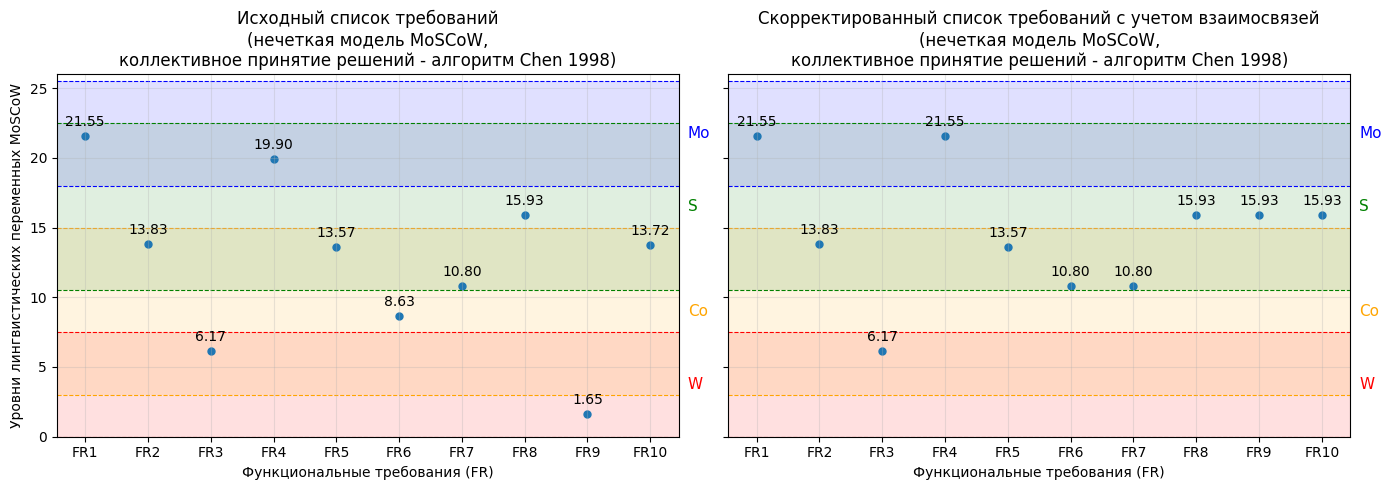

In [171]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразование результатов в словари: {FR: centroid} и {FR: adjusted_centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}
adjusted_centroid_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}

# Формирование списка FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(centroid_by_fr.keys(), key=lambda x: int(x.replace("FR", "")))

# Оценки требований
scores = [centroid_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 7.5),
    "Co": (3.0, 15.0),
    "S":  (10.5, 22.5),
    "Mo": (18.0, 25.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Chen 1998)",
    "Скорректированный список требований с учетом взаимосвязей\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Chen 1998)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 26)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Версия с загрузкой данных из файла и выгрузкой итогов в файл Excel**

In [172]:
# Нечеткий метод приоритизации MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Решение принимается группой из произвольного числа экспертов по модели Chen 1998.
# Веса экспертов четкие, изначально ненормализованные, в процессе реализации алгоритма выполняется их нормализация.
# Загрузка данных и выгрузка результатов - из файла / в файл Excel.

import re
from typing import Dict, Any, Sequence, Optional, List, Tuple
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter


# 1. Типы данных и шкалы MoSCoW
Trap = Tuple[float, float, float, float]
IT2 = Tuple[Trap, Trap]
EPS = 1e-12

MOSCOW_NFR_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0.0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0.0, 0.0, 0.0, 0.22), (0.0, 0.0, 0.0, 0.15))
}

_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)


# 2. Нормализация обозначений приоритетов MoSCoW
def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")

    s = str(x).strip()
    s_upper = s.upper()

    if s_upper in {"MO", "M0"}:
        return "Mo"
    if s_upper == "CO":
        return "Co"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W")


# 3. Загрузка листа эксперта
def load_expert_sheet(ws) -> Dict[str, Any]:
    # 3.1. Поиск строки заголовков NFR
    nfr_header_row = None
    nfr_names: List[str] = []
    nfr_cols: List[int] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 2:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 3.2. Поиск строки приоритетов NFR
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(normalize_moscow_label(v))

    # 3.3. Поиск шапки таблицы FR
    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    # 3.4. Чтение строк FR
    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break
        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else normalize_moscow_label(v))

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    if not fr_names:
        raise ValueError(f"Не найдено ни одной строки FR на листе '{ws.title}'.")

    return {
        "name": ws.title,
        "nfr": nfr_priorities,
        "fr_names": fr_names,
        "frs": fr_matrix
    }


# 4. Расчет нечетких оценок по одному эксперту
def pfr_moscow_it2(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Optional[Sequence[str]] = None,
) -> List[Dict[str, Any]]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []
    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,
            "ratings": list(fr_row)
        })

    return results


# 5. Подготовка данных экспертов
def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]


def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)
        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared


# 6. Нормализация нечетких оценок и параметров модели
def normalize_y(y1: float, y2: float) -> Tuple[float, float, float]:
    s = y1 + y2
    if abs(s) <= EPS:
        raise ValueError("y1 + y2 не должно быть равно 0.")
    return (y1 / s, y2 / s, s)


def find_global_m_it2(experts_prepared: Sequence[Dict[str, Any]], fr_list: Sequence[str]) -> float:
    m = 0.0
    for e in experts_prepared:
        for fr in fr_list:
            (a, b, c, d), (e2, f, g, h) = e["ratings"][fr]
            m = max(m, float(d), float(h))
    if m <= 0:
        raise ValueError("m должно быть > 0.")
    return m


def normalize_it2_number(it2: IT2, m: float) -> IT2:
    (a, b, c, d), (e, f, g, h) = it2
    return ((a / m, b / m, c / m, d / m), (e / m, f / m, g / m, h / m))


def normalize_it2_ratings_for_prepared_experts(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str]
) -> Tuple[List[Dict[str, Any]], float]:
    if not prepared_experts:
        raise ValueError("prepared_experts не должен быть пустым.")
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    m = find_global_m_it2(prepared_experts, fr_names)

    new_list: List[Dict[str, Any]] = []
    for e in prepared_experts:
        new_ratings = {fr: normalize_it2_number(e["ratings"][fr], m) for fr in fr_names}
        new_list.append({
            "name": e["name"],
            "r": e.get("r"),
            "w": e["w"],
            "ratings": new_ratings
        })

    return new_list, m


# 7. Расчет матриц сходства и степеней согласия
def similarity_trap(A: Trap, B: Trap) -> float:
    a1, b1, c1, d1 = A
    a2, b2, c2, d2 = B
    s = 1.0 - (abs(a1 - a2) + abs(b1 - b2) + abs(c1 - c2) + abs(d1 - d2)) / 4.0
    return max(0.0, min(1.0, float(s)))


def similarity_matrix_traps(traps: Sequence[Trap]) -> List[List[float]]:
    n = len(traps)
    return [[similarity_trap(traps[i], traps[j]) for j in range(n)] for i in range(n)]


def build_similarity_matrices_it2_for_all_fr(
    prepared_experts_norm: Sequence[Dict[str, Any]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, List[List[float]]], Dict[str, List[List[float]]]]:
    if not prepared_experts_norm:
        raise ValueError("prepared_experts_norm не должен быть пустым.")
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    S_upper_by_fr: Dict[str, List[List[float]]] = {}
    S_lower_by_fr: Dict[str, List[List[float]]] = {}

    for fr in fr_names:
        uppers: List[Trap] = []
        lowers: List[Trap] = []
        for e in prepared_experts_norm:
            it2: IT2 = e["ratings"][fr]
            upper, lower = it2
            uppers.append(upper)
            lowers.append(lower)

        S_upper_by_fr[fr] = similarity_matrix_traps(uppers)
        S_lower_by_fr[fr] = similarity_matrix_traps(lowers)

    return S_upper_by_fr, S_lower_by_fr


def average_agreement_from_S(S: List[List[float]]) -> List[float]:
    n = len(S)
    if n == 0 or any(len(row) != n for row in S):
        raise ValueError("Матрица S должна быть непустой и квадратной.")

    if n < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")

    A: List[float] = []
    for i in range(n):
        s = sum(S[i][j] for j in range(n) if j != i)
        A.append(s / (n - 1))

    return A

def compute_A_for_all_fr(
    S_upper_by_fr: Dict[str, List[List[float]]],
    S_lower_by_fr: Dict[str, List[List[float]]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, List[float]], Dict[str, List[float]]]:
    A_U_by_fr: Dict[str, List[float]] = {}
    A_L_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in S_upper_by_fr or fr not in S_lower_by_fr:
            raise ValueError(f"Нет матрицы S для {fr}.")
        A_U_by_fr[fr] = average_agreement_from_S(S_upper_by_fr[fr])
        A_L_by_fr[fr] = average_agreement_from_S(S_lower_by_fr[fr])

    return A_U_by_fr, A_L_by_fr


def compute_A_general_for_all_fr(
    A_U_by_fr: Dict[str, List[float]],
    A_L_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
    eps: float = 1e-12
) -> Dict[str, List[float]]:
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    A_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in A_U_by_fr:
            raise ValueError(f"Нет A_U_by_fr для {fr}.")
        if fr not in A_L_by_fr:
            raise ValueError(f"Нет A_L_by_fr для {fr}.")

        Au = A_U_by_fr[fr]
        Al = A_L_by_fr[fr]

        if len(Au) != len(Al):
            raise ValueError(f"{fr}: длины A_U и A_L должны совпадать (Au={len(Au)}, Al={len(Al)}).")
        if len(Au) == 0:
            raise ValueError(f"{fr}: списки A_U/A_L не должны быть пустыми.")

        A_by_fr[fr] = [(Au[i] + Al[i]) / 2.0 for i in range(len(Au))]

        if any((a < -eps) for a in A_by_fr[fr]):
            raise ValueError(f"{fr}: обнаружены отрицательные значения A(Ei). Проверь матрицы сходства.")

    return A_by_fr


def relative_agreement(A: Sequence[float], eps: float = 1e-12) -> Tuple[List[float], float]:
    if not A:
        raise ValueError("A не должен быть пустым.")
    sumA = float(sum(A))
    if abs(sumA) <= eps:
        raise ValueError("sum(A) не должно быть равно 0.")
    RA = [float(ai) / sumA for ai in A]
    return RA, sumA


def compute_RA_for_all_fr_general(
    A_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, List[float]], Dict[str, float]]:
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    RA_by_fr: Dict[str, List[float]] = {}
    sumA_by_fr: Dict[str, float] = {}

    for fr in fr_names:
        if fr not in A_by_fr:
            raise ValueError(f"Нет A_by_fr для {fr}.")
        ra, sum_a = relative_agreement(A_by_fr[fr])
        RA_by_fr[fr] = ra
        sumA_by_fr[fr] = sum_a

    return RA_by_fr, sumA_by_fr


def consensus_coefficients(
    w_norm: Sequence[float],
    ra: Sequence[float],
    y1_norm: float,
    y2_norm: float
) -> List[float]:
    if len(w_norm) != len(ra):
        raise ValueError("Длины w_norm и RA должны совпадать.")
    return [y1_norm * w_norm[i] + y2_norm * ra[i] for i in range(len(ra))]


def compute_C_for_all_fr_general(
    prepared_experts_norm: Sequence[Dict[str, Any]],
    RA_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
    y1_norm: float,
    y2_norm: float
) -> Dict[str, List[float]]:
    w_norm = [float(e["w"]) for e in prepared_experts_norm]
    n_experts = len(w_norm)

    C_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in RA_by_fr:
            raise ValueError(f"Нет RA_by_fr для {fr}")
        if len(RA_by_fr[fr]) != n_experts:
            raise ValueError(
                f"{fr}: длина RA({len(RA_by_fr[fr])}) должна совпадать с числом экспертов ({n_experts})"
            )
        C_by_fr[fr] = consensus_coefficients(w_norm, RA_by_fr[fr], y1_norm, y2_norm)

    return C_by_fr


# 8. Коллективная агрегация
def aggregate_group_it2_by_fr_chen(
    prepared_experts: Sequence[Dict[str, Any]],
    C_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str]
) -> Dict[str, IT2]:
    R_group_by_fr: Dict[str, IT2] = {}

    for fr in fr_list:
        total: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for i, ex in enumerate(prepared_experts):
            scaled = multiply_fuzzy_number_by_constant(ex["ratings"][fr], C_by_fr[fr][i])
            total = add_intuitionistic_trapezoidal_fuzzy_numbers(total, scaled)

        (a, b, c, d), (e2, f, g, h) = total
        R_group_by_fr[fr] = (
            (round(a, 2), round(b, 2), round(c, 2), round(d, 2)),
            (round(e2, 2), round(f, 2), round(g, 2), round(h, 2))
        )

    return R_group_by_fr


# 9. Дефаззификация по новой схеме
def build_defuzz_rows(
    pfr_by_fr: Dict[str, IT2],
    a: float,
    alpha: float
) -> List[Dict[str, Any]]:
    rows = []
    for fr, it2 in pfr_by_fr.items():
        pfr_t1 = cltr_type_reduction(it2, a)
        cut = alpha_cut(pfr_t1, alpha)
        centroid_value = centroid(cut)

        (a1, b1, c1, d1), (e1, f1, g1, h1) = it2
        t1_1, t1_2, t1_3, t1_4 = pfr_t1
        cut_start, cut_end = cut

        rows.append({
            "fr": fr,
            "umf": (a1, b1, c1, d1),
            "lmf": (e1, f1, g1, h1),
            "t1": (t1_1, t1_2, t1_3, t1_4),
            "alpha_cut": (cut_start, cut_end),
            "centroid": centroid_value,
        })

    return sorted(rows, key=lambda x: x["centroid"], reverse=True)

# 10. Учет взаимосвязанности функциональных требований
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. Нарушение в позициях [{i}][{j}] и [{j}][{i}]"
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn без пропусков и повторов"
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {fr_to_index(item["fr"]): item for item in adjusted}
    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted


# 11. Настройка оформления Excel
def autosize_columns(ws, min_width: int = 12, max_width: int = 80, extra_padding: int = 3):
    for col_cells in ws.columns:
        max_len = 0
        col_idx = col_cells[0].column
        for c in col_cells:
            value = "" if c.value is None else str(c.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_len = max(max_len, longest)

        adjusted_width = max_len + extra_padding
        ws.column_dimensions[get_column_letter(col_idx)].width = max(min_width, min(adjusted_width, max_width))


def autosize_rows(ws, base_height: float = 18.0, extra_padding: float = 3.0):
    for row_cells in ws.iter_rows():
        row_num = row_cells[0].row
        if ws.row_dimensions[row_num].height is not None:
            continue

        max_lines = 1
        max_text_len = 0
        for c in row_cells:
            value = "" if c.value is None else str(c.value)
            line_count = value.count("\n") + 1
            max_lines = max(max_lines, line_count)
            max_text_len = max(max_text_len, len(value))

        height = base_height * max_lines
        if max_text_len > 35:
            height += extra_padding
        if max_text_len > 60:
            height += extra_padding

        ws.row_dimensions[row_num].height = height

def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):
                if ws.title == "Матрица_взаимосвязей_FR":
                    cell.number_format = "0"
                elif ws.title in {"Нечеткий MoSCoW_расчеты", "Нечеткий MoSCoW_итоги"} and cell.column == 1:
                    cell.number_format = "0"
                else:
                    cell.number_format = "0.00"

def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

# 12. Вспомогательные блоки Excel
def write_weights_block(ws, start_row: int, expert_names: List[str], r_raw: List[float], w_norm: List[float]) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1).value = "1) Веса экспертов"
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 1

    ws.cell(start_row, 1).value = "Эксперт"
    ws.cell(start_row, 2).value = "Вес_raw (r)"
    ws.cell(start_row, 3).value = "Вес_norm (w)"
    for c in [1, 2, 3]:
        ws.cell(start_row, c).font = bold
        ws.cell(start_row, c).alignment = center

    for i, (nm, rr, ww) in enumerate(zip(expert_names, r_raw, w_norm), start=1):
        rrw = start_row + i
        ws.cell(rrw, 1).value = nm
        ws.cell(rrw, 2).value = float(rr)
        ws.cell(rrw, 3).value = float(ww)
        ws.cell(rrw, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(rrw, 2).alignment = center
        ws.cell(rrw, 3).alignment = center

    sum_row = start_row + len(expert_names) + 1
    ws.cell(sum_row, 1).value = "SUM"
    ws.cell(sum_row, 2).value = float(sum(r_raw))
    ws.cell(sum_row, 3).value = float(sum(w_norm))
    for c in [1, 2, 3]:
        ws.cell(sum_row, c).font = bold
        ws.cell(sum_row, c).alignment = center if c > 1 else Alignment(horizontal="left", vertical="center", wrap_text=True)

    return sum_row + 2

def write_alpha_params(
    ws,
    start_row: int,
    alpha: float,
    y1: float,
    y2: float,
    y1_norm: float,
    y2_norm: float,
    a: float,
    m: float
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1).value = "2) Параметры модели"
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 1

    ws.cell(start_row, 1).value = "Параметр"
    ws.cell(start_row, 2).value = "Значение"
    ws.cell(start_row, 1).font = bold
    ws.cell(start_row, 2).font = bold
    ws.cell(start_row, 1).alignment = center
    ws.cell(start_row, 2).alignment = center
    start_row += 1

    params = [
        ("alpha (уровень альфа-среза)", alpha),
        ("y1", y1),
        ("y2", y2),
        ("y1_norm", y1_norm),
        ("y2_norm", y2_norm),
        ("a (редукция типа CLTR)", a),
        ("m (глобальный коэффициент нормализации)", m),
    ]

    for name, value in params:
        ws.cell(start_row, 1).value = name
        ws.cell(start_row, 2).value = float(value)
        ws.cell(start_row, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(start_row, 2).alignment = center

        if name == "m (глобальный коэффициент нормализации)":
            ws.row_dimensions[start_row].height = 36

        start_row += 1

    return start_row + 1

def write_result_table(
    ws,
    start_row: int,
    title: str,
    rows_sorted: List[Dict[str, Any]],
    include_adjusted: bool = False
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    title_col_end = 18 if include_adjusted else 17
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=title_col_end)
    c = ws.cell(start_row, 1)
    c.value = title
    c.font = bold
    apply_single_line_heading(c)
    ws.row_dimensions[start_row].height = 20

    r1 = start_row + 1
    r2 = start_row + 2

    ws.merge_cells(start_row=r1, start_column=1, end_row=r2, end_column=1)
    ws.merge_cells(start_row=r1, start_column=2, end_row=r2, end_column=2)
    ws.merge_cells(start_row=r1, start_column=3, end_row=r1, end_column=10)
    ws.merge_cells(start_row=r1, start_column=11, end_row=r1, end_column=14)
    ws.merge_cells(start_row=r1, start_column=15, end_row=r1, end_column=16)
    ws.merge_cells(start_row=r1, start_column=17, end_row=r2, end_column=17)

    if include_adjusted:
        ws.merge_cells(start_row=r1, start_column=18, end_row=r2, end_column=18)

    ws.cell(r1, 1).value = "Место"
    ws.cell(r1, 2).value = "FR"
    ws.cell(r1, 3).value = "Итоговый приоритет функционального требования в виде ИНМТ2"
    ws.cell(r1, 11).value = "Редуцированный приоритет FR в виде ИНМТ1"
    ws.cell(r1, 15).value = "Дефаззификация (альфа-срез)"
    ws.cell(r1, 17).value = "Центроид"

    cols_top = [1, 2, 3, 11, 15, 17]
    if include_adjusted:
        ws.cell(r1, 18).value = "Скорректированный центроид"
        cols_top.append(18)

    for col in cols_top:
        ws.cell(r1, col).font = bold
        ws.cell(r1, col).alignment = center

    second_headers = [
        "UMF_x1", "UMF_x2", "UMF_x3", "UMF_x4",
        "LMF_x1", "LMF_x2", "LMF_x3", "LMF_x4",
        "T1_x1", "T1_x2", "T1_x3", "T1_x4",
        "alpha_start", "alpha_end"
    ]

    for idx, header in enumerate(second_headers, start=3):
        ws.cell(r2, idx).value = header
        ws.cell(r2, idx).font = bold
        ws.cell(r2, idx).alignment = center

    ws.row_dimensions[r1].height = 28
    ws.row_dimensions[r2].height = 22

    data_start = start_row + 3
    for i, item in enumerate(rows_sorted, start=1):
        rr = data_start + (i - 1)
        ws.cell(rr, 1).value = i
        ws.cell(rr, 2).value = item["fr"]

        (a1, b1, c1, d1) = item["umf"]
        (e1, f1, g1, h1) = item["lmf"]
        (t1_1, t1_2, t1_3, t1_4) = item["t1"]
        cut_start, cut_end = item["alpha_cut"]

        values = [a1, b1, c1, d1, e1, f1, g1, h1, t1_1, t1_2, t1_3, t1_4, cut_start, cut_end]
        for j, val in enumerate(values, start=3):
            ws.cell(rr, j).value = float(val)

        ws.cell(rr, 17).value = float(item["centroid"])
        if include_adjusted:
            ws.cell(rr, 18).value = float(item["adjusted_centroid"])

        ws.cell(rr, 1).alignment = center
        ws.cell(rr, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for j in range(3, 18 + int(include_adjusted)):
            ws.cell(rr, j).alignment = center

    return data_start + len(rows_sorted) + 2

def write_normalized_it2_block(
    ws,
    start_row: int,
    expert_name: str,
    rows_sorted: List[Dict[str, Any]]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1).value = f"Нормализованные IT2-оценки эксперта: {expert_name}"
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 1

    headers = ["FR", "UMF_x1", "UMF_x2", "UMF_x3", "UMF_x4", "LMF_x1", "LMF_x2", "LMF_x3", "LMF_x4"]
    for idx, h in enumerate(headers, start=1):
        ws.cell(start_row, idx).value = h
        ws.cell(start_row, idx).font = bold
        ws.cell(start_row, idx).alignment = center
    start_row += 1

    for item in rows_sorted:
        ws.cell(start_row, 1).value = item["fr"]
        ws.cell(start_row, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        (a1, b1, c1, d1) = item["umf"]
        (e1, f1, g1, h1) = item["lmf"]
        vals = [a1, b1, c1, d1, e1, f1, g1, h1]
        for idx, val in enumerate(vals, start=2):
            ws.cell(start_row, idx).value = float(val)
            ws.cell(start_row, idx).alignment = center
        start_row += 1

    return start_row + 1

def write_dual_matrices_block(
    ws,
    start_row: int,
    title: str,
    subtitle_left: str,
    subtitle_right: str,
    fr_list: List[str],
    mats_left: Dict[str, List[List[float]]],
    mats_right: Dict[str, List[List[float]]],
    expert_names: List[str]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    k = len(expert_names)
    left_start = 1
    left_width = 1 + k
    gap = 2
    right_start = left_start + left_width + gap
    right_width = 1 + k
    end_col = right_start + right_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    ws.merge_cells(start_row=start_row + 1, start_column=left_start, end_row=start_row + 1, end_column=left_start + left_width - 1)
    ws.merge_cells(start_row=start_row + 1, start_column=right_start, end_row=start_row + 1, end_column=right_start + right_width - 1)
    ws.cell(start_row + 1, left_start).value = subtitle_left
    ws.cell(start_row + 1, right_start).value = subtitle_right
    ws.cell(start_row + 1, left_start).font = bold
    ws.cell(start_row + 1, right_start).font = bold
    ws.cell(start_row + 1, left_start).alignment = center
    ws.cell(start_row + 1, right_start).alignment = center

    r = start_row + 3

    for fr in fr_list:
        ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=end_col)
        ws.cell(r, 1).value = fr
        ws.cell(r, 1).font = bold
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        r += 1

        ws.cell(r, left_start).font = bold
        ws.cell(r, left_start).alignment = center
        for j, nm in enumerate(expert_names, start=1):
            ws.cell(r, left_start + j).value = nm
            ws.cell(r, left_start + j).font = bold
            ws.cell(r, left_start + j).alignment = center

        ws.cell(r, right_start).font = bold
        ws.cell(r, right_start).alignment = center
        for j, nm in enumerate(expert_names, start=1):
            ws.cell(r, right_start + j).value = nm
            ws.cell(r, right_start + j).font = bold
            ws.cell(r, right_start + j).alignment = center

        r += 1

        for i, nm in enumerate(expert_names):
            ws.cell(r, left_start).value = nm
            ws.cell(r, left_start).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
            for j in range(k):
                ws.cell(r, left_start + 1 + j).value = float(mats_left[fr][i][j])
                ws.cell(r, left_start + 1 + j).alignment = center

            ws.cell(r, right_start).value = nm
            ws.cell(r, right_start).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
            for j in range(k):
                ws.cell(r, right_start + 1 + j).value = float(mats_right[fr][i][j])
                ws.cell(r, right_start + 1 + j).alignment = center

            r += 1

        r += 1

    return r

def write_dual_vectors_block(
    ws,
    start_row: int,
    title: str,
    subtitle_left: str,
    subtitle_right: str,
    fr_list: List[str],
    vec_left: Dict[str, List[float]],
    vec_right: Dict[str, List[float]],
    expert_names: List[str]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    k = len(expert_names)
    left_start = 1
    left_width = 1 + k
    gap = 2
    right_start = left_start + left_width + gap
    right_width = 1 + k
    end_col = right_start + right_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    ws.merge_cells(start_row=start_row + 1, start_column=left_start, end_row=start_row + 1, end_column=left_start + left_width - 1)
    ws.merge_cells(start_row=start_row + 1, start_column=right_start, end_row=start_row + 1, end_column=right_start + right_width - 1)

    ws.cell(start_row + 1, left_start).value = subtitle_left
    ws.cell(start_row + 1, right_start).value = subtitle_right
    ws.cell(start_row + 1, left_start).font = bold
    ws.cell(start_row + 1, right_start).font = bold
    apply_single_line_heading(ws.cell(start_row + 1, left_start))
    apply_single_line_heading(ws.cell(start_row + 1, right_start))

    r = start_row + 3

    left_headers = ["FR"] + expert_names
    right_headers = ["FR"] + expert_names

    for idx, header in enumerate(left_headers):
        ws.cell(r, left_start + idx).value = header
        ws.cell(r, left_start + idx).font = bold
        ws.cell(r, left_start + idx).alignment = center

    for idx, header in enumerate(right_headers):
        ws.cell(r, right_start + idx).value = header
        ws.cell(r, right_start + idx).font = bold
        ws.cell(r, right_start + idx).alignment = center

    r += 1

    for fr in fr_list:
        ws.cell(r, left_start).value = fr
        ws.cell(r, left_start).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for j, val in enumerate(vec_left[fr], start=1):
            ws.cell(r, left_start + j).value = float(val)
            ws.cell(r, left_start + j).alignment = center

        ws.cell(r, right_start).value = fr
        ws.cell(r, right_start).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for j, val in enumerate(vec_right[fr], start=1):
            ws.cell(r, right_start + j).value = float(val)
            ws.cell(r, right_start + j).alignment = center

        r += 1

    return r + 1

def write_single_vectors_block(
    ws,
    start_row: int,
    title: str,
    fr_list: List[str],
    vec: Dict[str, List[float]],
    expert_names: List[str]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    end_col = 1 + len(expert_names)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    r = start_row + 2

    headers = ["FR"] + expert_names
    for idx, header in enumerate(headers, start=1):
        ws.cell(r, idx).value = header
        ws.cell(r, idx).font = bold
        ws.cell(r, idx).alignment = center
    r += 1

    for fr in fr_list:
        ws.cell(r, 1).value = fr
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for i, val in enumerate(vec[fr], start=2):
            ws.cell(r, i).value = float(val)
            ws.cell(r, i).alignment = center
        r += 1

    return r + 1

def write_adjusted_summary_table(
    ws,
    start_row: int,
    title: str,
    adjusted_group_rows: List[Dict[str, Any]]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=4)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    header_row = start_row + 1
    headers = ["Место", "FR", "Исходный центроид", "Скорректированный\nцентроид"]
    for col, header in enumerate(headers, start=1):
        ws.cell(header_row, col).value = header
        ws.cell(header_row, col).font = bold
        ws.cell(header_row, col).alignment = center

    ws.row_dimensions[header_row].height = 36

    r = header_row + 1
    for idx, item in enumerate(adjusted_group_rows, start=1):
        ws.cell(r, 1).value = idx
        ws.cell(r, 2).value = item["fr"]
        ws.cell(r, 3).value = float(item["centroid"])
        ws.cell(r, 4).value = float(item["adjusted_centroid"])

        ws.cell(r, 1).alignment = center
        ws.cell(r, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(r, 3).alignment = center
        ws.cell(r, 4).alignment = center
        r += 1

    return r + 1

# 13. Лист матрицы взаимосвязанности
def write_relation_matrix_sheet(
    wb: openpyxl.Workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1), horizontal="left")
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(3, j, fr_name).font = header_font
        ws.cell(3, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for i, fr_name in enumerate(fr_names, start=4):
        ws.cell(i, 1, fr_name).font = header_font
        ws.cell(i, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, value)
            ws.cell(i, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=30, extra_padding=4)
    ws.column_dimensions["A"].width = 14
    autosize_rows(ws, base_height=20.0, extra_padding=4.0)


# 14. Лист расчетов
def write_calculations_sheet(
    wb: openpyxl.Workbook,
    sheet_name: str,
    expert_names: List[str],
    r_raw: List[float],
    w_norm: List[float],
    alpha: float,
    y1: float,
    y2: float,
    y1_norm: float,
    y2_norm: float,
    a: float,
    m: float,
    experts_tables: Dict[str, List[Dict[str, Any]]],
    experts_norm_tables: Dict[str, List[Dict[str, Any]]],
    fr_list: List[str],
    S_upper_by_fr: Dict[str, List[List[float]]],
    S_lower_by_fr: Dict[str, List[List[float]]],
    A_U_by_fr: Dict[str, List[float]],
    A_L_by_fr: Dict[str, List[float]],
    A_by_fr: Dict[str, List[float]],
    RA_by_fr: Dict[str, List[float]],
    C_by_fr: Dict[str, List[float]]
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(sheet_name)

    title_font = Font(bold=True, size=12)
    ws.cell(1, 1).value = "Нечеткий MoSCoW - расчеты (коллективное решение, Chen 1998)"
    ws.cell(1, 1).font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    r = 3
    r = write_weights_block(ws, r, expert_names, r_raw, w_norm)
    r = write_alpha_params(ws, r, alpha, y1, y2, y1_norm, y2_norm, a, m)

    for expert_name in expert_names:
        r = write_result_table(
            ws,
            r,
            title=f"3) Индивидуальные результаты эксперта {expert_name}",
            rows_sorted=experts_tables[expert_name],
            include_adjusted=True
        )

    r = write_dual_matrices_block(
        ws,
        r,
        title="4) Матрицы сходства S(Ei, Ej) по функциям принадлежности",
        subtitle_left="S_U(Ei, Ej)",
        subtitle_right="S_L(Ei, Ej)",
        fr_list=fr_list,
        mats_left=S_upper_by_fr,
        mats_right=S_lower_by_fr,
        expert_names=expert_names
    )

    r = write_dual_vectors_block(
        ws,
        r,
        title="5) Средняя степень согласия эксперта A(Ei) по функциям принадлежности",
        subtitle_left="A_U(Ei)",
        subtitle_right="A_L(Ei)",
        fr_list=fr_list,
        vec_left=A_U_by_fr,
        vec_right=A_L_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="6) Обобщенная средняя степень согласия эксперта A(Ei)",
        fr_list=fr_list,
        vec=A_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="7) Относительная степень согласия эксперта RA(Ei)",
        fr_list=fr_list,
        vec=RA_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="8) Коэффициент степени консенсуса эксперта C(Ei)",
        fr_list=fr_list,
        vec=C_by_fr,
        expert_names=expert_names
    )

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=26, extra_padding=4)

    ws.column_dimensions["A"].width = 28
    ws.column_dimensions["K"].width = 12
    ws.column_dimensions["O"].width = 14
    ws.column_dimensions["P"].width = 14
    ws.column_dimensions["R"].width = 22

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 15. Лист итогов
def write_totals_sheet(
    wb: openpyxl.Workbook,
    sheet_name: str,
    rows_sorted_group: List[Dict[str, Any]],
    adjusted_group_rows: List[Dict[str, Any]]
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(sheet_name)

    title_font = Font(bold=True, size=12)

    ws.cell(1, 1).value = "Нечеткий MoSCoW - итоги (коллективное решение, Chen 1998)"
    ws.cell(1, 1).font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    r = 3
    r = write_result_table(
        ws,
        r,
        title="1) Итоговые нечеткие приоритеты и результаты дефаззификации",
        rows_sorted=rows_sorted_group,
        include_adjusted=False
    )

    r = write_adjusted_summary_table(
        ws,
        r,
        title="2) Итоговая приоритизация после учета взаимосвязанности",
        adjusted_group_rows=adjusted_group_rows
    )

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=26, extra_padding=4)

    ws.column_dimensions["A"].width = 12
    ws.column_dimensions["K"].width = 12
    ws.column_dimensions["O"].width = 14
    ws.column_dimensions["P"].width = 14

    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 16. Главная функция
def fuzzy_group_moscow_chen_from_excel(
    input_xlsx: str,
    output_xlsx: Optional[str] = None,
    weights_raw: Optional[Sequence[float]] = None,
    relation_matrix: Optional[Sequence[Sequence[int]]] = None,
    alpha: float = 0.8,
    y1: float = 0.9,
    y2: float = 0.6,
    a: float = 0.6,
    calculations_sheet_name: str = "Нечеткий MoSCoW_расчеты",
    totals_sheet_name: str = "Нечеткий MoSCoW_итоги"
) -> str:
    wb = openpyxl.load_workbook(input_xlsx)

    skip_sheets = {
        "Матрица_взаимосвязей_FR",
        calculations_sheet_name,
        totals_sheet_name
    }

    expert_sheets = [ws for ws in wb.worksheets if ws.title not in skip_sheets]
    if len(expert_sheets) == 0:
        raise ValueError("Не найдены листы экспертов.")

    experts = [load_expert_sheet(ws) for ws in expert_sheets]
    expert_names = [e["name"] for e in experts]

    fr_list = experts[0]["fr_names"]
    if not fr_list:
        raise ValueError("Не найден список FR.")

    for e in experts[1:]:
        if e["fr_names"] != fr_list:
            raise ValueError("На листах экспертов должны совпадать списки FR.")

    if weights_raw is None:
        weights_raw = [1.0] * len(experts)

    if len(weights_raw) != len(experts):
        raise ValueError("Количество весов экспертов должно совпадать с количеством листов экспертов.")

    if relation_matrix is None:
        n = len(fr_list)
        relation_matrix = [[1 if i == j else 0 for j in range(n)] for i in range(n)]

    if len(relation_matrix) != len(fr_list) or any(len(row) != len(fr_list) for row in relation_matrix):
        raise ValueError("Матрица взаимосвязанности должна быть квадратной и согласованной с количеством FR.")

    prepared_experts = prepare_moscow_it2_inputs(
        experts=experts,
        expert_weights_raw=weights_raw,
        fr_names=fr_list,
        normalize_weights=True
    )

    prepared_experts_norm, m = normalize_it2_ratings_for_prepared_experts(
        prepared_experts=prepared_experts,
        fr_names=fr_list
    )

    S_upper_by_fr, S_lower_by_fr = build_similarity_matrices_it2_for_all_fr(
        prepared_experts_norm=prepared_experts_norm,
        fr_names=fr_list
    )

    A_U_by_fr, A_L_by_fr = compute_A_for_all_fr(
        S_upper_by_fr=S_upper_by_fr,
        S_lower_by_fr=S_lower_by_fr,
        fr_names=fr_list
    )

    A_by_fr = compute_A_general_for_all_fr(
        A_U_by_fr=A_U_by_fr,
        A_L_by_fr=A_L_by_fr,
        fr_names=fr_list
    )

    RA_by_fr, _ = compute_RA_for_all_fr_general(
        A_by_fr=A_by_fr,
        fr_names=fr_list
    )

    y1_norm, y2_norm, _ = normalize_y(y1, y2)

    C_by_fr = compute_C_for_all_fr_general(
        prepared_experts_norm=prepared_experts_norm,
        RA_by_fr=RA_by_fr,
        fr_names=fr_list,
        y1_norm=y1_norm,
        y2_norm=y2_norm
    )

    R_group_by_fr = aggregate_group_it2_by_fr_chen(
        prepared_experts=prepared_experts,
        C_by_fr=C_by_fr,
        fr_list=fr_list
    )

    w_norm = [float(ex["w"]) for ex in prepared_experts]

    experts_tables: Dict[str, List[Dict[str, Any]]] = {}
    for ex in prepared_experts:
        rows_sorted = build_defuzz_rows(
            pfr_by_fr=ex["ratings"],
            a=a,
            alpha=alpha
        )

        adjusted_rows = adjust_fuzzy_ranked_by_interdependencies(rows_sorted, relation_matrix)
        adjusted_map = {item["fr"]: item["adjusted_centroid"] for item in adjusted_rows}

        combined = []
        for item in rows_sorted:
            new_item = dict(item)
            new_item["adjusted_centroid"] = float(adjusted_map[item["fr"]])
            combined.append(new_item)

        combined = sorted(combined, key=lambda x: (-x["adjusted_centroid"], -x["centroid"], x["fr"]))
        experts_tables[ex["name"]] = combined

    experts_norm_tables: Dict[str, List[Dict[str, Any]]] = {}
    for ex in prepared_experts_norm:
        rows = []
        for fr in fr_list:
            it2 = ex["ratings"][fr]
            (a1, b1, c1, d1), (e1, f1, g1, h1) = it2
            rows.append({
                "fr": fr,
                "umf": (a1, b1, c1, d1),
                "lmf": (e1, f1, g1, h1)
            })
        experts_norm_tables[ex["name"]] = rows

    rows_sorted_group = build_defuzz_rows(
        pfr_by_fr=R_group_by_fr,
        a=a,
        alpha=alpha
    )
    adjusted_group_rows = adjust_fuzzy_ranked_by_interdependencies(rows_sorted_group, relation_matrix)

    write_relation_matrix_sheet(
        wb=wb,
        fr_names=fr_list,
        relation_matrix=relation_matrix,
        sheet_name="Матрица_взаимосвязей_FR"
    )

    write_calculations_sheet(
        wb=wb,
        sheet_name=calculations_sheet_name,
        expert_names=expert_names,
        r_raw=list(weights_raw),
        w_norm=w_norm,
        alpha=alpha,
        y1=y1,
        y2=y2,
        y1_norm=y1_norm,
        y2_norm=y2_norm,
        a=a,
        m=m,
        experts_tables=experts_tables,
        experts_norm_tables=experts_norm_tables,
        fr_list=fr_list,
        S_upper_by_fr=S_upper_by_fr,
        S_lower_by_fr=S_lower_by_fr,
        A_U_by_fr=A_U_by_fr,
        A_L_by_fr=A_L_by_fr,
        A_by_fr=A_by_fr,
        RA_by_fr=RA_by_fr,
        C_by_fr=C_by_fr
    )

    write_totals_sheet(
        wb=wb,
        sheet_name=totals_sheet_name,
        rows_sorted_group=rows_sorted_group,
        adjusted_group_rows=adjusted_group_rows
    )

    desired_order = expert_names + [
        "Матрица_взаимосвязей_FR",
        calculations_sheet_name,
        totals_sheet_name
    ]
    wb._sheets = [wb[name] for name in desired_order if name in wb.sheetnames]

    if output_xlsx is None:
        output_xlsx = input_xlsx

    wb.save(output_xlsx)
    return output_xlsx


In [173]:
# Запуск
relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
]

input_path = "Загрузочные данные_MoSCoW_коллектив.xlsx"
output_path = "Итоги_Fuzzy MoSCoW_Chen 1998.xlsx"

saved_path = fuzzy_group_moscow_chen_from_excel(
    input_xlsx=input_path,
    output_xlsx=output_path,
    weights_raw=[0.75, 0.75, 1.0],
    alpha=0.8,
    y1=0.9,
    y2=0.6,
    a=0.6,
    relation_matrix=relation_matrix,
    calculations_sheet_name="Нечеткий MoSCoW_расчеты",
    totals_sheet_name="Нечеткий MoSCoW_итоги",
)

print("Файл сохранен:", saved_path)

Файл сохранен: Итоги_Fuzzy MoSCoW_Chen 1998.xlsx


# 2.3.2. Четкий MoSCoW + Аналог алгоритма Chen 1998 (КПР) для сравнения с нечетким алгоритмом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://www.tandfonline.com/doi/abs/10.1080/019697298125641

Chen, S. M. Aggregating fuzzy opinions in the group decision-making environment // Cybernetics & Systems. 1998, 29(4). PP. 363-376

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [174]:
# Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке
from typing import Sequence, Any, Dict, Tuple, List, Optional

# Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, float] = {"Mo": 8.0, "S": 5.5, "Co": 3.0, "W": 0.5}
MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS)  # {"Mo","S","Co","W"}


def normalize_expert_weights(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    normalize: bool = True,
) -> Tuple[List[str], List[float], Dict[str, float], Dict[str, float]]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_norm_by_name = dict(zip(expert_names, w_norm))
    w_raw_by_name = dict(zip(expert_names, w_raw))
    return expert_names, w_norm, w_norm_by_name, w_raw_by_name


def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # NFR - веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    # FR_NFR - PFR
    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")

        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores

def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    # базовые проверки по структуре FR
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR (поле 'frs').")
    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    # FR names
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    else:
        fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # веса экспертов
    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    # оценки каждого эксперта: {expert - оценки {fr - pfr}}
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,   # список в том же порядке, что expert_names
        "expert_scores": expert_scores,     # ключевой результат шага
        }


In [175]:
# Пример использования (3 эксперта)
S1 = {
    "name": "S1",
    "nfr": ["Mo", "Mo", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "S", "Mo"],
        ["S",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["S",  "Co", "S"],
        ["Co", "Co",  "Co"],
        ["S", "S",  "W"],
        ["S",  "S", "S"],
        ["W",  "W", "W"],
        ["Co", "Co", "Mo"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "S", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "Mo", "Mo"],
        ["S",  "Co",  "W"],
        ["Mo", "Mo",  "Mo"],
        ["S",  "S", "S"],
        ["Co", "S",  "Co"],
        ["S", "Mo",  "W"],
        ["S",  "Mo", "S"],
        ["W",  "Co", "W"],
        ["Co", "S", "Mo"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["S", "Mo", "Mo"],
    "frs": [
       ["Mo", "Mo",  "Mo"],
        ["Co", "S", "Mo"],
        ["Mo",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["Mo",  "Co", "S"],
        ["S", "Co",  "Co"],
        ["Mo", "S",  "W"],
        ["Mo",  "S", "S"],
        ["Co",  "W", "W"],
        ["S", "Co", "Mo"],
    ]
}

experts = [S1, S2, S3]
weights = [0.75, 0.75, 1]  # ненормализованные

prepared = prepare_crisp_moscow_inputs(experts, weights)

print("Normalized weights:", {k: round(v, 2) for k, v in prepared["weights_norm"].items()})
print()

# Печать
fr_names = prepared["fr_names"]
expert_names = prepared["expert_names"]
expert_scores = prepared["expert_scores"]

for fr in fr_names:
    row = {expert: round(expert_scores[expert][fr], 2) for expert in expert_names}
    print(f"{fr}: {row}")


Normalized weights: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

FR1: {'S1': 24.0, 'S2': 21.5, 'S3': 21.5}
FR2: {'S1': 13.28, 'S2': 13.5, 'S3': 15.1}
FR3: {'S1': 5.28, 'S2': 7.1, 'S3': 5.5}
FR4: {'S1': 21.28, 'S2': 21.5, 'S3': 18.78}
FR5: {'S1': 13.2, 'S2': 14.19, 'S3': 13.42}
FR6: {'S1': 7.92, 'S2': 8.91, 'S3': 8.91}
FR7: {'S1': 10.56, 'S2': 10.78, 'S3': 10.78}
FR8: {'S1': 15.84, 'S2': 16.06, 'S3': 16.06}
FR9: {'S1': 0.0, 'S2': 1.82, 'S3': 1.82}
FR10: {'S1': 13.28, 'S2': 14.27, 'S3': 14.27}


In [176]:
# Нормализация входных параметров
def normalize_all_crisp_step1(
    prepared: Dict[str, Any],
    y1: float,
    y2: float,
) -> Dict[str, Any]:
    fr_names: List[str] = list(prepared["fr_names"])
    expert_names: List[str] = list(prepared["expert_names"])
    expert_scores: Dict[str, Dict[str, float]] = prepared["expert_scores"]

    # m = максимальная оценка среди всех экспертов и всех FR
    all_vals: List[float] = []
    for ex in expert_names:
        for fr in fr_names:
            v = float(expert_scores[ex][fr])
            all_vals.append(v)

    if not all_vals:
        raise ValueError("Нет оценок для нормализации (expert_scores пуст).")

    m = max(all_vals)
    if m <= 0:
        raise ValueError("m должно быть > 0 (ожидаются положительные оценки).")

    # нормированные оценки
    scores_norm_by_expert: Dict[str, Dict[str, float]] = {}
    for ex in expert_names:
        scores_norm_by_expert[ex] = {fr: float(expert_scores[ex][fr]) / m for fr in fr_names}

    # нормализация y1 и y2
    s = float(y1) + float(y2)
    if s == 0:
        raise ValueError("y1 + y2 не должно быть равно 0.")
    y1_norm = float(y1) / s
    y2_norm = float(y2) / s

    # веса экспертов уже нормализованы в prepared
    w_norm_list = list(prepared["weights_norm_list"])          # в порядке expert_names
    w_norm_by_expert = dict(prepared["weights_norm"])          # {expert: w}

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,

        "m": m,
        "scores_norm_by_expert": scores_norm_by_expert,

        "y1": float(y1),
        "y2": float(y2),
        "y1_norm": y1_norm,
        "y2_norm": y2_norm,

        "w_norm_list": w_norm_list,
        "w_norm_by_expert": w_norm_by_expert,
    }


def print_step1_summary(
    step1: Dict[str, Any],
    prepared: Dict[str, Any],
    round_to: int = 2
) -> None:
    fr_names = step1["fr_names"]
    expert_names = step1["expert_names"]
    expert_scores = prepared["expert_scores"]
    scores_norm = step1["scores_norm_by_expert"]

    print("1) Нормализация оценок экспертов по всем FR")
    print(f"m (макс. оценка среди всех экспертов и FR) = {step1['m']}")
    for fr in fr_names:
        row_orig = {ex: round(float(expert_scores[ex][fr]), round_to) for ex in expert_names}
        row_norm = {ex: round(float(scores_norm[ex][fr]), round_to) for ex in expert_names}
        print(f"{fr}: norm={row_norm}")

    print("\n2) Нормализация y1 и y2")
    print(f"y1: {step1['y1']} -> {round(step1['y1_norm'], 2)}")
    print(f"y2: {step1['y2']} -> {round(step1['y2_norm'], 2)}")


In [177]:
# Запуск
# y1 - вес степеней важности экспертов, y2 - вес относительной степени согласия экспертов
Y1 = 0.9
Y2 = 0.6

step1 = normalize_all_crisp_step1(prepared, y1=Y1, y2=Y2)
print_step1_summary(step1, prepared)

1) Нормализация оценок экспертов по всем FR
m (макс. оценка среди всех экспертов и FR) = 24.0
FR1: norm={'S1': 1.0, 'S2': 0.9, 'S3': 0.9}
FR2: norm={'S1': 0.55, 'S2': 0.56, 'S3': 0.63}
FR3: norm={'S1': 0.22, 'S2': 0.3, 'S3': 0.23}
FR4: norm={'S1': 0.89, 'S2': 0.9, 'S3': 0.78}
FR5: norm={'S1': 0.55, 'S2': 0.59, 'S3': 0.56}
FR6: norm={'S1': 0.33, 'S2': 0.37, 'S3': 0.37}
FR7: norm={'S1': 0.44, 'S2': 0.45, 'S3': 0.45}
FR8: norm={'S1': 0.66, 'S2': 0.67, 'S3': 0.67}
FR9: norm={'S1': 0.0, 'S2': 0.08, 'S3': 0.08}
FR10: norm={'S1': 0.55, 'S2': 0.59, 'S3': 0.59}

2) Нормализация y1 и y2
y1: 0.9 -> 0.6
y2: 0.6 -> 0.4


In [178]:
# Матрицы согласия для четкого случая:
def similarity_matrix_crisp_abs(norm_scores: List[float]) -> List[List[float]]:
    k = len(norm_scores)
    S = [[0.0] * k for _ in range(k)]
    for i in range(k):
        for j in range(k):
            S[i][j] = 1.0 - abs(norm_scores[i] - norm_scores[j])
    return S


def build_AM_by_fr_crisp(
    step1: Dict[str, Any],
) -> Dict[str, List[List[float]]]:
    fr_names: List[str] = step1["fr_names"]
    expert_names: List[str] = step1["expert_names"]
    scores_norm_by_expert: Dict[str, Dict[str, float]] = step1["scores_norm_by_expert"]

    AM_by_fr: Dict[str, List[List[float]]] = {}
    for fr in fr_names:
        vec = [float(scores_norm_by_expert[ex][fr]) for ex in expert_names]  # в порядке expert_names
        AM_by_fr[fr] = similarity_matrix_crisp_abs(vec)

    return AM_by_fr

def print_AM_by_fr(
    AM_by_fr: Dict[str, List[List[float]]],
    fr_list: List[str],
    round_to: int = 2
) -> None:
    for fr in fr_list:
        print(f"\n{fr}:")
        for row in AM_by_fr[fr]:
            print([round(x, round_to) for x in row])


In [179]:
# Пример запуска:
AM_by_fr = build_AM_by_fr_crisp(step1)
print_AM_by_fr(AM_by_fr, fr_list=step1["fr_names"], round_to=2)


FR1:
[1.0, 0.9, 0.9]
[0.9, 1.0, 1.0]
[0.9, 1.0, 1.0]

FR2:
[1.0, 0.99, 0.92]
[0.99, 1.0, 0.93]
[0.92, 0.93, 1.0]

FR3:
[1.0, 0.92, 0.99]
[0.92, 1.0, 0.93]
[0.99, 0.93, 1.0]

FR4:
[1.0, 0.99, 0.9]
[0.99, 1.0, 0.89]
[0.9, 0.89, 1.0]

FR5:
[1.0, 0.96, 0.99]
[0.96, 1.0, 0.97]
[0.99, 0.97, 1.0]

FR6:
[1.0, 0.96, 0.96]
[0.96, 1.0, 1.0]
[0.96, 1.0, 1.0]

FR7:
[1.0, 0.99, 0.99]
[0.99, 1.0, 1.0]
[0.99, 1.0, 1.0]

FR8:
[1.0, 0.99, 0.99]
[0.99, 1.0, 1.0]
[0.99, 1.0, 1.0]

FR9:
[1.0, 0.92, 0.92]
[0.92, 1.0, 1.0]
[0.92, 1.0, 1.0]

FR10:
[1.0, 0.96, 0.96]
[0.96, 1.0, 1.0]
[0.96, 1.0, 1.0]


In [180]:
# Средняя степень согласия экспертов A_i
# Ai(fr) = среднее AM_ij по j != i
def average_agreement_by_fr(
    AM_by_fr: Dict[str, List[List[float]]],
    expert_names: List[str],
) -> Dict[str, Dict[str, float]]:
    k = len(expert_names)
    if k < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")

    A_by_fr: Dict[str, Dict[str, float]] = {}

    for fr, AM in AM_by_fr.items():
        if len(AM) != k or any(len(row) != k for row in AM):
            raise ValueError(f"{fr}: матрица AM должна быть размера {k}x{k}.")

        A_fr: Dict[str, float] = {}
        for i, name in enumerate(expert_names):
            s = sum(AM[i][j] for j in range(k) if j != i)
            A_fr[name] = s / (k - 1)
        A_by_fr[fr] = A_fr

    return A_by_fr

In [181]:
# Запуск
fr_list = step1["fr_names"]
expert_names = step1["expert_names"]

# AM_by_fr посчитан на прошлом шаге
A_by_fr = average_agreement_by_fr(AM_by_fr, expert_names)

print("Средняя степень согласия экспертов (Ai) по каждому FR:")
for fr in fr_list:
    row = {e: round(A_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}: {row}")

Средняя степень согласия экспертов (Ai) по каждому FR:
FR1: {'S1': 0.9, 'S2': 0.95, 'S3': 0.95}
FR2: {'S1': 0.96, 'S2': 0.96, 'S3': 0.93}
FR3: {'S1': 0.96, 'S2': 0.93, 'S3': 0.96}
FR4: {'S1': 0.94, 'S2': 0.94, 'S3': 0.89}
FR5: {'S1': 0.97, 'S2': 0.96, 'S3': 0.98}
FR6: {'S1': 0.96, 'S2': 0.98, 'S3': 0.98}
FR7: {'S1': 0.99, 'S2': 1.0, 'S3': 1.0}
FR8: {'S1': 0.99, 'S2': 1.0, 'S3': 1.0}
FR9: {'S1': 0.92, 'S2': 0.96, 'S3': 0.96}
FR10: {'S1': 0.96, 'S2': 0.98, 'S3': 0.98}


In [182]:
# Относительные степени согласия экспертов RA(Ei) по каждому FR
# RA_i(fr) = A_i(fr) / sum_i A_i(fr)
def ra_by_fr(
    A_by_fr: Dict[str, Dict[str, float]],
    expert_names: List[str],
) -> Dict[str, Dict[str, float]]:
    if not expert_names:
        raise ValueError("expert_names не должен быть пустым.")

    RA_by_fr: Dict[str, Dict[str, float]] = {}

    for fr, A_fr in A_by_fr.items():
        s = sum(float(A_fr[e]) for e in expert_names)
        if s == 0:
            # если сумма равна нулю, присваиваем равные доли
            RA_by_fr[fr] = {e: 1.0 / len(expert_names) for e in expert_names}
        else:
            RA_by_fr[fr] = {e: float(A_fr[e]) / s for e in expert_names}

    return RA_by_fr

In [183]:
# Запуск:
RA_by_fr = ra_by_fr(A_by_fr, expert_names)

print("RA(Ei) по каждому FR:")
for fr in fr_list:
    row = {e: round(RA_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}: {row}")


RA(Ei) по каждому FR:
FR1: {'S1': 0.32, 'S2': 0.34, 'S3': 0.34}
FR2: {'S1': 0.34, 'S2': 0.34, 'S3': 0.33}
FR3: {'S1': 0.34, 'S2': 0.33, 'S3': 0.34}
FR4: {'S1': 0.34, 'S2': 0.34, 'S3': 0.32}
FR5: {'S1': 0.33, 'S2': 0.33, 'S3': 0.34}
FR6: {'S1': 0.33, 'S2': 0.34, 'S3': 0.34}
FR7: {'S1': 0.33, 'S2': 0.33, 'S3': 0.33}
FR8: {'S1': 0.33, 'S2': 0.33, 'S3': 0.33}
FR9: {'S1': 0.32, 'S2': 0.34, 'S3': 0.34}
FR10: {'S1': 0.33, 'S2': 0.34, 'S3': 0.34}


In [184]:
# Коэффициент степени консенсуса экспертов C(Ei) по каждому FR:
# C_i(fr) = y1_norm * w_i_norm + y2_norm * RA_i(fr)
def C_by_fr(
    RA_by_fr: Dict[str, Dict[str, float]],
    weights_norm_by_name: Dict[str, float],   # prepared["weights_norm"]
    expert_names: List[str],
    y1_norm: float,
    y2_norm: float,
) -> Dict[str, Dict[str, float]]:
    if not (0.0 <= y1_norm <= 1.0 and 0.0 <= y2_norm <= 1.0):
        raise ValueError("y1_norm и y2_norm должны быть в диапазоне [0,1].")
    if abs((y1_norm + y2_norm) - 1.0) > 1e-9:
        raise ValueError("Ожидается, что y1_norm + y2_norm = 1 (после нормализации).")

    C_by_fr_out: Dict[str, Dict[str, float]] = {}
    for fr, RA_fr in RA_by_fr.items():
        C_by_fr_out[fr] = {
            e: y1_norm * float(weights_norm_by_name[e]) + y2_norm * float(RA_fr[e])
            for e in expert_names
        }
    return C_by_fr_out

In [185]:
# Запуск
C_by_fr_out = C_by_fr(
    RA_by_fr=RA_by_fr,
    weights_norm_by_name=prepared["weights_norm"],
    expert_names=expert_names,
    y1_norm=step1["y1_norm"],
    y2_norm=step1["y2_norm"],
)

print(f"C(Ei) по каждому FR (y1_norm={step1['y1_norm']:.3f}, y2_norm={step1['y2_norm']:.3f}):")
for fr in fr_list:
    row = {e: round(C_by_fr_out[fr][e], 2) for e in expert_names}
    print(f"{fr}: {row}")


C(Ei) по каждому FR (y1_norm=0.600, y2_norm=0.400):
FR1: {'S1': 0.31, 'S2': 0.32, 'S3': 0.38}
FR2: {'S1': 0.31, 'S2': 0.32, 'S3': 0.37}
FR3: {'S1': 0.31, 'S2': 0.31, 'S3': 0.38}
FR4: {'S1': 0.32, 'S2': 0.32, 'S3': 0.37}
FR5: {'S1': 0.31, 'S2': 0.31, 'S3': 0.37}
FR6: {'S1': 0.31, 'S2': 0.31, 'S3': 0.37}
FR7: {'S1': 0.31, 'S2': 0.31, 'S3': 0.37}
FR8: {'S1': 0.31, 'S2': 0.31, 'S3': 0.37}
FR9: {'S1': 0.31, 'S2': 0.32, 'S3': 0.38}
FR10: {'S1': 0.31, 'S2': 0.31, 'S3': 0.37}


In [186]:
# Коллективная агрегированная оценка
# R_group(fr) = sum_i [ C_i(fr) * (PFR_i(fr), ненормализованный) ]
def aggregate_group_pfr_by_C(
    expert_scores_raw: Dict[str, Dict[str, float]],   # prepared["expert_scores"] (raw PFR)
    C_by_fr: Dict[str, Dict[str, float]],             # C_by_fr_out
    fr_names: List[str],
    expert_names: List[str],
) -> Dict[str, float]:
    group_scores: Dict[str, float] = {}

    for fr in fr_names:
        s = 0.0
        for e in expert_names:
            s += float(expert_scores_raw[e][fr]) * float(C_by_fr[fr][e])
        group_scores[fr] = s

    return group_scores

In [187]:
# Запуск
group_scores = aggregate_group_pfr_by_C(
    expert_scores_raw=prepared["expert_scores"],   # Ненормализованные оценки
    C_by_fr=C_by_fr_out,                           # коэффициенты консенсуса C(Ei)
    fr_names=prepared["fr_names"],
    expert_names=prepared["expert_names"],
)

print("Групповые приоритеты FR (взвешивание по C(Ei)):")
for fr in prepared["fr_names"]:
    print(f"{fr}: {group_scores[fr]:.2f}")

# Ранжирование:
ranked = sorted(group_scores.items(), key=lambda x: x[1], reverse=True)
print("\nРанжирование:")
for fr, val in ranked:
    print(f"{fr}: {val:.2f}")

Групповые приоритеты FR (взвешивание по C(Ei)):
FR1: 22.27
FR2: 14.02
FR3: 5.93
FR4: 20.43
FR5: 13.59
FR6: 8.60
FR7: 10.71
FR8: 15.99
FR9: 1.25
FR10: 13.96

Ранжирование:
FR1: 22.27
FR4: 20.43
FR8: 15.99
FR2: 14.02
FR10: 13.96
FR5: 13.59
FR7: 10.71
FR6: 8.60
FR3: 5.93
FR9: 1.25


Алгоритм учета взаимосвязанности функциональных требований

In [188]:
def adjust_crisp_scores_by_interdependencies(
    group_scores: Dict[str, float],
    relation_matrix: Sequence[Sequence[int]],
) -> List[tuple[str, float, float]]:

    fr_names = list(group_scores.keys())
    n = len(fr_names)

    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(fr) for fr in fr_names]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в group_scores должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    original_scores = {fr: group_scores[fr] for fr in group_scores}
    adjusted_scores = {fr: group_scores[fr] for fr in group_scores}

    matrix_idx_to_fr = {fr_to_index(fr): fr for fr in group_scores}

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(original_scores[matrix_idx_to_fr[i]] for i in comp)
        for i in comp:
            adjusted_scores[matrix_idx_to_fr[i]] = max_score

    adjusted_ranked = sorted(
        [(fr, original_scores[fr], adjusted_scores[fr]) for fr in group_scores],
        key=lambda x: (-x[2], -x[1], x[0])
    )

    return adjusted_ranked

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [189]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_ranked = adjust_crisp_scores_by_interdependencies(group_scores, relation_matrix)

print("Скорректированное ранжирование:")
for fr, original_val, adjusted_val in adjusted_ranked:
    print(
        f"{fr}: "
        f"исходная оценка = {original_val:.2f}, "
        f"скорректированная оценка = {adjusted_val:.2f}"
    )

Скорректированное ранжирование:
FR1: исходная оценка = 22.27, скорректированная оценка = 22.27
FR4: исходная оценка = 20.43, скорректированная оценка = 22.27
FR8: исходная оценка = 15.99, скорректированная оценка = 15.99
FR10: исходная оценка = 13.96, скорректированная оценка = 15.99
FR9: исходная оценка = 1.25, скорректированная оценка = 15.99
FR2: исходная оценка = 14.02, скорректированная оценка = 14.02
FR5: исходная оценка = 13.59, скорректированная оценка = 13.59
FR7: исходная оценка = 10.71, скорректированная оценка = 10.71
FR6: исходная оценка = 8.60, скорректированная оценка = 10.71
FR3: исходная оценка = 5.93, скорректированная оценка = 5.93


Визуализации исходного и итогового приоритизированного списков функциональных требований

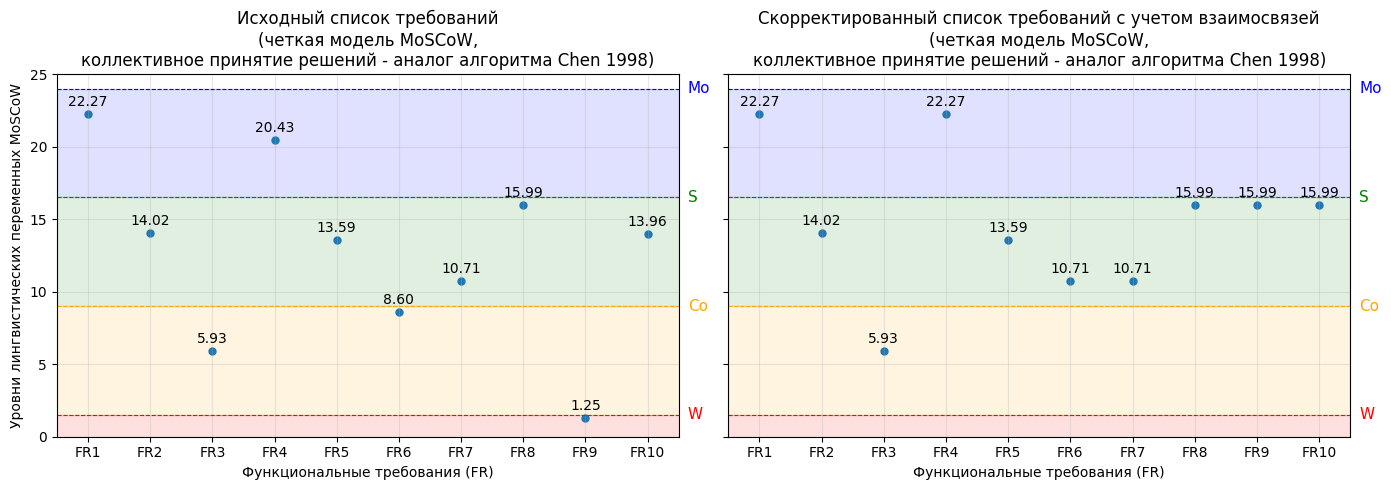

In [190]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразование скорректированного результата в словарь: {FR: adjusted_score}
adjusted_scores_by_fr = {fr: adjusted_val for fr, original_val, adjusted_val in adjusted_ranked}

# ФФормирование списка FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    group_scores.keys(),
    key=lambda x: int(x.replace("FR", ""))
)

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [group_scores[fr] for fr in fr_labels]
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (16.5, 24.0),
    "S": (9.0, 16.5),
    "Co": (1.5, 9.0),
    "W": (0, 1.5)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 24.0,
    "S": 16.5,
    "Co": 9.0,
    "W": 1.5
}

boundary_lines = [1.5, 9.0, 16.5, 24.0]
boundary_colors = {
    1.5: "red",
    9.0: "orange",
    16.5: "green",
    24.0: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Chen 1998)",
    "Скорректированный список требований с учетом взаимосвязей\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Chen 1998)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.35
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 25)
    ax.set_xlim(-0.5, len(fr_labels) - 0.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка из файла/ в файл Excel**

In [191]:
# Четкий алгоритм MoSCoW с коллективными агрегированными оценками.
# Произвольное число экспертов, функциональных требований и критериев их оценки.
# Загрузка и выгрузка из файла/ в файл Excel

import re
from typing import Dict, Any, Sequence, Optional, List, Tuple
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# 1. Типы данных и шкалы MoSCoW
EPS = 1e-12

MOSCOW_NFR_WEIGHTS: Dict[str, float] = {
    "Mo": 8.0,
    "S": 5.5,
    "Co": 3.0,
    "W": 0.5
}

MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {
    "Mo": 1.0,
    "S": 0.66,
    "Co": 0.33,
    "W": 0.0
}

_ALLOWED = set(MOSCOW_NFR_WEIGHTS.keys())
_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)

# 2. Нормализация обозначений приоритетов MoSCoW
def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")

    s = str(x).strip()
    s_upper = s.upper()

    if s_upper in {"MO", "M0"}:
        return "Mo"
    if s_upper == "CO":
        return "Co"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W")

# 3. Загрузка листа эксперта
def load_expert_sheet(ws) -> Dict[str, Any]:
    nfr_header_row = None
    nfr_names: List[str] = []
    nfr_cols: List[int] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 2:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(normalize_moscow_label(v))

    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break
        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else normalize_moscow_label(v))

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    if not fr_names:
        raise ValueError(f"Не найдено ни одной строки FR на листе '{ws.title}'.")

    return {
        "name": ws.title,
        "nfr": nfr_priorities,
        "fr_names": fr_names,
        "frs": fr_matrix
    }

# 4. Расчет PFR по одному эксперту
def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")

        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores

# 5. Подготовка данных экспертов
def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]

def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")

    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")

    if fr_names is None:
        fr_names = experts[0]["fr_names"]
    fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = [float(x) for x in weights]
    if len(w_raw) != len(experts):
        raise ValueError("Длины experts и weights должны совпадать.")

    w_norm = normalize_weights_w(w_raw) if normalize_weights else w_raw[:]

    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": dict(zip(expert_names, w_raw)),
        "weights_norm": dict(zip(expert_names, w_norm)),
        "weights_norm_list": w_norm,
        "expert_scores": expert_scores,
    }

# 6. Нормализация оценок и параметров
def compute_m_max(prepared: Dict[str, Any]) -> float:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]

    all_vals = []
    for fr in fr_names:
        for e in expert_names:
            all_vals.append(float(scores[e][fr]))

    if not all_vals:
        raise ValueError("Нет PFR значений для поиска m.")

    m = max(all_vals)
    if m <= 0:
        raise ValueError("m должно быть > 0.")

    return m

def normalize_scores_by_m(prepared: Dict[str, Any], m: float) -> Dict[str, Dict[str, float]]:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]

    norm_scores: Dict[str, Dict[str, float]] = {}
    for e in expert_names:
        norm_scores[e] = {fr: float(scores[e][fr]) / float(m) for fr in fr_names}
    return norm_scores

def normalize_y(y1: float, y2: float) -> Tuple[float, float, float]:
    s = float(y1) + float(y2)
    if s == 0:
        raise ValueError("y1 + y2 не должно быть равно 0.")
    return float(y1) / s, float(y2) / s, s

# 7. Матрицы согласия
def build_am_matrices_by_fr_norm_scores(
    fr_names: Sequence[str],
    expert_names: Sequence[str],
    norm_scores: Dict[str, Dict[str, float]]
) -> Dict[str, List[List[float]]]:
    am_by_fr: Dict[str, List[List[float]]] = {}
    for fr in fr_names:
        vals = [float(norm_scores[e][fr]) for e in expert_names]
        k = len(vals)
        am = [[0.0] * k for _ in range(k)]
        for i in range(k):
            for j in range(k):
                am[i][j] = 1.0 - abs(vals[i] - vals[j])
        am_by_fr[fr] = am
    return am_by_fr

# 8. A(Ei), RA(Ei), C(Ei)
def average_agreement_by_fr(
    AM_by_fr: Dict[str, List[List[float]]],
    expert_names: List[str]
) -> Dict[str, Dict[str, float]]:
    k = len(expert_names)
    if k < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")

    A_by_fr: Dict[str, Dict[str, float]] = {}
    for fr, AM in AM_by_fr.items():
        if len(AM) != k or any(len(row) != k for row in AM):
            raise ValueError(f"{fr}: матрица AM должна быть размера {k}x{k}.")

        A_fr: Dict[str, float] = {}
        for i, name in enumerate(expert_names):
            s = sum(AM[i][j] for j in range(k) if j != i)
            A_fr[name] = s / (k - 1)
        A_by_fr[fr] = A_fr

    return A_by_fr

def ra_by_fr(
    A_by_fr: Dict[str, Dict[str, float]],
    expert_names: List[str]
) -> Dict[str, Dict[str, float]]:
    RA_by_fr: Dict[str, Dict[str, float]] = {}
    for fr, A_fr in A_by_fr.items():
        s = sum(float(A_fr[e]) for e in expert_names)
        if s == 0:
            RA_by_fr[fr] = {e: 1.0 / len(expert_names) for e in expert_names}
        else:
            RA_by_fr[fr] = {e: float(A_fr[e]) / s for e in expert_names}
    return RA_by_fr

def c_by_fr(
    RA_by_fr: Dict[str, Dict[str, float]],
    weights_norm_by_name: Dict[str, float],
    expert_names: List[str],
    y1_norm: float,
    y2_norm: float
) -> Dict[str, Dict[str, float]]:
    C_by_fr: Dict[str, Dict[str, float]] = {}
    for fr, RA_fr in RA_by_fr.items():
        C_by_fr[fr] = {
            e: float(y1_norm) * float(weights_norm_by_name[e]) + float(y2_norm) * float(RA_fr[e])
            for e in expert_names
        }
    return C_by_fr

# 9. Коллективная агрегация
def contributions_and_group(
    prepared: Dict[str, Any],
    C_by_fr: Dict[str, Dict[str, float]]
) -> Tuple[Dict[str, Dict[str, float]], Dict[str, float]]:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores_raw = prepared["expert_scores"]

    contrib_by_fr: Dict[str, Dict[str, float]] = {}
    group: Dict[str, float] = {}

    for fr in fr_names:
        contrib = {e: float(scores_raw[e][fr]) * float(C_by_fr[fr][e]) for e in expert_names}
        contrib_by_fr[fr] = contrib
        group[fr] = sum(contrib.values())

    return contrib_by_fr, group

# 10. Учет взаимосвязанности функциональных требований
def adjust_crisp_scores_by_interdependencies(
    group_scores: Dict[str, float],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Tuple[str, float, float]]:
    fr_names = list(group_scores.keys())
    n = len(fr_names)

    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    indices = [fr_to_index(fr) for fr in fr_names]
    if sorted(indices) != list(range(n)):
        raise ValueError("Имена требований должны соответствовать полному набору FR1..FRn без пропусков и повторов.")

    original_ranked = sorted(group_scores.items(), key=lambda x: x[1], reverse=True)
    original_rank_map = {fr: idx + 1 for idx, (fr, _) in enumerate(original_ranked)}

    adjusted: List[Dict[str, Any]] = []
    for fr, score in group_scores.items():
        adjusted.append({
            "fr": fr,
            "centroid": float(score),
            "original_rank": original_rank_map[fr],
            "adjusted_centroid": float(score)
        })

    matrix_idx_to_item = {fr_to_index(item["fr"]): item for item in adjusted}
    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components: List[List[int]] = []
    for i in range(n):
        if not visited[i]:
            comp: List[int] = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_score

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return [(item["fr"], float(item["centroid"]), float(item["adjusted_centroid"])) for item in adjusted_sorted]

# 11. Настройка оформления Excel
def autosize_columns(ws, min_width: int = 12, max_width: int = 80, extra_padding: int = 3):
    for col_cells in ws.columns:
        max_len = 0
        col_idx = col_cells[0].column
        for c in col_cells:
            value = "" if c.value is None else str(c.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_len = max(max_len, longest)

        adjusted_width = max_len + extra_padding
        ws.column_dimensions[get_column_letter(col_idx)].width = max(min_width, min(adjusted_width, max_width))

def autosize_rows(ws, base_height: float = 18.0, extra_padding: float = 3.0):
    for row_cells in ws.iter_rows():
        row_num = row_cells[0].row
        if ws.row_dimensions[row_num].height is not None:
            continue

        max_lines = 1
        max_text_len = 0
        for c in row_cells:
            value = "" if c.value is None else str(c.value)
            line_count = value.count("\n") + 1
            max_lines = max(max_lines, line_count)
            max_text_len = max(max_text_len, len(value))

        height = base_height * max_lines
        if max_text_len > 35:
            height += extra_padding
        if max_text_len > 60:
            height += extra_padding

        ws.row_dimensions[row_num].height = height

def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):
                if ws.title == "Матрица_взаимосвязей_FR":
                    cell.number_format = "0"
                elif ws.title in {"Четкий MoSCoW_расчеты", "Четкий MoSCoW_итоги"} and cell.column == 1:
                    cell.number_format = "0"
                else:
                    cell.number_format = "0.00"

def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

# 12. Вспомогательные блоки Excel
def write_weights_block(
    ws,
    start_row: int,
    expert_names: List[str],
    r_raw: List[float],
    w_norm: List[float]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1).value = "1) Веса экспертов"
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 1

    ws.cell(start_row, 1).value = "Эксперт"
    ws.cell(start_row, 2).value = "Вес_raw (r)"
    ws.cell(start_row, 3).value = "Вес_norm (w)"
    for c in [1, 2, 3]:
        ws.cell(start_row, c).font = bold
        ws.cell(start_row, c).alignment = center

    for i, (nm, rr, ww) in enumerate(zip(expert_names, r_raw, w_norm), start=1):
        rrw = start_row + i
        ws.cell(rrw, 1).value = nm
        ws.cell(rrw, 2).value = float(rr)
        ws.cell(rrw, 3).value = float(ww)
        ws.cell(rrw, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(rrw, 2).alignment = center
        ws.cell(rrw, 3).alignment = center

    sum_row = start_row + len(expert_names) + 1
    ws.cell(sum_row, 1).value = "SUM"
    ws.cell(sum_row, 2).value = float(sum(r_raw))
    ws.cell(sum_row, 3).value = float(sum(w_norm))
    for c in [1, 2, 3]:
        ws.cell(sum_row, c).font = bold
        ws.cell(sum_row, c).alignment = center if c > 1 else Alignment(horizontal="left", vertical="center", wrap_text=True)

    return sum_row + 2


def write_alpha_params(
    ws,
    start_row: int,
    m: float,
    y1: float,
    y2: float,
    y1_norm: float,
    y2_norm: float
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1).value = "2) Параметры модели"
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 1

    ws.cell(start_row, 1).value = "Параметр"
    ws.cell(start_row, 2).value = "Нормализованные данные"
    ws.cell(start_row, 3).value = "Ненормализованные\nданные"
    for c in [1, 2, 3]:
        ws.cell(start_row, c).font = bold
        ws.cell(start_row, c).alignment = center
    ws.row_dimensions[start_row].height = 34
    start_row += 1

    rows = [
        ("m = max(PFR) по всем экспертам и FR", m, ""),
        ("y1", y1_norm, y1),
        ("y2", y2_norm, y2),
    ]

    for name, value_norm, value_raw in rows:
        ws.cell(start_row, 1).value = name
        ws.cell(start_row, 2).value = float(value_norm) if value_norm != "" else ""
        ws.cell(start_row, 3).value = float(value_raw) if value_raw != "" else ""

        ws.cell(start_row, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        ws.cell(start_row, 2).alignment = center
        ws.cell(start_row, 3).alignment = center

        if name == "m = max(PFR) по всем экспертам и FR":
            ws.row_dimensions[start_row].height = 32
        else:
            ws.row_dimensions[start_row].height = 20

        start_row += 1

    return start_row + 1

def write_expert_scores_block(
    ws,
    start_row: int,
    title: str,
    fr_list: List[str],
    expert_names: List[str],
    scores_by_expert: Dict[str, Dict[str, float]]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    end_col = 1 + len(expert_names)
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 2

    headers = ["FR"] + expert_names
    for idx, header in enumerate(headers, start=1):
        ws.cell(start_row, idx).value = header
        ws.cell(start_row, idx).font = bold
        ws.cell(start_row, idx).alignment = center
    start_row += 1

    for fr in fr_list:
        ws.cell(start_row, 1).value = fr
        ws.cell(start_row, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for i, ex in enumerate(expert_names, start=2):
            ws.cell(start_row, i).value = float(scores_by_expert[ex][fr])
            ws.cell(start_row, i).alignment = center
        start_row += 1

    return start_row + 1

def write_dual_matrices_block(
    ws,
    start_row: int,
    title: str,
    subtitle_left: str,
    subtitle_right: str,
    fr_list: List[str],
    mats_left: Dict[str, List[List[float]]],
    mats_right: Dict[str, List[List[float]]],
    expert_names: List[str]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    k = len(expert_names)
    left_start = 1
    left_width = 1 + k
    end_col = left_start + left_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    ws.merge_cells(
        start_row=start_row + 1,
        start_column=left_start,
        end_row=start_row + 1,
        end_column=left_start + left_width - 1
    )
    ws.cell(start_row + 1, left_start).value = subtitle_left
    ws.cell(start_row + 1, left_start).font = bold
    ws.cell(start_row + 1, left_start).alignment = center

    r = start_row + 3

    for fr in fr_list:
        ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=end_col)
        ws.cell(r, 1).value = fr
        ws.cell(r, 1).font = bold
        ws.cell(r, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        r += 1

        ws.cell(r, left_start).font = bold
        ws.cell(r, left_start).alignment = center
        for j, nm in enumerate(expert_names, start=1):
            ws.cell(r, left_start + j).value = nm
            ws.cell(r, left_start + j).font = bold
            ws.cell(r, left_start + j).alignment = center

        r += 1

        for i, nm in enumerate(expert_names):
            ws.cell(r, left_start).value = nm
            ws.cell(r, left_start).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
            for j in range(k):
                ws.cell(r, left_start + 1 + j).value = float(mats_left[fr][i][j])
                ws.cell(r, left_start + 1 + j).alignment = center
            r += 1

        r += 1

    return r

def write_single_vectors_block(
    ws,
    start_row: int,
    title: str,
    fr_list: List[str],
    vec: Dict[str, Dict[str, float]],
    expert_names: List[str]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    end_col = 1 + len(expert_names)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    r = start_row + 2

    headers = ["FR"] + expert_names
    for idx, header in enumerate(headers, start=1):
        ws.cell(r, idx).value = header
        ws.cell(r, idx).font = bold
        ws.cell(r, idx).alignment = center
    r += 1

    for fr in fr_list:
        ws.cell(r, 1).value = fr
        ws.cell(r, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for i, ex in enumerate(expert_names, start=2):
            ws.cell(r, i).value = float(vec[fr][ex])
            ws.cell(r, i).alignment = center
        r += 1

    return r + 1

def write_contributions_block(
    ws,
    start_row: int,
    title: str,
    fr_list: List[str],
    expert_names: List[str],
    contrib_by_fr: Dict[str, Dict[str, float]],
    group_scores: Dict[str, float]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    end_col = 2 + len(expert_names)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 2

    headers = ["FR"] + [f"{name}: PFR_raw*C(Ei)" for name in expert_names] + ["Коллективная оценка"]
    header_row = start_row
    for idx, header in enumerate(headers, start=1):
        ws.cell(header_row, idx).value = header
        ws.cell(header_row, idx).font = bold
        ws.cell(header_row, idx).alignment = center

    ws.row_dimensions[header_row].height = 36
    start_row += 1

    for fr in fr_list:
        ws.cell(start_row, 1).value = fr
        ws.cell(start_row, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for i, ex in enumerate(expert_names, start=2):
            ws.cell(start_row, i).value = float(contrib_by_fr[fr][ex])
            ws.cell(start_row, i).alignment = center

        ws.cell(start_row, 2 + len(expert_names)).value = float(group_scores[fr])
        ws.cell(start_row, 2 + len(expert_names)).alignment = center
        start_row += 1

    return start_row + 1

def write_group_totals_table(
    ws,
    start_row: int,
    title: str,
    group_scores: Dict[str, float]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=2)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20
    start_row += 2

    headers = ["FR", "Коллективный рейтинг"]
    for idx, header in enumerate(headers, start=1):
        ws.cell(start_row, idx).value = header
        ws.cell(start_row, idx).font = bold
        ws.cell(start_row, idx).alignment = center
    start_row += 1

    for fr, val in sorted(group_scores.items(), key=lambda x: x[1], reverse=True):
        ws.cell(start_row, 1).value = fr
        ws.cell(start_row, 2).value = float(val)
        ws.cell(start_row, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(start_row, 2).alignment = center
        start_row += 1

    return start_row + 1


def write_adjusted_summary_table(
    ws,
    start_row: int,
    title: str,
    adjusted_rows: List[Tuple[str, float, float]]
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=4)
    ws.cell(start_row, 1).value = title
    ws.cell(start_row, 1).font = bold
    apply_single_line_heading(ws.cell(start_row, 1))
    ws.row_dimensions[start_row].height = 20

    header_row = start_row + 1
    headers = ["Место", "FR", "Исходный рейтинг", "Скорректированный\nрейтинг"]
    for col, header in enumerate(headers, start=1):
        ws.cell(header_row, col).value = header
        ws.cell(header_row, col).font = bold
        ws.cell(header_row, col).alignment = center

    ws.row_dimensions[header_row].height = 36

    data_row = header_row + 1
    for idx, (fr, score, adjusted_score) in enumerate(adjusted_rows, start=1):
        ws.cell(data_row, 1).value = idx
        ws.cell(data_row, 2).value = fr
        ws.cell(data_row, 3).value = float(score)
        ws.cell(data_row, 4).value = float(adjusted_score)

        ws.cell(data_row, 1).alignment = center
        ws.cell(data_row, 2).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        ws.cell(data_row, 3).alignment = center
        ws.cell(data_row, 4).alignment = center
        data_row += 1

    return data_row + 1

# 13. Лист матрицы взаимосвязей
def write_relation_matrix_sheet(
    wb: openpyxl.Workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(sheet_name)

    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)

    ws.cell(1, 1).value = "Матрица взаимосвязанности функциональных требований"
    ws.cell(1, 1).font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1).value = "FR"
    ws.cell(3, 1).font = header_font
    ws.cell(3, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(3, j).value = fr_name
        ws.cell(3, j).font = header_font
        ws.cell(3, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for i, fr_name in enumerate(fr_names, start=4):
        ws.cell(i, 1).value = fr_name
        ws.cell(i, 1).font = header_font
        ws.cell(i, 1).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j).value = value
            ws.cell(i, j).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=10, max_width=20, extra_padding=3)
    ws.column_dimensions["A"].width = 14
    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 14. Лист расчетов
def write_calculations_sheet(
    wb: openpyxl.Workbook,
    sheet_name: str,
    expert_names: List[str],
    r_raw: List[float],
    w_norm: List[float],
    m: float,
    y1: float,
    y2: float,
    y1_norm: float,
    y2_norm: float,
    fr_list: List[str],
    scores_raw: Dict[str, Dict[str, float]],
    scores_norm: Dict[str, Dict[str, float]],
    AM_by_fr: Dict[str, List[List[float]]],
    A_by_fr: Dict[str, Dict[str, float]],
    RA_by_fr: Dict[str, Dict[str, float]],
    C_by_fr: Dict[str, Dict[str, float]],
    contrib_by_fr: Dict[str, Dict[str, float]],
    group_scores: Dict[str, float],
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(sheet_name)

    title_font = Font(bold=True, size=12)

    ws.cell(1, 1).value = "Четкий MoSCoW - расчеты (коллективная оценка, аналог Chen 1998)"
    ws.cell(1, 1).font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    r = 3

    r = write_weights_block(ws, r, expert_names, r_raw, w_norm)
    r = write_alpha_params(ws, r, m, y1, y2, y1_norm, y2_norm)

    r = write_expert_scores_block(
        ws,
        r,
        title="3) Ненормализованные оценки PFR_raw по экспертам",
        fr_list=fr_list,
        expert_names=expert_names,
        scores_by_expert=scores_raw
    )

    r = write_expert_scores_block(
        ws,
        r,
        title="4) Нормализованные оценки PFR_norm по экспертам",
        fr_list=fr_list,
        expert_names=expert_names,
        scores_by_expert=scores_norm
    )

    r = write_dual_matrices_block(
        ws,
        r,
        title="5) Матрицы согласия AM",
        subtitle_left="Матрицы согласия по нормализованным оценкам",
        subtitle_right="",
        fr_list=fr_list,
        mats_left=AM_by_fr,
        mats_right=AM_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="6) Средняя степень согласия эксперта A(Ei)",
        fr_list=fr_list,
        vec=A_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="7) Относительная степень согласия эксперта RA(Ei)",
        fr_list=fr_list,
        vec=RA_by_fr,
        expert_names=expert_names
    )

    r = write_single_vectors_block(
        ws,
        r,
        title="8) Коэффициент степени консенсуса эксперта C(Ei)",
        fr_list=fr_list,
        vec=C_by_fr,
        expert_names=expert_names
    )

    r = write_contributions_block(
        ws,
        r,
        title="9) Вклады экспертов в коллективный рейтинг",
        fr_list=fr_list,
        expert_names=expert_names,
        contrib_by_fr=contrib_by_fr,
        group_scores=group_scores
    )

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=26, extra_padding=4)
    ws.column_dimensions["A"].width = 22
    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 15. Лист итогов
def write_totals_sheet(
    wb: openpyxl.Workbook,
    sheet_name: str,
    group_scores: Dict[str, float],
    adjusted_rows: List[Tuple[str, float, float]]
):
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(sheet_name)

    title_font = Font(bold=True, size=12)

    ws.cell(1, 1).value = "Четкий MoSCoW - итоги (коллективная оценка, аналог Chen 1998)"
    ws.cell(1, 1).font = title_font
    apply_single_line_heading(ws.cell(1, 1))
    ws.row_dimensions[1].height = 20

    r = 3
    r = write_group_totals_table(
        ws,
        r,
        title="1) Итоговый коллективный рейтинг FR",
        group_scores=group_scores
    )

    r = write_adjusted_summary_table(
        ws,
        r,
        title="2) Итоговая приоритизация после учета взаимосвязанности",
        adjusted_rows=adjusted_rows
    )

    format_numeric_cells(ws)
    autosize_columns(ws, min_width=12, max_width=26, extra_padding=4)
    ws.column_dimensions["A"].width = 12
    autosize_rows(ws, base_height=20.0, extra_padding=4.0)

# 16. Главная функция
def crisp_group_moscow_chen_from_excel(
    input_xlsx: str,
    output_xlsx: Optional[str] = None,
    weights_raw: Optional[Sequence[float]] = None,
    relation_matrix: Optional[Sequence[Sequence[int]]] = None,
    y1: float = 0.9,
    y2: float = 0.6,
    calculations_sheet_name: str = "Четкий MoSCoW_расчеты",
    totals_sheet_name: str = "Четкий MoSCoW_итоги"
) -> str:
    wb = openpyxl.load_workbook(input_xlsx)

    skip_sheets = {
        "Матрица_взаимосвязей_FR",
        calculations_sheet_name,
        totals_sheet_name,
        "Четкий MoSCoW_коллектив"
    }

    expert_sheets = [ws for ws in wb.worksheets if ws.title not in skip_sheets]
    if len(expert_sheets) == 0:
        raise ValueError("Не найдены листы экспертов.")

    experts = [load_expert_sheet(ws) for ws in expert_sheets]
    expert_names = [e["name"] for e in experts]

    fr_list = experts[0]["fr_names"]
    if not fr_list:
        raise ValueError("Не найден список FR.")

    for e in experts[1:]:
        if e["fr_names"] != fr_list:
            raise ValueError("На листах экспертов должны совпадать списки FR.")

    if weights_raw is None:
        weights_raw = [1.0] * len(experts)

    if len(weights_raw) != len(experts):
        raise ValueError("Количество весов экспертов должно совпадать с количеством листов экспертов.")

    if relation_matrix is None:
        n = len(fr_list)
        relation_matrix = [[1 if i == j else 0 for j in range(n)] for i in range(n)]

    if len(relation_matrix) != len(fr_list) or any(len(row) != len(fr_list) for row in relation_matrix):
        raise ValueError("Матрица взаимосвязанности должна быть квадратной и согласованной с количеством FR.")

    prepared = prepare_crisp_moscow_inputs(
        experts=experts,
        weights=weights_raw,
        fr_names=fr_list,
        normalize_weights=True
    )

    m = compute_m_max(prepared)
    scores_norm = normalize_scores_by_m(prepared, m)

    y1_norm, y2_norm, _ = normalize_y(y1, y2)

    AM_by_fr = build_am_matrices_by_fr_norm_scores(
        fr_names=prepared["fr_names"],
        expert_names=prepared["expert_names"],
        norm_scores=scores_norm
    )

    A_by_fr = average_agreement_by_fr(AM_by_fr, prepared["expert_names"])
    RA_by_fr = ra_by_fr(A_by_fr, prepared["expert_names"])
    C_by_fr = c_by_fr(
        RA_by_fr=RA_by_fr,
        weights_norm_by_name=prepared["weights_norm"],
        expert_names=prepared["expert_names"],
        y1_norm=y1_norm,
        y2_norm=y2_norm
    )

    contrib_by_fr, group_scores = contributions_and_group(prepared, C_by_fr)
    adjusted_rows = adjust_crisp_scores_by_interdependencies(group_scores, relation_matrix)

    write_relation_matrix_sheet(
        wb=wb,
        fr_names=fr_list,
        relation_matrix=relation_matrix,
        sheet_name="Матрица_взаимосвязей_FR"
    )

    write_calculations_sheet(
        wb=wb,
        sheet_name=calculations_sheet_name,
        expert_names=prepared["expert_names"],
        r_raw=[prepared["weights_raw"][name] for name in prepared["expert_names"]],
        w_norm=[prepared["weights_norm"][name] for name in prepared["expert_names"]],
        m=m,
        y1=y1,
        y2=y2,
        y1_norm=y1_norm,
        y2_norm=y2_norm,
        fr_list=prepared["fr_names"],
        scores_raw=prepared["expert_scores"],
        scores_norm=scores_norm,
        AM_by_fr=AM_by_fr,
        A_by_fr=A_by_fr,
        RA_by_fr=RA_by_fr,
        C_by_fr=C_by_fr,
        contrib_by_fr=contrib_by_fr,
        group_scores=group_scores
    )

    write_totals_sheet(
        wb=wb,
        sheet_name=totals_sheet_name,
        group_scores=group_scores,
        adjusted_rows=adjusted_rows
    )

    desired_order = expert_names + [
        "Матрица_взаимосвязей_FR",
        calculations_sheet_name,
        totals_sheet_name
    ]
    wb._sheets = [wb[name] for name in desired_order if name in wb.sheetnames]

    if output_xlsx is None:
        output_xlsx = input_xlsx

    wb.save(output_xlsx)
    return output_xlsx

In [192]:
# Запуск
relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
]

input_path = "Загрузочные данные_MoSCoW_коллектив.xlsx"
output_path = "Итоги_четкий MoSCoW_Chen 1998.xlsx"

saved_path = crisp_group_moscow_chen_from_excel(
    input_xlsx=input_path,
    output_xlsx=output_path,
    weights_raw=[0.75, 0.75, 1.0],
    y1=0.9,
    y2=0.6,
    relation_matrix=relation_matrix,
    calculations_sheet_name="Четкий MoSCoW_расчеты",
    totals_sheet_name="Четкий MoSCoW_итоги",
)

print("Файл сохранен:", saved_path)

Файл сохранен: Итоги_четкий MoSCoW_Chen 1998.xlsx


# 2.4 Коллективное принятие решений (КПР) с использованием мер сходства и расстояния в оценках экспертов

# 2.4.1. Fuzzy_MoSCoW + Алгоритм Lu 2006 для коллективного приняти решений

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://link.springer.com/article/10.1007/s11424-006-0063-y

Lu, C., Lan, J., Wang, Z. Aggregation of fuzzy opinions under group decision-making based on similarity and distance //Journal of Systems Science and Complexity. 2006, 19(1)

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [193]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [194]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [195]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [196]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [197]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [198]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [199]:
# Нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задание нечетких весов (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразование NFR-термов в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразование FR_NFR термов в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FRvsNFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results

In [200]:
# Расширение нечеткого MoSCoW для группы экспертов
EPS = 1e-12

def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]

def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],       # r_i (ненормализованные)
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    # проверка размерности
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов
    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    # веса: от raw к norm
    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    # Для каждого эксперта считаем IT2 PFR по всем FR
    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        # pfr_moscow_it2 в коде выше, возвращает список:
        # [{"fr": "FR1", "pfr": IT2}, ...]
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)

        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared

In [201]:
# Пример для группы из трех экспертов
# Четкие ненормализованные веса экспертов
W_S1 = 0.75
W_S2 = 0.75
W_S3 = 1

S1 = {
    "name": "S1",
    "nfr": ["Mo", "Mo", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "S", "Mo"],
        ["S",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["S",  "Co", "S"],
        ["Co", "Co",  "Co"],
        ["S", "S",  "W"],
        ["S",  "S", "S"],
        ["W",  "W", "W"],
        ["Co", "Co", "Mo"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "S", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "Mo", "Mo"],
        ["S",  "Co",  "W"],
        ["Mo", "Mo",  "Mo"],
        ["S",  "S", "S"],
        ["Co", "S",  "Co"],
        ["S", "Mo",  "W"],
        ["S",  "Mo", "S"],
        ["W",  "Co", "W"],
        ["Co", "S", "Mo"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["S", "Mo", "Mo"],
    "frs": [
       ["Mo", "Mo",  "Mo"],
        ["Co", "S", "Mo"],
        ["Mo",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["Mo",  "Co", "S"],
        ["S", "Co",  "Co"],
        ["Mo", "S",  "W"],
        ["Mo",  "S", "S"],
        ["Co",  "W", "W"],
        ["S", "Co", "Mo"],
    ]
}
experts = [S1, S2, S3]
weights = [W_S1, W_S2, W_S3]  # ненормализованные

# имена FR (опционально; если не задать - будут FR1..FRm)
fr_names = [f"FR{i}" for i in range(1, len(S1["frs"]) + 1)]

prepared_experts = prepare_moscow_it2_inputs(
    experts=experts,
    expert_weights_raw=weights,
    fr_names=fr_names,
    normalize_weights=True,
)

print("Веса экспертов")
print("r (raw):", {e["name"]: round(e["r"], 2) for e in prepared_experts})
print("w (norm):", {e["name"]: round(e["w"], 2) for e in prepared_experts})

print("\nIT2-оценки PFR каждого эксперта по всем FR")
for e in prepared_experts:
    print(f"\nЭксперт {e['name']}:")
    for fr in fr_names:
        print(f"  {fr}: {e['ratings'][fr]}")


Веса экспертов
r (raw): {'S1': 0.75, 'S2': 0.75, 'S3': 1.0}
w (norm): {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

IT2-оценки PFR каждого эксперта по всем FR

Эксперт S1:
  FR1: ((12.83, 22.5, 25.5, 25.5), (15.0, 22.5, 25.5, 25.5))
  FR2: ((6.76, 11.62, 15.04, 17.94), (7.98, 11.62, 15.04, 17.08))
  FR3: ((2.48, 4.12, 6.54, 11.31), (2.98, 4.12, 6.54, 9.86))
  FR4: ((11.04, 19.12, 23.54, 24.57), (12.97, 19.12, 23.54, 24.31))
  FR5: ((4.96, 9.89, 16.82, 19.82), (6.19, 9.89, 16.82, 19.04))
  FR6: ((0.0, 4.95, 11.22, 14.04), (0.69, 4.95, 11.22, 13.26))
  FR7: ((4.96, 8.25, 13.09, 17.01), (5.96, 8.25, 13.09, 15.89))
  FR8: ((7.44, 12.38, 19.63, 22.71), (8.94, 12.38, 19.63, 21.93))
  FR9: ((0.0, 0.0, 0.0, 5.61), (0.0, 0.0, 0.0, 3.81))
  FR10: ((4.28, 10.8, 15.98, 17.86), (5.46, 10.8, 15.98, 17.34))

Эксперт S2:
  FR1: ((10.91, 20.0, 23.0, 24.5), (13.0, 20.0, 23.0, 24.0))
  FR2: ((6.62, 12.5, 14.5, 17.87), (8.0, 12.5, 14.5, 16.77))
  FR3: ((2.48, 5.22, 9.18, 13.4), (3.06, 5.22, 9.18, 12.14))
  FR4: ((10

In [202]:
# Вычисление матриц сходства AM для каждого функционального требования FRi
import numpy as np

type Trap1 = Tuple[float, float, float, float]  # (a1,a2,a3,a4)

# Кусочно-линейное представление функций принадлежности

def segments_trap(trap: Trap1, L: float, R: float) -> List[Tuple[float, float, float, float]]:
    a1, a2, a3, a4 = map(float, trap)
    L, R = float(L), float(R)

    seg = []

    # слева 0
    if L < a1:
        seg.append((L, min(a1, R), 0.0, 0.0))

    # рост (a1,a2)
    if a1 < a2 and max(a1, L) < min(a2, R):
        m = 1.0 / (a2 - a1)
        c = -a1 / (a2 - a1)
        seg.append((max(a1, L), min(a2, R), m, c))

    # полка (a2,a3)
    if max(a2, L) < min(a3, R):
        seg.append((max(a2, L), min(a3, R), 0.0, 1.0))

    # спад (a3,a4)
    if a3 < a4 and max(a3, L) < min(a4, R):
        m = -1.0 / (a4 - a3)
        c = a4 / (a4 - a3)
        seg.append((max(a3, L), min(a4, R), m, c))

    # справа 0
    if a4 < R:
        seg.append((max(a4, L), R, 0.0, 0.0))

    # склейка соседних сегментов с одинаковыми (m,c)
    merged = []
    for x0, x1, m, c in seg:
        if x1 <= x0:
            continue
        if (
            merged
            and abs(merged[-1][2] - m) < 1e-12
            and abs(merged[-1][3] - c) < 1e-12
            and abs(merged[-1][1] - x0) < 1e-12
        ):
            merged[-1] = (merged[-1][0], x1, m, c)
        else:
            merged.append((x0, x1, m, c))

    return merged


def mu_from_segments(x: float, segs: List[Tuple[float, float, float, float]]) -> float:
    for x0, x1, m, c in segs:
        if x0 <= x <= x1:
            return m * x + c
    return 0.0


def line_at(segs: List[Tuple[float, float, float, float]], x: float) -> Tuple[float, float]:
    for x0, x1, m, c in segs:
        if x0 - 1e-12 <= x <= x1 + 1e-12:
            return m, c
    return 0.0, 0.0


def intersections(segsA, segsB) -> set:
    pts = set()
    for x0a, x1a, ma, ca in segsA:
        for x0b, x1b, mb, cb in segsB:
            lo, hi = max(x0a, x0b), min(x1a, x1b)
            if hi <= lo:
                continue
            if abs(ma - mb) < 1e-12:
                continue
            x = (cb - ca) / (ma - mb)
            if lo - 1e-9 <= x <= hi + 1e-9:
                pts.add(float(x))
    return pts


def build_breakpoints(segsA, segsB) -> List[float]:
    pts = set()
    for x0, x1, *_ in segsA:
        pts.add(x0); pts.add(x1)
    for x0, x1, *_ in segsB:
        pts.add(x0); pts.add(x1)
    pts |= intersections(segsA, segsB)

    bp = sorted(pts)
    cleaned = []
    for x in bp:
        if not cleaned or abs(cleaned[-1] - x) > 1e-9:
            cleaned.append(x)
    return cleaned

# Интегралы
def integral_square_linear(m: float, c: float, x0: float, x1: float) -> float:
    return (m*m/3.0) * (x1**3 - x0**3) + (m*c) * (x1**2 - x0**2) + (c*c) * (x1 - x0)

# Sw для трапеций 1-го типа
def Sw(trapA: Trap1, trapB: Trap1) -> float:
    a1, a2, a3, a4 = map(float, trapA)
    b1, b2, b3, b4 = map(float, trapB)

    L, R = min(a1, b1), max(a4, b4)

    segA = segments_trap(trapA, L, R)
    segB = segments_trap(trapB, L, R)
    bp = build_breakpoints(segA, segB)

    Imin = 0.0
    Imax = 0.0

    for x0, x1 in zip(bp[:-1], bp[1:]):
        if x1 <= x0:
            continue

        xm = (x0 + x1) / 2.0
        muA = mu_from_segments(xm, segA)
        muB = mu_from_segments(xm, segB)

        mA, cA = line_at(segA, xm)
        mB, cB = line_at(segB, xm)

        if muA <= muB:
            Imin += integral_square_linear(mA, cA, x0, x1)
            Imax += integral_square_linear(mB, cB, x0, x1)
        else:
            Imin += integral_square_linear(mB, cB, x0, x1)
            Imax += integral_square_linear(mA, cA, x0, x1)

    return 0.0 if Imax <= 0 else Imin / Imax

def print_matrix_list(M: np.ndarray, name: str, decimals: int = 2) -> None:
    M = np.asarray(M, dtype=float)
    fmt = f"{{:.{decimals}f}}"
    print(f"{name}:")
    for row in M:
        row_str = ", ".join(fmt.format(x) for x in row)
        print(f"[{row_str}]")


In [203]:
# Расширение для трапециевидных чисел 2-го типа
Trap1 = Tuple[float, float, float, float]
IT2 = Tuple[Trap1, Trap1]  # (UMF, LMF)


def build_AM_matrices_it2(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    if len(prepared_experts) == 0:
        raise ValueError("prepared_experts не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    # Проверим, что у каждого эксперта есть ratings по всем FR
    for e in prepared_experts:
        if "ratings" not in e:
            raise ValueError("Каждый эксперт должен содержать ключ 'ratings'.")
        for fr in fr_names:
            if fr not in e["ratings"]:
                raise ValueError(f"У эксперта {e.get('name','?')} нет оценки ratings['{fr}'].")

            it2 = e["ratings"][fr]
            if not (isinstance(it2, tuple) and len(it2) == 2 and len(it2[0]) == 4 and len(it2[1]) == 4):
                raise ValueError(f"{e.get('name','?')}:{fr} - ожидается IT2=((u1..u4),(l1..l4)).")

    k = len(prepared_experts)

    AM_upper_by_fr: Dict[str, np.ndarray] = {}
    AM_lower_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        AM_u = np.zeros((k, k), dtype=float)
        AM_l = np.zeros((k, k), dtype=float)

        for i in range(k):
            (u_i, l_i) = prepared_experts[i]["ratings"][fr]
            for j in range(k):
                (u_j, l_j) = prepared_experts[j]["ratings"][fr]

                AM_u[i, j] = Sw(u_i, u_j)  # Sw для трапеций 1-го типа
                AM_l[i, j] = Sw(l_i, l_j)

        AM_upper_by_fr[fr] = AM_u
        AM_lower_by_fr[fr] = AM_l

    return AM_upper_by_fr, AM_lower_by_fr

In [204]:
# Запуск
AM_upper_by_fr, AM_lower_by_fr = build_AM_matrices_it2(prepared_experts, fr_names)

print("\nМатрицы сходства AM по UMF (Upper)")
for fr in fr_names:
    print()
    print_matrix_list(AM_upper_by_fr[fr], f"{fr}", decimals=2)

print("\nМатрицы сходства AM по LMF (Lower)")
for fr in fr_names:
    print()
    print_matrix_list(AM_lower_by_fr[fr], f"{fr}", decimals=2)



Матрицы сходства AM по UMF (Upper)

FR1:
[1.00, 0.50, 0.49]
[0.50, 1.00, 1.00]
[0.49, 1.00, 1.00]

FR2:
[1.00, 0.85, 0.62]
[0.85, 1.00, 0.62]
[0.62, 0.62, 1.00]

FR3:
[1.00, 0.55, 0.80]
[0.55, 1.00, 0.53]
[0.80, 0.53, 1.00]

FR4:
[1.00, 0.88, 0.56]
[0.88, 1.00, 0.52]
[0.56, 0.52, 1.00]

FR5:
[1.00, 0.78, 0.90]
[0.78, 1.00, 0.78]
[0.90, 0.78, 1.00]

FR6:
[1.00, 0.76, 0.76]
[0.76, 1.00, 1.00]
[0.76, 1.00, 1.00]

FR7:
[1.00, 0.87, 0.87]
[0.87, 1.00, 1.00]
[0.87, 1.00, 1.00]

FR8:
[1.00, 0.91, 0.91]
[0.91, 1.00, 1.00]
[0.91, 1.00, 1.00]

FR9:
[1.00, 0.31, 0.31]
[0.31, 1.00, 1.00]
[0.31, 1.00, 1.00]

FR10:
[1.00, 0.74, 0.74]
[0.74, 1.00, 1.00]
[0.74, 1.00, 1.00]

Матрицы сходства AM по LMF (Lower)

FR1:
[1.00, 0.43, 0.43]
[0.43, 1.00, 1.00]
[0.43, 1.00, 1.00]

FR2:
[1.00, 0.80, 0.58]
[0.80, 1.00, 0.56]
[0.58, 0.56, 1.00]

FR3:
[1.00, 0.49, 0.73]
[0.49, 1.00, 0.46]
[0.73, 0.46, 1.00]

FR4:
[1.00, 0.84, 0.50]
[0.84, 1.00, 0.46]
[0.50, 0.46, 1.00]

FR5:
[1.00, 0.76, 0.88]
[0.76, 1.00, 0.76]
[

In [205]:
# Вычисление матриц расстояния DM и матриц нормированного расстояния dM для каждого функционального требования FRi
EPS = 1e-12

def integral_linear(m: float, c: float, x0: float, x1: float) -> float:
    return (m / 2.0) * (x1**2 - x0**2) + c * (x1 - x0)

def d_inf(trapA: Trap1, trapB: Trap1) -> float:
    a1, _, _, a4 = map(float, trapA)
    b1, _, _, b4 = map(float, trapB)

    if a4 < b1:
        return b1 - a4
    if b4 < a1:
        return a1 - b4
    return 0.0

def dH(trapA: Trap1, trapB: Trap1) -> float:
    a1, _, _, a4 = map(float, trapA)
    b1, _, _, b4 = map(float, trapB)
    L, R = min(a1, b1), max(a4, b4)

    segA = segments_trap(trapA, L, R)
    segB = segments_trap(trapB, L, R)
    bp = build_breakpoints(segA, segB)

    total = 0.0
    for x0, x1 in zip(bp[:-1], bp[1:]):
        if x1 <= x0:
            continue
        xm = (x0 + x1) / 2.0

        mA, cA = line_at(segA, xm)
        mB, cB = line_at(segB, xm)

        # Дельта(x) = (mA-mB)x + (cA-cB) линейна на [x0,x1]
        m = mA - mB
        c = cA - cB

        # знак постоянен внутри интервала (точки пересечений уже в bp)
        area_signed = integral_linear(m, c, x0, x1)
        total += abs(area_signed)

    return total

def D_trap(trapA: Trap1, trapB: Trap1) -> float:
    return 0.5 * (dH(trapA, trapB) + d_inf(trapA, trapB))


In [206]:
# Расширение для трапециевидных чисел 2-го типа
def build_dM_matrices_it2(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    if len(prepared_experts) == 0:
        raise ValueError("prepared_experts не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    k = len(prepared_experts)

    dM_upper_by_fr: Dict[str, np.ndarray] = {}
    dM_lower_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        DM_u = np.zeros((k, k), dtype=float)
        DM_l = np.zeros((k, k), dtype=float)

        # 1) считаем ненормированную DM
        for i in range(k):
            (u_i, l_i) = prepared_experts[i]["ratings"][fr]
            for j in range(k):
                (u_j, l_j) = prepared_experts[j]["ratings"][fr]
                DM_u[i, j] = D_trap(u_i, u_j)
                DM_l[i, j] = D_trap(l_i, l_j)

        # 2) нормировка внутри FR: D* отдельно для UMF и LMF
        D_star_u = float(DM_u.max())
        D_star_l = float(DM_l.max())

        if D_star_u <= EPS:
            dM_u = np.zeros_like(DM_u)
        else:
            dM_u = DM_u / D_star_u

        if D_star_l <= EPS:
            dM_l = np.zeros_like(DM_l)
        else:
            dM_l = DM_l / D_star_l

        dM_upper_by_fr[fr] = dM_u
        dM_lower_by_fr[fr] = dM_l

    return dM_upper_by_fr, dM_lower_by_fr


In [207]:
dM_upper_by_fr, dM_lower_by_fr = build_dM_matrices_it2(prepared_experts, fr_names)

print("\n Нормированные матрицы расстояний dM по UMF (Upper)")
for fr in fr_names:
    print()
    print_matrix_list(dM_upper_by_fr[fr], f"{fr}", decimals=2)

print("\n Нормированные матрицы расстояний dM по LMF (Lower)")
for fr in fr_names:
    print()
    print_matrix_list(dM_lower_by_fr[fr], f"{fr}", decimals=2)



 Нормированные матрицы расстояний dM по UMF (Upper)

FR1:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR2:
[0.00, 0.24, 1.00]
[0.24, 0.00, 0.98]
[1.00, 0.98, 0.00]

FR3:
[0.00, 1.00, 0.24]
[1.00, 0.00, 0.98]
[0.24, 0.98, 0.00]

FR4:
[0.00, 0.17, 0.98]
[0.17, 0.00, 1.00]
[0.98, 1.00, 0.00]

FR5:
[0.00, 1.00, 0.27]
[1.00, 0.00, 0.97]
[0.27, 0.97, 0.00]

FR6:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR7:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR8:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR9:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR10:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

 Нормированные матрицы расстояний dM по LMF (Lower)

FR1:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR2:
[0.00, 0.29, 1.00]
[0.29, 0.00, 0.99]
[1.00, 0.99, 0.00]

FR3:
[0.00, 1.00, 0.29]
[1.00, 0.00, 0.99]
[0.29, 0.99, 0.00]

FR4:
[0.00, 0.21, 0.99]
[0.21, 0.00, 1.00]
[0.99, 1.00, 0.00]

FR5:
[0.00

In [208]:
# Функция построения матриц согласованности AMr по функциональным требованиям
def build_R_matrices_from_AM_dM(
    AM_by_fr: Dict[str, np.ndarray],
    dM_by_fr: Dict[str, np.ndarray],
    beta: float,
) -> Dict[str, np.ndarray]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0,1].")

    R_by_fr: Dict[str, np.ndarray] = {}
    for fr in AM_by_fr.keys():
        AM = np.asarray(AM_by_fr[fr], dtype=float)
        dM = np.asarray(dM_by_fr[fr], dtype=float)

        if AM.shape != dM.shape:
            raise ValueError(f"{fr}: AM и dM должны быть одного размера. Сейчас {AM.shape} vs {dM.shape}")

        R = beta * AM + (1.0 - beta) * (1.0 - dM)
        R_by_fr[fr] = R

    return R_by_fr


In [209]:
# Запуск
beta = 0.4

R_upper_by_fr = build_R_matrices_from_AM_dM(AM_upper_by_fr, dM_upper_by_fr, beta)
R_lower_by_fr = build_R_matrices_from_AM_dM(AM_lower_by_fr, dM_lower_by_fr, beta)

print("\nМатрицы согласованности AMr (r_ij) по UMF (Upper)")
for fr in fr_names:
    print()
    print_matrix_list(R_upper_by_fr[fr], f"{fr}", decimals=2)

print("\nМатрицы согласованности AMr (r_ij) по LMF (Lower)")
for fr in fr_names:
    print()
    print_matrix_list(R_lower_by_fr[fr], f"{fr}", decimals=2)



Матрицы согласованности AMr (r_ij) по UMF (Upper)

FR1:
[1.00, 0.20, 0.20]
[0.20, 1.00, 1.00]
[0.20, 1.00, 1.00]

FR2:
[1.00, 0.80, 0.25]
[0.80, 1.00, 0.26]
[0.25, 0.26, 1.00]

FR3:
[1.00, 0.22, 0.78]
[0.22, 1.00, 0.23]
[0.78, 0.23, 1.00]

FR4:
[1.00, 0.85, 0.23]
[0.85, 1.00, 0.21]
[0.23, 0.21, 1.00]

FR5:
[1.00, 0.31, 0.80]
[0.31, 1.00, 0.33]
[0.80, 0.33, 1.00]

FR6:
[1.00, 0.31, 0.31]
[0.31, 1.00, 1.00]
[0.31, 1.00, 1.00]

FR7:
[1.00, 0.35, 0.35]
[0.35, 1.00, 1.00]
[0.35, 1.00, 1.00]

FR8:
[1.00, 0.36, 0.36]
[0.36, 1.00, 1.00]
[0.36, 1.00, 1.00]

FR9:
[1.00, 0.13, 0.13]
[0.13, 1.00, 1.00]
[0.13, 1.00, 1.00]

FR10:
[1.00, 0.30, 0.30]
[0.30, 1.00, 1.00]
[0.30, 1.00, 1.00]

Матрицы согласованности AMr (r_ij) по LMF (Lower)

FR1:
[1.00, 0.17, 0.17]
[0.17, 1.00, 1.00]
[0.17, 1.00, 1.00]

FR2:
[1.00, 0.75, 0.23]
[0.75, 1.00, 0.23]
[0.23, 0.23, 1.00]

FR3:
[1.00, 0.20, 0.72]
[0.20, 1.00, 0.19]
[0.72, 0.19, 1.00]

FR4:
[1.00, 0.81, 0.21]
[0.81, 1.00, 0.18]
[0.21, 0.18, 1.00]

FR5:
[1.00, 0.

In [210]:
# Расчет усредненных матриц агрегированной меры согласованности для каждого FR
def average_R_matrices(
    R_upper_by_fr: Dict[str, np.ndarray],
    R_lower_by_fr: Dict[str, np.ndarray],
) -> Dict[str, np.ndarray]:
    R_avg_by_fr: Dict[str, np.ndarray] = {}

    for fr in R_upper_by_fr.keys():
        if fr not in R_lower_by_fr:
            raise ValueError(f"{fr}: отсутствует в R_lower_by_fr.")

        Ru = np.asarray(R_upper_by_fr[fr], dtype=float)
        Rl = np.asarray(R_lower_by_fr[fr], dtype=float)

        if Ru.shape != Rl.shape:
            raise ValueError(f"{fr}: размеры Ru и Rl не совпадают: {Ru.shape} vs {Rl.shape}")

        R_avg_by_fr[fr] = 0.5 * (Ru + Rl)

    return R_avg_by_fr

In [211]:
# Запуск
R_avg_by_fr = average_R_matrices(R_upper_by_fr, R_lower_by_fr)

print("Усредненные матрицы согласованности R_avg")
for fr in fr_names:
    print()
    print_matrix_list(R_avg_by_fr[fr], f"{fr}", decimals=2)


Усредненные матрицы согласованности R_avg

FR1:
[1.00, 0.18, 0.18]
[0.18, 1.00, 1.00]
[0.18, 1.00, 1.00]

FR2:
[1.00, 0.77, 0.24]
[0.77, 1.00, 0.25]
[0.24, 0.25, 1.00]

FR3:
[1.00, 0.21, 0.75]
[0.21, 1.00, 0.21]
[0.75, 0.21, 1.00]

FR4:
[1.00, 0.83, 0.22]
[0.83, 1.00, 0.20]
[0.22, 0.20, 1.00]

FR5:
[1.00, 0.31, 0.77]
[0.31, 1.00, 0.32]
[0.77, 0.32, 1.00]

FR6:
[1.00, 0.30, 0.30]
[0.30, 1.00, 1.00]
[0.30, 1.00, 1.00]

FR7:
[1.00, 0.34, 0.34]
[0.34, 1.00, 1.00]
[0.34, 1.00, 1.00]

FR8:
[1.00, 0.36, 0.36]
[0.36, 1.00, 1.00]
[0.36, 1.00, 1.00]

FR9:
[1.00, 0.10, 0.10]
[0.10, 1.00, 1.00]
[0.10, 1.00, 1.00]

FR10:
[1.00, 0.29, 0.29]
[0.29, 1.00, 1.00]
[0.29, 1.00, 1.00]


In [212]:
# Расчет взвешенной степени согласованности эксперта С(Ei)
def compute_C_for_all_fr(
    prepared_experts: Sequence[Dict[str, Any]],
    R_avg_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    if len(prepared_experts) == 0:
        raise ValueError("prepared_experts не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    # e = веса экспертов (нормализованные)
    e = np.asarray([float(ex["w"]) for ex in prepared_experts], dtype=float)
    k = len(e)

    if e.shape != (k,):
        raise ValueError("Некорректный вектор весов экспертов e.")
    if np.any(e < 0):
        raise ValueError("Вес эксперта w должен быть >= 0.")
    if float(e.sum()) <= EPS:
        raise ValueError("Сумма весов экспертов должна быть > 0.")

    C_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        if fr not in R_avg_by_fr:
            raise ValueError(f"{fr}: нет матрицы в R_avg_by_fr.")

        R = np.asarray(R_avg_by_fr[fr], dtype=float)
        if R.shape != (k, k):
            raise ValueError(f"{fr}: R_avg должен быть размера ({k},{k}), сейчас {R.shape}.")

        C_by_fr[fr] = R @ e

    return C_by_fr

def print_C_by_fr(
    C_by_fr: Dict[str, np.ndarray],
    fr_list: Sequence[str],
    round_to: int = 3,
) -> None:
    fmt = f"{{:.{round_to}f}}"
    for fr in fr_list:
        C = np.asarray(C_by_fr[fr], dtype=float).tolist()
        row = ", ".join(fmt.format(x) for x in C)
        print(f"{fr}: [{row}]")

In [213]:
# Запуск
C_by_fr = compute_C_for_all_fr(
    prepared_experts=prepared_experts,
    R_avg_by_fr=R_avg_by_fr,
    fr_names=fr_names
)

print("Взвешенные степени согласованности C(Ei)")
print_C_by_fr(C_by_fr, fr_list=fr_names, round_to=2)

Взвешенные степени согласованности C(Ei)
FR1: [0.43, 0.76, 0.75]
FR2: [0.63, 0.63, 0.55]
FR3: [0.66, 0.45, 0.69]
FR4: [0.64, 0.63, 0.52]
FR5: [0.70, 0.52, 0.73]
FR6: [0.51, 0.79, 0.79]
FR7: [0.54, 0.80, 0.80]
FR8: [0.55, 0.81, 0.81]
FR9: [0.37, 0.73, 0.73]
FR10: [0.50, 0.79, 0.79]


In [214]:
# Расчет весов агрегирования экспертов w(Ei)
def compute_wE_for_all_fr(
    C_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    w_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        C = np.asarray(C_by_fr[fr], dtype=float)
        if C.ndim != 1 or C.size == 0:
            raise ValueError(f"{fr}: C должен быть непустым 1D-вектором.")
        if np.any(C < 0):
            raise ValueError(f"{fr}: C(Ei) должны быть >= 0.")

        s = float(C.sum())
        k = C.size

        if s <= EPS:
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            w = C / s

        w_by_fr[fr] = w

    return w_by_fr

def print_w_by_fr(
    w_by_fr: Dict[str, np.ndarray],
    fr_list: Sequence[str],
    round_to: int = 3,
) -> None:
    fmt = f"{{:.{round_to}f}}"
    for fr in fr_list:
        w = np.asarray(w_by_fr[fr], dtype=float).tolist()
        row = ", ".join(fmt.format(x) for x in w)
        print(f"{fr}: [{row}]")

In [215]:
# Запуск
wE_by_fr = compute_wE_for_all_fr(C_by_fr, fr_names)

print("Веса агрегирования экспертов w(Ei)")
print_w_by_fr(wE_by_fr, fr_list=fr_names, round_to=2)


Веса агрегирования экспертов w(Ei)
FR1: [0.22, 0.39, 0.39]
FR2: [0.35, 0.35, 0.30]
FR3: [0.37, 0.25, 0.38]
FR4: [0.36, 0.35, 0.29]
FR5: [0.36, 0.27, 0.37]
FR6: [0.24, 0.38, 0.38]
FR7: [0.25, 0.37, 0.37]
FR8: [0.25, 0.37, 0.37]
FR9: [0.20, 0.40, 0.40]
FR10: [0.24, 0.38, 0.38]


In [216]:
# Вычисление итоговой агрегированной нечеткиой оценки R для каждого функционального требования FR
def aggregate_group_it2_for_all_fr(
    prepared_experts: Sequence[Dict[str, Any]],
    wE_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, IT2]:
    if len(prepared_experts) == 0:
        raise ValueError("prepared_experts не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    k = len(prepared_experts)

    group_by_fr: Dict[str, IT2] = {}

    for fr in fr_names:
        if fr not in wE_by_fr:
            raise ValueError(f"{fr}: отсутствует в wE_by_fr.")
        w = np.asarray(wE_by_fr[fr], dtype=float)
        if w.shape != (k,):
            raise ValueError(f"{fr}: веса w должны быть размера ({k},), сейчас {w.shape}.")
        if np.any(w < 0):
            raise ValueError(f"{fr}: веса w должны быть >= 0.")
        s = float(w.sum())
        if s <= EPS:
            # если все 0 - равные веса
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            # нормализация
            w = w / s

        # суммирование IT2
        acc: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for i, expert in enumerate(prepared_experts):
            it2 = expert["ratings"][fr]
            acc = add_intuitionistic_trapezoidal_fuzzy_numbers(
                acc,
                multiply_fuzzy_number_by_constant(it2, float(w[i]))
            )

        group_by_fr[fr] = acc

    return group_by_fr

def print_group_it2_by_fr_compact(
    group_by_fr: Dict[str, IT2],
    fr_list: Sequence[str],
    round_to: int = 2,
) -> None:
    for fr in fr_list:
        (u1, u2, u3, u4), (l1, l2, l3, l4) = group_by_fr[fr]
        print(
            f"{fr}: "
            f"(({u1:.{round_to}f}, {u2:.{round_to}f}, {u3:.{round_to}f}, {u4:.{round_to}f}), "
            f"({l1:.{round_to}f}, {l2:.{round_to}f}, {l3:.{round_to}f}, {l4:.{round_to}f}))"
        )


In [217]:
group_it2_by_fr = aggregate_group_it2_for_all_fr(
    prepared_experts=prepared_experts,
    wE_by_fr=wE_by_fr,
    fr_names=fr_names
)

print("Итоговые коллективные IT2-оценки по всем FR")
print_group_it2_by_fr_compact(group_it2_by_fr, fr_list=fr_names, round_to=2)


Итоговые коллективные IT2-оценки по всем FR
FR1: ((11.33, 20.56, 23.55, 24.72), (13.44, 20.56, 23.55, 24.33))
FR2: ((6.71, 12.27, 15.65, 18.55), (8.01, 12.27, 15.65, 17.67))
FR3: ((2.43, 4.73, 6.99, 11.80), (3.01, 4.73, 6.99, 10.32))
FR4: ((10.43, 18.70, 22.62, 24.24), (12.40, 18.70, 22.62, 23.76))
FR5: ((5.27, 10.51, 16.86, 20.27), (6.61, 10.51, 16.86, 19.32))
FR6: ((1.04, 5.79, 11.88, 15.41), (1.87, 5.79, 11.88, 14.40))
FR7: ((4.87, 8.90, 12.68, 16.95), (5.97, 8.90, 12.68, 15.66))
FR8: ((7.34, 13.02, 19.23, 22.66), (8.96, 13.02, 19.23, 21.70))
FR9: ((0.00, 0.88, 2.10, 7.28), (0.06, 0.88, 2.10, 5.63))
FR10: ((5.32, 11.64, 16.64, 19.23), (6.65, 11.64, 16.64, 18.49))


In [218]:
# Применение оператора согласованной линейной редукции типов ко всем групповым нечетким приоритетам
a = 0.6

results_reduction = []
for fr in fr_names:
    reduced = cltr_type_reduction(group_it2_by_fr[fr], a)
    results_reduction.append({
        "fr": fr,
        "pfr_it2": group_it2_by_fr[fr],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (12.6, 20.56, 23.55, 24.49)
FR2: a=0.6, (7.49, 12.27, 15.65, 18.02)
FR3: a=0.6, (2.78, 4.73, 6.99, 10.91)
FR4: a=0.6, (11.61, 18.7, 22.62, 23.95)
FR5: a=0.6, (6.07, 10.51, 16.86, 19.7)
FR6: a=0.6, (1.54, 5.79, 11.88, 14.8)
FR7: a=0.6, (5.53, 8.9, 12.68, 16.18)
FR8: a=0.6, (8.31, 13.02, 19.23, 22.08)
FR9: a=0.6, (0.04, 0.88, 2.1, 6.29)
FR10: a=0.6, (6.12, 11.64, 16.64, 18.79)


In [219]:
# Применение альфа-среза ко всему списку редуцированных нечетких групповых приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (18.97; 23.74)
FR2: альфа=0.8, (11.31; 16.12)
FR3: альфа=0.8, (4.34; 7.77)
FR4: альфа=0.8, (17.28; 22.89)
FR5: альфа=0.8, (9.62; 17.43)
FR6: альфа=0.8, (4.94; 12.46)
FR7: альфа=0.8, (8.23; 13.38)
FR8: альфа=0.8, (12.08; 19.8)
FR9: альфа=0.8, (0.71; 2.94)
FR10: альфа=0.8, (10.54; 17.07)


In [220]:
# Вычисление центроида для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=21.35
2. FR4: centroid=20.09
3. FR8: centroid=15.94
4. FR10: centroid=13.8
5. FR2: centroid=13.71
6. FR5: centroid=13.52
7. FR7: centroid=10.8
8. FR6: centroid=8.7
9. FR3: centroid=6.05
10. FR9: centroid=1.82


Алгоритм учета взаимосвязанности функциональных требований

In [221]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [222]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=21.35, скорректированный centroid=21.35
2. FR4: исходный centroid=20.09, скорректированный centroid=21.35
3. FR8: исходный centroid=15.94, скорректированный centroid=15.94
4. FR10: исходный centroid=13.80, скорректированный centroid=15.94
5. FR9: исходный centroid=1.82, скорректированный centroid=15.94
6. FR2: исходный centroid=13.71, скорректированный centroid=13.71
7. FR5: исходный centroid=13.52, скорректированный centroid=13.52
8. FR7: исходный centroid=10.80, скорректированный centroid=10.80
9. FR6: исходный centroid=8.70, скорректированный centroid=10.80
10. FR3: исходный centroid=6.05, скорректированный centroid=6.05


Визуализации исходного и итогового приоритизированного списков функциональных требований

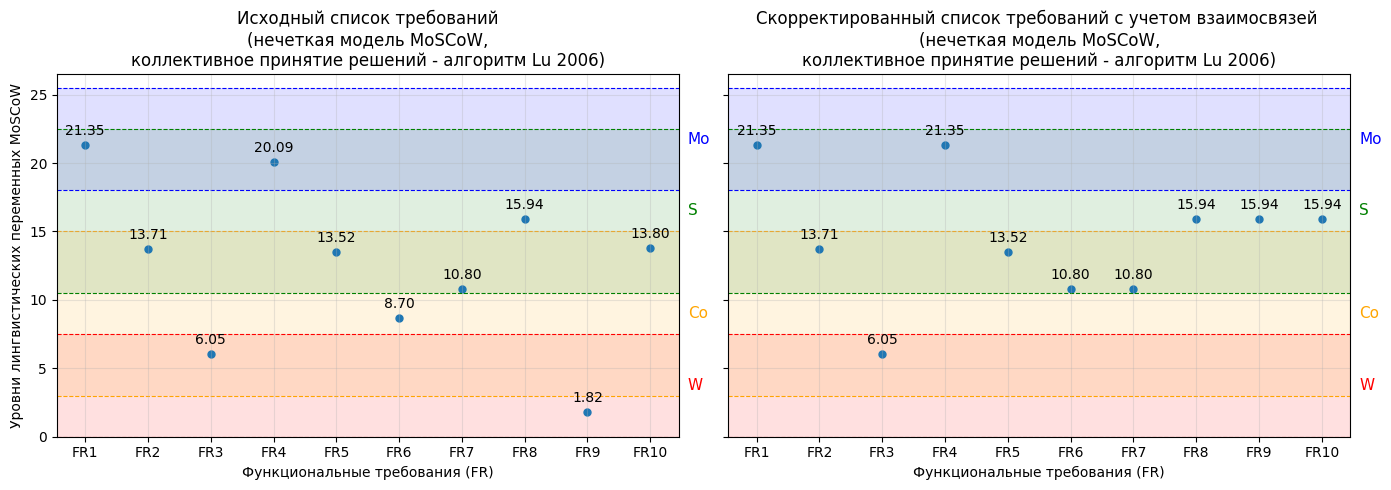

In [223]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразуование результатов в словари: {FR: centroid} и {FR: adjusted_centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}
adjusted_centroid_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}

# Формирование списка FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    [r["fr"] for r in results_alpha],
    key=lambda x: int(x.replace("FR", ""))
)

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 7.5),
    "Co": (3.0, 15.0),
    "S":  (10.5, 22.5),
    "Mo": (18.0, 25.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Lu 2006)",
    "Скорректированный список требований с учетом взаимосвязей \n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Lu 2006)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 26.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Версия с загрузкой данных из файла и выгрузкой итогов в файл Excel**

In [224]:
# Нечеткий метод приоритизации MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Решение принимается группой из произвольного числа экспертов по модели Lu 2006.
# Веса экспертов четкие, изначально ненормализованные, в процессе реализации алгоритма выполняется их нормализация.
# Загрузка данных и выгрузка результатов - из файла / в файл Excel.

from typing import List, Dict, Any, Sequence, Tuple, Optional
import re
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

Trap = Tuple[float, float, float, float]
IT2 = Tuple[Trap, Trap]
Seg = Tuple[float, float, float, float]

# 1. Типы данных и шкалы MoSCoW
EPS = 1e-12

bold_font = Font(bold=True)
center_alignment = Alignment(horizontal="center", vertical="center", wrap_text=False)
left_alignment = Alignment(horizontal="left", vertical="center", wrap_text=False)
thin_border = Border(bottom=Side(style="thin"))

MOSCOW_NFR_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((6.0, 7.5, 8.5, 8.5), (6.5, 7.5, 8.5, 8.5)),
    "S":  ((3.5, 5.0, 6.0, 7.5), (4.0, 5.0, 6.0, 7.0)),
    "Co": ((1.0, 2.5, 3.5, 5.0), (1.5, 2.5, 3.5, 4.5)),
    "W":  ((0.0, 0.0, 1.0, 2.5), (0.0, 0.0, 1.0, 2.0))
}

MOSCOW_FR_REL_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((0.77, 1.0, 1.0, 1.0), (0.8, 1.0, 1.0, 1.0)),
    "S":  ((0.44, 0.55, 0.77, 0.89), (0.47, 0.55, 0.77, 0.86)),
    "Co": ((0.0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0.0, 0.0, 0.0, 0.22), (0.0, 0.0, 0.0, 0.15))
}

# 2. Подготовка входных данных и расчет индивидуальных IT2-оценок
def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Optional[Sequence[str]] = None,
) -> List[Dict[str, Any]]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]

    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[str(x).strip()] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок по числу NFR.")

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[str(x).strip()] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,
            "ratings": list(fr_row),
        })

    return results

def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    m = len(experts[0]["frs"])
    n = len(experts[0]["nfr"])

    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name', '?')} есть строка FR длины != n.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)
        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared

# 3. Вычисление меры сходства и расстояния для трапециевидных чисел
def segments_trap(trap: Trap, L: float, R: float) -> List[Seg]:
    a1, a2, a3, a4 = map(float, trap)
    L, R = float(L), float(R)

    seg: List[Seg] = []

    if L < a1:
        seg.append((L, min(a1, R), 0.0, 0.0))

    if a1 < a2 and max(a1, L) < min(a2, R):
        m = 1.0 / (a2 - a1)
        c = -a1 / (a2 - a1)
        seg.append((max(a1, L), min(a2, R), m, c))

    if max(a2, L) < min(a3, R):
        seg.append((max(a2, L), min(a3, R), 0.0, 1.0))

    if a3 < a4 and max(a3, L) < min(a4, R):
        m = -1.0 / (a4 - a3)
        c = a4 / (a4 - a3)
        seg.append((max(a3, L), min(a4, R), m, c))

    if a4 < R:
        seg.append((max(a4, L), R, 0.0, 0.0))

    merged: List[Seg] = []
    for x0, x1, m, c in seg:
        if x1 <= x0:
            continue
        if (
            merged
            and abs(merged[-1][2] - m) < 1e-12
            and abs(merged[-1][3] - c) < 1e-12
            and abs(merged[-1][1] - x0) < 1e-12
        ):
            merged[-1] = (merged[-1][0], x1, m, c)
        else:
            merged.append((x0, x1, m, c))

    return merged

def mu_from_segments(x: float, segs: List[Seg]) -> float:
    for x0, x1, m, c in segs:
        if x0 <= x <= x1:
            return m * x + c
    return 0.0

def line_at(segs: List[Seg], x: float) -> Tuple[float, float]:
    for x0, x1, m, c in segs:
        if x0 - 1e-12 <= x <= x1 + 1e-12:
            return m, c
    return 0.0, 0.0

def intersections(segsA: List[Seg], segsB: List[Seg]) -> set:
    pts = set()
    for x0a, x1a, ma, ca in segsA:
        for x0b, x1b, mb, cb in segsB:
            lo, hi = max(x0a, x0b), min(x1a, x1b)
            if hi <= lo:
                continue
            if abs(ma - mb) < 1e-12:
                continue
            x = (cb - ca) / (ma - mb)
            if lo - 1e-9 <= x <= hi + 1e-9:
                pts.add(float(x))
    return pts

def build_breakpoints(segsA: List[Seg], segsB: List[Seg]) -> List[float]:
    pts = set()
    for x0, x1, _, _ in segsA:
        pts.add(x0)
        pts.add(x1)
    for x0, x1, _, _ in segsB:
        pts.add(x0)
        pts.add(x1)
    pts |= intersections(segsA, segsB)

    bp = sorted(pts)
    cleaned: List[float] = []
    for x in bp:
        if not cleaned or abs(cleaned[-1] - x) > 1e-9:
            cleaned.append(x)
    return cleaned

def integral_square_linear(m: float, c: float, x0: float, x1: float) -> float:
    return (m * m / 3.0) * (x1**3 - x0**3) + (m * c) * (x1**2 - x0**2) + (c * c) * (x1 - x0)

def integral_linear(m: float, c: float, x0: float, x1: float) -> float:
    return (m / 2.0) * (x1**2 - x0**2) + c * (x1 - x0)

def Sw(trapA: Trap, trapB: Trap) -> float:
    a1, a2, a3, a4 = map(float, trapA)
    b1, b2, b3, b4 = map(float, trapB)

    L, R = min(a1, b1), max(a4, b4)
    segA = segments_trap(trapA, L, R)
    segB = segments_trap(trapB, L, R)
    bp = build_breakpoints(segA, segB)

    Imin = 0.0
    Imax = 0.0

    for x0, x1 in zip(bp[:-1], bp[1:]):
        if x1 <= x0:
            continue

        xm = (x0 + x1) / 2.0
        muA = mu_from_segments(xm, segA)
        muB = mu_from_segments(xm, segB)
        mA, cA = line_at(segA, xm)
        mB, cB = line_at(segB, xm)

        if muA <= muB:
            Imin += integral_square_linear(mA, cA, x0, x1)
            Imax += integral_square_linear(mB, cB, x0, x1)
        else:
            Imin += integral_square_linear(mB, cB, x0, x1)
            Imax += integral_square_linear(mA, cA, x0, x1)

    return 0.0 if Imax <= 0 else Imin / Imax

def d_inf(trapA: Trap, trapB: Trap) -> float:
    a1, _, _, a4 = map(float, trapA)
    b1, _, _, b4 = map(float, trapB)

    if a4 < b1:
        return b1 - a4
    if b4 < a1:
        return a1 - b4
    return 0.0

def dH(trapA: Trap, trapB: Trap) -> float:
    a1, _, _, a4 = map(float, trapA)
    b1, _, _, b4 = map(float, trapB)

    L, R = min(a1, b1), max(a4, b4)
    segA = segments_trap(trapA, L, R)
    segB = segments_trap(trapB, L, R)
    bp = build_breakpoints(segA, segB)

    total = 0.0
    for x0, x1 in zip(bp[:-1], bp[1:]):
        if x1 <= x0:
            continue
        xm = (x0 + x1) / 2.0
        mA, cA = line_at(segA, xm)
        mB, cB = line_at(segB, xm)
        total += abs(integral_linear(mA - mB, cA - cB, x0, x1))

    return total

def D_trap(trapA: Trap, trapB: Trap) -> float:
    return 0.5 * (dH(trapA, trapB) + d_inf(trapA, trapB))

# 4. Построение матриц сходства, расстояния и согласованности
def build_AM_matrices_it2(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str]
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    k = len(prepared_experts)
    AM_u_by_fr: Dict[str, np.ndarray] = {}
    AM_l_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        AMu = np.zeros((k, k), dtype=float)
        AMl = np.zeros((k, k), dtype=float)

        for i in range(k):
            u_i, l_i = prepared_experts[i]["ratings"][fr]
            for j in range(k):
                u_j, l_j = prepared_experts[j]["ratings"][fr]
                AMu[i, j] = Sw(u_i, u_j)
                AMl[i, j] = Sw(l_i, l_j)

        AM_u_by_fr[fr] = AMu
        AM_l_by_fr[fr] = AMl

    return AM_u_by_fr, AM_l_by_fr

def build_dM_matrices_it2(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str]
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    k = len(prepared_experts)
    dM_u_by_fr: Dict[str, np.ndarray] = {}
    dM_l_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        DM_u = np.zeros((k, k), dtype=float)
        DM_l = np.zeros((k, k), dtype=float)

        for i in range(k):
            u_i, l_i = prepared_experts[i]["ratings"][fr]
            for j in range(k):
                u_j, l_j = prepared_experts[j]["ratings"][fr]
                DM_u[i, j] = D_trap(u_i, u_j)
                DM_l[i, j] = D_trap(l_i, l_j)

        D_star_u = float(DM_u.max())
        D_star_l = float(DM_l.max())

        dM_u = np.zeros_like(DM_u) if D_star_u <= EPS else DM_u / D_star_u
        dM_l = np.zeros_like(DM_l) if D_star_l <= EPS else DM_l / D_star_l

        dM_u_by_fr[fr] = dM_u
        dM_l_by_fr[fr] = dM_l

    return dM_u_by_fr, dM_l_by_fr

def build_R_matrices_from_AM_dM(
    AM_by_fr: Dict[str, np.ndarray],
    dM_by_fr: Dict[str, np.ndarray],
    beta: float,
) -> Dict[str, np.ndarray]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0,1].")

    out: Dict[str, np.ndarray] = {}
    for fr, AM in AM_by_fr.items():
        dM = dM_by_fr[fr]
        if AM.shape != dM.shape:
            raise ValueError(f"{fr}: AM и dM должны быть одного размера.")
        out[fr] = beta * AM + (1.0 - beta) * (1.0 - dM)

    return out

def average_R_matrices(
    Ru_by_fr: Dict[str, np.ndarray],
    Rl_by_fr: Dict[str, np.ndarray]
) -> Dict[str, np.ndarray]:
    return {fr: 0.5 * (Ru_by_fr[fr] + Rl_by_fr[fr]) for fr in Ru_by_fr.keys()}

def compute_C_for_all_fr(
    prepared_experts: Sequence[Dict[str, Any]],
    R_avg_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    e = np.asarray([float(ex["w"]) for ex in prepared_experts], dtype=float)
    if float(e.sum()) <= EPS:
        raise ValueError("Сумма весов экспертов должна быть > 0.")

    C_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        R = np.asarray(R_avg_by_fr[fr], dtype=float)
        if R.shape != (len(prepared_experts), len(prepared_experts)):
            raise ValueError(f"{fr}: некорректный размер матрицы R_avg.")
        C_by_fr[fr] = R @ e

    return C_by_fr

def compute_wE_for_all_fr(
    C_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    w_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        C = np.asarray(C_by_fr[fr], dtype=float)
        s = float(C.sum())
        k = C.size
        w_by_fr[fr] = np.full(k, 1.0 / k, dtype=float) if s <= EPS else C / s

    return w_by_fr

# 5. Агрегирование групповых IT2-оценок и дефаззификация
def aggregate_group_it2_for_all_fr(
    prepared_experts: Sequence[Dict[str, Any]],
    wE_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, IT2]:
    k = len(prepared_experts)
    group_by_fr: Dict[str, IT2] = {}

    for fr in fr_names:
        w = np.asarray(wE_by_fr[fr], dtype=float)
        s = float(w.sum())
        w = np.full(k, 1.0 / k, dtype=float) if s <= EPS else (w / s)

        acc: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for i, ex in enumerate(prepared_experts):
            acc = add_intuitionistic_trapezoidal_fuzzy_numbers(
                acc,
                multiply_fuzzy_number_by_constant(ex["ratings"][fr], float(w[i]))
            )

        group_by_fr[fr] = acc

    return group_by_fr

def build_defuzz_rows(
    it2_by_fr: Dict[str, IT2],
    a: float,
    alpha: float
) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []

    for fr, pfr_it2 in it2_by_fr.items():
        pfr_t1 = cltr_type_reduction(pfr_it2, a)
        cut = alpha_cut(pfr_t1, alpha)
        c = centroid(cut)

        (u1, u2, u3, u4), (l1, l2, l3, l4) = pfr_it2
        y1, y2, y3, y4 = pfr_t1
        start_cut, end_cut = cut

        rows.append({
            "fr": fr,
            "pfr_it2": pfr_it2,
            "a": a,
            "pfr_t1": pfr_t1,
            "alpha": alpha,
            "alpha_cut": cut,
            "centroid": c,
            "umf_x1": round(u1, 2),
            "umf_x2": round(u2, 2),
            "umf_x3": round(u3, 2),
            "umf_x4": round(u4, 2),
            "lmf_x1": round(l1, 2),
            "lmf_x2": round(l2, 2),
            "lmf_x3": round(l3, 2),
            "lmf_x4": round(l4, 2),
            "t1_x1": round(y1, 2),
            "t1_x2": round(y2, 2),
            "t1_x3": round(y3, 2),
            "t1_x4": round(y4, 2),
            "alpha_start": round(start_cut, 2),
            "alpha_end": round(end_cut, 2),
        })

    return sorted(rows, key=lambda x: x["centroid"], reverse=True)

# 6. Корректировка приоритизации с учетом взаимосвязанности FR
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

# 7. Загрузка данных из Excel
_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)

def load_expert_sheet(ws) -> Dict[str, Any]:
    sheet_name = str(ws.title).strip()

    nfr_header_row = None
    nfr_names: List[str] = []
    nfr_cols: List[int] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 1:
            start = min(cols)
            current_names = []
            current_cols = []
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    current_names.append(v.strip())
                    current_cols.append(c)
                else:
                    if current_names:
                        break
            if current_names:
                nfr_header_row = r
                nfr_names = current_names
                nfr_cols = current_cols
                break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{sheet_name}'.")

    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{sheet_name}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(str(v).strip())

    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR на листе '{sheet_name}'.")

    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break

        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row: List[str] = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else str(v).strip())

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {
        "name": sheet_name,
        "nfr": nfr_priorities,
        "fr_names": fr_names,
        "frs": fr_matrix
    }

# 8. Форматирование и запись данных в Excel
def apply_base_style(ws):
    for row in ws.iter_rows():
        for cell in row:
            if cell.value is not None:
                if cell.alignment is None or cell.alignment.horizontal is None:
                    cell.alignment = center_alignment

            if isinstance(cell.value, (int, float)) and not isinstance(cell.value, bool):
                if ws.title == "Матрица взаимосвязей":
                    cell.number_format = "0"
                elif ws.title in {"Нечеткий MoSCoW_расчеты", "Нечеткий MoSCoW_итоги"} and cell.column == 1:
                    cell.number_format = "0"
                else:
                    cell.number_format = "0.00"

def auto_fit(ws, extra_pad: int = 2):
    max_col = ws.max_column
    max_row = ws.max_row

    for col_idx in range(1, max_col + 1):
        max_len = 0
        for row_idx in range(1, max_row + 1):
            value = ws.cell(row_idx, col_idx).value
            if value is None:
                continue
            text = str(value)
            if len(text) > max_len:
                max_len = len(text)

        calculated_width = min(max(max_len + extra_pad, 10), 22)
        col_letter = get_column_letter(col_idx)
        current_width = ws.column_dimensions[col_letter].width

        if current_width is None or current_width < calculated_width:
            ws.column_dimensions[col_letter].width = calculated_width

    for row_idx in range(1, max_row + 1):
        current_height = ws.row_dimensions[row_idx].height
        max_len = 0

        for col_idx in range(1, max_col + 1):
            value = ws.cell(row_idx, col_idx).value
            if value is None:
                continue
            text = str(value)
            if len(text) > max_len:
                max_len = len(text)

        calculated_height = 18 if max_len <= 35 else 24

        if current_height is None or current_height < calculated_height:
            ws.row_dimensions[row_idx].height = calculated_height


def write_section_title(ws, row: int, text: str, end_col: int) -> int:
    ws.cell(row, 1).value = text
    ws.cell(row, 1).font = bold_font
    ws.cell(row, 1).alignment = left_alignment
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=end_col)

    for col in range(1, end_col + 1):
        ws.cell(row, col).alignment = left_alignment

    return row + 1

def write_sheet_title(ws, row: int, text: str, end_col: int) -> int:
    ws.cell(row, 1).value = text
    ws.cell(row, 1).font = bold_font
    ws.cell(row, 1).alignment = left_alignment
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=end_col)

    for col in range(1, end_col + 1):
        ws.cell(row, col).alignment = left_alignment

    return row + 2

def write_weights_block(ws, start_row: int, expert_names: List[str], r_raw: List[float], w_norm: List[float]) -> int:
    r = write_section_title(ws, start_row, "1) Веса экспертов", 3)

    headers = ["Эксперт", "Вес_raw (r)", "Вес_norm (w)"]
    for c, h in enumerate(headers, start=1):
        ws.cell(r, c).value = h
        ws.cell(r, c).font = bold_font

    for i, (name, rr, ww) in enumerate(zip(expert_names, r_raw, w_norm), start=1):
        ws.cell(r + i, 1).value = name
        ws.cell(r + i, 2).value = float(rr)
        ws.cell(r + i, 3).value = float(ww)

    sum_row = r + len(expert_names) + 1
    ws.cell(sum_row, 1).value = "SUM"
    ws.cell(sum_row, 2).value = round(sum(r_raw), 2)
    ws.cell(sum_row, 3).value = round(sum(w_norm), 2)

    for c in range(1, 4):
        ws.cell(sum_row, c).font = bold_font

    return sum_row + 2

def write_params_block(ws, start_row: int, alpha: float, beta: float, a_cltr: float) -> int:
    r = write_section_title(ws, start_row, "2) Параметры модели", 3)

    rows = [
        ("alpha (уровень альфа-среза)", alpha),
        ("Параметр beta", beta),
        ("a (редукция типа CLTR)", a_cltr),
    ]

    for i, (label, value) in enumerate(rows):
        ws.cell(r + i, 1).value = label
        ws.cell(r + i, 2).value = float(value)
        ws.cell(r + i, 1).alignment = left_alignment

    return r + len(rows) + 2

def write_result_table(
    ws,
    start_row: int,
    title: str,
    rows_sorted: List[Dict[str, Any]],
    include_adjusted: bool = False
) -> int:
    end_col = 18 if include_adjusted else 17
    r = write_section_title(ws, start_row, title, end_col)

    ws.cell(r, 1).value = "Место"
    ws.cell(r, 2).value = "FR"
    ws.cell(r, 3).value = "Итоговый приоритет функционального требования в виде ИНМТ2"
    ws.cell(r, 11).value = "Редуцированный приоритет FR в виде ИНМТ1"
    ws.cell(r, 15).value = "Дефаззификация (альфа-срез)"
    ws.cell(r, 17).value = "Центроид"
    if include_adjusted:
        ws.cell(r, 18).value = "Скорректированный\nцентроид"

    ws.merge_cells(start_row=r, start_column=1, end_row=r + 1, end_column=1)
    ws.merge_cells(start_row=r, start_column=2, end_row=r + 1, end_column=2)
    ws.merge_cells(start_row=r, start_column=3, end_row=r, end_column=10)
    ws.merge_cells(start_row=r, start_column=11, end_row=r, end_column=14)
    ws.merge_cells(start_row=r, start_column=15, end_row=r, end_column=16)
    ws.merge_cells(start_row=r, start_column=17, end_row=r + 1, end_column=17)
    if include_adjusted:
        ws.merge_cells(start_row=r, start_column=18, end_row=r + 1, end_column=18)

    for c in [1, 2, 3, 11, 15, 17]:
        ws.cell(r, c).font = bold_font
        ws.cell(r, c).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    if include_adjusted:
        ws.cell(r, 18).font = bold_font
        ws.cell(r, 18).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    second_headers = [
        "UMF_x1", "UMF_x2", "UMF_x3", "UMF_x4",
        "LMF_x1", "LMF_x2", "LMF_x3", "LMF_x4",
        "T1_x1", "T1_x2", "T1_x3", "T1_x4",
        "alpha_start", "alpha_end"
    ]

    for idx, header in enumerate(second_headers, start=3):
        ws.cell(r + 1, idx).value = header
        ws.cell(r + 1, idx).font = bold_font
        ws.cell(r + 1, idx).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.row_dimensions[r].height = 30
    ws.row_dimensions[r + 1].height = 22

    if ws.column_dimensions["K"].width is None or ws.column_dimensions["K"].width < 9:
        ws.column_dimensions["K"].width = 9
    if ws.column_dimensions["O"].width is None or ws.column_dimensions["O"].width < 14:
        ws.column_dimensions["O"].width = 14
    if ws.column_dimensions["P"].width is None or ws.column_dimensions["P"].width < 14:
        ws.column_dimensions["P"].width = 14
    if include_adjusted:
        if ws.column_dimensions["R"].width is None or ws.column_dimensions["R"].width < 18:
            ws.column_dimensions["R"].width = 18

    data_row = r + 2
    for idx, item in enumerate(rows_sorted, start=1):
        ws.cell(data_row, 1).value = idx
        ws.cell(data_row, 2).value = item["fr"]

        ws.cell(data_row, 3).value = float(item["umf_x1"])
        ws.cell(data_row, 4).value = float(item["umf_x2"])
        ws.cell(data_row, 5).value = float(item["umf_x3"])
        ws.cell(data_row, 6).value = float(item["umf_x4"])

        ws.cell(data_row, 7).value = float(item["lmf_x1"])
        ws.cell(data_row, 8).value = float(item["lmf_x2"])
        ws.cell(data_row, 9).value = float(item["lmf_x3"])
        ws.cell(data_row, 10).value = float(item["lmf_x4"])

        ws.cell(data_row, 11).value = float(item["t1_x1"])
        ws.cell(data_row, 12).value = float(item["t1_x2"])
        ws.cell(data_row, 13).value = float(item["t1_x3"])
        ws.cell(data_row, 14).value = float(item["t1_x4"])

        ws.cell(data_row, 15).value = float(item["alpha_start"])
        ws.cell(data_row, 16).value = float(item["alpha_end"])
        ws.cell(data_row, 17).value = float(item["centroid"])

        if include_adjusted:
            ws.cell(data_row, 18).value = float(item["adjusted_centroid"])

        data_row += 1

    return data_row + 1

def write_dual_matrices_block(
    ws,
    start_row: int,
    title: str,
    left_title: str,
    right_title: str,
    fr_list: Sequence[str],
    left_mats: Dict[str, np.ndarray],
    right_mats: Dict[str, np.ndarray],
    expert_names: Sequence[str],
) -> int:
    k = len(expert_names)

    r = write_section_title(ws, start_row, title, 2 * k + 5)

    left_block_start = 1
    right_block_start = k + 4

    ws.cell(r, left_block_start).value = f"{left_title}"
    ws.cell(r, left_block_start).font = bold_font
    ws.cell(r, left_block_start).alignment = left_alignment
    ws.merge_cells(start_row=r, start_column=left_block_start, end_row=r, end_column=left_block_start + k)

    ws.cell(r, right_block_start).value = f"{right_title}"
    ws.cell(r, right_block_start).font = bold_font
    ws.cell(r, right_block_start).alignment = left_alignment
    ws.merge_cells(start_row=r, start_column=right_block_start, end_row=r, end_column=right_block_start + k)

    r += 2

    for fr in fr_list:
        ws.cell(r, left_block_start).value = fr
        ws.cell(r, left_block_start).font = bold_font
        ws.cell(r, left_block_start).alignment = left_alignment

        ws.cell(r, right_block_start).value = fr
        ws.cell(r, right_block_start).font = bold_font
        ws.cell(r, right_block_start).alignment = left_alignment

        r += 1

        for j, name in enumerate(expert_names, start=1):
            ws.cell(r, left_block_start + j).value = name
            ws.cell(r, left_block_start + j).font = bold_font

            ws.cell(r, right_block_start + j).value = name
            ws.cell(r, right_block_start + j).font = bold_font

        r += 1

        M1 = np.asarray(left_mats[fr], dtype=float)
        M2 = np.asarray(right_mats[fr], dtype=float)

        for i, name in enumerate(expert_names):
            ws.cell(r + i, left_block_start).value = name
            ws.cell(r + i, left_block_start).alignment = left_alignment

            ws.cell(r + i, right_block_start).value = name
            ws.cell(r + i, right_block_start).alignment = left_alignment

            for j in range(k):
                ws.cell(r + i, left_block_start + 1 + j).value = float(M1[i, j])
                ws.cell(r + i, right_block_start + 1 + j).value = float(M2[i, j])

        r += k + 2

    return r

def write_single_matrices_block(
    ws,
    start_row: int,
    title: str,
    fr_list: Sequence[str],
    mats: Dict[str, np.ndarray],
    expert_names: Sequence[str],
) -> int:
    k = len(expert_names)
    r = write_section_title(ws, start_row, title, k + 2)

    for fr in fr_list:
        ws.cell(r, 1).value = fr
        ws.cell(r, 1).font = bold_font
        ws.cell(r, 1).alignment = left_alignment
        r += 1

        ws.cell(r, 1).font = bold_font
        for j, name in enumerate(expert_names, start=1):
            ws.cell(r, 1 + j).value = name
            ws.cell(r, 1 + j).font = bold_font
        r += 1

        M = np.asarray(mats[fr], dtype=float)
        for i, name in enumerate(expert_names):
            ws.cell(r + i, 1).value = name
            ws.cell(r + i, 1).alignment = left_alignment
            for j in range(k):
                ws.cell(r + i, 2 + j).value = float(M[i, j])

        r += k + 2

    return r

def write_vectors_block(
    ws,
    start_row: int,
    title: str,
    fr_list: Sequence[str],
    vectors: Dict[str, np.ndarray],
    expert_names: Sequence[str],
) -> int:
    r = write_section_title(ws, start_row, title, len(expert_names) + 1)

    ws.cell(r, 1).value = "FR"
    ws.cell(r, 1).font = bold_font
    for i, name in enumerate(expert_names, start=1):
        ws.cell(r, 1 + i).value = name
        ws.cell(r, 1 + i).font = bold_font
    r += 1

    for fr in fr_list:
        ws.cell(r, 1).value = fr
        vec = np.asarray(vectors[fr], dtype=float).reshape(-1)
        for j, value in enumerate(vec, start=1):
            ws.cell(r, 1 + j).value = float(value)
        r += 1

    return r + 2

def write_relation_matrix_sheet(
    ws,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]]
):
    r = 1
    r = write_sheet_title(ws, r, "Матрица взаимосвязанности функциональных требований", len(fr_names) + 1)

    ws.cell(r, 1).value = "FR"
    ws.cell(r, 1).font = bold_font
    ws.cell(r, 1).alignment = center_alignment

    for j, fr_name in enumerate(fr_names, start=2):
        ws.cell(r, j).value = fr_name
        ws.cell(r, j).font = bold_font
        ws.cell(r, j).alignment = center_alignment

    r += 1

    for i, fr_name in enumerate(fr_names):
        ws.cell(r + i, 1).value = fr_name
        ws.cell(r + i, 1).font = bold_font
        ws.cell(r + i, 1).alignment = center_alignment

        for j, value in enumerate(relation_matrix[i], start=2):
            ws.cell(r + i, j).value = int(value)
            ws.cell(r + i, j).alignment = center_alignment

    apply_base_style(ws)
    auto_fit(ws)

    ws.column_dimensions["A"].width = 14

    return ws

def write_adjusted_results_table(ws, start_row: int, adjusted_rows_sorted: List[Dict[str, Any]]) -> int:
    r = write_section_title(ws, start_row, "2) Итоговая приоритизация после учета взаимосвязанности", 4)

    headers = ["Место", "FR", "Исходный центроид", "Скорректированный\nцентроид"]
    for c, h in enumerate(headers, start=1):
        ws.cell(r, c).value = h
        ws.cell(r, c).font = bold_font
        ws.cell(r, c).alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    ws.row_dimensions[r].height = 32

    ws.column_dimensions["A"].width = 10
    ws.column_dimensions["B"].width = 10
    ws.column_dimensions["C"].width = 22
    ws.column_dimensions["D"].width = 24

    r += 1

    for idx, item in enumerate(adjusted_rows_sorted, start=1):
        ws.cell(r, 1).value = idx
        ws.cell(r, 2).value = item["fr"]
        ws.cell(r, 3).value = float(item["centroid"])
        ws.cell(r, 4).value = float(item["adjusted_centroid"])
        r += 1

    return r + 1

# 9. Основной расчет и формирование выходного Excel-файла
def run_all_fuzzy_moscow_lu_2006(
    input_xlsx: str,
    output_xlsx: str,
    weights_raw: Sequence[float],
    alpha: float,
    beta: float,
    a_cltr: float,
    relation_matrix: Sequence[Sequence[int]],
) -> str:
    if not (0.0 <= alpha <= 1.0):
        raise ValueError("alpha должен быть в диапазоне [0,1].")
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0,1].")
    if not (0.0 <= a_cltr <= 1.0):
        raise ValueError("a_cltr должен быть в диапазоне [0,1].")

    wb = load_workbook(input_xlsx)

    expert_sheet_names = [
        name for name in wb.sheetnames
        if name not in {"Матрица взаимосвязей", "Нечеткий MoSCoW_расчеты", "Нечеткий MoSCoW_итоги"}
    ]

    experts = [load_expert_sheet(wb[name]) for name in expert_sheet_names]
    if len(experts) == 0:
        raise ValueError("Во входном файле не найдены листы экспертов.")

    if len(weights_raw) != len(experts):
        raise ValueError("Количество весов экспертов должно совпадать с количеством листов экспертов.")

    fr_list = experts[0]["fr_names"]
    for ex in experts[1:]:
        if ex["fr_names"] != fr_list:
            raise ValueError("Списки FR на листах экспертов должны совпадать.")

    prepared = prepare_moscow_it2_inputs(
        experts=experts,
        expert_weights_raw=weights_raw,
        fr_names=fr_list,
        normalize_weights=True,
    )

    expert_names = [e["name"] for e in prepared]
    w_norm = [e["w"] for e in prepared]

    AMu_by_fr, AMl_by_fr = build_AM_matrices_it2(prepared, fr_list)
    dMu_by_fr, dMl_by_fr = build_dM_matrices_it2(prepared, fr_list)

    Ru_by_fr = build_R_matrices_from_AM_dM(AMu_by_fr, dMu_by_fr, beta)
    Rl_by_fr = build_R_matrices_from_AM_dM(AMl_by_fr, dMl_by_fr, beta)
    Ravg_by_fr = average_R_matrices(Ru_by_fr, Rl_by_fr)

    C_by_fr = compute_C_for_all_fr(prepared, Ravg_by_fr, fr_list)
    wE_by_fr = compute_wE_for_all_fr(C_by_fr, fr_list)
    group_by_fr = aggregate_group_it2_for_all_fr(prepared, wE_by_fr, fr_list)

    expert_rows_map: Dict[str, List[Dict[str, Any]]] = {}
    for e in prepared:
        expert_rows_map[e["name"]] = build_defuzz_rows(e["ratings"], a=a_cltr, alpha=alpha)

    adjusted_expert_rows_map: Dict[str, List[Dict[str, Any]]] = {}
    for e in prepared:
        adjusted_expert_rows_map[e["name"]] = adjust_fuzzy_ranked_by_interdependencies(
            expert_rows_map[e["name"]],
            relation_matrix
        )

    group_rows_sorted = build_defuzz_rows(group_by_fr, a=a_cltr, alpha=alpha)
    adjusted_rows_sorted = adjust_fuzzy_ranked_by_interdependencies(group_rows_sorted, relation_matrix)

    for sheet_name in ["Матрица взаимосвязей", "Нечеткий MoSCoW_расчеты", "Нечеткий MoSCoW_итоги"]:
        if sheet_name in wb.sheetnames:
            del wb[sheet_name]

    insert_pos = len(expert_sheet_names)
    ws_rel = wb.create_sheet("Матрица взаимосвязей", insert_pos)
    ws_calc = wb.create_sheet("Нечеткий MoSCoW_расчеты", insert_pos + 1)
    ws_final = wb.create_sheet("Нечеткий MoSCoW_итоги", insert_pos + 2)

    write_relation_matrix_sheet(ws_rel, fr_list, relation_matrix)

    r = 1
    r = write_sheet_title(ws_calc, r, "Нечеткий MoSCoW - расчеты (коллективная оценка, Lu 2006)", 18)
    r = write_weights_block(ws_calc, r, expert_names, list(weights_raw), w_norm)
    r = write_params_block(ws_calc, r, alpha=alpha, beta=beta, a_cltr=a_cltr)

    for e in prepared:
        r = write_result_table(
            ws_calc,
            r,
            title=f"Эксперт: {e['name']}",
            rows_sorted=adjusted_expert_rows_map[e["name"]],
            include_adjusted=True
        )

    r = write_dual_matrices_block(
        ws_calc,
        r,
        "3) Матрицы сходства AM",
        "AM_UMF",
        "AM_LMF",
        fr_list,
        AMu_by_fr,
        AMl_by_fr,
        expert_names,
    )

    r = write_dual_matrices_block(
        ws_calc,
        r,
        "4) Нормированные матрицы расстояний dM",
        "dM_UMF",
        "dM_LMF",
        fr_list,
        dMu_by_fr,
        dMl_by_fr,
        expert_names,
    )

    r = write_dual_matrices_block(
        ws_calc,
        r,
        "5) Матрицы согласованности R",
        "R_UMF",
        "R_LMF",
        fr_list,
        Ru_by_fr,
        Rl_by_fr,
        expert_names,
    )

    r = write_single_matrices_block(
        ws_calc,
        r,
        "6) Усредненные матрицы согласованности R_avg",
        fr_list,
        Ravg_by_fr,
        expert_names,
    )

    r = write_vectors_block(
        ws_calc,
        r,
        "7) Взвешенная степень согласованности эксперта C(Ei)",
        fr_list,
        C_by_fr,
        expert_names,
    )

    r = write_vectors_block(
        ws_calc,
        r,
        "8) Веса агрегирования экспертов w(Ei)",
        fr_list,
        wE_by_fr,
        expert_names,
    )

    rf = 1
    rf = write_sheet_title(ws_final, rf, "Нечеткий MoSCoW - итоги (коллективная оценка, Lu 2006)", 18)
    rf = write_result_table(
        ws_final,
        rf,
        title="1) Итоговые нечеткие приоритеты и результаты дефаззификации",
        rows_sorted=group_rows_sorted,
        include_adjusted=False
    )
    rf = write_adjusted_results_table(ws_final, rf, adjusted_rows_sorted)

    for ws in [ws_rel, ws_calc, ws_final]:
        apply_base_style(ws)
        auto_fit(ws)

    ws_rel.column_dimensions["A"].width = 14

    ws_calc.column_dimensions["A"].width = 28
    ws_calc.column_dimensions["K"].width = 14
    ws_calc.column_dimensions["O"].width = 14
    ws_calc.column_dimensions["P"].width = 14
    ws_calc.column_dimensions["R"].width = 22

    ws_final.column_dimensions["A"].width = 10
    ws_final.column_dimensions["K"].width = 14
    ws_final.column_dimensions["O"].width = 14
    ws_final.column_dimensions["P"].width = 14

    wb.save(output_xlsx)
    return output_xlsx

In [225]:
# Запуск

INPUT_XLSX = r"Загрузочные данные_MoSCoW_коллектив.xlsx"
OUTPUT_XLSX = r"Итоги_Fuzzy MoSCoW_Lu 2006.xlsx"

WEIGHTS_RAW = [0.75, 0.75, 1.0]

ALPHA = 0.8
BETA = 0.4
A_CLTR = 0.6

RELATION_MATRIX = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
]

out = run_all_fuzzy_moscow_lu_2006(
    input_xlsx=INPUT_XLSX,
    output_xlsx=OUTPUT_XLSX,
    weights_raw=WEIGHTS_RAW,
    alpha=ALPHA,
    beta=BETA,
    a_cltr=A_CLTR,
    relation_matrix=RELATION_MATRIX,
)

print("Файл сохранен:", out)

Файл сохранен: Итоги_Fuzzy MoSCoW_Lu 2006.xlsx


# 2.4.2. Четкий MoSCoW + Аналог алгоритма Lu 2006 (КПР) для сравнения с нечетким алгоритмом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://link.springer.com/article/10.1007/s11424-006-0063-y

Lu, C., Lan, J., Wang, Z. Aggregation of fuzzy opinions under group decision-making based on similarity and distance //Journal of Systems Science and Complexity. 2006, 19(1)

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [226]:
# Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке
from typing import Sequence, Any, Dict, Tuple, Optional, List

# Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, float] = {"Mo": 8.0, "S": 5.5, "Co": 3.0, "W": 0.5}
MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS)  # {"Mo","S","Co","W"}


def normalize_expert_weights(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    normalize: bool = True,
) -> Tuple[List[str], List[float], Dict[str, float], Dict[str, float]]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_norm_by_name = dict(zip(expert_names, w_norm))
    w_raw_by_name = dict(zip(expert_names, w_raw))
    return expert_names, w_norm, w_norm_by_name, w_raw_by_name


def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # NFR -  веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    # FR_NFR -  PFR
    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")

        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores


def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:

    # базовые проверки по структуре FR
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR (поле 'frs').")
    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    # FR names
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    else:
        fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # веса экспертов
    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    # оценки каждого эксперта: {expert - оценка {fr - в pfr}}
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,   # список в том же порядке, что expert_names
        "expert_scores": expert_scores,     # ключевой результат шага
    }


In [227]:
# Пример использования (3 эксперта)
S1 = {
    "name": "S1",
    "nfr": ["Mo", "Mo", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "S", "Mo"],
        ["S",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["S",  "Co", "S"],
        ["Co", "Co",  "Co"],
        ["S", "S",  "W"],
        ["S",  "S", "S"],
        ["W",  "W", "W"],
        ["Co", "Co", "Mo"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "S", "Mo"],
    "frs": [
        ["Mo", "Mo",  "Mo"],
        ["W", "Mo", "Mo"],
        ["S",  "Co",  "W"],
        ["Mo", "Mo",  "Mo"],
        ["S",  "S", "S"],
        ["Co", "S",  "Co"],
        ["S", "Mo",  "W"],
        ["S",  "Mo", "S"],
        ["W",  "Co", "W"],
        ["Co", "S", "Mo"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["S", "Mo", "Mo"],
    "frs": [
       ["Mo", "Mo",  "Mo"],
        ["Co", "S", "Mo"],
        ["Mo",  "W",  "W"],
        ["Mo", "S",  "Mo"],
        ["Mo",  "Co", "S"],
        ["S", "Co",  "Co"],
        ["Mo", "S",  "W"],
        ["Mo",  "S", "S"],
        ["Co",  "W", "W"],
        ["S", "Co", "Mo"],
    ]
}

experts = [S1, S2, S3]
weights = [0.75, 0.75, 1]  # ненормализованные

prepared = prepare_crisp_moscow_inputs(experts, weights)

print("Normalized weights:", {k: round(v, 2) for k, v in prepared["weights_norm"].items()})
print()

# Печать
fr_names = prepared["fr_names"]
expert_names = prepared["expert_names"]
expert_scores = prepared["expert_scores"]

for fr in fr_names:
    row = {expert: round(expert_scores[expert][fr], 2) for expert in expert_names}
    print(f"{fr}: {row}")


Normalized weights: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

FR1: {'S1': 24.0, 'S2': 21.5, 'S3': 21.5}
FR2: {'S1': 13.28, 'S2': 13.5, 'S3': 15.1}
FR3: {'S1': 5.28, 'S2': 7.1, 'S3': 5.5}
FR4: {'S1': 21.28, 'S2': 21.5, 'S3': 18.78}
FR5: {'S1': 13.2, 'S2': 14.19, 'S3': 13.42}
FR6: {'S1': 7.92, 'S2': 8.91, 'S3': 8.91}
FR7: {'S1': 10.56, 'S2': 10.78, 'S3': 10.78}
FR8: {'S1': 15.84, 'S2': 16.06, 'S3': 16.06}
FR9: {'S1': 0.0, 'S2': 1.82, 'S3': 1.82}
FR10: {'S1': 13.28, 'S2': 14.27, 'S3': 14.27}


In [228]:
# Расчет матриц сходства AM, нормированного расстояния dM и агрегированной меры согласованности AMr
import numpy as np

EPS = 1e-12

def build_crisp_matrices_by_fr(
    fr_names: Sequence[str],
    expert_names: Sequence[str],
    expert_scores: Dict[str, Dict[str, float]],
    beta: float,
) -> Tuple[
    Dict[str, np.ndarray],  # dM_by_fr
    Dict[str, np.ndarray],  # AM_by_fr
    Dict[str, np.ndarray],  # AMr_by_fr
]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1].")

    k = len(expert_names)
    if k == 0:
        raise ValueError("expert_names не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    # Проверки наличия оценок
    for ex in expert_names:
        if ex not in expert_scores:
            raise ValueError(f"Нет expert_scores для эксперта '{ex}'.")
        for fr in fr_names:
            if fr not in expert_scores[ex]:
                raise ValueError(f"У эксперта '{ex}' нет оценки для '{fr}'.")

    dM_by_fr: Dict[str, np.ndarray] = {}
    AM_by_fr: Dict[str, np.ndarray]  = {}
    AMr_by_fr: Dict[str, np.ndarray]  = {}

    for fr in fr_names:
        x = np.array([float(expert_scores[ex][fr]) for ex in expert_names], dtype=float)  # (k,)

        # попарные модули разностей (xi-xj)
        diff = np.abs(x[:, None] - x[None, :])  # (k,k)
        D_star = float(diff.max())

        if D_star <= EPS:
            dM = np.zeros((k, k), dtype=float)
        else:
            dM = diff / D_star

        S = (1.0 - dM) ** 2
        R = beta * S + (1.0 - beta) * (1.0 - dM)

        dM_by_fr[fr] = dM
        AM_by_fr[fr]  = S
        AMr_by_fr[fr]  = R

    return dM_by_fr, AM_by_fr, AMr_by_fr

def print_matrix_list(M: np.ndarray, name: str, decimals: int = 2) -> None:
    M = np.asarray(M, dtype=float)
    fmt = f"{{:.{decimals}f}}"
    print(f"{name}:")
    for row in M:
        row_str = ", ".join(fmt.format(x) for x in row)
        print(f"[{row_str}]")

In [229]:
# Запуск
beta = 0.4

dM_by_fr, AM_by_fr, AMr_by_fr = build_crisp_matrices_by_fr(
    fr_names=fr_names,
    expert_names=expert_names,
    expert_scores=expert_scores,
    beta=beta
)

print("Нормированные матрицы расстояний dM")
for fr in fr_names:
    print()
    print_matrix_list(dM_by_fr[fr], f"{fr}", decimals=2)

print("\nМатрицы сходства AM")
for fr in fr_names:
    print()
    print_matrix_list(AM_by_fr[fr], f"{fr}", decimals=2)

print(f"\nМатрицы агрегированной меры согласованности AMr")
for fr in fr_names:
    print()
    print_matrix_list(AMr_by_fr[fr], f"{fr}", decimals=2)

Нормированные матрицы расстояний dM

FR1:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR2:
[0.00, 0.12, 1.00]
[0.12, 0.00, 0.88]
[1.00, 0.88, 0.00]

FR3:
[0.00, 1.00, 0.12]
[1.00, 0.00, 0.88]
[0.12, 0.88, 0.00]

FR4:
[0.00, 0.08, 0.92]
[0.08, 0.00, 1.00]
[0.92, 1.00, 0.00]

FR5:
[0.00, 1.00, 0.22]
[1.00, 0.00, 0.78]
[0.22, 0.78, 0.00]

FR6:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR7:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR8:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR9:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

FR10:
[0.00, 1.00, 1.00]
[1.00, 0.00, 0.00]
[1.00, 0.00, 0.00]

Матрицы сходства AM

FR1:
[1.00, 0.00, 0.00]
[0.00, 1.00, 1.00]
[0.00, 1.00, 1.00]

FR2:
[1.00, 0.77, 0.00]
[0.77, 1.00, 0.01]
[0.00, 0.01, 1.00]

FR3:
[1.00, 0.00, 0.77]
[0.00, 1.00, 0.01]
[0.77, 0.01, 1.00]

FR4:
[1.00, 0.84, 0.01]
[0.84, 1.00, 0.00]
[0.01, 0.00, 1.00]

FR5:
[1.00, 0.00, 0.60]
[0.00, 1.00, 0.05]
[0.60, 0.05, 1.0

In [230]:
# Вычисление взвешенных степеней согласованности экспертов С(Ei)

def build_crisp_matrices_by_fr(
    fr_names: Sequence[str],
    expert_names: Sequence[str],
    expert_scores: Dict[str, Dict[str, float]],
    beta: float,
) -> Tuple[
    Dict[str, np.ndarray],  # dM_by_fr
    Dict[str, np.ndarray],  # AM_by_fr  (S)
    Dict[str, np.ndarray],  # AMr_by_fr (R)
]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1].")

    k = len(expert_names)
    if k == 0:
        raise ValueError("expert_names не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    for ex in expert_names:
        if ex not in expert_scores:
            raise ValueError(f"Нет expert_scores для эксперта '{ex}'.")
        for fr in fr_names:
            if fr not in expert_scores[ex]:
                raise ValueError(f"У эксперта '{ex}' нет оценки для '{fr}'.")

    dM_by_fr: Dict[str, np.ndarray] = {}
    AM_by_fr: Dict[str, np.ndarray] = {}
    AMr_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        x = np.array([float(expert_scores[ex][fr]) for ex in expert_names], dtype=float)  # (k,)
        diff = np.abs(x[:, None] - x[None, :])  # (k,k)
        D_star = float(diff.max())

        if D_star <= EPS:
            dM = np.zeros((k, k), dtype=float)
        else:
            dM = diff / D_star

        S = (1.0 - dM) ** 2
        R = beta * S + (1.0 - beta) * (1.0 - dM)

        dM_by_fr[fr] = dM
        AM_by_fr[fr] = S
        AMr_by_fr[fr] = R

    return dM_by_fr, AM_by_fr, AMr_by_fr

def compute_C_for_all_fr_crisp(
    expert_names: Sequence[str],
    weights_norm: Dict[str, float],          # prepared["weights_norm"]
    AMr_by_fr: Dict[str, np.ndarray],        # матрицы согласованности по FR
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    k = len(expert_names)
    if k == 0:
        raise ValueError("expert_names не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    # e - нормированные веса в нужном порядке
    e = np.asarray([float(weights_norm[name]) for name in expert_names], dtype=float)

    if np.any(e < 0):
        raise ValueError("weights_norm должны быть >= 0.")
    s = float(e.sum())
    if s <= EPS:
        raise ValueError("Сумма weights_norm должна быть > 0.")
    # пересчет, если веса ненормализованные
    e = e / s

    C_by_fr: Dict[str, np.ndarray] = {}
    for fr in fr_names:
        if fr not in AMr_by_fr:
            raise ValueError(f"{fr}: нет матрицы AMr в AMr_by_fr.")
        R = np.asarray(AMr_by_fr[fr], dtype=float)
        if R.shape != (k, k):
            raise ValueError(f"{fr}: AMr должен быть размера ({k},{k}), сейчас {R.shape}.")
        C_by_fr[fr] = R @ e

    return C_by_fr

def print_C_by_fr(C_by_fr: Dict[str, np.ndarray], fr_list: Sequence[str], round_to: int = 3) -> None:
    fmt = f"{{:.{round_to}f}}"
    for fr in fr_list:
        C = np.asarray(C_by_fr[fr], dtype=float).tolist()
        row = ", ".join(fmt.format(x) for x in C)
        print(f"{fr}: [{row}]")


In [231]:
# Запуск
beta = 0.4

dM_by_fr, AM_by_fr, AMr_by_fr = build_crisp_matrices_by_fr(
    fr_names=fr_names,
    expert_names=expert_names,
    expert_scores=expert_scores,
    beta=beta
)

# C(Ei) с использованием уже нормализованных весов экспертов
C_by_fr = compute_C_for_all_fr_crisp(
    expert_names=expert_names,
    weights_norm=prepared["weights_norm"],   # используем готовые нормализованные веса
    AMr_by_fr=AMr_by_fr,
    fr_names=fr_names
)

print("Взвешенные степени согласованности C(Ei)")
print_C_by_fr(C_by_fr, fr_list=fr_names, round_to=2)


Взвешенные степени согласованности C(Ei)
FR1: [0.30, 0.70, 0.70]
FR2: [0.55, 0.58, 0.42]
FR3: [0.63, 0.33, 0.67]
FR4: [0.59, 0.57, 0.42]
FR5: [0.58, 0.36, 0.66]
FR6: [0.30, 0.70, 0.70]
FR7: [0.30, 0.70, 0.70]
FR8: [0.30, 0.70, 0.70]
FR9: [0.30, 0.70, 0.70]
FR10: [0.30, 0.70, 0.70]


In [232]:
# Вычисление весов агрегирования экспертов w(Ei)

def compute_wE_for_all_fr_crisp(
    C_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    wE_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        if fr not in C_by_fr:
            raise ValueError(f"{fr}: отсутствует в C_by_fr.")

        C = np.asarray(C_by_fr[fr], dtype=float)
        if C.ndim != 1 or C.size == 0:
            raise ValueError(f"{fr}: C должен быть непустым 1D-вектором.")
        if np.any(C < -1e-15):
            raise ValueError(f"{fr}: C(Ei) должны быть >= 0.")
        # отсечение ошибок округления
        C = np.maximum(C, 0.0)

        s = float(C.sum())
        k = int(C.size)

        if s <= EPS:
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            w = C / s

        wE_by_fr[fr] = w

    return wE_by_fr

def print_w_by_fr(
    w_by_fr: Dict[str, np.ndarray],
    fr_list: Sequence[str],
    round_to: int = 2,
) -> None:
    fmt = f"{{:.{round_to}f}}"
    for fr in fr_list:
        w = np.asarray(w_by_fr[fr], dtype=float).tolist()
        row = ", ".join(fmt.format(x) for x in w)
        print(f"{fr}: [{row}]")

In [233]:
# Запуск
wE_by_fr = compute_wE_for_all_fr_crisp(C_by_fr=C_by_fr, fr_names=fr_names)

print("Веса агрегирования экспертов w(Ei)")
print_w_by_fr(wE_by_fr, fr_list=fr_names, round_to=2)

Веса агрегирования экспертов w(Ei)
FR1: [0.18, 0.41, 0.41]
FR2: [0.35, 0.37, 0.27]
FR3: [0.39, 0.20, 0.41]
FR4: [0.37, 0.36, 0.26]
FR5: [0.36, 0.23, 0.41]
FR6: [0.18, 0.41, 0.41]
FR7: [0.18, 0.41, 0.41]
FR8: [0.18, 0.41, 0.41]
FR9: [0.18, 0.41, 0.41]
FR10: [0.18, 0.41, 0.41]


In [234]:
# Расчет групповых агрегированных оценок
def aggregate_group_crisp_for_all_fr(
    expert_scores: Dict[str, Dict[str, float]],
    wE_by_fr: Dict[str, np.ndarray],     # dict[FR] -> (k,) веса экспертов по этому FR
    fr_names: Sequence[str],
    expert_names: Sequence[str],
) -> Dict[str, float]:
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")
    if len(expert_names) == 0:
        raise ValueError("expert_names не должен быть пустым.")

    k = len(expert_names)
    R_group_by_fr: Dict[str, float] = {}

    for fr in fr_names:
        if fr not in wE_by_fr:
            raise ValueError(f"{fr}: отсутствует в wE_by_fr.")
        w = np.asarray(wE_by_fr[fr], dtype=float)

        if w.shape != (k,):
            raise ValueError(f"{fr}: wE должен быть размера ({k},), сейчас {w.shape}.")
        if np.any(w < -1e-12):
            raise ValueError(f"{fr}: в wE есть отрицательные веса (ниже -1e-12).")

        # отсечение ошибок округления
        w = np.maximum(w, 0.0)

        s = float(w.sum())
        if s <= EPS:
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            # контроль нормализации
            w = w / s

        x = np.array([float(expert_scores[ex][fr]) for ex in expert_names], dtype=float)

        R_group_by_fr[fr] = float(np.dot(w, x))

    return R_group_by_fr


def print_group_crisp_by_fr(
    R_group_by_fr: Dict[str, float],
    fr_list: Sequence[str],
    round_to: int = 2,
) -> None:
    for fr in fr_list:
        print(f"{fr}: {R_group_by_fr[fr]:.{round_to}f}")


In [235]:
# Запуск
R_group_by_fr = aggregate_group_crisp_for_all_fr(
    expert_scores=expert_scores,
    wE_by_fr=wE_by_fr,
    fr_names=fr_names,
    expert_names=expert_names
)

print("Итоговые коллективные четкие оценки по всем функциональным требованиям (R_group)")
print_group_crisp_by_fr(R_group_by_fr, fr_list=fr_names, round_to=2)


Итоговые коллективные четкие оценки по всем функциональным требованиям (R_group)
FR1: 21.94
FR2: 13.86
FR3: 5.74
FR4: 20.70
FR5: 13.51
FR6: 8.74
FR7: 10.74
FR8: 16.02
FR9: 1.49
FR10: 14.10


In [236]:
# Сортировка по убыванию групповой оценки
def sort_fr_by_group_score(R_group_by_fr: Dict[str, float], fr_names: Sequence[str]):
    def fr_num(fr: str) -> int:
        return int(fr.replace("FR", ""))
    return sorted(
        [{"fr": fr, "R_group": float(R_group_by_fr[fr])} for fr in fr_names],
        key=lambda x: (-x["R_group"], fr_num(x["fr"]))
    )

sorted_fr = sort_fr_by_group_score(R_group_by_fr, fr_names)

print("\nОтсортированный список функциональных требований по убыванию групповой оценки:")
for i, item in enumerate(sorted_fr, start=1):
    print(f"{i}. {item['fr']}: {item['R_group']:.2f}")


Отсортированный список функциональных требований по убыванию групповой оценки:
1. FR1: 21.94
2. FR4: 20.70
3. FR8: 16.02
4. FR10: 14.10
5. FR2: 13.86
6. FR5: 13.51
7. FR7: 10.74
8. FR6: 8.74
9. FR3: 5.74
10. FR9: 1.49


Алгоритм учета взаимосвязанности функциональных требований

In [237]:
def adjust_fuzzy_group_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_R_group"] = item["R_group"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_r_group = max(matrix_idx_to_item[i]["R_group"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_R_group"] = max_r_group

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_R_group"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [238]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_sorted_fr = adjust_fuzzy_group_ranked_by_interdependencies(
    sorted_fr,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, item in enumerate(adjusted_sorted_fr, start=1):
    print(
        f"{i}. {item['fr']}: "
        f"исходный R_group={item['R_group']:.2f}, "
        f"скорректированный R_group={item['adjusted_R_group']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный R_group=21.94, скорректированный R_group=21.94
2. FR4: исходный R_group=20.70, скорректированный R_group=21.94
3. FR8: исходный R_group=16.02, скорректированный R_group=16.02
4. FR10: исходный R_group=14.10, скорректированный R_group=16.02
5. FR9: исходный R_group=1.49, скорректированный R_group=16.02
6. FR2: исходный R_group=13.86, скорректированный R_group=13.86
7. FR5: исходный R_group=13.51, скорректированный R_group=13.51
8. FR7: исходный R_group=10.74, скорректированный R_group=10.74
9. FR6: исходный R_group=8.74, скорректированный R_group=10.74
10. FR3: исходный R_group=5.74, скорректированный R_group=5.74


Визуализации исходного и итогового приоритизированного списков функциональных требований

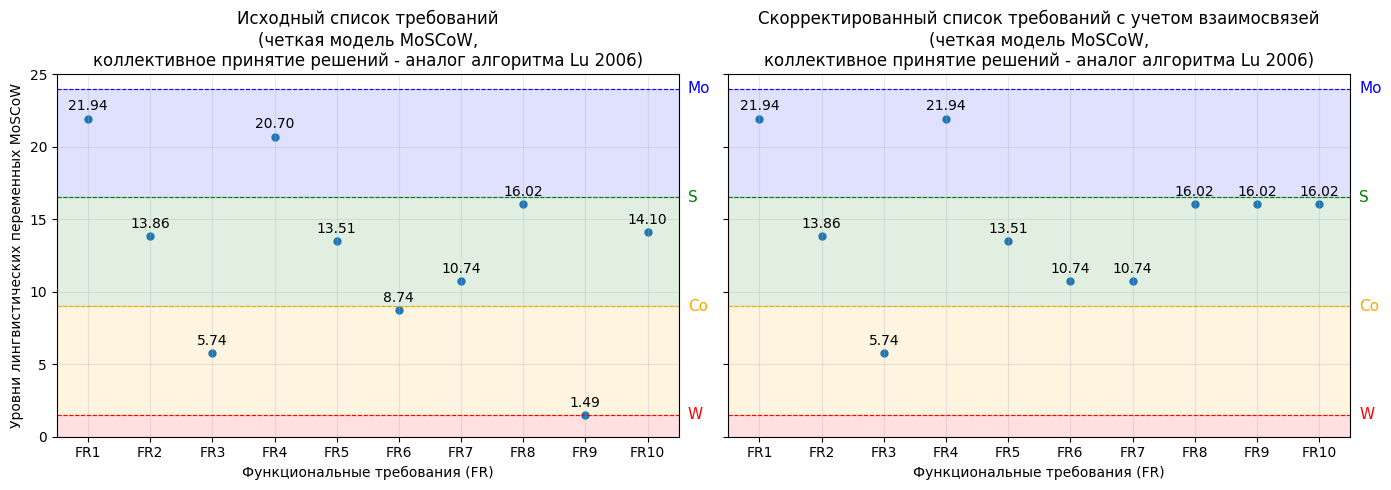

In [239]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразование скорректированного результата в словарь: {FR: adjusted_R_group}
adjusted_scores_by_fr = {item["fr"]: item["adjusted_R_group"] for item in adjusted_sorted_fr}

# Формирование списка FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    R_group_by_fr.keys(),
    key=lambda x: int(x.replace("FR", ""))
)

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [R_group_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (16.5, 24.0),
    "S": (9.0, 16.5),
    "Co": (1.5, 9.0),
    "W": (0, 1.5)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 24.0,
    "S": 16.5,
    "Co": 9.0,
    "W": 1.5
}

boundary_lines = [1.5, 9.0, 16.5, 24.0]
boundary_colors = {
    1.5: "red",
    9.0: "orange",
    16.5: "green",
    24.0: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Lu 2006)",
    "Скорректированный список требований с учетом взаимосвязей\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Lu 2006)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.35
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 25)
    ax.set_xlim(-0.5, len(fr_labels) - 0.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Версия с загрузкой данных из файла и выгрузкой итогов в файл Excel**

In [240]:
# Версия модели с загрузкой/ выгрузкой данных из файла/ в файл Excel

from typing import List, Dict, Any, Sequence, Tuple, Optional
import re
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# 1. Типы данных и шкалы MoSCoW
EPS = 1e-12

bold_font = Font(bold=True)
center_alignment = Alignment(horizontal="center", vertical="center", wrap_text=False)
left_alignment = Alignment(horizontal="left", vertical="center", wrap_text=False)

MOSCOW_NFR_WEIGHTS: Dict[str, float] = {
    "Mo": 8.0,
    "S": 5.5,
    "Co": 3.0,
    "W": 0.5
}

MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {
    "Mo": 1.0,
    "S": 0.66,
    "Co": 0.33,
    "W": 0.0
}

_ALLOWED = set(MOSCOW_NFR_WEIGHTS.keys())

# 2. Подготовка входных данных и расчет индивидуальных оценок экспертов
def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]

def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[str(x).strip()] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {sorted(_ALLOWED)}")

    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[str(x).strip()] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {sorted(_ALLOWED)}")

        scores[fr_name] = float(sum(a * b for a, b in zip(nfr_w, fr_w)))

    return scores

def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")

    if fr_names is None:
        fr_names = experts[0]["fr_names"]
    fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]

    weights_raw = [float(x) for x in expert_weights_raw]
    weights_norm = normalize_weights_w(weights_raw) if normalize_weights else weights_raw[:]

    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": dict(zip(expert_names, weights_raw)),
        "weights_norm": dict(zip(expert_names, weights_norm)),
        "weights_norm_list": weights_norm,
        "expert_scores": expert_scores,
    }

# 3. Построение матриц расстояния, сходства и согласованности
def build_crisp_matrices_by_fr(
    fr_names: Sequence[str],
    expert_names: Sequence[str],
    expert_scores: Dict[str, Dict[str, float]],
    beta: float,
) -> Tuple[
    Dict[str, np.ndarray],
    Dict[str, np.ndarray],
    Dict[str, np.ndarray],
]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1].")

    k = len(expert_names)
    if k == 0:
        raise ValueError("expert_names не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    for ex in expert_names:
        if ex not in expert_scores:
            raise ValueError(f"Нет expert_scores для эксперта '{ex}'.")
        for fr in fr_names:
            if fr not in expert_scores[ex]:
                raise ValueError(f"У эксперта '{ex}' нет оценки для '{fr}'.")

    dM_by_fr: Dict[str, np.ndarray] = {}
    AM_by_fr: Dict[str, np.ndarray] = {}
    AMr_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        x = np.array([float(expert_scores[ex][fr]) for ex in expert_names], dtype=float)
        diff = np.abs(x[:, None] - x[None, :])
        D_star = float(diff.max())

        if D_star <= EPS:
            dM = np.zeros((k, k), dtype=float)
        else:
            dM = diff / D_star

        S = (1.0 - dM) ** 2
        R = beta * S + (1.0 - beta) * (1.0 - dM)

        dM_by_fr[fr] = dM
        AM_by_fr[fr] = S
        AMr_by_fr[fr] = R

    return dM_by_fr, AM_by_fr, AMr_by_fr

def average_R_matrices(AMr_by_fr: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    return {fr: np.asarray(M, dtype=float) for fr, M in AMr_by_fr.items()}

# 4. Вычисление взвешенных степеней согласованности и весов агрегирования экспертов
def compute_C_for_all_fr(
    prepared: Dict[str, Any],
    R_avg_by_fr: Dict[str, np.ndarray],
) -> Dict[str, np.ndarray]:
    expert_names: List[str] = prepared["expert_names"]
    fr_names: List[str] = prepared["fr_names"]

    e = np.asarray([float(prepared["weights_norm"][name]) for name in expert_names], dtype=float)
    if np.any(e < 0):
        raise ValueError("weights_norm должны быть >= 0.")
    s = float(e.sum())
    if s <= EPS:
        raise ValueError("Сумма weights_norm должна быть > 0.")
    e = e / s

    k = len(expert_names)
    C_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        if fr not in R_avg_by_fr:
            raise ValueError(f"{fr}: отсутствует в R_avg_by_fr.")
        R = np.asarray(R_avg_by_fr[fr], dtype=float)
        if R.shape != (k, k):
            raise ValueError(f"{fr}: ожидается матрица {k}x{k}, получено {R.shape}.")
        C_by_fr[fr] = R @ e

    return C_by_fr

def compute_wE_for_all_fr(
    C_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    wE_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        if fr not in C_by_fr:
            raise ValueError(f"{fr}: отсутствует в C_by_fr")

        C = np.asarray(C_by_fr[fr], dtype=float)
        if C.ndim != 1 or C.size == 0:
            raise ValueError(f"{fr}: C должен быть непустым 1D-вектором")
        if np.any(C < -1e-15):
            raise ValueError(f"{fr}: C(Ei) должны быть >= 0")

        C = np.maximum(C, 0.0)
        s = float(C.sum())
        k = int(C.size)

        if s <= EPS:
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            w = C / s

        wE_by_fr[fr] = w

    return wE_by_fr

# 5. Расчет вкладов экспертов и групповой оценки
def contributions_and_group(
    prepared: Dict[str, Any],
    wE_by_fr: Dict[str, np.ndarray],
) -> Tuple[Dict[str, Dict[str, float]], Dict[str, float]]:
    fr_names: List[str] = prepared["fr_names"]
    expert_names: List[str] = prepared["expert_names"]
    scores_raw: Dict[str, Dict[str, float]] = prepared["expert_scores"]

    contrib_by_fr: Dict[str, Dict[str, float]] = {}
    group_score_by_fr: Dict[str, float] = {}

    for fr in fr_names:
        w = np.asarray(wE_by_fr[fr], dtype=float)
        if w.shape != (len(expert_names),):
            raise ValueError(f"{fr}: w(Ei) имеет неверную размерность: {w.shape}")

        row = {}
        total = 0.0
        for i, ex in enumerate(expert_names):
            v = float(scores_raw[ex][fr]) * float(w[i])
            row[ex] = v
            total += v

        contrib_by_fr[fr] = row
        group_score_by_fr[fr] = total

    return contrib_by_fr, group_score_by_fr

# 6. Корректировка приоритизации с учетом взаимосвязанности FR
def adjust_crisp_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной"
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]"
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов"
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_score"] = item["score"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(matrix_idx_to_item[i]["score"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_score"] = max_score

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_score"], x["original_rank"])
    )

    return adjusted_sorted

# 7. Загрузка данных из Excel
_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)

def load_expert_sheet(ws) -> Dict[str, Any]:
    sheet_name = str(ws.title).strip()

    nfr_header_row = None
    nfr_names: List[str] = []
    nfr_cols: List[int] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 1:
            start = min(cols)
            current_names = []
            current_cols = []
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    current_names.append(v.strip())
                    current_cols.append(c)
                else:
                    if current_names:
                        break
            if current_names:
                nfr_header_row = r
                nfr_names = current_names
                nfr_cols = current_cols
                break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{sheet_name}'")

    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{sheet_name}' в строке {nfr_priorities_row}.")
        term = str(v).strip()
        if term not in _ALLOWED:
            raise ValueError(f"{sheet_name}: недопустимый NFR приоритет '{term}'. Допустимо: {sorted(_ALLOWED)}")
        nfr_priorities.append(term)

    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR на листе '{sheet_name}'")

    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break

        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row: List[str] = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            if v is None or str(v).strip() == "":
                raise ValueError(f"{sheet_name}: пустая оценка для {fr_name}.")
            term = str(v).strip()
            if term not in _ALLOWED:
                raise ValueError(f"{sheet_name}: недопустимая оценка '{term}' в {fr_name}. Допустимо: {sorted(_ALLOWED)}")
            row.append(term)

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {
        "name": sheet_name,
        "nfr": nfr_priorities,
        "fr_names": fr_names,
        "frs": fr_matrix
    }

# 8. Форматирование и запись данных в Excel
def apply_base_style(ws):
    for row in ws.iter_rows():
        for cell in row:
            if cell.value is not None:
                if cell.alignment is None or cell.alignment.horizontal is None:
                    cell.alignment = center_alignment
            if isinstance(cell.value, (int, float)) and not isinstance(cell.value, bool):
                if ws.title == "Матрица взаимосвязей":
                    cell.number_format = "0"
                elif ws.title in {"Четкий MoSCoW_расчеты", "Четкий MoSCoW_итоги"} and cell.column == 1:
                    cell.number_format = "0"
                else:
                    cell.number_format = "0.00"

def auto_fit(ws, extra_pad: int = 2):
    max_col = ws.max_column
    max_row = ws.max_row

    for col_idx in range(1, max_col + 1):
        max_len = 0
        for row_idx in range(1, max_row + 1):
            value = ws.cell(row_idx, col_idx).value
            if value is None:
                continue
            text = str(value)
            if len(text) > max_len:
                max_len = len(text)

        calculated_width = min(max(max_len + extra_pad, 10), 28)
        col_letter = get_column_letter(col_idx)
        current_width = ws.column_dimensions[col_letter].width

        if current_width is None or current_width < calculated_width:
            ws.column_dimensions[col_letter].width = calculated_width

    for row_idx in range(1, max_row + 1):
        current_height = ws.row_dimensions[row_idx].height
        max_len = 0

        for col_idx in range(1, max_col + 1):
            value = ws.cell(row_idx, col_idx).value
            if value is None:
                continue
            text = str(value)
            if len(text) > max_len:
                max_len = len(text)

        calculated_height = 18 if max_len <= 35 else 24

        if current_height is None or current_height < calculated_height:
            ws.row_dimensions[row_idx].height = calculated_height

def write_section_title(ws, row: int, text: str, end_col: int) -> int:
    ws.cell(row, 1).value = text
    ws.cell(row, 1).font = bold_font
    ws.cell(row, 1).alignment = left_alignment
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=end_col)

    for col in range(1, end_col + 1):
        ws.cell(row, col).alignment = left_alignment

    return row + 1

def write_sheet_title(ws, row: int, text: str, end_col: int) -> int:
    ws.cell(row, 1).value = text
    ws.cell(row, 1).font = bold_font
    ws.cell(row, 1).alignment = left_alignment
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=end_col)

    for col in range(1, end_col + 1):
        ws.cell(row, col).alignment = left_alignment

    return row + 2

def write_weights_block(ws, start_row: int, expert_names: List[str], r_raw: List[float], w_norm: List[float]) -> int:
    r = write_section_title(ws, start_row, "1) Веса экспертов", 3)

    headers = ["Эксперт", "Вес_raw (r)", "Вес_norm (w)"]
    for c, h in enumerate(headers, start=1):
        ws.cell(r, c).value = h
        ws.cell(r, c).font = bold_font

    for i, (name, rr, ww) in enumerate(zip(expert_names, r_raw, w_norm), start=1):
        ws.cell(r + i, 1).value = name
        ws.cell(r + i, 2).value = float(rr)
        ws.cell(r + i, 3).value = float(ww)

    sum_row = r + len(expert_names) + 1
    ws.cell(sum_row, 1).value = "SUM"
    ws.cell(sum_row, 2).value = round(sum(r_raw), 2)
    ws.cell(sum_row, 3).value = round(sum(w_norm), 2)

    for c in range(1, 4):
        ws.cell(sum_row, c).font = bold_font

    return sum_row + 2


def write_params_block(ws, start_row: int, beta: float) -> int:
    r = write_section_title(ws, start_row, "2) Параметры модели", 3)

    rows = [
        ("Параметр beta", beta),
    ]

    for i, (label, value) in enumerate(rows):
        ws.cell(r + i, 1).value = label
        ws.cell(r + i, 2).value = float(value)
        ws.cell(r + i, 1).alignment = left_alignment

    return r + len(rows) + 2

def write_individual_scores_block(
    ws,
    start_row: int,
    title: str,
    fr_names: Sequence[str],
    expert_names: Sequence[str],
    expert_scores: Dict[str, Dict[str, float]],
) -> int:
    r = write_section_title(ws, start_row, title, len(expert_names) + 1)

    ws.cell(r, 1).value = "FR"
    ws.cell(r, 1).font = bold_font
    for i, name in enumerate(expert_names, start=1):
        ws.cell(r, 1 + i).value = name
        ws.cell(r, 1 + i).font = bold_font
    r += 1

    for fr in fr_names:
        ws.cell(r, 1).value = fr
        for i, name in enumerate(expert_names, start=1):
            ws.cell(r, 1 + i).value = float(expert_scores[name][fr])
        r += 1

    return r + 2

def write_dual_matrices_block(
    ws,
    start_row: int,
    title: str,
    left_title: str,
    right_title: str,
    fr_list: Sequence[str],
    left_mats: Dict[str, np.ndarray],
    right_mats: Dict[str, np.ndarray],
    expert_names: Sequence[str],
) -> int:
    k = len(expert_names)

    r = write_section_title(ws, start_row, title, 2 * k + 5)

    left_block_start = 1
    right_block_start = k + 4

    ws.cell(r, left_block_start).value = left_title
    ws.cell(r, left_block_start).font = bold_font
    ws.cell(r, left_block_start).alignment = left_alignment
    ws.merge_cells(start_row=r, start_column=left_block_start, end_row=r, end_column=left_block_start + k)

    ws.cell(r, right_block_start).value = right_title
    ws.cell(r, right_block_start).font = bold_font
    ws.cell(r, right_block_start).alignment = left_alignment
    ws.merge_cells(start_row=r, start_column=right_block_start, end_row=r, end_column=right_block_start + k)

    r += 2

    for fr in fr_list:
        ws.cell(r, left_block_start).value = fr
        ws.cell(r, left_block_start).font = bold_font
        ws.cell(r, left_block_start).alignment = left_alignment

        ws.cell(r, right_block_start).value = fr
        ws.cell(r, right_block_start).font = bold_font
        ws.cell(r, right_block_start).alignment = left_alignment

        r += 1

        for j, name in enumerate(expert_names, start=1):
            ws.cell(r, left_block_start + j).value = name
            ws.cell(r, left_block_start + j).font = bold_font

            ws.cell(r, right_block_start + j).value = name
            ws.cell(r, right_block_start + j).font = bold_font

        r += 1

        M1 = np.asarray(left_mats[fr], dtype=float)
        M2 = np.asarray(right_mats[fr], dtype=float)

        for i, name in enumerate(expert_names):
            ws.cell(r + i, left_block_start).value = name
            ws.cell(r + i, left_block_start).alignment = left_alignment

            ws.cell(r + i, right_block_start).value = name
            ws.cell(r + i, right_block_start).alignment = left_alignment

            for j in range(k):
                ws.cell(r + i, left_block_start + 1 + j).value = float(M1[i, j])
                ws.cell(r + i, right_block_start + 1 + j).value = float(M2[i, j])

        r += k + 2

    return r

def write_single_matrices_block(
    ws,
    start_row: int,
    title: str,
    fr_list: Sequence[str],
    mats: Dict[str, np.ndarray],
    expert_names: Sequence[str],
) -> int:
    k = len(expert_names)
    r = write_section_title(ws, start_row, title, k + 2)

    for fr in fr_list:
        ws.cell(r, 1).value = fr
        ws.cell(r, 1).font = bold_font
        ws.cell(r, 1).alignment = left_alignment
        r += 1

        for j, name in enumerate(expert_names, start=1):
            ws.cell(r, 1 + j).value = name
            ws.cell(r, 1 + j).font = bold_font
        r += 1

        M = np.asarray(mats[fr], dtype=float)
        for i, name in enumerate(expert_names):
            ws.cell(r + i, 1).value = name
            ws.cell(r + i, 1).alignment = left_alignment
            for j in range(k):
                ws.cell(r + i, 2 + j).value = float(M[i, j])

        r += k + 2

    return r

def write_vectors_block(
    ws,
    start_row: int,
    title: str,
    fr_list: Sequence[str],
    vectors: Dict[str, np.ndarray],
    expert_names: Sequence[str],
) -> int:
    r = write_section_title(ws, start_row, title, len(expert_names) + 1)

    ws.cell(r, 1).value = "FR"
    ws.cell(r, 1).font = bold_font
    for i, name in enumerate(expert_names, start=1):
        ws.cell(r, 1 + i).value = name
        ws.cell(r, 1 + i).font = bold_font
    r += 1

    for fr in fr_list:
        ws.cell(r, 1).value = fr
        vec = np.asarray(vectors[fr], dtype=float).reshape(-1)
        for j, value in enumerate(vec, start=1):
            ws.cell(r, 1 + j).value = float(value)
        r += 1

    return r + 2

def write_contributions_table(
    ws,
    start_row: int,
    title: str,
    fr_list: Sequence[str],
    contrib_by_fr: Dict[str, Dict[str, float]],
    expert_names: Sequence[str],
    group_score_by_fr: Dict[str, float],
) -> int:
    r = write_section_title(ws, start_row, title, len(expert_names) + 3)

    ws.cell(r, 1).value = "FR"
    ws.cell(r, 1).font = bold_font
    for i, name in enumerate(expert_names, start=1):
        ws.cell(r, 1 + i).value = name
        ws.cell(r, 1 + i).font = bold_font
    ws.cell(r, 2 + len(expert_names)).value = "Коллективная оценка"
    ws.cell(r, 2 + len(expert_names)).font = bold_font
    r += 1

    for fr in fr_list:
        ws.cell(r, 1).value = fr
        row_sum = 0.0
        for i, name in enumerate(expert_names, start=1):
            v = float(contrib_by_fr[fr][name])
            ws.cell(r, 1 + i).value = v
            row_sum += v
        ws.cell(r, 2 + len(expert_names)).value = float(group_score_by_fr[fr])
        r += 1

    return r + 2

def write_final_ranking_table(
    ws,
    start_row: int,
    title: str,
    sorted_rows: List[Dict[str, Any]],
) -> int:
    r = write_section_title(ws, start_row, title, 3)

    headers = ["Место", "FR", "Рейтинг"]
    for c, h in enumerate(headers, start=1):
        ws.cell(r, c).value = h
        ws.cell(r, c).font = bold_font
    r += 1

    for idx, item in enumerate(sorted_rows, start=1):
        ws.cell(r, 1).value = idx
        ws.cell(r, 2).value = item["fr"]
        ws.cell(r, 3).value = float(item["score"])
        r += 1

    return r + 2

def write_adjusted_results_table(ws, start_row: int, adjusted_rows_sorted: List[Dict[str, Any]]) -> int:
    r = write_section_title(ws, start_row, "2) Итоговая приоритизация после учета взаимосвязанности", 4)

    headers = ["Место", "FR", "Исходный рейтинг", "Скорректированный\nрейтинг"]
    for c, h in enumerate(headers, start=1):
        ws.cell(r, c).value = h
        ws.cell(r, c).font = bold_font
        ws.cell(r, c).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.row_dimensions[r].height = 32

    if ws.column_dimensions["A"].width is None or ws.column_dimensions["A"].width < 12:
        ws.column_dimensions["A"].width = 12
    if ws.column_dimensions["B"].width is None or ws.column_dimensions["B"].width < 10:
        ws.column_dimensions["B"].width = 10
    if ws.column_dimensions["C"].width is None or ws.column_dimensions["C"].width < 22:
        ws.column_dimensions["C"].width = 22
    if ws.column_dimensions["D"].width is None or ws.column_dimensions["D"].width < 24:
        ws.column_dimensions["D"].width = 24

    r += 1

    for idx, item in enumerate(adjusted_rows_sorted, start=1):
        ws.cell(r, 1).value = idx
        ws.cell(r, 2).value = item["fr"]
        ws.cell(r, 3).value = float(item["score"])
        ws.cell(r, 4).value = float(item["adjusted_score"])
        r += 1

    return r + 1

def write_relation_matrix_sheet(ws, fr_names: Sequence[str], relation_matrix: Sequence[Sequence[int]]):
    ws.title = "Матрица взаимосвязей"

    ws.cell(1, 1).value = "Матрица взаимосвязанности функциональных требований"
    ws.cell(1, 1).font = bold_font
    ws.cell(1, 1).alignment = left_alignment
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=len(fr_names) + 1)

    ws.cell(3, 1).value = "FR"
    ws.cell(3, 1).font = bold_font

    for j, fr in enumerate(fr_names, start=2):
        ws.cell(3, j).value = fr
        ws.cell(3, j).font = bold_font

    for i, fr in enumerate(fr_names, start=4):
        ws.cell(i, 1).value = fr
        ws.cell(i, 1).font = bold_font
        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j).value = int(value)

# 9. Основной расчет и формирование выходного Excel-файла
def run_all_crisp_moscow_lu_2006(
    input_xlsx: str,
    output_xlsx: str,
    weights_raw: Sequence[float],
    beta: float,
    relation_matrix: Sequence[Sequence[int]],
) -> str:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0,1].")

    wb = load_workbook(input_xlsx)

    expert_sheet_names = [
        name for name in wb.sheetnames
        if name not in {"Матрица взаимосвязей", "Четкий MoSCoW_расчеты", "Четкий MoSCoW_итоги"}
    ]

    experts = [load_expert_sheet(wb[name]) for name in expert_sheet_names]
    if len(experts) == 0:
        raise ValueError("Во входном файле не найдены листы экспертов.")

    if len(weights_raw) != len(experts):
        raise ValueError("Количество весов экспертов должно совпадать с количеством листов экспертов.")

    fr_list = experts[0]["fr_names"]
    for ex in experts[1:]:
        if ex["fr_names"] != fr_list:
            raise ValueError("Списки FR на листах экспертов должны совпадать.")

    prepared = prepare_crisp_moscow_inputs(
        experts=experts,
        expert_weights_raw=weights_raw,
        fr_names=fr_list,
        normalize_weights=True,
    )

    expert_names = prepared["expert_names"]
    weights_norm_list = prepared["weights_norm_list"]
    expert_scores = prepared["expert_scores"]

    dM_by_fr, AM_by_fr, AMr_by_fr = build_crisp_matrices_by_fr(
        fr_names=fr_list,
        expert_names=expert_names,
        expert_scores=expert_scores,
        beta=beta,
    )

    R_avg_by_fr = average_R_matrices(AMr_by_fr)
    C_by_fr = compute_C_for_all_fr(prepared, R_avg_by_fr)
    wE_by_fr = compute_wE_for_all_fr(C_by_fr, fr_list)
    contrib_by_fr, group_score_by_fr = contributions_and_group(prepared, wE_by_fr)

    ranked_group_rows = [
        {"fr": fr, "score": score}
        for fr, score in sorted(group_score_by_fr.items(), key=lambda x: x[1], reverse=True)
    ]

    adjusted_rows_sorted = adjust_crisp_ranked_by_interdependencies(
        ranked_group_rows,
        relation_matrix
    )

    for sheet_name in ["Матрица взаимосвязей", "Четкий MoSCoW_расчеты", "Четкий MoSCoW_итоги"]:
        if sheet_name in wb.sheetnames:
            del wb[sheet_name]

    insert_pos = len(expert_sheet_names)
    ws_rel = wb.create_sheet("Матрица взаимосвязей", insert_pos)
    ws_calc = wb.create_sheet("Четкий MoSCoW_расчеты", insert_pos + 1)
    ws_final = wb.create_sheet("Четкий MoSCoW_итоги", insert_pos + 2)

    write_relation_matrix_sheet(ws_rel, fr_list, relation_matrix)

    r = 1
    r = write_sheet_title(ws_calc, r, "Четкий MoSCoW - расчеты (коллективная оценка, аналог Lu 2006)", 18)
    r = write_weights_block(ws_calc, r, expert_names, list(weights_raw), weights_norm_list)
    r = write_params_block(ws_calc, r, beta)

    r = write_individual_scores_block(
        ws_calc,
        r,
        "3) Индивидуальные оценки экспертов",
        fr_list,
        expert_names,
        expert_scores,
    )

    r = write_dual_matrices_block(
        ws_calc,
        r,
        "4) Матрицы расстояния и сходства",
        "dM",
        "AM",
        fr_list,
        dM_by_fr,
        AM_by_fr,
        expert_names,
    )

    r = write_single_matrices_block(
        ws_calc,
        r,
        "5) Матрицы согласованности AMr",
        fr_list,
        AMr_by_fr,
        expert_names,
    )

    r = write_vectors_block(
        ws_calc,
        r,
        "6) Взвешенная степень согласованности эксперта C(Ei)",
        fr_list,
        C_by_fr,
        expert_names,
    )

    r = write_vectors_block(
        ws_calc,
        r,
        "7) Веса агрегирования экспертов w(Ei)",
        fr_list,
        wE_by_fr,
        expert_names,
    )

    r = write_contributions_table(
        ws_calc,
        r,
        "8) Вклады экспертов в коллективный рейтинг",
        fr_list,
        contrib_by_fr,
        expert_names,
        group_score_by_fr,
    )

    rf = 1
    rf = write_sheet_title(ws_final, rf, "Четкий MoSCoW - итоги (коллективная оценка, аналог Lu 2006)", 18)
    rf = write_final_ranking_table(
        ws_final,
        rf,
        "1) Итоговый коллективный рейтинг",
        ranked_group_rows,
    )
    rf = write_adjusted_results_table(ws_final, rf, adjusted_rows_sorted)

    for ws in [ws_rel, ws_calc, ws_final]:
        apply_base_style(ws)
        auto_fit(ws)

    ws_rel.column_dimensions["A"].width = 14
    ws_calc.column_dimensions["A"].width = 24
    ws_calc.column_dimensions["G"].width = 20
    ws_final.column_dimensions["A"].width = 10

    wb.save(output_xlsx)
    return output_xlsx

In [241]:
# Запуск

INPUT_XLSX = r"Загрузочные данные_MoSCoW_коллектив.xlsx"
OUTPUT_XLSX = r"Итоги_четкий MoSCoW_Lu 2006.xlsx"

WEIGHTS_RAW = [0.75, 0.75, 1.0]
BETA = 0.4

RELATION_MATRIX = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
]

out = run_all_crisp_moscow_lu_2006(
    input_xlsx=INPUT_XLSX,
    output_xlsx=OUTPUT_XLSX,
    weights_raw=WEIGHTS_RAW,
    beta=BETA,
    relation_matrix=RELATION_MATRIX,
)

print("Файл сохранен:", out)

Файл сохранен: Итоги_четкий MoSCoW_Lu 2006.xlsx


# 3 Приоритизации по методу RICE

# 3.1. Нечеткий метод RICE

In [242]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [243]:
# Функция вычмсления произведения нескольких нечетких чисел, для данной модели - показателей R, I, C в нечетком виде
def calculate_RIC_multiply(*params):
    RIC_multiply = params[0]
    for param in params[1:]:
        RIC_multiply = multiply_intuitionistic_trapezoidal_fuzzy_numbers (RIC_multiply, param)
    return RIC_multiply

In [244]:
# Функция округления параметров трапециевидного нечеткого числа (интуиционистского или интервального 2 типа)
def round_fuzzy_number(fuzzy_number):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    return ((round(x1, 2), round(x2, 2), round(x3, 2), round(x4, 2)),
            (round(x5, 2), round(x6, 2), round(x7, 2), round(x8, 2)))

In [245]:
# Функция деления отдного нечеткого трапециевичного числа на другое
def divide_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для частного от деления
    z1 = (x2 * y3 - x2 * y4 + x1 * y3) / ((y3)**2)
    z2 = x2 / y3
    z3 = x3 / y2
    z4 = (x3 * y2 - x3 * y1 + x4 * y2) / ((y2)**2)

    z5 = (x6 * y7 - x6 * y8 + x5 * y7) / ((y7)**2)
    z6 = x6 / y7
    z7 = x7 / y6
    z8 = (x7 * y6 - x7 * y5 + x8 * y6) / ((y6)**2)

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [246]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [247]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [248]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

**Реализация нечеткой модели RICE для произвольного числа функциональных требований FR (расчет выполнен одним экспертом). Загрузка и выгрузка данных в ноутбуке**

In [249]:
# Ввод данных для функциональных требований FR в виде словаря.
# Каждое значение R, I, C, E задается как ИНМТ2:
# ((x1, x2, x3, x4), (x5, x6, x7, x8))

features_fuzzy = [
    {
        "Feature": "FR1",
        "R": ((9700, 9900, 10100, 10300), (9800, 9900, 10100, 10200)),
        "I": ((0.97, 0.99, 1.01, 1.03), (0.98, 0.99, 1.01, 1.02)),
        "C": ((0.582, 0.594, 0.606, 0.618), (0.588, 0.594, 0.606, 0.612)),
        "E": ((9.70, 9.90, 10.10, 10.30), (9.80, 9.90, 10.10, 10.20)),
    },
    {
        "Feature": "FR2",
        "R": ((97, 99, 101, 103), (98, 99, 101, 102)),
        "I": ((2.91, 2.97, 3.00, 3.00), (2.94, 2.97, 3.00, 3.00)),
        "C": ((0.873, 0.891, 0.909, 0.927), (0.882, 0.891, 0.909, 0.918)),
        "E": ((4.85, 4.95, 5.05, 5.15), (4.90, 4.95, 5.05, 5.10)),
    },
    {
        "Feature": "FR3",
        "R": ((970, 990, 1010, 1030), (980, 990, 1010, 1020)),
        "I": ((1.94, 1.98, 2.02, 2.06), (1.96, 1.98, 2.02, 2.04)),
        "C": ((0.776, 0.792, 0.808, 0.824), (0.784, 0.792, 0.808, 0.816)),
        "E": ((6.79, 6.93, 7.07, 7.21), (6.86, 6.93, 7.07, 7.14)),
    },
    {
        "Feature": "FR4",
        "R": ((97, 99, 101, 103), (98, 99, 101, 102)),
        "I": ((0.485, 0.495, 0.505, 0.515), (0.49, 0.495, 0.505, 0.51)),
        "C": ((0.679, 0.693, 0.707, 0.721), (0.686, 0.693, 0.707, 0.714)),
        "E": ((1.94, 1.98, 2.02, 2.06), (1.96, 1.98, 2.02, 2.04)),
    },
    {
        "Feature": "FR5",
        "R": ((194, 198, 202, 206), (196, 198, 202, 204)),
        "I": ((2.91, 2.97, 3.00, 3.00), (2.94, 2.97, 3.00, 3.00)),
        "C": ((0.485, 0.495, 0.505, 0.515), (0.49, 0.495, 0.505, 0.51)),
        "E": ((11.64, 11.88, 12.12, 12.36), (11.76, 11.88, 12.12, 12.24)),
    },
    {
        "Feature": "FR6",
        "R": ((9.7, 9.9, 10.1, 10.3), (9.8, 9.9, 10.1, 10.2)),
        "I": ((0.97, 0.99, 1.01, 1.03), (0.98, 0.99, 1.01, 1.02)),
        "C": ((0.97, 0.99, 1.00, 1.00), (0.98, 0.99, 1.00, 1.00)),
        "E": ((12.61, 12.87, 13.13, 13.39), (12.74, 12.87, 13.13, 13.26)),
    },
    {
        "Feature": "FR7",
        "R": ((48.5, 49.5, 50.5, 51.5), (49.0, 49.5, 50.5, 51.0)),
        "I": ((1.94, 1.98, 2.02, 2.06), (1.96, 1.98, 2.02, 2.04)),
        "C": ((0.776, 0.792, 0.808, 0.824), (0.784, 0.792, 0.808, 0.816)),
        "E": ((20.37, 20.79, 21.21, 21.63), (20.58, 20.79, 21.21, 21.42)),
    },
    {
        "Feature": "FR8",
        "R": ((970, 990, 1010, 1030), (980, 990, 1010, 1020)),
        "I": ((0.485, 0.495, 0.505, 0.515), (0.49, 0.495, 0.505, 0.51)),
        "C": ((0.873, 0.891, 0.909, 0.927), (0.882, 0.891, 0.909, 0.918)),
        "E": ((4.85, 4.95, 5.05, 5.15), (4.90, 4.95, 5.05, 5.10)),
    },
    {
        "Feature": "FR9",
        "R": ((19400, 19800, 20200, 20600), (19600, 19800, 20200, 20400)),
        "I": ((0.2425, 0.2475, 0.2525, 0.2575), (0.245, 0.2475, 0.2525, 0.255)),
        "C": ((0.582, 0.594, 0.606, 0.618), (0.588, 0.594, 0.606, 0.612)),
        "E": ((6.79, 6.93, 7.07, 7.21), (6.86, 6.93, 7.07, 7.14)),
    },
    {
        "Feature": "FR10",
        "R": ((291, 297, 303, 309), (294, 297, 303, 306)),
        "I": ((1.94, 1.98, 2.02, 2.06), (1.96, 1.98, 2.02, 2.04)),
        "C": ((0.679, 0.693, 0.707, 0.721), (0.686, 0.693, 0.707, 0.714)),
        "E": ((2.91, 2.97, 3.03, 3.09), (2.94, 2.97, 3.03, 3.06)),
    },
]

In [250]:
# Расчет нечетких оценок RICE для произвольного числа функциональных требований

rice_results_fuzzy = []

for feature_data in features_fuzzy:
    feature_name = feature_data["Feature"]
    R = feature_data["R"]
    I = feature_data["I"]
    C = feature_data["C"]
    E = feature_data["E"]

    # Вычисление произведения R * I * C
    RIC_mult = calculate_RIC_multiply(R, I, C)
    RIC_rounded = round_fuzzy_number(RIC_mult)

    # Вычисление нечеткой оценки RICE = (R * I * C) / E
    RICE_score = divide_intuitionistic_trapezoidal_fuzzy_numbers(RIC_mult, E)
    RICE_rounded = round_fuzzy_number(RICE_score)

    rice_results_fuzzy.append({
        "Feature": feature_name,
        "RICE Score Fuzzy": RICE_rounded
    })

# Вывод списка нечетких оценок RICE
for item in rice_results_fuzzy:
    print(f"{item['Feature']}: {item['RICE Score Fuzzy']}")

FR1: ((530.07, 576.42, 624.42, 674.13), (553.24, 576.42, 624.42, 649.28))
FR2: ((47.71, 51.88, 55.64, 58.97), (49.79, 51.88, 55.64, 57.31))
FR3: ((201.93, 219.59, 237.88, 256.81), (210.76, 219.59, 237.88, 247.34))
FR4: ((15.46, 16.81, 18.21, 19.66), (16.14, 16.81, 18.21, 18.94))
FR5: ((22.09, 24.02, 25.76, 27.3), (23.05, 24.02, 25.76, 26.53))
FR6: ((0.68, 0.74, 0.79, 0.84), (0.71, 0.74, 0.79, 0.82))
FR7: ((3.37, 3.66, 3.96, 4.28), (3.51, 3.66, 3.96, 4.12))
FR8: ((79.51, 86.46, 93.66, 101.12), (82.99, 86.46, 93.66, 97.39))
FR9: ((378.62, 411.73, 446.02, 481.52), (395.17, 411.73, 446.02, 463.77))
FR10: ((123.68, 134.5, 145.7, 157.3), (129.09, 134.5, 145.7, 151.5))


In [251]:
# Редукция типа ИНМТ2 в ИНМТ1 для всех функциональных требований

a = 0.6  # параметр редукции

rice_reduced_results = []

for item in rice_results_fuzzy:
    feature_name = item["Feature"]
    rice_fuzzy = item["RICE Score Fuzzy"]

    rice_reduced = cltr_type_reduction(rice_fuzzy, a)

    rice_reduced_results.append({
        "Feature": feature_name,
        "RICE Score Reduced": rice_reduced
    })

for item in rice_reduced_results:
    print(f"{item['Feature']}: {item['RICE Score Reduced']}")

FR1: (543.97, 576.42, 624.42, 659.22)
FR2: (48.96, 51.88, 55.64, 57.97)
FR3: (207.23, 219.59, 237.88, 251.13)
FR4: (15.87, 16.81, 18.21, 19.23)
FR5: (22.67, 24.02, 25.76, 26.84)
FR6: (0.7, 0.74, 0.79, 0.83)
FR7: (3.45, 3.66, 3.96, 4.18)
FR8: (81.6, 86.46, 93.66, 98.88)
FR9: (388.55, 411.73, 446.02, 470.87)
FR10: (126.93, 134.5, 145.7, 153.82)


In [252]:
# Дефаззификация ИНМТ1 через альфа-срез для всех функциональных требований

alpha = 0.8

rice_alpha_cut_results = []

for item in rice_reduced_results:
    feature_name = item["Feature"]
    rice_reduced = item["RICE Score Reduced"]

    alpha_cut_result = alpha_cut(rice_reduced, alpha)

    rice_alpha_cut_results.append({
        "Feature": feature_name,
        "Alpha-cut": alpha_cut_result
    })

for item in rice_alpha_cut_results:
    print(f"{item['Feature']}: {item['Alpha-cut']}")

FR1: (569.93, 631.38)
FR2: (51.3, 56.11)
FR3: (217.12, 240.53)
FR4: (16.62, 18.41)
FR5: (23.75, 25.98)
FR6: (0.73, 0.8)
FR7: (3.62, 4.0)
FR8: (85.49, 94.7)
FR9: (407.09, 450.99)
FR10: (132.99, 147.32)


In [253]:
# Вычисление центроида для всех функциональных требований

rice_centroid_results = []

for item in rice_alpha_cut_results:
    feature_name = item["Feature"]
    alpha_cut_result = item["Alpha-cut"]

    centroid_result = centroid(alpha_cut_result)

    rice_centroid_results.append({
        "Feature": feature_name,
        "Centroid": centroid_result
    })

for item in rice_centroid_results:
    print(f"{item['Feature']}: {item['Centroid']}")

FR1: 600.65
FR2: 53.7
FR3: 228.82
FR4: 17.52
FR5: 24.87
FR6: 0.77
FR7: 3.81
FR8: 90.09
FR9: 429.04
FR10: 140.16


In [254]:
# Итоговая приоритизация функциональных требований по значению центроида

import pandas as pd

df_rice_final = pd.DataFrame(rice_centroid_results)

# Сортировка по убыванию значения центроида
df_rice_final = df_rice_final.sort_values("Centroid", ascending=False).reset_index(drop=True)

# Добавляем ранг
df_rice_final.insert(0, "Rank", df_rice_final.index + 1)

print(df_rice_final.to_string(index=False))

 Rank Feature  Centroid
    1     FR1    600.65
    2     FR9    429.04
    3     FR3    228.82
    4    FR10    140.16
    5     FR8     90.09
    6     FR2     53.70
    7     FR5     24.87
    8     FR4     17.52
    9     FR7      3.81
   10     FR6      0.77


Алгоритм учета взаимосвязанности функциональных требований

In [255]:
from typing import List, Dict, Any, Sequence

def adjust_rice_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(feature_name: str) -> int:
        if not feature_name.startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {feature_name}"
            )
        return int(feature_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["Feature"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["Adjusted_Centroid"] = item["Centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["Feature"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["Centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["Adjusted_Centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["Adjusted_Centroid"], -x["Centroid"], x["Feature"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [256]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_rice_centroid_results = adjust_rice_ranked_by_interdependencies(
    rice_centroid_results,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for item in adjusted_rice_centroid_results:
    print(
        f"{item['Feature']}: "
        f"исходный Centroid = {item['Centroid']:.2f}, "
        f"скорректированный Centroid = {item['Adjusted_Centroid']:.2f}"
    )

Скорректированный ранжированный список:
FR1: исходный Centroid = 600.65, скорректированный Centroid = 600.65
FR4: исходный Centroid = 17.52, скорректированный Centroid = 600.65
FR9: исходный Centroid = 429.04, скорректированный Centroid = 429.04
FR10: исходный Centroid = 140.16, скорректированный Centroid = 429.04
FR8: исходный Centroid = 90.09, скорректированный Centroid = 429.04
FR3: исходный Centroid = 228.82, скорректированный Centroid = 228.82
FR2: исходный Centroid = 53.70, скорректированный Centroid = 53.70
FR5: исходный Centroid = 24.87, скорректированный Centroid = 24.87
FR7: исходный Centroid = 3.81, скорректированный Centroid = 3.81
FR6: исходный Centroid = 0.77, скорректированный Centroid = 3.81


Визуализации исходного и итогового приоритизированного списков функциональных требований

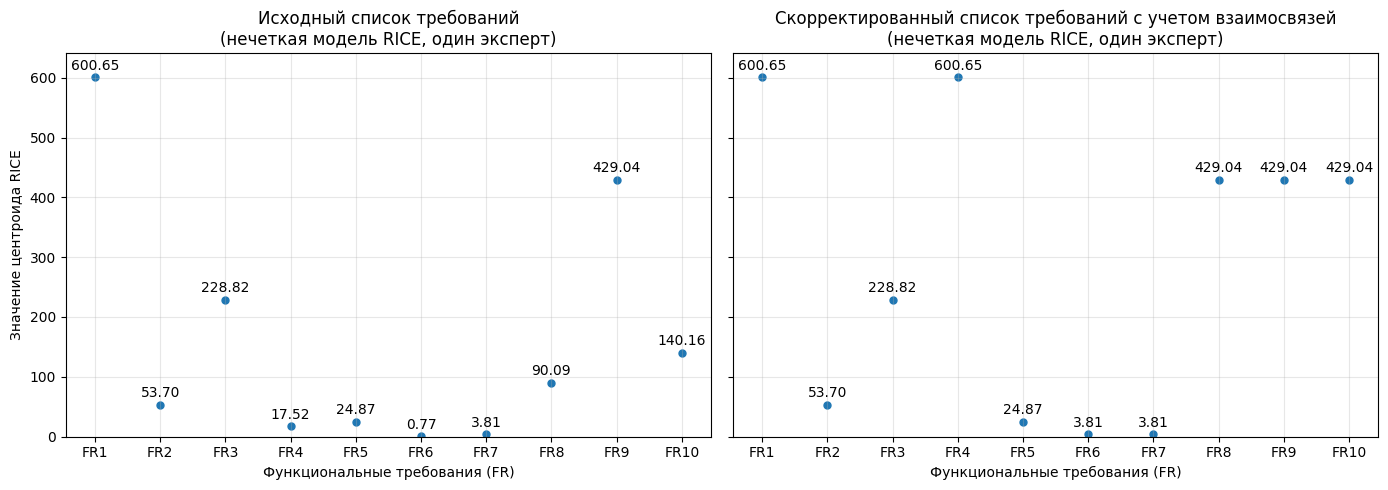

In [257]:
import matplotlib.pyplot as plt
import numpy as np

# Формирование списка FR в порядке FR1, FR2, ..., FRn
fr_labels = sorted(
    [r["Feature"] for r in rice_centroid_results],
    key=lambda x: int(x.replace("FR", ""))
)

# Исходные и скорректированные оценки требований
scores = [r["Centroid"] for r in rice_centroid_results]
adjusted_scores_by_fr = {r["Feature"]: r["Adjusted_Centroid"] for r in adjusted_rice_centroid_results}
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель RICE, один эксперт)",
    "Скорректированный список требований с учетом взаимосвязей\n(нечеткая модель RICE, один эксперт)"
]

all_scores = [scores, adjusted_scores]
y_max = max(max(scores), max(adjusted_scores)) + 40

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 7.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, y_max)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Значение центроида RICE")

plt.tight_layout()
plt.show()

**Реализация нечеткой модели RICE для произвольного числа функциональных требований FR (расчет выполнен одним экспертом). Загрузка и выгрузка данных из файла/ в файл Excel**

In [258]:
# Реализация Fuzzy RICE с загрузкой/ выгрузкой данных в Excel

from pathlib import Path
import shutil
from typing import Dict, Any, Sequence, List
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# 1. Учет взаимосвязанности функциональных требований
def adjust_rice_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(feature_name: str) -> int:
        if not feature_name.startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {feature_name}"
            )
        return int(feature_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["Feature"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["Adjusted_Centroid"] = item["Centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["Feature"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["Centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["Adjusted_Centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["Adjusted_Centroid"], x["original_rank"])
    )

    return adjusted_sorted

# 2. Вспомогательные функции оформления Excel
def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):
                cell.number_format = "0.00"

def autosize_columns(ws, min_width: int = 12, max_width: int = 40, extra_padding: int = 2):
    for col_idx in range(1, ws.max_column + 1):
        max_length = 0
        column_letter = get_column_letter(col_idx)

        for row_idx in range(1, ws.max_row + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            value = "" if cell.value is None else str(cell.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_length = max(max_length, longest)

        ws.column_dimensions[column_letter].width = max(
            min_width,
            min(max_length + extra_padding, max_width)
        )


def style_range_as_table(ws, min_row: int, max_row: int, min_col: int, max_col: int):
    thin = Side(style="thin")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for row in ws.iter_rows(min_row=min_row, max_row=max_row, min_col=min_col, max_col=max_col):
        for cell in row:
            cell.border = border
            if cell.alignment is None:
                cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)


# 3. Лист матрицы взаимосвязанности
def write_relation_matrix_sheet(
    workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in workbook.sheetnames:
        del workbook[sheet_name]

    ws = workbook.create_sheet(title=sheet_name)

    title_font = Font(bold=True, size=12)
    header_font = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    def fr_sort_key(fr_name: str) -> int:
        fr_name = str(fr_name).strip()
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", ""))

    fr_names_ordered = sorted([str(fr).strip() for fr in fr_names], key=fr_sort_key)

    n = len(fr_names_ordered)
    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1), horizontal="left")
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = center

    for j, fr in enumerate(fr_names_ordered, start=2):
        ws.cell(3, j, fr).font = header_font
        ws.cell(3, j).alignment = center

    for i, fr in enumerate(fr_names_ordered, start=4):
        ws.cell(i, 1, fr).font = header_font
        ws.cell(i, 1).alignment = center
        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, int(value))
            ws.cell(i, j).alignment = center

    format_numeric_cells(ws)

    for row_idx in range(4, 4 + len(fr_names_ordered)):
        for col_idx in range(2, 2 + len(fr_names_ordered)):
            ws.cell(row=row_idx, column=col_idx).number_format = "0"

    autosize_columns(ws, min_width=12, max_width=20, extra_padding=3)
    ws.column_dimensions["A"].width = 10

# 4. Основная функция загрузки, расчета и выгрузки в Excel
def compute_fuzzy_rice_from_file(
    input_path: str,
    input_sheet_name: str = "Fuzzy RICE_эксперт 1",
    output_sheet_name: str = "Итоги_Fuzzy RICE_эксперт 1",
    output_path: str | None = None,
    a: float = 0.6,
    alpha: float = 0.8,
    relation_matrix: Sequence[Sequence[int]] | None = None,
    relation_sheet_name: str = "Матрица_взаимосвязей_FR"
) -> pd.DataFrame:

    # 4.1. Проверка путей
    input_path = Path(input_path)

    if not input_path.exists():
        raise FileNotFoundError(f"Файл не найден: {input_path}")

    if input_path.suffix.lower() not in [".xlsx", ".xls"]:
        raise ValueError("Для такого режима работы нужен Excel-файл .xlsx или .xls")

    if output_path is None:
        output_path = input_path.with_name("Итоги_Fuzzy RICE_один эксперт" + input_path.suffix)
    else:
        output_path = Path(output_path)

    # 4.2. Чтение входного листа
    raw_df = pd.read_excel(input_path, sheet_name=input_sheet_name, header=None)

    if raw_df.shape[0] < 3:
        raise ValueError("На листе недостаточно строк для чтения данных.")

    data_rows = raw_df.iloc[2:].copy().reset_index(drop=True)

    # 4.3. Расчет нечеткого RICE
    results = []

    for _, row in data_rows.iterrows():
        feature = row[0]

        if pd.isna(feature):
            continue

        feature = str(feature).strip()
        if feature == "":
            continue

        try:
            R = (
                (float(row[1]),  float(row[2]),  float(row[3]),  float(row[4])),
                (float(row[5]),  float(row[6]),  float(row[7]),  float(row[8]))
            )

            I = (
                (float(row[9]),  float(row[10]), float(row[11]), float(row[12])),
                (float(row[13]), float(row[14]), float(row[15]), float(row[16]))
            )

            C = (
                (float(row[17]), float(row[18]), float(row[19]), float(row[20])),
                (float(row[21]), float(row[22]), float(row[23]), float(row[24]))
            )

            E = (
                (float(row[25]), float(row[26]), float(row[27]), float(row[28])),
                (float(row[29]), float(row[30]), float(row[31]), float(row[32]))
            )
        except Exception as e:
            raise ValueError(f"Ошибка чтения параметров для {feature}: {e}")

        RIC_mult = calculate_RIC_multiply(R, I, C)
        RICE_score = divide_intuitionistic_trapezoidal_fuzzy_numbers(RIC_mult, E)
        RICE_fuzzy = round_fuzzy_number(RICE_score)

        RICE_reduced = cltr_type_reduction(RICE_fuzzy, a)
        alpha_interval = alpha_cut(RICE_reduced, alpha)
        centroid_value = centroid(alpha_interval)

        (it2_x1, it2_x2, it2_x3, it2_x4), (it2_x5, it2_x6, it2_x7, it2_x8) = RICE_fuzzy
        it1_x1, it1_x2, it1_x3, it1_x4 = RICE_reduced
        alpha_left, alpha_right = alpha_interval

        results.append({
            "Ранг": None,
            "Feature": feature,
            "ИНМТ2 x1": it2_x1,
            "ИНМТ2 x2": it2_x2,
            "ИНМТ2 x3": it2_x3,
            "ИНМТ2 x4": it2_x4,
            "ИНМТ2 x5": it2_x5,
            "ИНМТ2 x6": it2_x6,
            "ИНМТ2 x7": it2_x7,
            "ИНМТ2 x8": it2_x8,
            "ИНМТ1 x1": it1_x1,
            "ИНМТ1 x2": it1_x2,
            "ИНМТ1 x3": it1_x3,
            "ИНМТ1 x4": it1_x4,
            "Альфа-срез левый": alpha_left,
            "Альфа-срез правый": alpha_right,
            "Центроид": round(centroid_value, 2)
        })

    if not results:
        raise ValueError("Не удалось прочитать ни одной строки с функциональными требованиями.")

    # 4.4. Формирование основной итоговой таблицы
    result_df = pd.DataFrame(results)

    ordered_columns = [
        "Ранг", "Feature",
        "ИНМТ2 x1", "ИНМТ2 x2", "ИНМТ2 x3", "ИНМТ2 x4",
        "ИНМТ2 x5", "ИНМТ2 x6", "ИНМТ2 x7", "ИНМТ2 x8",
        "ИНМТ1 x1", "ИНМТ1 x2", "ИНМТ1 x3", "ИНМТ1 x4",
        "Альфа-срез левый", "Альфа-срез правый",
        "Центроид"
    ]
    result_df = result_df[ordered_columns]
    result_df = result_df.sort_values("Центроид", ascending=False).reset_index(drop=True)
    result_df["Ранг"] = result_df.index + 1

    fr_names = result_df["Feature"].tolist()

    # 4.5. Матрица взаимосвязанности по умолчанию
    if relation_matrix is None:
        n = len(result_df)
        relation_matrix = [[1 if i == j else 0 for j in range(n)] for i in range(n)]

    # 4.6. Расчет скорректированного рейтинга
    ranked_list = [
        {"Feature": row["Feature"], "Centroid": row["Центроид"]}
        for _, row in result_df.iterrows()
    ]

    adjusted_list = adjust_rice_ranked_by_interdependencies(
        ranked_list=ranked_list,
        relation_matrix=relation_matrix
    )

    adjusted_df = pd.DataFrame([
        {
            "Место": idx + 1,
            "FR": item["Feature"],
            "Исходный центроид": round(item["Centroid"], 2),
            "Скорректированный центроид": round(item["Adjusted_Centroid"], 2)
        }
        for idx, item in enumerate(adjusted_list)
    ])

    # 4.7. Создание выходного файла
    shutil.copy2(input_path, output_path)

    with pd.ExcelWriter(
        output_path,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        result_df.to_excel(
            writer,
            sheet_name=output_sheet_name,
            index=False,
            header=False,
            startrow=10
        )

    # 4.8. Открытие книги
    workbook = load_workbook(output_path)

    # 4.9. Лист матрицы взаимосвязанности
    write_relation_matrix_sheet(
        workbook=workbook,
        fr_names=fr_names,
        relation_matrix=relation_matrix,
        sheet_name=relation_sheet_name
    )

    # 4.10. Лист итогов
    worksheet = workbook[output_sheet_name]

    bold_font = Font(bold=True)
    center_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    worksheet.cell(1, 1, "Нечеткий RICE - итоговая приоритизация (один эксперт)").font = bold_font
    apply_single_line_heading(worksheet.cell(1, 1), horizontal="left")
    worksheet.row_dimensions[1].height = 20

    worksheet.cell(3, 1, "1) Параметры модели").font = bold_font
    apply_single_line_heading(worksheet.cell(3, 1), horizontal="left")
    worksheet.row_dimensions[3].height = 20

    worksheet.cell(4, 1, "Параметр").font = bold_font
    worksheet.cell(4, 2, "Значение").font = bold_font
    worksheet.cell(4, 1).alignment = center_alignment
    worksheet.cell(4, 2).alignment = center_alignment

    worksheet.cell(5, 1, "a (редукция\nтипа CLTR)")
    worksheet.cell(5, 2, float(a))
    worksheet.cell(5, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    worksheet.cell(5, 2).alignment = center_alignment

    worksheet.cell(6, 1, "alpha (уровень\nальфа-среза)")
    worksheet.cell(6, 2, float(alpha))
    worksheet.cell(6, 1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    worksheet.cell(6, 2).alignment = center_alignment

    worksheet.row_dimensions[4].height = 20
    worksheet.row_dimensions[5].height = 34
    worksheet.row_dimensions[6].height = 34

    # 4.11. Подпись к первой таблице
    worksheet.cell(8, 1, "2) Итоговые нечеткие приоритеты и результаты дефаззификации").font = bold_font
    apply_single_line_heading(worksheet.cell(8, 1), horizontal="left")
    worksheet.row_dimensions[8].height = 20

    # 4.12. Первая таблица: заголовки
    worksheet["A9"] = "Приоритизация"
    worksheet["B9"] = "Функциональное\nтребование"
    worksheet["C9"] = "RICE в формате ИНМТ2"
    worksheet["K9"] = "RICE после редукции в ИНМТ1"
    worksheet["O9"] = "Альфа-срез"
    worksheet["Q9"] = "Итог"

    worksheet.merge_cells("A9:A10")
    worksheet.merge_cells("B9:B10")
    worksheet.merge_cells("C9:J9")
    worksheet.merge_cells("K9:N9")
    worksheet.merge_cells("O9:P9")
    worksheet.merge_cells("Q9:Q10")

    worksheet["C10"] = "x1"
    worksheet["D10"] = "x2"
    worksheet["E10"] = "x3"
    worksheet["F10"] = "x4"
    worksheet["G10"] = "x5"
    worksheet["H10"] = "x6"
    worksheet["I10"] = "x7"
    worksheet["J10"] = "x8"

    worksheet["K10"] = "x1"
    worksheet["L10"] = "x2"
    worksheet["M10"] = "x3"
    worksheet["N10"] = "x4"

    worksheet["O10"] = "Левый"
    worksheet["P10"] = "Правый"

    for row in worksheet.iter_rows(min_row=9, max_row=10, min_col=1, max_col=17):
        for cell in row:
            cell.font = bold_font
            cell.alignment = center_alignment

    worksheet.row_dimensions[9].height = 24
    worksheet.row_dimensions[10].height = 24

    # 4.13. Оформление первой таблицы
    main_table_last_row = 10 + len(result_df)

    for row_idx in range(11, main_table_last_row + 1):
        worksheet.cell(row=row_idx, column=1).alignment = center_alignment
        worksheet.cell(row=row_idx, column=2).alignment = center_alignment
        for col_idx in range(3, 18):
            worksheet.cell(row=row_idx, column=col_idx).alignment = center_alignment

    # 4.14. Вторая таблица
    start_row = main_table_last_row + 3

    worksheet.cell(start_row, 1, "3) Итоговая приоритизация после учета взаимосвязанности").font = bold_font
    apply_single_line_heading(worksheet.cell(start_row, 1), horizontal="left")
    worksheet.row_dimensions[start_row].height = 20

    header_row = start_row + 1
    headers = ["Место", "FR", "Исходный центроид", "Скорректированный\nцентроид"]

    for col_idx, header in enumerate(headers, start=1):
        cell = worksheet.cell(header_row, col_idx, header)
        cell.font = bold_font
        cell.alignment = center_alignment

    worksheet.row_dimensions[header_row].height = 36

    data_row = header_row + 1
    for _, row in adjusted_df.iterrows():
        worksheet.cell(data_row, 1, int(row["Место"]))
        worksheet.cell(data_row, 2, row["FR"])
        worksheet.cell(data_row, 3, float(row["Исходный центроид"]))
        worksheet.cell(data_row, 4, float(row["Скорректированный центроид"]))

        for col_idx in range(1, 5):
            worksheet.cell(data_row, col_idx).alignment = center_alignment

        data_row += 1

    # 4.15. Формат чисел
    format_numeric_cells(worksheet)

    worksheet.cell(row=5, column=2).number_format = "0.00"
    worksheet.cell(row=6, column=2).number_format = "0.00"

    for row_idx in range(11, main_table_last_row + 1):
        worksheet.cell(row=row_idx, column=1).number_format = "0"

    for row_idx in range(header_row + 1, data_row):
        worksheet.cell(row=row_idx, column=1).number_format = "0"

    # 4.16. Настройка ширины столбцов на листе итогов
    autosize_columns(worksheet, min_width=12, max_width=40, extra_padding=2)
    worksheet.column_dimensions["A"].width = 18
    worksheet.column_dimensions["B"].width = 18
    worksheet.column_dimensions["D"].width = 20
    worksheet.column_dimensions["K"].width = worksheet.column_dimensions["J"].width

    # 4.17. Порядок листов
    desired_order = []
    if input_sheet_name in workbook.sheetnames:
        desired_order.append(input_sheet_name)
    if relation_sheet_name in workbook.sheetnames:
        desired_order.append(relation_sheet_name)
    if output_sheet_name in workbook.sheetnames:
        desired_order.append(output_sheet_name)

    remaining_sheets = [ws for ws in workbook.sheetnames if ws not in desired_order]
    workbook._sheets = [workbook[name] for name in desired_order + remaining_sheets]

    # 4.18. Сохранение
    workbook.save(output_path)

    print(f"Результат сохранен в новый файл: {output_path}")

    return result_df

In [259]:
# Запуск

relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR1 связано с FR4
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # FR2
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # FR3
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR4 связано с FR1
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # FR5
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR6 связано с FR7
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR7 связано с FR6
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR8 связано с FR9 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR9 связано с FR8 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR10 связано с FR8 и FR9
]

df_fuzzy_result = compute_fuzzy_rice_from_file(
    input_path="Загрузочные данные_Fuzzy RICE_один эксперт.xlsx",
    input_sheet_name="Fuzzy RICE_эксперт 1",
    output_sheet_name="Итоги_Fuzzy RICE_эксперт 1",
    output_path="Итоги_Fuzzy RICE_один эксперт.xlsx",
    a=0.6,
    alpha=0.8,
    relation_matrix=relation_matrix,
    relation_sheet_name="Матрица_взаимосвязей_FR"
)

Результат сохранен в новый файл: Итоги_Fuzzy RICE_один эксперт.xlsx


# 3.2. Метод RICE с использованием четких оценок

**Реализация четкой модели RICE для произвольного числа функциональных требований FR (расчет выполнен одним экспертом). Загрузка и выгрузка данных в ноутбуке**

In [260]:
# Реализация четкого RICE  с загрузкой оценкок нефункциональных требований в виде списка словарей
# (для произвольного числа функциональных требований FRi)

from typing import Dict, Any, Sequence, List
import pandas as pd

def rice_score(reach: float, impact: float, confidence: float, effort: float) -> float:
    if effort == 0:
        raise ValueError("Effort (E) не может быть 0")
    return round(reach * impact * confidence / effort, 2)


features = [
    {"Feature": "FR1", "Reach (R)": 10000, "Impact (I)": 1, "Confidence (C)": 0.6, "Effort (E)": 10},
    {"Feature": "FR2", "Reach (R)": 100,   "Impact (I)": 3, "Confidence (C)": 0.9, "Effort (E)": 5},
    {"Feature": "FR3", "Reach (R)": 1000,  "Impact (I)": 2, "Confidence (C)": 0.8, "Effort (E)": 7},
    {"Feature": "FR4", "Reach (R)": 100,  "Impact (I)": 0.5, "Confidence (C)": 0.7, "Effort (E)": 2},
    {"Feature": "FR5", "Reach (R)": 200,  "Impact (I)": 3, "Confidence (C)": 0.5, "Effort (E)": 12},
    {"Feature": "FR6", "Reach (R)": 10,  "Impact (I)": 1, "Confidence (C)": 1.0, "Effort (E)": 13},
    {"Feature": "FR7", "Reach (R)": 50,  "Impact (I)": 2, "Confidence (C)": 0.8, "Effort (E)": 21},
    {"Feature": "FR8", "Reach (R)": 1000,  "Impact (I)": 0.5, "Confidence (C)": 0.9, "Effort (E)": 5},
    {"Feature": "FR9", "Reach (R)": 20000,  "Impact (I)": 0.25, "Confidence (C)": 0.6, "Effort (E)": 7},
    {"Feature": "FR10", "Reach (R)": 300,  "Impact (I)": 2, "Confidence (C)": 0.7, "Effort (E)": 3}
]

df = pd.DataFrame(features)

# считаем RICE
df["RICE Score"] = df.apply(
    lambda r: rice_score(r["Reach (R)"], r["Impact (I)"], r["Confidence (C)"], r["Effort (E)"]),
    axis=1
)

# сортируем по убыванию RICE и добавляем ранг
df = df.sort_values("RICE Score", ascending=False).reset_index(drop=True)
df.insert(0, "Rank", df.index + 1)

# вывод
df_pretty = df.copy()
df_pretty["Reach (R)"] = df_pretty["Reach (R)"].map(lambda x: f"{int(x):,}".replace(",", " "))
df_pretty["RICE Score"] = df_pretty["RICE Score"].map(lambda x: f"{x:,.2f}".replace(",", " "))

print(df_pretty.to_string(index=False))


 Rank Feature Reach (R)  Impact (I)  Confidence (C)  Effort (E) RICE Score
    1     FR1    10 000        1.00             0.6          10     600.00
    2     FR9    20 000        0.25             0.6           7     428.57
    3     FR3     1 000        2.00             0.8           7     228.57
    4    FR10       300        2.00             0.7           3     140.00
    5     FR8     1 000        0.50             0.9           5      90.00
    6     FR2       100        3.00             0.9           5      54.00
    7     FR5       200        3.00             0.5          12      25.00
    8     FR4       100        0.50             0.7           2      17.50
    9     FR7        50        2.00             0.8          21       3.81
   10     FR6        10        1.00             1.0          13       0.77


Алгоритм учета взаимосвязанности функциональных требований

In [261]:
def adjust_rice_scores_by_interdependencies(
    df_ranked: pd.DataFrame,
    relation_matrix: Sequence[Sequence[int]],
) -> pd.DataFrame:

    n = len(df_ranked)
    if n == 0:
        return df_ranked.copy()

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(feature_name: str) -> int:
        if not str(feature_name).startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {feature_name}"
            )
        return int(str(feature_name).replace("FR", "")) - 1

    fr_indices = [fr_to_index(feature) for feature in df_ranked["Feature"]]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в df_ranked должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted_df = df_ranked.copy().reset_index(drop=True)
    adjusted_df["Original Rank"] = adjusted_df.index + 1
    adjusted_df["Adjusted RICE Score"] = adjusted_df["RICE Score"].astype(float)

    matrix_idx_to_row = {
        fr_to_index(feature): idx
        for idx, feature in enumerate(adjusted_df["Feature"])
    }

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(
            float(adjusted_df.loc[matrix_idx_to_row[i], "RICE Score"])
            for i in comp
        )
        for i in comp:
            adjusted_df.loc[matrix_idx_to_row[i], "Adjusted RICE Score"] = max_score

    adjusted_df = adjusted_df.sort_values(
        by=["Adjusted RICE Score", "Original Rank"],
        ascending=[False, True]
    ).reset_index(drop=True)

    adjusted_df["Adjusted Rank"] = adjusted_df.index + 1

    cols = ["Adjusted Rank", "Feature", "RICE Score", "Adjusted RICE Score"]
    other_cols = [c for c in adjusted_df.columns if c not in cols + ["Original Rank"]]
    adjusted_df = adjusted_df[cols + other_cols]

    return adjusted_df

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [262]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_df = adjust_rice_scores_by_interdependencies(df, relation_matrix)

df_adjusted_pretty = adjusted_df.copy()
df_adjusted_pretty["Reach (R)"] = df_adjusted_pretty["Reach (R)"].map(lambda x: f"{int(x):,}".replace(",", " "))
df_adjusted_pretty["RICE Score"] = df_adjusted_pretty["RICE Score"].map(lambda x: f"{x:,.2f}".replace(",", " "))
df_adjusted_pretty["Adjusted RICE Score"] = df_adjusted_pretty["Adjusted RICE Score"].map(lambda x: f"{x:,.2f}".replace(",", " "))

print("Скорректированный список требований:")
print(df_adjusted_pretty.to_string(index=False))

Скорректированный список требований:
 Adjusted Rank Feature RICE Score Adjusted RICE Score  Rank Reach (R)  Impact (I)  Confidence (C)  Effort (E)
             1     FR1     600.00              600.00     1    10 000        1.00             0.6          10
             2     FR4      17.50              600.00     8       100        0.50             0.7           2
             3     FR9     428.57              428.57     2    20 000        0.25             0.6           7
             4    FR10     140.00              428.57     4       300        2.00             0.7           3
             5     FR8      90.00              428.57     5     1 000        0.50             0.9           5
             6     FR3     228.57              228.57     3     1 000        2.00             0.8           7
             7     FR2      54.00               54.00     6       100        3.00             0.9           5
             8     FR5      25.00               25.00     7       200        3.00  

Визуализации исходного и итогового приоритизированного списков функциональных требований

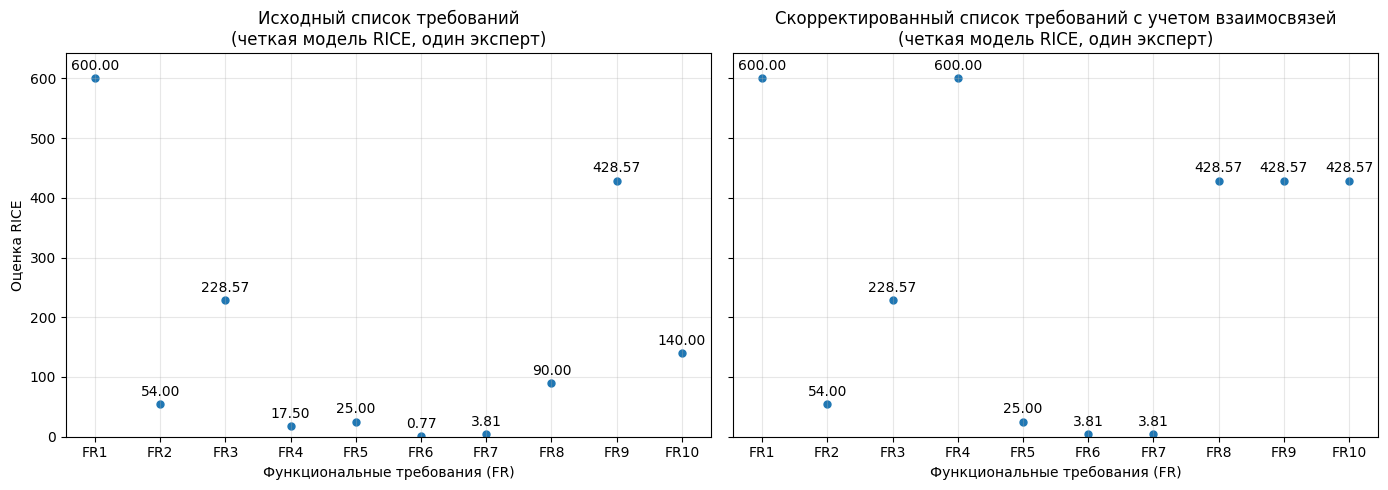

In [263]:
import matplotlib.pyplot as plt
import numpy as np

# Копии исходной и скорректированной таблиц с восстановлением порядка FR1...FR10
df_plot = df.copy()
df_adjusted_plot = adjusted_df.copy()

df_plot["FR_num"] = df_plot["Feature"].str.replace("FR", "", regex=False).astype(int)
df_adjusted_plot["FR_num"] = df_adjusted_plot["Feature"].str.replace("FR", "", regex=False).astype(int)

df_plot = df_plot.sort_values("FR_num").reset_index(drop=True)
df_adjusted_plot = df_adjusted_plot.sort_values("FR_num").reset_index(drop=True)

# Подписи функциональных требований
fr_labels = df_plot["Feature"].tolist()

# Исходные и скорректированные оценки RICE
scores = df_plot["RICE Score"].tolist()
adjusted_scores = df_adjusted_plot["Adjusted RICE Score"].tolist()

# Позиции по оси X
x = np.arange(len(fr_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель RICE, один эксперт)",
    "Скорректированный список требований с учетом взаимосвязей\n(четкая модель RICE, один эксперт)"
]

all_scores = [scores, adjusted_scores]
y_max = max(max(scores), max(adjusted_scores)) * 1.07
offset = max(max(scores), max(adjusted_scores)) * 0.015

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + offset, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, y_max)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Оценка RICE")

plt.tight_layout()
plt.show()

**Реализация четкой модели RICE для произвольного числа функциональных требований FR (расчет выполнен одним экспертом). Загрузка и выгрузка данных из файла/ в файл Excel**

In [264]:
# Реализация четкого RICE с датасетом входящих и исходящих параметров в файлах Excel

from pathlib import Path
import re
import shutil
from typing import Dict, Any, Sequence, List
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter


# 1. Вспомогательные функции обработки входных колонок

def _normalize_col(s: str) -> str:
    return " ".join(str(s).strip().lower().split())


def _detect_columns(columns):
    cols_norm = {_normalize_col(c): c for c in columns}
    originals = list(columns)

    synonyms = {
        "Feature": ["feature", "name", "название", "название фичи", "фича", "задача"],
        "R": ["r", "reach", "охват", "reach (r)", "охват (r)"],
        "I": ["i", "impact", "влияние", "impact (i)", "влияние (i)"],
        "C": ["c", "confidence", "уверенность", "confidence (c)", "уверенность (c)"],
        "E": ["e", "effort", "трудозатраты", "трудоемкость", "усилия", "effort (e)", "трудозатраты (e)"],
    }

    detected = {}
    for canonical, syns in synonyms.items():
        found = None

        for syn in syns:
            syn_norm = _normalize_col(syn)
            if syn_norm in cols_norm:
                found = cols_norm[syn_norm]
                break

        if found is None and canonical in ["R", "I", "C", "E"]:
            key = canonical.lower()
            for c in originals:
                cn = _normalize_col(c)
                if re.search(rf"\({key}\)", cn):
                    found = c
                    break

        if found is None:
            keywords = {
                "Feature": ["fr", "feature", "назван", "задач", "фич"],
                "R": ["reach", "охват"],
                "I": ["impact", "влияни"],
                "C": ["confidence", "уверенн"],
                "E": ["effort", "трудозат", "трудоемк", "усили"],
            }[canonical]
            for c in originals:
                cn = _normalize_col(c)
                if any(k in cn for k in keywords):
                    found = c
                    break

        if found is None:
            raise ValueError(f"Не найдена колонка для '{canonical}'. Доступные колонки: {list(columns)}")

        detected[canonical] = found

    return detected


# 2. Расчет четкой оценки RICE

def rice_score(reach: float, impact: float, confidence: float, effort: float) -> float:
    if effort == 0:
        raise ValueError("Effort (E) не может быть 0")
    return round(reach * impact * confidence / effort, 2)


# 3. Учет взаимосвязанности функциональных требований

def adjust_rice_scores_by_interdependencies(
    df_ranked: pd.DataFrame,
    relation_matrix: Sequence[Sequence[int]],
) -> pd.DataFrame:

    n = len(df_ranked)
    if n == 0:
        return df_ranked.copy()

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(feature_name: str) -> int:
        if not str(feature_name).startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {feature_name}"
            )
        return int(str(feature_name).replace("FR", "")) - 1

    fr_indices = [fr_to_index(feature) for feature in df_ranked["Feature"]]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в df_ranked должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted_df = df_ranked.copy().reset_index(drop=True)
    adjusted_df["Original Rank"] = adjusted_df.index + 1
    adjusted_df["Adjusted RICE Score"] = adjusted_df["RICE Score"].astype(float)

    matrix_idx_to_row = {
        fr_to_index(feature): idx
        for idx, feature in enumerate(adjusted_df["Feature"])
    }

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(
            float(adjusted_df.loc[matrix_idx_to_row[i], "RICE Score"])
            for i in comp
        )
        for i in comp:
            adjusted_df.loc[matrix_idx_to_row[i], "Adjusted RICE Score"] = max_score

    adjusted_df = adjusted_df.sort_values(
        by=["Adjusted RICE Score", "Original Rank"],
        ascending=[False, True]
    ).reset_index(drop=True)

    adjusted_df["Adjusted Rank"] = adjusted_df.index + 1

    cols = ["Adjusted Rank", "Feature", "RICE Score", "Adjusted RICE Score"]
    other_cols = [c for c in adjusted_df.columns if c not in cols + ["Original Rank"]]
    adjusted_df = adjusted_df[cols + other_cols]

    return adjusted_df

# 4. Вспомогательные функции оформления Excel
def apply_single_line_heading(cell, horizontal: str = "left"):
    cell.alignment = Alignment(horizontal=horizontal, vertical="center", wrap_text=False)

def format_numeric_cells(ws):
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):
                cell.number_format = "0.00"

def autosize_columns(ws, min_width: int = 12, max_width: int = 40, extra_padding: int = 2):
    for col_idx in range(1, ws.max_column + 1):
        max_length = 0
        column_letter = get_column_letter(col_idx)

        for row_idx in range(1, ws.max_row + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            value = "" if cell.value is None else str(cell.value)
            lines = value.split("\n")
            longest = max(len(line) for line in lines) if lines else 0
            max_length = max(max_length, longest)

        ws.column_dimensions[column_letter].width = max(
            min_width,
            min(max_length + extra_padding, max_width)
        )

def style_range_as_table(ws, min_row: int, max_row: int, min_col: int, max_col: int):
    thin = Side(style="thin")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for row in ws.iter_rows(min_row=min_row, max_row=max_row, min_col=min_col, max_col=max_col):
        for cell in row:
            cell.border = border
            if cell.alignment is None:
                cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# 5. Лист матрицы взаимосвязанности
def write_relation_matrix_sheet(
    workbook,
    fr_names: Sequence[str],
    relation_matrix: Sequence[Sequence[int]],
    sheet_name: str = "Матрица_взаимосвязей_FR"
):
    if sheet_name in workbook.sheetnames:
        del workbook[sheet_name]

    ws = workbook.create_sheet(title=sheet_name)

    title_font = Font(bold=True, size=12)
    header_font = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    def fr_sort_key(fr_name: str) -> int:
        fr_name = str(fr_name).strip()
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", ""))

    fr_names_ordered = sorted([str(fr).strip() for fr in fr_names], key=fr_sort_key)

    n = len(fr_names_ordered)
    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    ws.cell(1, 1, "Матрица взаимосвязанности функциональных требований").font = title_font
    apply_single_line_heading(ws.cell(1, 1), horizontal="left")
    ws.row_dimensions[1].height = 20

    ws.cell(3, 1, "FR").font = header_font
    ws.cell(3, 1).alignment = center

    for j, fr in enumerate(fr_names_ordered, start=2):
        ws.cell(3, j, fr).font = header_font
        ws.cell(3, j).alignment = center

    for i, fr in enumerate(fr_names_ordered, start=4):
        ws.cell(i, 1, fr).font = header_font
        ws.cell(i, 1).alignment = center
        for j, value in enumerate(relation_matrix[i - 4], start=2):
            ws.cell(i, j, int(value))
            ws.cell(i, j).alignment = center

    format_numeric_cells(ws)

    for row_idx in range(4, 4 + len(fr_names_ordered)):
        for col_idx in range(2, 2 + len(fr_names_ordered)):
            ws.cell(row=row_idx, column=col_idx).number_format = "0"

    autosize_columns(ws, min_width=12, max_width=20, extra_padding=3)
    ws.column_dimensions["A"].width = 10

# 6. Основная функция загрузки, расчета и выгрузки в Excel
def compute_rice_from_file(
    input_path: str,
    input_sheet_name: str = "Четкий RICE_эксперт 1",
    output_sheet_name: str = "Итоги_четкий RICE_эксперт 1",
    output_path: str | None = None,
    relation_matrix: Sequence[Sequence[int]] | None = None,
    relation_sheet_name: str = "Матрица_взаимосвязей_FR"
) -> pd.DataFrame:

    # 6.1. Проверка путей
    input_path = Path(input_path)

    if not input_path.exists():
        raise FileNotFoundError(f"Файл не найден: {input_path}")

    if input_path.suffix.lower() not in [".xlsx", ".xls"]:
        raise ValueError("Для такого режима работы нужен Excel-файл .xlsx или .xls")

    if output_path is None:
        output_path = input_path.with_name("Итоги_четкий RICE_один эксперт" + input_path.suffix)
    else:
        output_path = Path(output_path)

    # 6.2. Чтение исходного листа
    df = pd.read_excel(input_path, sheet_name=input_sheet_name)

    # 6.3. Определение и нормализация названий колонок
    colmap = _detect_columns(df.columns)
    df = df.rename(columns={
        colmap["Feature"]: "Feature",
        colmap["R"]: "R",
        colmap["I"]: "I",
        colmap["C"]: "C",
        colmap["E"]: "E",
    })

    # 6.4. Приведение типов
    for col in ["R", "I", "C", "E"]:
        df[col] = df[col].astype(str).str.replace(",", ".", regex=False)
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 6.5. Проверки данных
    bad = df[df[["Feature", "R", "I", "C", "E"]].isna().any(axis=1)]
    if not bad.empty:
        raise ValueError("Есть строки с пустыми/некорректными значениями:\n" + bad.to_string(index=False))

    if (df["E"] == 0).any():
        raise ValueError("Есть строки с Effort (E) = 0 - деление невозможно.")

    if (df["C"] > 1).any() and (df["C"] <= 100).all():
        df["C"] = df["C"] / 100.0

    # 6.6. Расчет и ранжирование
    df["RICE Score"] = (df["R"] * df["I"] * df["C"] / df["E"]).round(2)
    df = df.sort_values("RICE Score", ascending=False).reset_index(drop=True)
    df.insert(0, "Rank", df.index + 1)

    fr_names = df["Feature"].tolist()

    # 6.7. Матрица взаимосвязанности по умолчанию
    if relation_matrix is None:
        n = len(df)
        relation_matrix = [[1 if i == j else 0 for j in range(n)] for i in range(n)]

    # 6.8. Скорректированный рейтинг
    adjusted_df = adjust_rice_scores_by_interdependencies(df, relation_matrix)

    adjusted_export_df = pd.DataFrame({
        "Место": adjusted_df["Adjusted Rank"].astype(int),
        "FR": adjusted_df["Feature"],
        "Исходный рейтинг": adjusted_df["RICE Score"].astype(float).round(2),
        "Скорректированный рейтинг": adjusted_df["Adjusted RICE Score"].astype(float).round(2)
    })

    # 6.9. Создание выходного файла
    shutil.copy2(input_path, output_path)

    with pd.ExcelWriter(
        output_path,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        df.to_excel(
            writer,
            sheet_name=output_sheet_name,
            index=False,
            header=False,
            startrow=3
        )

    # 6.10. Открытие книги
    workbook = load_workbook(output_path)

    # 6.11. Лист матрицы взаимосвязанности
    write_relation_matrix_sheet(
        workbook=workbook,
        fr_names=fr_names,
        relation_matrix=relation_matrix,
        sheet_name=relation_sheet_name
    )

    # 6.12. Лист итогов
    worksheet = workbook[output_sheet_name]

    bold_font = Font(bold=True)
    center_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    worksheet.cell(1, 1, "Четкий RICE - итоговая приоритизация (один эксперт)").font = bold_font
    apply_single_line_heading(worksheet.cell(1, 1), horizontal="left")
    worksheet.row_dimensions[1].height = 20

    # 6.13. Подпись к первой таблице
    worksheet.cell(3, 1, "1) Итоговый рейтинг по методу RICE (четкая модель)").font = bold_font
    apply_single_line_heading(worksheet.cell(3, 1), horizontal="left")
    worksheet.row_dimensions[3].height = 20

    # 6.14. Первая таблица: заголовки
    worksheet["A4"] = "Приоритизация"
    worksheet["B4"] = "Функциональное\nтребование"
    worksheet["C4"] = "Reach (R)"
    worksheet["D4"] = "Impact (I)"
    worksheet["E4"] = "Confidence (C)"
    worksheet["F4"] = "Effort (E)"
    worksheet["G4"] = "Итог"
    worksheet["G5"] = "RICE Score"

    worksheet.merge_cells("A4:A5")
    worksheet.merge_cells("B4:B5")
    worksheet.merge_cells("C4:C5")
    worksheet.merge_cells("D4:D5")
    worksheet.merge_cells("E4:E5")
    worksheet.merge_cells("F4:F5")
    worksheet.merge_cells("G4:G5")

    for row in worksheet.iter_rows(min_row=4, max_row=5, min_col=1, max_col=7):
        for cell in row:
            cell.font = bold_font
            cell.alignment = center_alignment

    worksheet.row_dimensions[4].height = 24
    worksheet.row_dimensions[5].height = 24

    # 6.15. Первая таблица: данные
    main_table_last_row = 5 + len(df)

    for idx, row in df.iterrows():
        excel_row = 6 + idx
        worksheet.cell(excel_row, 1, int(row["Rank"]))
        worksheet.cell(excel_row, 2, row["Feature"])
        worksheet.cell(excel_row, 3, float(row["R"]))
        worksheet.cell(excel_row, 4, float(row["I"]))
        worksheet.cell(excel_row, 5, float(row["C"]))
        worksheet.cell(excel_row, 6, float(row["E"]))
        worksheet.cell(excel_row, 7, float(row["RICE Score"]))

        for col_idx in range(1, 8):
            worksheet.cell(excel_row, col_idx).alignment = center_alignment

    # 6.16. Вторая таблица
    start_row = main_table_last_row + 3

    worksheet.cell(start_row, 1, "2) Итоговая приоритизация после учета взаимосвязанности").font = bold_font
    apply_single_line_heading(worksheet.cell(start_row, 1), horizontal="left")
    worksheet.row_dimensions[start_row].height = 20

    header_row = start_row + 1
    headers = ["Место", "FR", "Исходный рейтинг", "Скорректированный\nрейтинг"]

    for col_idx, header in enumerate(headers, start=1):
        cell = worksheet.cell(header_row, col_idx, header)
        cell.font = bold_font
        cell.alignment = center_alignment

    worksheet.row_dimensions[header_row].height = 36

    data_row = header_row + 1
    for _, row in adjusted_export_df.iterrows():
        worksheet.cell(data_row, 1, int(row["Место"]))
        worksheet.cell(data_row, 2, row["FR"])
        worksheet.cell(data_row, 3, float(row["Исходный рейтинг"]))
        worksheet.cell(data_row, 4, float(row["Скорректированный рейтинг"]))

        for col_idx in range(1, 5):
            worksheet.cell(data_row, col_idx).alignment = center_alignment

        data_row += 1

    # 6.17. Формат чисел
    format_numeric_cells(worksheet)

    for row_idx in range(6, main_table_last_row + 1):
        worksheet.cell(row=row_idx, column=1).number_format = "0"

    for row_idx in range(header_row + 1, data_row):
        worksheet.cell(row=row_idx, column=1).number_format = "0"

    # 6.18. Ширина столбцов на листе итогов
    autosize_columns(worksheet, min_width=12, max_width=30, extra_padding=2)
    worksheet.column_dimensions["A"].width = 16
    worksheet.column_dimensions["B"].width = 18
    worksheet.column_dimensions["D"].width = 20

    # 6.19. Порядок листов
    desired_order = []
    if input_sheet_name in workbook.sheetnames:
        desired_order.append(input_sheet_name)
    if relation_sheet_name in workbook.sheetnames:
        desired_order.append(relation_sheet_name)
    if output_sheet_name in workbook.sheetnames:
        desired_order.append(output_sheet_name)

    remaining_sheets = [ws for ws in workbook.sheetnames if ws not in desired_order]
    workbook._sheets = [workbook[name] for name in desired_order + remaining_sheets]

    # 6.20. Сохранение
    workbook.save(output_path)

    print(f"Результат сохранен в новый файл: {output_path}")

    return df

In [265]:
# Запуск

relation_matrix = [
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR1 связано с FR4
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # FR2
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # FR3
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # FR4 связано с FR1
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # FR5
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR6 связано с FR7
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],  # FR7 связано с FR6
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR8 связано с FR9 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR9 связано с FR8 и FR10
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],  # FR10 связано с FR8 и FR9
]

df_result = compute_rice_from_file(
    input_path="Загрузочные данные_четкий RICE_один эксперт.xlsx",
    input_sheet_name="Четкий RICE_эксперт 1",
    output_sheet_name="Итоги_четкий RICE_эксперт 1",
    output_path="Итоги_четкий RICE_один эксперт.xlsx",
    relation_matrix=relation_matrix,
    relation_sheet_name="Матрица_взаимосвязей_FR"
)


Результат сохранен в новый файл: Итоги_четкий RICE_один эксперт.xlsx


# Выводы по расчетной части проекта

# Приложение: функции - основные операции с нечеткими числами

**Умножение двух нечетких трапециевидных чисел 2-го типа**

In [266]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

**Деление одного нечеткого трапециевидного числа 2-го типа на другое нечеткое трапециевидное число 2-го типа**

In [267]:
def divide_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для частного от деления
    z1 = (x2 * y3 - x2 * y4 + x1 * y3) / ((y3)**2)
    z2 = x2 / y3
    z3 = x3 / y2
    z4 = (x3 * y2 - x3 * y1 + x4 * y2) / ((y2)**2)

    z5 = (x6 * y7 - x6 * y8 + x5 * y7) / ((y7)**2)
    z6 = x6 / y7
    z7 = x7 / y6
    z8 = (x7 * y6 - x7 * y5 + x8 * y6) / ((y6)**2)

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

**Сумма двух нечетких трапециевидных чисел 2-го типа**

In [268]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

**Умножение нечеткого трапециевидного числа 2-го типа на константу**

In [269]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

**Оператор согласованной линейной редукции типа (CLTR) для дефаззификации трапециевидного НЧ 2-го типа**

In [270]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )


In [271]:
X = ((1, 2, 4, 5), (1.5, 2, 4, 4.5))

a = 0.6

Y = cltr_type_reduction(X, a)

print("X =", X)
print("a =", a)
print("Y =", Y)

X = ((1, 2, 4, 5), (1.5, 2, 4, 4.5))
a = 0.6
Y = (1.3, 2.0, 4.0, 4.7)


**Округление нечеткого трапециевидного числа 2-го типа**

In [272]:
# Функция округления параметров трапециевидного нечеткого числа (интуиционистского или интервального 2 типа)
def round_fuzzy_number(fuzzy_number):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    return ((round(x1, 2), round(x2, 2), round(x3, 2), round(x4, 2)),
            (round(x5, 2), round(x6, 2), round(x7, 2), round(x8, 2)))

**Вычисление границ альфа-среза для нечеткого трапециевидного числа 1-го типа**

In [273]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

**Нахождение центроида системы из двух точек**

In [274]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central